In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cpu
GPU available: False


In [ ]:
!pip install -q librosa soundfile numpy pandas matplotlib seaborn scikit-learn

In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/GNN_BERT_Music"

print(PROJECT_PATH)

/content/drive/MyDrive/GNN_BERT_Music


In [ ]:
import os

print(os.listdir(PROJECT_PATH))

['data', 'models', 'results', 'notebooks']


In [ ]:
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Librosa:", librosa.__version__)
print("Everything is working!")

NumPy: 2.1.3
Pandas: 2.2.3
Librosa: 0.11.0
Everything is working!


In [ ]:
import os

RAW_PATH = os.path.join(PROJECT_PATH, "data", "raw")
PROCESSED_PATH = os.path.join(PROJECT_PATH, "data", "processed")

os.makedirs(RAW_PATH, exist_ok=True)
os.makedirs(PROCESSED_PATH, exist_ok=True)

print("Raw data path:", RAW_PATH)
print("Processed data path:", PROCESSED_PATH)

Raw data path: /content/drive/MyDrive/GNN_BERT_Music/data/raw
Processed data path: /content/drive/MyDrive/GNN_BERT_Music/data/processed


In [ ]:
!wget -q --show-progress https://os.unil.cloud.switch.ch/fma/fma_small.zip


fma_small.zip       100%[===================>]   7.15G  15.6MB/s    in 8m 15s  


In [ ]:
import os

print("File exists:", os.path.exists("fma_small.zip"))

if os.path.exists("fma_small.zip"):
    size_gb = os.path.getsize("fma_small.zip") / (1024**3)
    print(f"File size: {size_gb:.2f} GB")


File exists: True
File size: 7.15 GB


In [ ]:
!unzip -q fma_small.zip -d /content/

In [ ]:
!ls /content/fma_small | head

000
001
002
003
004
005
006
007
008
009


In [ ]:
import os

FMA_PATH = "/content/fma_small"

audio_files = []

for root, dirs, files in os.walk(FMA_PATH):
    for file in files:
        if file.endswith(".mp3"):
            audio_files.append(os.path.join(root, file))

print("Number of audio files found:", len(audio_files))
print("\nFirst 5 files:")

for file in audio_files[:5]:
    print(file)

Number of audio files found: 8000

First 5 files:
/content/fma_small/059/059446.mp3
/content/fma_small/059/059719.mp3
/content/fma_small/059/059374.mp3
/content/fma_small/059/059653.mp3
/content/fma_small/059/059658.mp3


In [ ]:
audio_path = audio_files[0]

print("Selected audio:")
print(audio_path)


Selected audio:
/content/fma_small/059/059446.mp3


In [ ]:
import librosa

audio, sr = librosa.load(
    audio_path,
    sr=22050,
    mono=True
)

print("Sample rate:", sr)
print("Number of samples:", len(audio))
print("Duration:", len(audio) / sr, "seconds")

Sample rate: 22050
Number of samples: 661560
Duration: 30.002721088435376 seconds


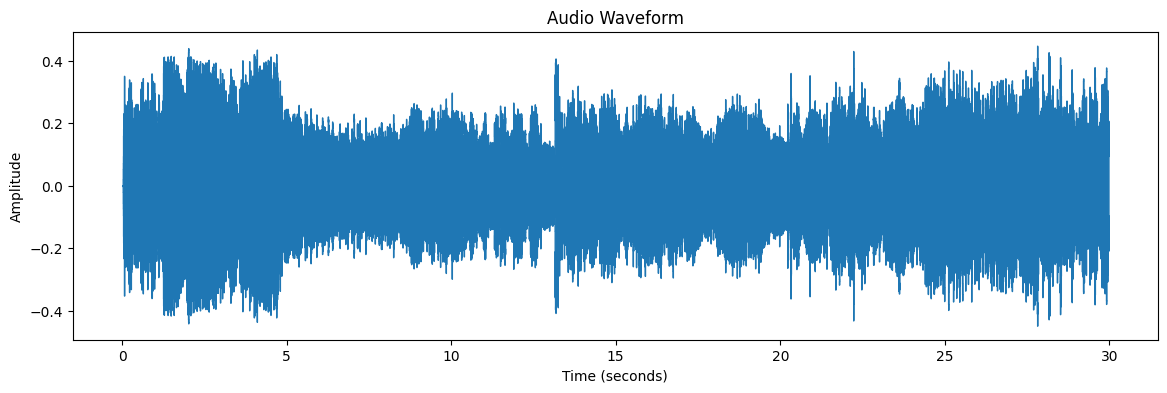

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))

librosa.display.waveshow(audio, sr=sr)

plt.title("Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

print("Mel spectrogram shape:", mel_db.shape)

Mel spectrogram shape: (128, 1291)


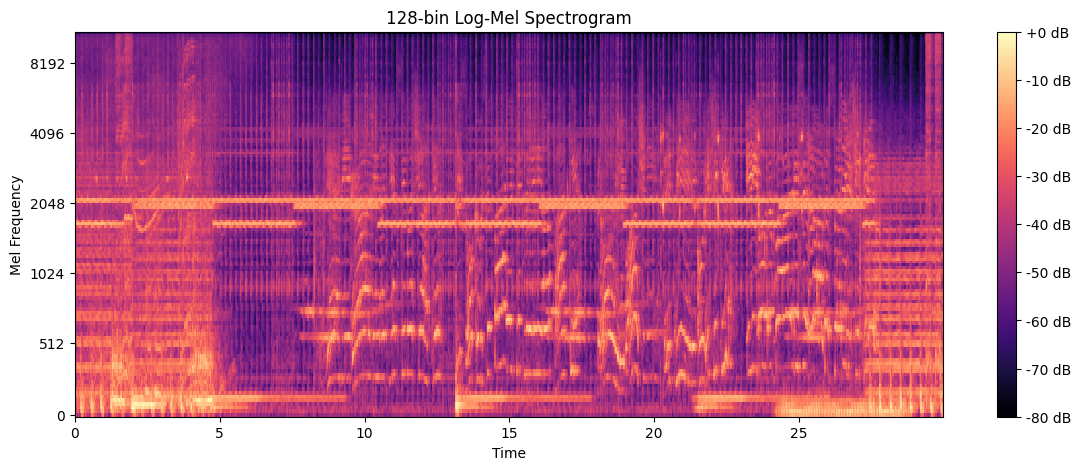

In [ ]:
plt.figure(figsize=(14, 5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("128-bin Log-Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.show()

In [ ]:
segment_duration = 5  # seconds

segment_samples = int(segment_duration * sr)

segments = []

for start in range(0, len(audio), segment_samples):
    end = start + segment_samples
    segment = audio[start:end]

    # Keep only complete 5-second segments
    if len(segment) == segment_samples:
        segments.append(segment)

print("Number of segments:", len(segments))
print("Samples per segment:", len(segments[0]))
print("Duration per segment:", len(segments[0]) / sr, "seconds")

Number of segments: 6
Samples per segment: 110250
Duration per segment: 5.0 seconds


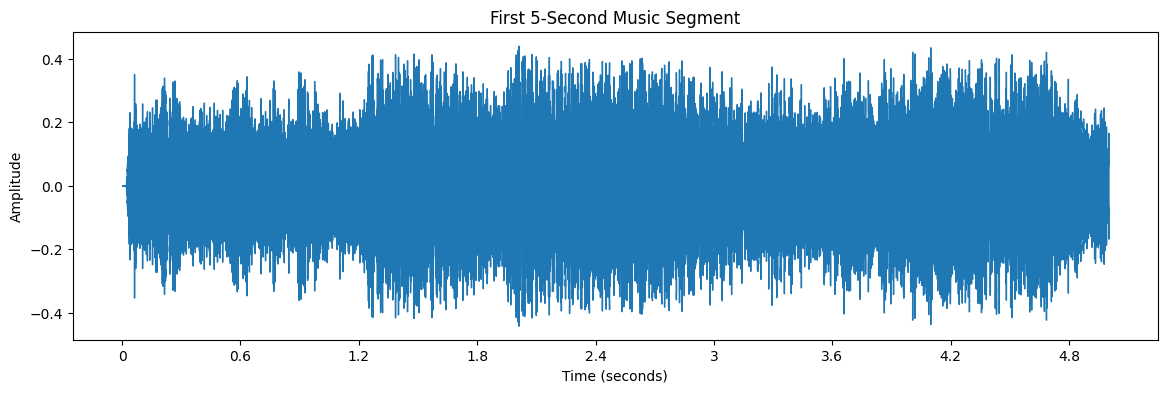

In [ ]:
plt.figure(figsize=(14, 4))

librosa.display.waveshow(
    segments[0],
    sr=sr
)

plt.title("First 5-Second Music Segment")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
segment_mel = librosa.feature.melspectrogram(
    y=segments[0],
    sr=sr,
    n_mels=128
)

segment_mel_db = librosa.power_to_db(
    segment_mel,
    ref=np.max
)

print("Segment Mel shape:", segment_mel_db.shape)

Segment Mel shape: (128, 216)


In [ ]:
segment_features = []

for segment in segments:

    mel = librosa.feature.melspectrogram(
        y=segment,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    # Average over time
    feature = np.mean(mel_db, axis=1)

    segment_features.append(feature)

segment_features = np.array(segment_features)

print("Feature matrix shape:", segment_features.shape)

Feature matrix shape: (6, 128)


In [ ]:
print("First segment feature vector:")
print(segment_features[0])

print("\nNumber of features:", len(segment_features[0]))

First segment feature vector:
[-28.296232 -25.16064  -17.234663 -17.532097 -21.011868 -20.041239
 -21.693998 -20.493723 -20.60692  -23.066654 -23.163273 -26.433287
 -30.111935 -23.443827 -22.571262 -29.979958 -30.006638 -32.159527
 -33.42313  -31.365597 -28.315203 -26.693579 -33.280807 -37.140377
 -34.92757  -35.151737 -36.397762 -34.492405 -29.865746 -32.74178
 -37.205097 -34.227962 -31.59871  -30.827799 -29.804525 -28.742289
 -29.16996  -34.42551  -34.059204 -34.660053 -34.845768 -34.2387
 -27.981358 -30.12096  -34.305943 -35.078175 -34.380955 -33.80994
 -29.008533 -28.651602 -31.246525 -29.576653 -26.982023 -18.492435
 -24.904049 -30.195444 -31.03569  -23.125292 -21.498693 -29.04512
 -29.196207 -27.153822 -26.79509  -28.881304 -27.97959  -25.782785
 -28.487358 -31.166094 -25.797909 -26.16816  -31.436686 -28.50742
 -27.98634  -30.99303  -29.328468 -30.544975 -30.32186  -28.150612
 -32.703068 -30.941574 -31.939531 -32.53975  -33.1778   -34.247757
 -32.639183 -35.933933 -34.71519  -35.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

segment_features_scaled = scaler.fit_transform(segment_features)

print("Scaled feature matrix shape:", segment_features_scaled.shape)

Scaled feature matrix shape: (6, 128)


In [ ]:
import numpy as np

num_nodes = len(segment_features_scaled)

edges = []

for i in range(num_nodes - 1):
    # Forward edge
    edges.append([i, i + 1])

    # Backward edge
    edges.append([i + 1, i])

edges = np.array(edges)

print("Number of nodes:", num_nodes)
print("Number of edges:", len(edges))
print("\nEdges:")
print(edges)

Number of nodes: 6
Number of edges: 10

Edges:
[[0 1]
 [1 0]
 [1 2]
 [2 1]
 [2 3]
 [3 2]
 [3 4]
 [4 3]
 [4 5]
 [5 4]]


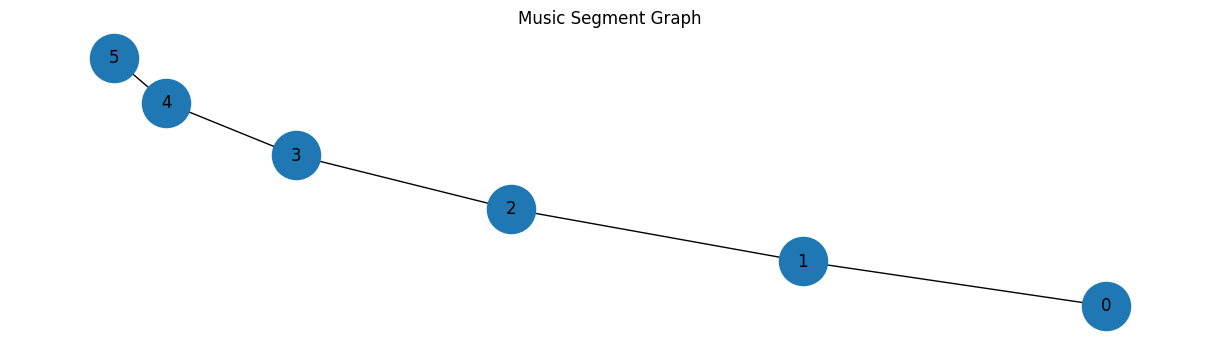

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_nodes_from(range(num_nodes))

for edge in edges:
    G.add_edge(edge[0], edge[1])

plt.figure(figsize=(12, 3))

nx.draw(
    G,
    with_labels=True,
    node_size=1200,
    font_size=12
)

plt.title("Music Segment Graph")
plt.show()

In [ ]:
!pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 723.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.6 MB/s eta 0:00:00


In [ ]:
import torch
from torch_geometric.data import Data

print("PyTorch version:", torch.__version__)
print("PyTorch Geometric is working!")

PyTorch version: 2.11.0+cpu
PyTorch Geometric is working!


In [ ]:
# Node features
x = torch.tensor(
    segment_features_scaled,
    dtype=torch.float
)

# Edge connections
edge_index = torch.tensor(
    edges.T,
    dtype=torch.long
)

print("Node feature shape:", x.shape)
print("Edge index shape:", edge_index.shape)

Node feature shape: torch.Size([6, 128])
Edge index shape: torch.Size([2, 10])


In [ ]:
data = Data(
    x=x,
    edge_index=edge_index
)

print(data)

Data(x=[6, 128], edge_index=[2, 10])


In [ ]:
import os

GRAPH_PATH = os.path.join(
    PROJECT_PATH,
    "data",
    "processed",
    "graphs"
)

os.makedirs(GRAPH_PATH, exist_ok=True)

print("Graph folder:", GRAPH_PATH)

Graph folder: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs


In [ ]:
graph_file = os.path.join(
    GRAPH_PATH,
    "track_000001.pt"
)

torch.save(data, graph_file)

print("Graph saved!")
print(graph_file)

Graph saved!
/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/track_000001.pt


In [ ]:
loaded_data = torch.load(
    graph_file,
    weights_only=False
)

print(loaded_data)
print("Node features:", loaded_data.x.shape)
print("Edges:", loaded_data.edge_index.shape)

Data(x=[6, 128], edge_index=[2, 10])
Node features: torch.Size([6, 128])
Edges: torch.Size([2, 10])


In [ ]:
!wget -q --show-progress https://os.unil.cloud.switch.ch/fma/fma_metadata.zip

fma_metadata.zip    100%[===================>] 341.81M  14.7MB/s    in 25s     


In [ ]:
!unzip -q fma_metadata.zip -d /content/

print("Metadata extracted!")

Metadata extracted!


In [ ]:
import os

metadata_path = "/content/fma_metadata"

for root, dirs, files in os.walk(metadata_path):
    for file in files:
        print(os.path.join(root, file))

/content/fma_metadata/raw_echonest.csv
/content/fma_metadata/tracks.csv
/content/fma_metadata/features.csv
/content/fma_metadata/raw_tracks.csv
/content/fma_metadata/raw_genres.csv
/content/fma_metadata/raw_albums.csv
/content/fma_metadata/raw_artists.csv
/content/fma_metadata/echonest.csv
/content/fma_metadata/README.txt
/content/fma_metadata/not_found.pickle
/content/fma_metadata/checksums
/content/fma_metadata/genres.csv


In [ ]:
import pandas as pd

tracks_path = "/content/fma_metadata/tracks.csv"

tracks = pd.read_csv(
    tracks_path,
    header=[0, 1],
    index_col=0
)

print("Shape:", tracks.shape)
print("\nColumns:")
print(tracks.columns.tolist())

Shape: (106574, 52)

Columns:
[('album', 'comments'), ('album', 'date_created'), ('album', 'date_released'), ('album', 'engineer'), ('album', 'favorites'), ('album', 'id'), ('album', 'information'), ('album', 'listens'), ('album', 'producer'), ('album', 'tags'), ('album', 'title'), ('album', 'tracks'), ('album', 'type'), ('artist', 'active_year_begin'), ('artist', 'active_year_end'), ('artist', 'associated_labels'), ('artist', 'bio'), ('artist', 'comments'), ('artist', 'date_created'), ('artist', 'favorites'), ('artist', 'id'), ('artist', 'latitude'), ('artist', 'location'), ('artist', 'longitude'), ('artist', 'members'), ('artist', 'name'), ('artist', 'related_projects'), ('artist', 'tags'), ('artist', 'website'), ('artist', 'wikipedia_page'), ('set', 'split'), ('set', 'subset'), ('track', 'bit_rate'), ('track', 'comments'), ('track', 'composer'), ('track', 'date_created'), ('track', 'date_recorded'), ('track', 'duration'), ('track', 'favorites'), ('track', 'genre_top'), ('track', 'ge

In [ ]:
print("Top genres:")
print(tracks[("track", "genre_top")].value_counts())

print("\nNumber of unique genres:")
print(tracks[("track", "genre_top")].nunique())

Top genres:
(track, genre_top)
Rock                   14182
Experimental           10608
Electronic              9372
Hip-Hop                 3552
Folk                    2803
Pop                     2332
Instrumental            2079
International           1389
Classical               1230
Jazz                     571
Old-Time / Historic      554
Spoken                   423
Country                  194
Soul-RnB                 175
Blues                    110
Easy Listening            24
Name: count, dtype: int64

Number of unique genres:
16


In [ ]:
# Check the metadata for our first track

track_id = int(os.path.basename(audio_path).split("/")[-1].split(".")[0])

print("Track ID:", track_id)

track_info = tracks.loc[track_id]

print("\nTrack information:")
print(track_info)

Track ID: 59446

Track information:
album   comments                                                             0
        date_created                                       2012-01-24 10:01:51
        date_released                                                      NaN
        engineer                                                           NaN
        favorites                                                            0
        id                                                               10915
        information                                                        NaN
        listens                                                           6816
        producer                                                           NaN
        tags                                                                []
        title                           A Grounded Mound/ Widespread Telepathy
        tracks                                                              12
        type    

In [ ]:
genre = track_info[("track", "genre_top")]

print("Genre label:", genre)

Genre label: Pop


In [ ]:
data.y = torch.tensor([0])  # temporary label

data.genre = genre
data.track_id = track_id
data.title = track_info[("track", "title")]

print(data)
print("Genre:", data.genre)
print("Track ID:", data.track_id)
print("Title:", data.title)

Data(x=[6, 128], edge_index=[2, 10], y=[1], genre='Spoken', track_id=14576, title='Beam Chaser')
Genre: Spoken
Track ID: 14576
Title: Beam Chaser


In [ ]:
# Get all 16 genres
genres = tracks[("track", "genre_top")].dropna().unique()

# Sort them for a consistent class mapping
genres = sorted(genres)

genre_to_idx = {genre: idx for idx, genre in enumerate(genres)}
idx_to_genre = {idx: genre for genre, idx in genre_to_idx.items()}

print("Genre mapping:")
for idx, genre in idx_to_genre.items():
    print(idx, "→", genre)

Genre mapping:
0 → Blues
1 → Classical
2 → Country
3 → Easy Listening
4 → Electronic
5 → Experimental
6 → Folk
7 → Hip-Hop
8 → Instrumental
9 → International
10 → Jazz
11 → Old-Time / Historic
12 → Pop
13 → Rock
14 → Soul-RnB
15 → Spoken


In [ ]:
numeric_label = genre_to_idx[data.genre]

data.y = torch.tensor([numeric_label], dtype=torch.long)

print("Genre:", data.genre)
print("Numeric label:", data.y.item())

Genre: Spoken
Numeric label: 15


In [ ]:
torch.save(data, graph_file)

print("Labeled graph saved successfully!")
print("File:", graph_file)
print("Label:", data.y.item())
print("Genre:", data.genre)

Labeled graph saved successfully!
File: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/track_000001.pt
Label: 15
Genre: Spoken


In [ ]:
def create_music_graph(audio_path, genre, track_id, title):
    """
    Convert one music track into a PyTorch Geometric graph.

    Nodes:
        5-second audio segments

    Node features:
        128-dimensional averaged log-Mel features

    Edges:
        Bidirectional temporal connections between consecutive segments
    """

    # 1. Load audio
    audio, sr = librosa.load(
        audio_path,
        sr=22050,
        mono=True
    )

    # 2. Split into 5-second segments
    segment_duration = 5
    segment_samples = int(segment_duration * sr)

    segments = []

    for start in range(0, len(audio), segment_samples):
        end = start + segment_samples
        segment = audio[start:end]

        if len(segment) == segment_samples:
            segments.append(segment)

    # Make sure there is at least one complete segment
    if len(segments) == 0:
        return None

    # 3. Extract 128-bin log-Mel feature for each segment
    segment_features = []

    for segment in segments:
        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=128
        )

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        # Average over time → 128-dimensional vector
        feature_vector = np.mean(
            mel_db,
            axis=1
        )

        segment_features.append(feature_vector)

    segment_features = np.array(segment_features)

    # 4. Scale features
    scaler = StandardScaler()
    segment_features_scaled = scaler.fit_transform(
        segment_features
    )

    # 5. Create temporal edges
    edges = []

    for i in range(len(segments) - 1):
        edges.append([i, i + 1])
        edges.append([i + 1, i])

    # 6. Convert to PyTorch tensors
    x = torch.tensor(
        segment_features_scaled,
        dtype=torch.float
    )

    edge_index = torch.tensor(
        np.array(edges).T,
        dtype=torch.long
    )

    # 7. Convert genre to numeric label
    numeric_label = genre_to_idx[genre]

    y = torch.tensor(
        [numeric_label],
        dtype=torch.long
    )

    # 8. Create PyTorch Geometric graph
    graph = Data(
        x=x,
        edge_index=edge_index,
        y=y
    )

    # Store useful metadata
    graph.genre = genre
    graph.track_id = int(track_id)
    graph.title = title

    return graph


print("Graph creation function is ready!")

Graph creation function is ready!


In [ ]:
test_graph = create_music_graph(
    audio_path=audio_path,
    genre=genre,
    track_id=track_id,
    title=track_info[("track", "title")]
)

print(test_graph)
print("Node features:", test_graph.x.shape)
print("Edges:", test_graph.edge_index.shape)
print("Label:", test_graph.y.item())
print("Genre:", test_graph.genre)
print("Track ID:", test_graph.track_id)
print("Title:", test_graph.title)

Data(x=[6, 128], edge_index=[2, 10], y=[1], genre='Spoken', track_id=14576, title='Beam Chaser')
Node features: torch.Size([6, 128])
Edges: torch.Size([2, 10])
Label: 15
Genre: Spoken
Track ID: 14576
Title: Beam Chaser


In [ ]:
# Check official FMA dataset splits

split_counts = tracks[("set", "split")].value_counts()

print("Official FMA splits:")
print(split_counts)

Official FMA splits:
(set, split)
training      84353
test          11263
validation    10958
Name: count, dtype: int64


In [ ]:
# Check splits for FMA-small

small_tracks = tracks[tracks[("set", "subset")] == "small"]

small_split_counts = small_tracks[("set", "split")].value_counts()

print("FMA-small split distribution:")
print(small_split_counts)

print("\nTotal FMA-small tracks:", len(small_tracks))

FMA-small split distribution:
(set, split)
training      6400
validation     800
test           800
Name: count, dtype: int64

Total FMA-small tracks: 8000


In [ ]:
# Find usable FMA-small training tracks with genre labels

small_training = small_tracks[
    (small_tracks[("set", "split")] == "training") &
    (small_tracks[("track", "genre_top")].notna())
]

print("Training tracks with genre labels:", len(small_training))

print("\nGenre distribution:")
print(small_training[("track", "genre_top")].value_counts())

Training tracks with genre labels: 6400

Genre distribution:
(track, genre_top)
Hip-Hop          800
Pop              800
Folk             800
Rock             800
Experimental     800
International    800
Electronic       800
Instrumental     800
Name: count, dtype: int64


In [ ]:
# Check how many labeled training tracks have actual audio files

import os

audio_root = "/content/fma_small"

def get_audio_path(track_id):
    track_id = int(track_id)
    folder = f"{track_id // 1000:03d}"
    filename = f"{track_id:06d}.mp3"
    return os.path.join(audio_root, folder, filename)

available_count = 0
missing_count = 0

for track_id in small_training.index:
    path = get_audio_path(track_id)

    if os.path.exists(path):
        available_count += 1
    else:
        missing_count += 1

print("Audio files available:", available_count)
print("Audio files missing:", missing_count)

Audio files available: 6400
Audio files missing: 0


In [ ]:
# Step 19: Create 20 training graph samples

import os
import torch

# Folder for training graphs
TRAIN_GRAPH_PATH = os.path.join(
    PROJECT_PATH,
    "data",
    "processed",
    "graphs",
    "training"
)

os.makedirs(TRAIN_GRAPH_PATH, exist_ok=True)

created = 0

for track_id in small_training.index:

    # Stop after creating 20 graphs
    if created >= 20:
        break

    # Get metadata
    track_info = small_training.loc[track_id]

    genre = track_info[("track", "genre_top")]
    title = track_info[("track", "title")]

    # Get audio path
    audio_path = get_audio_path(track_id)

    # Create graph
    graph = create_music_graph(
        audio_path=audio_path,
        genre=genre,
        track_id=track_id,
        title=title
    )

    # Save graph
    graph_file = os.path.join(
        TRAIN_GRAPH_PATH,
        f"track_{int(track_id):06d}.pt"
    )

    torch.save(graph, graph_file)

    created += 1

print("Graphs created:", created)
print("Saved in:", TRAIN_GRAPH_PATH)

Graphs created: 20
Saved in: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/training


In [ ]:
# Step 20: Verify saved graph samples

import glob
import torch

graph_files = sorted(
    glob.glob(os.path.join(TRAIN_GRAPH_PATH, "*.pt"))
)

print("Number of saved graphs:", len(graph_files))

# Inspect the first graph
sample_graph = torch.load(
    graph_files[0],
    weights_only=False
)

print("\nFirst graph:")
print(sample_graph)

print("\nNode features:", sample_graph.x.shape)
print("Edges:", sample_graph.edge_index.shape)
print("Numeric label:", sample_graph.y.item())
print("Genre:", sample_graph.genre)
print("Track ID:", sample_graph.track_id)
print("Title:", sample_graph.title)

Number of saved graphs: 20

First graph:
Data(x=[5, 128], edge_index=[2, 8], y=[1], genre='Hip-Hop', track_id=2, title='Food')

Node features: torch.Size([5, 128])
Edges: torch.Size([2, 8])
Numeric label: 7
Genre: Hip-Hop
Track ID: 2
Title: Food


In [ ]:
# Step 21: Create clean FMA-small 8-class genre mapping

small_genres = sorted(
    small_training[("track", "genre_top")].unique()
)

small_genre_to_idx = {
    genre: idx for idx, genre in enumerate(small_genres)
}

small_idx_to_genre = {
    idx: genre for genre, idx in small_genre_to_idx.items()
}

print("Number of genres:", len(small_genres))
print("\nGenre mapping:")

for idx, genre in small_idx_to_genre.items():
    print(idx, "->", genre)

Number of genres: 8

Genre mapping:
0 -> Electronic
1 -> Experimental
2 -> Folk
3 -> Hip-Hop
4 -> Instrumental
5 -> International
6 -> Pop
7 -> Rock


In [ ]:
# Step 22: Updated graph creation function
# Uses the correct 8-class FMA-small mapping

def create_music_graph(audio_path, genre, track_id, title):

    # 1. Load audio
    audio, sr = librosa.load(
        audio_path,
        sr=22050,
        mono=True
    )

    # 2. Split into 5-second segments
    segment_duration = 5
    segment_samples = int(segment_duration * sr)

    segments = []

    for start in range(0, len(audio), segment_samples):

        end = start + segment_samples
        segment = audio[start:end]

        if len(segment) == segment_samples:
            segments.append(segment)

    # 3. Extract 128-dimensional log-Mel feature per segment
    segment_features = []

    for segment in segments:

        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=128
        )

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        feature_vector = np.mean(
            mel_db,
            axis=1
        )

        segment_features.append(feature_vector)

    segment_features = np.array(segment_features)

    # 4. Normalize features
    scaler = StandardScaler()

    segment_features_scaled = scaler.fit_transform(
        segment_features
    )

    # 5. Create temporal edges
    edges = []

    for i in range(len(segments) - 1):

        edges.append([i, i + 1])
        edges.append([i + 1, i])

    # 6. Convert to PyTorch tensors
    x = torch.tensor(
        segment_features_scaled,
        dtype=torch.float
    )

    edge_index = torch.tensor(
        edges,
        dtype=torch.long
    ).T

    # 7. Correct 8-class label
    numeric_label = small_genre_to_idx[genre]

    y = torch.tensor(
        [numeric_label],
        dtype=torch.long
    )

    # 8. Create PyG graph
    data = Data(
        x=x,
        edge_index=edge_index,
        y=y
    )

    # 9. Store metadata
    data.genre = genre
    data.track_id = int(track_id)
    data.title = title

    return data


print("Updated graph creation function successfully!")

Updated graph creation function successfully!


In [ ]:
# Step 23: Recreate the 20 training graphs with correct labels

created = 0

for track_id in small_training.index:

    if created >= 20:
        break

    # Metadata
    track_info = small_training.loc[track_id]

    genre = track_info[("track", "genre_top")]
    title = track_info[("track", "title")]

    # Audio path
    audio_path = get_audio_path(track_id)

    # Create graph using updated function
    graph = create_music_graph(
        audio_path=audio_path,
        genre=genre,
        track_id=track_id,
        title=title
    )

    # Save
    graph_file = os.path.join(
        TRAIN_GRAPH_PATH,
        f"track_{int(track_id):06d}.pt"
    )

    torch.save(graph, graph_file)

    created += 1

print("Graphs recreated:", created)
print("Using:", len(small_genre_to_idx), "genre classes")
print("Saved in:", TRAIN_GRAPH_PATH)

Graphs recreated: 20
Using: 8 genre classes
Saved in: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/training


In [ ]:
import glob
import torch
from collections import Counter

graph_files = glob.glob(
    os.path.join(TRAIN_GRAPH_PATH, "*.pt")
)

labels = []
genres = []

for file in graph_files:
    graph = torch.load(file, weights_only=False)

    labels.append(graph.y.item())
    genres.append(graph.genre)

print("Total graphs:", len(graph_files))

print("\nGenre distribution:")
print(Counter(genres))

print("\nNumeric label distribution:")
print(Counter(labels))

Total graphs: 20

Genre distribution:
Counter({'Folk': 13, 'Rock': 3, 'Pop': 2, 'Hip-Hop': 2})

Numeric label distribution:
Counter({2: 13, 7: 3, 6: 2, 3: 2})


In [ ]:
import os
import glob
import torch


graph_file = sorted(glob.glob(
    os.path.join(TRAIN_GRAPH_PATH, "*.pt")
))[0]

graph = torch.load(graph_file, weights_only=False)

print("Graph file:", os.path.basename(graph_file))
print("\nFull graph:")
print(graph)

print("\n--- Details ---")
print("Node features (x):", graph.x.shape)
print("Edges (edge_index):", graph.edge_index.shape)
print("Label (y):", graph.y.item())
print("Genre:", graph.genre)
print("Track ID:", graph.track_id)
print("Title:", graph.title)

print("\n--- Label check ---")
print("Numeric label:", graph.y.item())
print("Mapped genre:", small_idx_to_genre[graph.y.item()])

Graph file: track_000002.pt

Full graph:
Data(x=[5, 128], edge_index=[2, 8], y=[1], genre='Hip-Hop', track_id=2, title='Food')

--- Details ---
Node features (x): torch.Size([5, 128])
Edges (edge_index): torch.Size([2, 8])
Label (y): 3
Genre: Hip-Hop
Track ID: 2
Title: Food

--- Label check ---
Numeric label: 3
Mapped genre: Hip-Hop


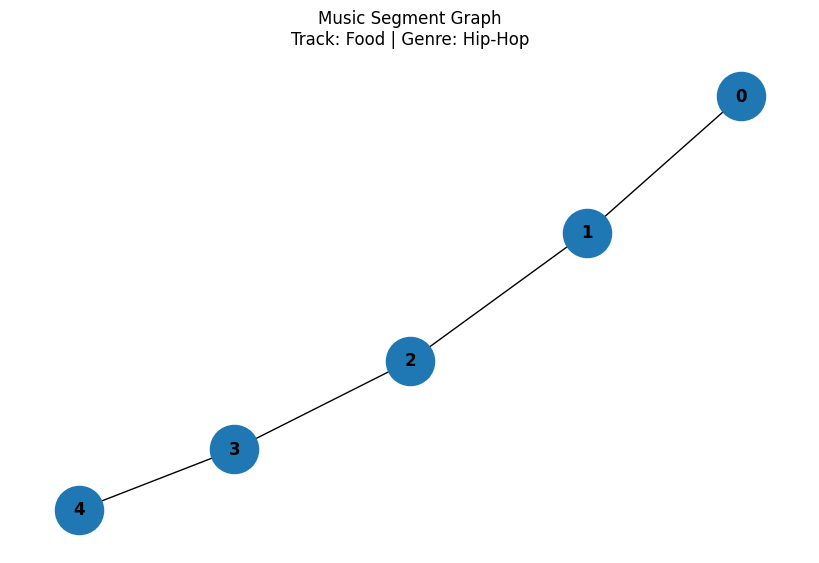

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Graph
G = nx.Graph()

num_nodes = graph.x.shape[0]

# Nodes
G.add_nodes_from(range(num_nodes))

# Edges
edges_np = graph.edge_index.numpy().T

for source, target in edges_np:
    G.add_edge(int(source), int(target))

# Graph
plt.figure(figsize=(8, 5))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1200,
    font_size=12,
    font_weight="bold"
)

plt.title(
    f"Music Segment Graph\n"
    f"Track: {graph.title} | Genre: {graph.genre}"
)

plt.show()

In [ ]:


print("Node feature matrix shape:", graph.x.shape)

print("\nFirst 3 nodes, first 10 features:")
print(graph.x[:3, :10])

Node feature matrix shape: torch.Size([5, 128])

First 3 nodes, first 10 features:
tensor([[-1.7834, -1.3337, -1.2412, -1.0837, -1.1042, -1.2350, -1.3898, -1.4147,
         -1.7424,  0.3315],
        [ 0.3483, -0.4168, -0.4044, -0.4219, -0.7575, -0.8722, -0.8910, -0.8131,
         -0.3726,  0.9447],
        [ 0.0303, -0.4678, -0.6371, -0.7364, -0.5169, -0.2023,  0.2022,  0.1304,
          0.8110,  1.0882]])


In [ ]:
import os
import glob
import torch
import numpy as np

graph_files = sorted(
    glob.glob(os.path.join(TRAIN_GRAPH_PATH, "*.pt"))
)

node_counts = []
edge_counts = []

for file in graph_files:
    g = torch.load(file, weights_only=False)

    node_counts.append(g.x.shape[0])
    edge_counts.append(g.edge_index.shape[1])

print("Total graphs:", len(graph_files))
print("Minimum nodes:", min(node_counts))
print("Maximum nodes:", max(node_counts))
print("Average nodes:", np.mean(node_counts))

print("\nMinimum edges:", min(edge_counts))
print("Maximum edges:", max(edge_counts))
print("Average edges:", np.mean(edge_counts))

Total graphs: 20
Minimum nodes: 5
Maximum nodes: 6
Average nodes: 5.2

Minimum edges: 8
Maximum edges: 10
Average edges: 8.4


In [ ]:
for file in sorted(graph_files):
    g = torch.load(file, weights_only=False)

    print(
        f"Track ID: {g.track_id:6d} | "
        f"Genre: {g.genre:15s} | "
        f"Label: {g.y.item()} | "
        f"Nodes: {g.x.shape[0]} | "
        f"Title: {g.title}"
    )

Track ID:      2 | Genre: Hip-Hop         | Label: 3 | Nodes: 5 | Title: Food
Track ID:      5 | Genre: Hip-Hop         | Label: 3 | Nodes: 6 | Title: This World
Track ID:     10 | Genre: Pop             | Label: 6 | Nodes: 5 | Title: Freeway
Track ID:    140 | Genre: Folk            | Label: 2 | Nodes: 5 | Title: Queen Of The Wires
Track ID:    141 | Genre: Folk            | Label: 2 | Nodes: 5 | Title: Ohio
Track ID:    190 | Genre: Folk            | Label: 2 | Nodes: 6 | Title: Castle Of Stars
Track ID:    193 | Genre: Folk            | Label: 2 | Nodes: 5 | Title: Here With You
Track ID:    194 | Genre: Folk            | Label: 2 | Nodes: 6 | Title: All I want to Do
Track ID:    197 | Genre: Folk            | Label: 2 | Nodes: 5 | Title: Piano 2
Track ID:    200 | Genre: Folk            | Label: 2 | Nodes: 5 | Title: Baby Come Home
Track ID:    203 | Genre: Folk            | Label: 2 | Nodes: 5 | Title: Song For R
Track ID:    204 | Genre: Folk            | Label: 2 | Nodes: 5 | Ti

In [ ]:
TRAIN_GRAPH_PATH_100 = os.path.join(
    PROJECT_PATH,
    "data",
    "processed",
    "graphs",
    "training_100"
)

os.makedirs(TRAIN_GRAPH_PATH_100, exist_ok=True)

created = 0

for track_id in small_training.index:
    if created >= 100:
        break

    track_info = small_training.loc[track_id]

    genre = track_info[("track", "genre_top")]
    title = track_info[("track", "title")]

    audio_path = get_audio_path(track_id)

    graph = create_music_graph(
        audio_path=audio_path,
        genre=genre,
        track_id=track_id,
        title=title
    )

    graph_file = os.path.join(
        TRAIN_GRAPH_PATH_100,
        f"track_{int(track_id):06d}.pt"
    )

    torch.save(graph, graph_file)

    created += 1

print("Graphs created:", created)
print("Genre classes:", len(small_genre_to_idx))
print("Saved in:", TRAIN_GRAPH_PATH_100)

Graphs created: 100
Genre classes: 8
Saved in: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/training_100


In [ ]:
import glob
import torch
from collections import Counter

graph_files_100 = sorted(
    glob.glob(os.path.join(TRAIN_GRAPH_PATH_100, "*.pt"))
)

genres_100 = []
labels_100 = []

for file in graph_files_100:
    g = torch.load(file, weights_only=False)

    genres_100.append(g.genre)
    labels_100.append(g.y.item())

print("Total graphs:", len(graph_files_100))

print("\nGenre distribution:")
print(Counter(genres_100))

print("\nLabel distribution:")
print(Counter(labels_100))

print("\nLabel mapping:")
for label in sorted(set(labels_100)):
    print(f"{label} -> {small_idx_to_genre[label]}")

Total graphs: 100

Genre distribution:
Counter({'Folk': 35, 'Experimental': 18, 'Rock': 17, 'International': 14, 'Pop': 10, 'Hip-Hop': 5, 'Electronic': 1})

Label distribution:
Counter({2: 35, 1: 18, 7: 17, 5: 14, 6: 10, 3: 5, 0: 1})

Label mapping:
0 -> Electronic
1 -> Experimental
2 -> Folk
3 -> Hip-Hop
5 -> International
6 -> Pop
7 -> Rock


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch
from torch_geometric.data import Data
import librosa
import os

def create_music_graph_v2(
    audio_path,
    genre,
    track_id,
    title,
    similarity_threshold=0.75
):
    audio, sr = librosa.load(
        audio_path,
        sr=22050,
        mono=True
    )

    segment_duration = 5
    segment_samples = int(segment_duration * sr)

    segments = []

    for start in range(0, len(audio), segment_samples):
        end = start + segment_samples
        segment = audio[start:end]

        if len(segment) == segment_samples:
            segments.append(segment)

    segment_features = []

    for segment in segments:
        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=128
        )

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        feature_vector = np.mean(
            mel_db,
            axis=1
        )

        segment_features.append(feature_vector)

    segment_features = np.array(segment_features)

    scaler = StandardScaler()

    segment_features_scaled = scaler.fit_transform(
        segment_features
    )

    num_nodes = len(segment_features_scaled)

    edge_set = set()

    # Add temporal edges
    for i in range(num_nodes - 1):
        edge_set.add((i, i + 1))
        edge_set.add((i + 1, i))

    # Calculate cosine similarity
    similarity_matrix = cosine_similarity(
        segment_features_scaled
    )

    # Add similarity edges
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):

            if similarity_matrix[i, j] >= similarity_threshold:
                edge_set.add((i, j))
                edge_set.add((j, i))

    edges = np.array(
        list(edge_set),
        dtype=np.int64
    )

    if len(edges) > 0:
        edge_index = torch.tensor(
            edges.T,
            dtype=torch.long
        )
    else:
        edge_index = torch.empty(
            (2, 0),
            dtype=torch.long
        )

    x = torch.tensor(
        segment_features_scaled,
        dtype=torch.float
    )

    numeric_label = small_genre_to_idx[genre]

    y = torch.tensor(
        [numeric_label],
        dtype=torch.long
    )

    data = Data(
        x=x,
        edge_index=edge_index,
        y=y
    )

    data.genre = genre
    data.track_id = int(track_id)
    data.title = title

    return data

In [ ]:
test_graph_v2 = create_music_graph_v2(
    audio_path=audio_path,
    genre=track_info[("track", "genre_top")],
    track_id=track_id,
    title=track_info[("track", "title")]
)

print(test_graph_v2)

print("\nNode features:", test_graph_v2.x.shape)
print("Edges:", test_graph_v2.edge_index.shape)
print("Label:", test_graph_v2.y.item())
print("Genre:", test_graph_v2.genre)
print("Track ID:", test_graph_v2.track_id)
print("Title:", test_graph_v2.title)

Data(x=[5, 128], edge_index=[2, 8], y=[1], genre='Rock', track_id=2096, title='So Thereby...and furthermore...thus henceforth...Mono')

Node features: torch.Size([5, 128])
Edges: torch.Size([2, 8])
Label: 7
Genre: Rock
Track ID: 2096
Title: So Thereby...and furthermore...thus henceforth...Mono


In [ ]:
# Compare the original and improved graph construction

comparison_ids = list(small_training.index[:20])

for tid in comparison_ids:
    info = small_training.loc[tid]

    genre = info[("track", "genre_top")]
    title = info[("track", "title")]
    audio_path = get_audio_path(tid)

    graph_v1 = create_music_graph(
        audio_path=audio_path,
        genre=genre,
        track_id=tid,
        title=title
    )

    graph_v2 = create_music_graph_v2(
        audio_path=audio_path,
        genre=genre,
        track_id=tid,
        title=title
    )

    print(
        f"Track {tid}: "
        f"V1 edges = {graph_v1.edge_index.shape[1]}, "
        f"V2 edges = {graph_v2.edge_index.shape[1]}"
    )

Track 2: V1 edges = 8, V2 edges = 8
Track 5: V1 edges = 10, V2 edges = 10
Track 10: V1 edges = 8, V2 edges = 8
Track 140: V1 edges = 8, V2 edges = 8
Track 141: V1 edges = 8, V2 edges = 8
Track 190: V1 edges = 10, V2 edges = 10
Track 193: V1 edges = 8, V2 edges = 8
Track 194: V1 edges = 10, V2 edges = 10
Track 197: V1 edges = 8, V2 edges = 8
Track 200: V1 edges = 8, V2 edges = 8
Track 203: V1 edges = 8, V2 edges = 8
Track 204: V1 edges = 8, V2 edges = 8
Track 207: V1 edges = 8, V2 edges = 8
Track 210: V1 edges = 10, V2 edges = 10
Track 211: V1 edges = 8, V2 edges = 8
Track 212: V1 edges = 8, V2 edges = 8
Track 213: V1 edges = 8, V2 edges = 8
Track 255: V1 edges = 8, V2 edges = 8
Track 256: V1 edges = 8, V2 edges = 8
Track 368: V1 edges = 8, V2 edges = 8


In [ ]:
# Inspect cosine similarity values for one music track

info = small_training.loc[2]

audio_path = get_audio_path(2)

audio, sr = librosa.load(
    audio_path,
    sr=22050,
    mono=True
)

segment_duration = 5
segment_samples = int(segment_duration * sr)

segments = []

for start in range(0, len(audio), segment_samples):
    end = start + segment_samples
    segment = audio[start:end]

    if len(segment) == segment_samples:
        segments.append(segment)

segment_features = []

for segment in segments:
    mel = librosa.feature.melspectrogram(
        y=segment,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    feature_vector = np.mean(
        mel_db,
        axis=1
    )

    segment_features.append(feature_vector)

segment_features = np.array(segment_features)

scaler = StandardScaler()
segment_features_scaled = scaler.fit_transform(segment_features)

similarity_matrix = cosine_similarity(
    segment_features_scaled
)

print("Cosine similarity matrix:")
print(np.round(similarity_matrix, 3))

print("\nMinimum similarity:",
      np.min(similarity_matrix))

print("Maximum similarity:",
      np.max(similarity_matrix))

# Print unique pairwise similarities
pairwise_similarities = []

for i in range(len(segment_features_scaled)):
    for j in range(i + 1, len(segment_features_scaled)):
        pairwise_similarities.append(
            similarity_matrix[i, j]
        )

print("\nPairwise similarities:")
print(np.round(pairwise_similarities, 3))

Cosine similarity matrix:
[[ 1.     0.525 -0.191 -0.772 -0.514]
 [ 0.525  1.     0.002 -0.792 -0.519]
 [-0.191  0.002  1.    -0.032 -0.492]
 [-0.772 -0.792 -0.032  1.     0.36 ]
 [-0.514 -0.519 -0.492  0.36   1.   ]]

Minimum similarity: -0.79229045
Maximum similarity: 1.0000006

Pairwise similarities:
[ 0.525 -0.191 -0.772 -0.514  0.002 -0.792 -0.519 -0.032 -0.492  0.36 ]


In [ ]:
# Analyze pairwise cosine similarity across multiple tracks

all_similarities = []

for tid in comparison_ids:
    audio_path = get_audio_path(tid)

    audio, sr = librosa.load(
        audio_path,
        sr=22050,
        mono=True
    )

    segment_duration = 5
    segment_samples = int(segment_duration * sr)

    segments = []

    for start in range(0, len(audio), segment_samples):
        end = start + segment_samples
        segment = audio[start:end]

        if len(segment) == segment_samples:
            segments.append(segment)

    segment_features = []

    for segment in segments:
        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=128
        )

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        feature_vector = np.mean(
            mel_db,
            axis=1
        )

        segment_features.append(feature_vector)

    segment_features = np.array(segment_features)

    scaler = StandardScaler()
    segment_features_scaled = scaler.fit_transform(segment_features)

    similarity_matrix = cosine_similarity(
        segment_features_scaled
    )

    for i in range(len(segment_features_scaled)):
        for j in range(i + 1, len(segment_features_scaled)):
            all_similarities.append(
                similarity_matrix[i, j]
            )

all_similarities = np.array(all_similarities)

print("Number of pairwise similarities:", len(all_similarities))

print("\nMinimum:", np.min(all_similarities))
print("Maximum:", np.max(all_similarities))
print("Mean:", np.mean(all_similarities))
print("Median:", np.median(all_similarities))

print("\nPercentiles:")
print("25th percentile:", np.percentile(all_similarities, 25))
print("50th percentile:", np.percentile(all_similarities, 50))
print("75th percentile:", np.percentile(all_similarities, 75))
print("90th percentile:", np.percentile(all_similarities, 90))

Number of pairwise similarities: 220

Minimum: -0.9324978
Maximum: 0.7846069
Mean: -0.2169851
Median: -0.22801489

Percentiles:
25th percentile: -0.55263925
50th percentile: -0.22801489
75th percentile: 0.05804686
90th percentile: 0.34345675


In [ ]:
# Set the cosine similarity threshold for graph construction

COSINE_THRESHOLD = 0.35

print("Cosine similarity threshold:", COSINE_THRESHOLD)

Cosine similarity threshold: 0.35


In [ ]:
def create_music_graph_v2(audio_path, genre, track_id, title):
    # Load audio
    audio, sr = librosa.load(
        audio_path,
        sr=22050,
        mono=True
    )

    # Split audio into 5-second segments
    segment_duration = 5
    segment_samples = int(segment_duration * sr)

    segments = []

    for start in range(0, len(audio), segment_samples):
        end = start + segment_samples
        segment = audio[start:end]

        if len(segment) == segment_samples:
            segments.append(segment)

    # Extract one 128-dimensional log-Mel feature vector per segment
    segment_features = []

    for segment in segments:
        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=128
        )

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        feature_vector = np.mean(
            mel_db,
            axis=1
        )

        segment_features.append(feature_vector)

    segment_features = np.array(segment_features)

    # Standardize node features
    scaler = StandardScaler()
    segment_features_scaled = scaler.fit_transform(
        segment_features
    )

    # Create temporal edges
    edges = []

    num_nodes = len(segment_features_scaled)

    for i in range(num_nodes - 1):
        edges.append([i, i + 1])
        edges.append([i + 1, i])

    # Calculate cosine similarity between segments
    similarity_matrix = cosine_similarity(
        segment_features_scaled
    )

    # Add similarity-based edges
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):

            if similarity_matrix[i, j] >= COSINE_THRESHOLD:
                edges.append([i, j])
                edges.append([j, i])

    # Convert features and edges to PyTorch tensors
    x = torch.tensor(
        segment_features_scaled,
        dtype=torch.float
    )

    edge_index = torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()

    # Convert genre to numeric label
    numeric_label = small_genre_to_idx[genre]

    y = torch.tensor(
        [numeric_label],
        dtype=torch.long
    )

    # Create PyTorch Geometric graph
    graph = Data(
        x=x,
        edge_index=edge_index,
        y=y
    )

    # Store metadata
    graph.genre = genre
    graph.track_id = int(track_id)
    graph.title = title

    return graph


print("Updated graph function with cosine threshold:", COSINE_THRESHOLD)

Updated graph function with cosine threshold: 0.35


In [ ]:
# Compare original and improved graph construction

for tid in comparison_ids:
    info = small_training.loc[tid]

    genre = info[("track", "genre_top")]
    title = info[("track", "title")]
    audio_path = get_audio_path(tid)

    graph_v1 = create_music_graph(
        audio_path=audio_path,
        genre=genre,
        track_id=tid,
        title=title
    )

    graph_v2 = create_music_graph_v2(
        audio_path=audio_path,
        genre=genre,
        track_id=tid,
        title=title
    )

    extra_edges = (
        graph_v2.edge_index.shape[1]
        - graph_v1.edge_index.shape[1]
    )

    print(
        f"Track {tid}: "
        f"V1 edges = {graph_v1.edge_index.shape[1]}, "
        f"V2 edges = {graph_v2.edge_index.shape[1]}, "
        f"Extra similarity edges = {extra_edges}"
    )

Track 2: V1 edges = 8, V2 edges = 12, Extra similarity edges = 4
Track 5: V1 edges = 10, V2 edges = 10, Extra similarity edges = 0
Track 10: V1 edges = 8, V2 edges = 8, Extra similarity edges = 0
Track 140: V1 edges = 8, V2 edges = 12, Extra similarity edges = 4
Track 141: V1 edges = 8, V2 edges = 10, Extra similarity edges = 2
Track 190: V1 edges = 10, V2 edges = 10, Extra similarity edges = 0
Track 193: V1 edges = 8, V2 edges = 12, Extra similarity edges = 4
Track 194: V1 edges = 10, V2 edges = 20, Extra similarity edges = 10
Track 197: V1 edges = 8, V2 edges = 10, Extra similarity edges = 2
Track 200: V1 edges = 8, V2 edges = 8, Extra similarity edges = 0
Track 203: V1 edges = 8, V2 edges = 8, Extra similarity edges = 0
Track 204: V1 edges = 8, V2 edges = 8, Extra similarity edges = 0
Track 207: V1 edges = 8, V2 edges = 10, Extra similarity edges = 2
Track 210: V1 edges = 10, V2 edges = 12, Extra similarity edges = 2
Track 211: V1 edges = 8, V2 edges = 8, Extra similarity edges = 0


In [ ]:
# Create directory for improved training graphs

TRAIN_GRAPH_PATH_100_V2 = os.path.join(
    PROJECT_PATH,
    "data",
    "processed",
    "graphs",
    "training_100_v2"
)

os.makedirs(
    TRAIN_GRAPH_PATH_100_V2,
    exist_ok=True
)

created = 0

for track_id in small_training.index[:100]:

    track_info = small_training.loc[track_id]

    genre = track_info[("track", "genre_top")]
    title = track_info[("track", "title")]
    audio_path = get_audio_path(track_id)

    graph = create_music_graph_v2(
        audio_path=audio_path,
        genre=genre,
        track_id=track_id,
        title=title
    )

    graph_file = os.path.join(
        TRAIN_GRAPH_PATH_100_V2,
        f"track_{int(track_id):06d}.pt"
    )

    torch.save(
        graph,
        graph_file
    )

    created += 1

print("Improved graphs created:", created)
print("Cosine threshold:", COSINE_THRESHOLD)
print("Saved in:", TRAIN_GRAPH_PATH_100_V2)

Improved graphs created: 100
Cosine threshold: 0.35
Saved in: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/training_100_v2


In [ ]:
# Verify the improved training graph dataset

v2_files = [
    f for f in os.listdir(TRAIN_GRAPH_PATH_100_V2)
    if f.endswith(".pt")
]

graphs_v2 = []

for file in v2_files:
    graph = torch.load(
        os.path.join(TRAIN_GRAPH_PATH_100_V2, file),
        weights_only=False
    )
    graphs_v2.append(graph)

print("Total V2 graphs:", len(graphs_v2))

# Genre distribution
genre_counts = Counter(
    graph.genre for graph in graphs_v2
)

print("\nGenre distribution:")
for genre, count in genre_counts.items():
    print(f"{genre}: {count}")

# Label distribution
label_counts = Counter(
    graph.y.item() for graph in graphs_v2
)

print("\nNumeric label distribution:")
for label, count in sorted(label_counts.items()):
    print(f"{label}: {count}")

# Graph size statistics
node_counts = [
    graph.x.shape[0] for graph in graphs_v2
]

edge_counts = [
    graph.edge_index.shape[1] for graph in graphs_v2
]

print("\nGraph statistics:")
print("Minimum nodes:", min(node_counts))
print("Maximum nodes:", max(node_counts))
print("Average nodes:", np.mean(node_counts))

print("Minimum edges:", min(edge_counts))
print("Maximum edges:", max(edge_counts))
print("Average edges:", np.mean(edge_counts))

# Count graphs that received similarity edges
temporal_edges = [
    2 * (graph.x.shape[0] - 1)
    for graph in graphs_v2
]

graphs_with_similarity = sum(
    edge_count > temporal
    for edge_count, temporal in zip(edge_counts, temporal_edges)
)

print(
    "\nGraphs with additional similarity edges:",
    graphs_with_similarity
)

print(
    "Graphs with temporal edges only:",
    len(graphs_v2) - graphs_with_similarity
)

Total V2 graphs: 100

Genre distribution:
Hip-Hop: 5
Pop: 10
Folk: 35
Rock: 17
Experimental: 18
International: 14
Electronic: 1

Numeric label distribution:
0: 1
1: 18
2: 35
3: 5
5: 14
6: 10
7: 17

Graph statistics:
Minimum nodes: 5
Maximum nodes: 6
Average nodes: 5.33
Minimum edges: 8
Maximum edges: 20
Average edges: 11.64

Graphs with additional similarity edges: 74
Graphs with temporal edges only: 26


In [ ]:
# Import GraphSAGE and global mean pooling

import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv
from torch_geometric.nn import global_mean_pool

print("GraphSAGE imports successful!")

GraphSAGE imports successful!


In [ ]:
class GraphSAGE(nn.Module):

    def __init__(
        self,
        input_dim=128,
        hidden_dim=64,
        embedding_dim=32,
        num_classes=8
    ):
        super().__init__()

        # GraphSAGE layers
        self.conv1 = SAGEConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = SAGEConv(
            hidden_dim,
            embedding_dim
        )

        # Final genre classifier
        self.classifier = nn.Linear(
            embedding_dim,
            num_classes
        )

    def forward(self, x, edge_index, batch):

        # First GraphSAGE layer
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        # Second GraphSAGE layer
        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)

        # Convert node representations into graph representation
        graph_embedding = global_mean_pool(
            x,
            batch
        )

        # Predict genre
        output = self.classifier(
            graph_embedding
        )

        return output, graph_embedding


model = GraphSAGE()

print(model)

GraphSAGE(
  (conv1): SAGEConv(128, 64, aggr=mean)
  (conv2): SAGEConv(64, 32, aggr=mean)
  (classifier): Linear(in_features=32, out_features=8, bias=True)
)


In [ ]:
from torch_geometric.data import Batch

# Load one saved graph
graph_files = sorted(
    glob.glob(
        "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/training_100_v2/*.pt"
    )
)

sample_graph = torch.load(
    graph_files[0],
    weights_only=False
)

# Create a batch containing one graph
batch = Batch.from_data_list([sample_graph])

# Run the model
model.eval()

with torch.no_grad():
    output, graph_embedding = model(
        batch.x,
        batch.edge_index,
        batch.batch
    )

print("Graph:", sample_graph)
print("Output shape:", output.shape)
print("Graph embedding shape:", graph_embedding.shape)
print("Predicted class:", output.argmax(dim=1).item())

Graph: Data(x=[5, 128], edge_index=[2, 12], y=[1], genre='Hip-Hop', track_id=2, title='Food')
Output shape: torch.Size([1, 8])
Graph embedding shape: torch.Size([1, 32])
Predicted class: 2


In [ ]:
from collections import defaultdict

# Group graph files by genre
graphs_by_class = defaultdict(list)

for file_path in graph_files:
    graph = torch.load(
        file_path,
        weights_only=False
    )

    graphs_by_class[int(graph.y.item())].append(file_path)

# Display available graphs for each class
print("Available graphs by class:")

for class_idx in sorted(graphs_by_class):
    print(
        class_idx,
        "->",
        small_idx_to_genre[class_idx],
        ":",
        len(graphs_by_class[class_idx])
    )

# Select up to 10 graphs from each class
balanced_files = []

for class_idx in range(8):
    selected = graphs_by_class[class_idx][:10]
    balanced_files.extend(selected)

print("\nTotal balanced graphs:", len(balanced_files))

Available graphs by class:
0 -> Electronic : 1
1 -> Experimental : 18
2 -> Folk : 35
3 -> Hip-Hop : 5
5 -> International : 14
6 -> Pop : 10
7 -> Rock : 17

Total balanced graphs: 56


In [ ]:
# Get the full FMA-small training tracks

small_training = tracks[
    tracks[("set", "split")] == "training"
].copy()

print("Total training tracks:", len(small_training))

# Count tracks in each genre
genre_counts = (
    small_training[("track", "genre_top")]
    .value_counts()
)

print("\nTraining tracks by genre:")
print(genre_counts)

Total training tracks: 84353

Training tracks by genre:
(track, genre_top)
Rock                   11394
Experimental            8557
Electronic              7662
Hip-Hop                 2910
Folk                    2275
Pop                     1815
Instrumental            1579
International           1124
Classical               1069
Jazz                     462
Old-Time / Historic      445
Spoken                   278
Country                  158
Soul-RnB                 112
Blues                     88
Easy Listening            15
Name: count, dtype: int64


In [ ]:
# Define the 8 FMA-small genres
fma_small_genres = [
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Pop",
    "Rock"
]

# Filter the training metadata to only the 8 FMA-small genres
fma_small_training = small_training[
    small_training[("track", "genre_top")].isin(fma_small_genres)
].copy()

print("FMA-small training tracks:", len(fma_small_training))

print("\nFMA-small genre distribution:")
print(
    fma_small_training[("track", "genre_top")]
    .value_counts()
    .sort_index()
)

FMA-small training tracks: 37316

FMA-small genre distribution:
(track, genre_top)
Electronic        7662
Experimental      8557
Folk              2275
Hip-Hop           2910
Instrumental      1579
International     1124
Pop               1815
Rock             11394
Name: count, dtype: int64


In [ ]:
# Get all available FMA-small audio track IDs
available_track_ids = set()

for root, dirs, files in os.walk("/content/fma_small"):
    for filename in files:
        if filename.lower().endswith(".mp3"):
            try:
                track_id = int(os.path.splitext(filename)[0])
                available_track_ids.add(track_id)
            except ValueError:
                pass

print("Available FMA-small audio files:", len(available_track_ids))

# Keep only metadata rows whose audio files actually exist
available_training = fma_small_training[
    fma_small_training.index.isin(available_track_ids)
].copy()

print("Available training tracks:", len(available_training))

# Select 10 tracks from each of the 8 genres
balanced_track_ids = []

for genre in fma_small_genres:
    genre_tracks = available_training[
        available_training[("track", "genre_top")] == genre
    ]

    selected_ids = genre_tracks.index[:10].tolist()
    balanced_track_ids.extend(selected_ids)

    print(
        genre,
        "->",
        len(selected_ids),
        "tracks"
    )

print("\nTotal selected tracks:", len(balanced_track_ids))

Available FMA-small audio files: 8000
Available training tracks: 6400
Electronic -> 10 tracks
Experimental -> 10 tracks
Folk -> 10 tracks
Hip-Hop -> 10 tracks
Instrumental -> 10 tracks
International -> 10 tracks
Pop -> 10 tracks
Rock -> 10 tracks

Total selected tracks: 80


In [ ]:
# Create a DataFrame for the selected tracks
balanced_training = available_training.loc[
    balanced_track_ids
].copy()

# Display the selected class distribution
selected_distribution = (
    balanced_training[("track", "genre_top")]
    .value_counts()
    .sort_index()
)

print("Selected track distribution:")
print(selected_distribution)

print("\nTotal selected tracks:", len(balanced_training))

Selected track distribution:
(track, genre_top)
Electronic       10
Experimental     10
Folk             10
Hip-Hop          10
Instrumental     10
International    10
Pop              10
Rock             10
Name: count, dtype: int64

Total selected tracks: 80


In [ ]:
import inspect

print(inspect.signature(create_music_graph_v2))

(audio_path, genre, track_id, title)


In [ ]:
# Find the actual audio file for the first selected track

track_id = balanced_track_ids[0]

matches = glob.glob(
    f"/content/fma_small/**/{track_id:06d}.mp3",
    recursive=True
)

print("Track ID:", track_id)
print("Number of matches:", len(matches))

if matches:
    print("Actual audio path:")
    print(matches[0])
else:
    print("Audio file not found!")

Track ID: 1482
Number of matches: 1
Actual audio path:
/content/fma_small/001/001482.mp3


In [ ]:
# Step 1: Load the selected audio file

import librosa
import numpy as np

audio_path = matches[0]

audio, sr = librosa.load(
    audio_path,
    sr=22050,
    mono=True
)

print("Audio path:", audio_path)
print("Sample rate:", sr)
print("Number of samples:", len(audio))
print("Duration:", round(len(audio) / sr, 2), "seconds")

Audio path: /content/fma_small/001/001482.mp3
Sample rate: 22050
Number of samples: 660984
Duration: 29.98 seconds


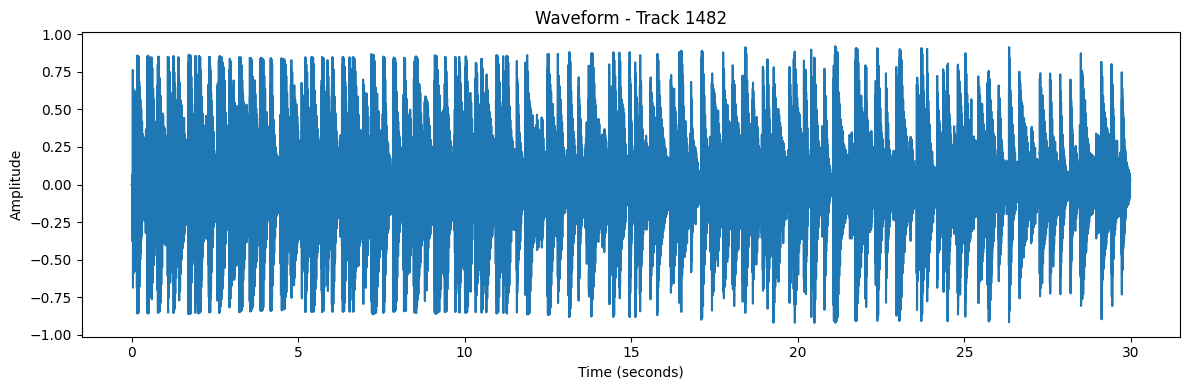

In [ ]:
# Step 2: Visualize the audio waveform

import matplotlib.pyplot as plt

time = np.arange(len(audio)) / sr

plt.figure(figsize=(12, 4))

plt.plot(time, audio)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.title(
    f"Waveform - Track {track_id}"
)

plt.tight_layout()
plt.show()

In [ ]:
# Step 3: Split the audio into 5-second segments

segment_duration = 5
segment_samples = int(segment_duration * sr)

segments = []

for start in range(0, len(audio), segment_samples):

    end = start + segment_samples

    segment = audio[start:end]

    # Keep only complete 5-second segments
    if len(segment) == segment_samples:
        segments.append(segment)

print("Total complete segments:", len(segments))
print("Each segment duration:", segment_duration, "seconds")

Total complete segments: 5
Each segment duration: 5 seconds


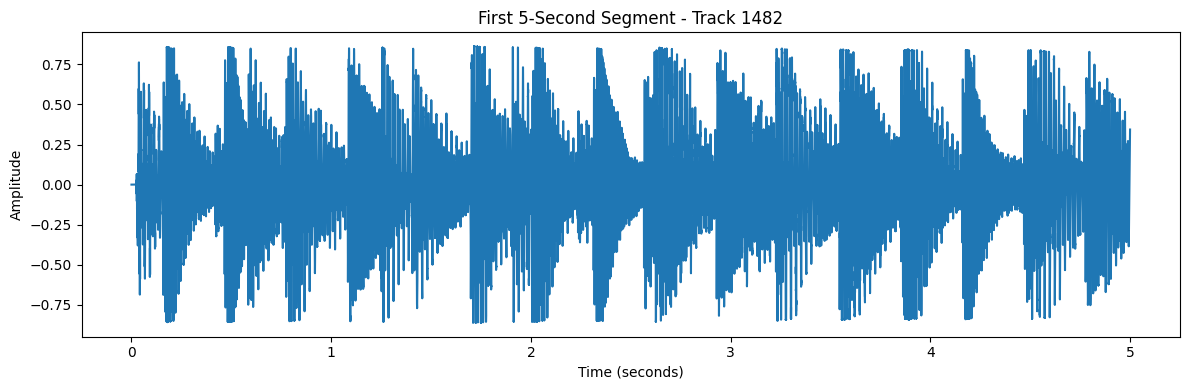

In [ ]:
# Step 4: Visualize the first audio segment

first_segment = segments[0]

segment_time = np.arange(
    len(first_segment)
) / sr

plt.figure(figsize=(12, 4))

plt.plot(segment_time, first_segment)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.title(
    f"First 5-Second Segment - Track {track_id}"
)

plt.tight_layout()
plt.show()

In [ ]:
# Step 5: Extract a 128-bin log-Mel spectrogram

mel = librosa.feature.melspectrogram(
    y=first_segment,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

print("Mel spectrogram shape:", mel.shape)
print("Log-Mel shape:", mel_db.shape)

Mel spectrogram shape: (128, 216)
Log-Mel shape: (128, 216)


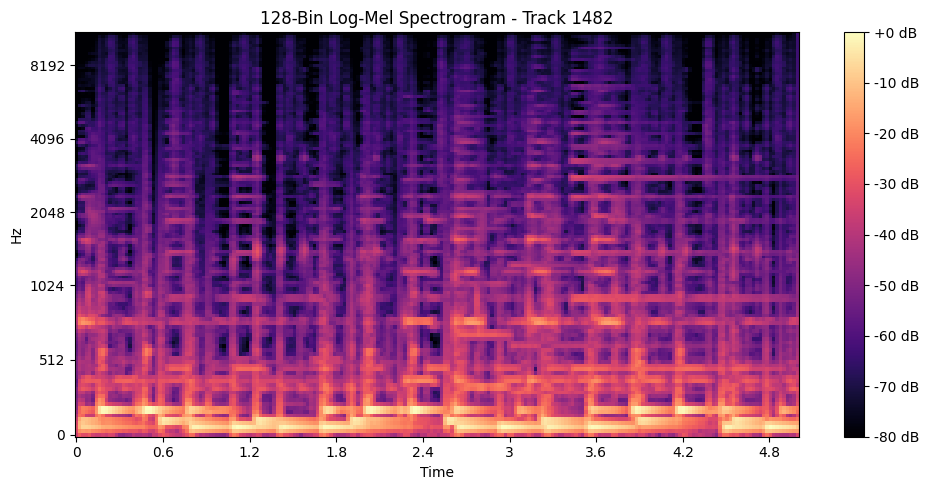

In [ ]:
# Step 6: Visualize the log-Mel spectrogram

plt.figure(figsize=(10, 5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.title(
    f"128-Bin Log-Mel Spectrogram - Track {track_id}"
)

plt.tight_layout()
plt.show()

In [ ]:
# Step 7: Convert the log-Mel spectrogram into a 128-dimensional feature vector

feature_vector = np.mean(
    mel_db,
    axis=1
)

print("Feature vector shape:", feature_vector.shape)
print("Feature vector dimension:", len(feature_vector))

Feature vector shape: (128,)
Feature vector dimension: 128


In [ ]:
# Step 8: Extract 128-dimensional log-Mel features from all segments

segment_features = []

for segment in segments:

    # Extract Mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=segment,
        sr=sr,
        n_mels=128
    )

    # Convert to decibel scale
    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    # Average across time frames
    feature_vector = np.mean(
        mel_db,
        axis=1
    )

    segment_features.append(feature_vector)

segment_features = np.array(
    segment_features
)

print(
    "Segment feature matrix shape:",
    segment_features.shape
)

Segment feature matrix shape: (5, 128)


In [ ]:
# Step 9: Normalize segment features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

segment_features_scaled = scaler.fit_transform(
    segment_features
)

print(
    "Normalized feature matrix shape:",
    segment_features_scaled.shape
)

print(
    "Mean:",
    np.mean(segment_features_scaled)
)

print(
    "Standard deviation:",
    np.std(segment_features_scaled)
)

Normalized feature matrix shape: (5, 128)
Mean: 0.0
Standard deviation: 1.0


In [ ]:
# Step 10: Create graph node features

import torch

x = torch.tensor(
    segment_features_scaled,
    dtype=torch.float
)

print("Node feature tensor:")
print(x)

print(
    "Node feature shape:",
    x.shape
)

Node feature tensor:
tensor([[-1.5985e-01,  8.4300e-01,  9.4542e-01,  1.7413e-01, -1.2522e+00,
         -2.9770e-01,  8.9860e-01,  1.0130e+00,  9.7943e-01,  1.1781e+00,
          1.3697e+00,  1.6283e+00,  1.2823e+00,  1.6698e+00,  1.6675e+00,
          1.7030e+00,  1.6622e+00,  1.6703e+00,  1.6715e+00,  1.5964e+00,
          1.6605e+00,  1.6894e+00,  1.7532e+00,  1.8379e+00,  1.7600e+00,
          1.7666e+00,  1.8069e+00,  1.8962e+00,  1.8628e+00,  1.7561e+00,
          1.7822e+00,  1.8111e+00,  1.8768e+00,  1.9626e+00,  1.8915e+00,
          1.6199e+00,  1.5895e+00,  1.6549e+00,  1.7128e+00,  1.7340e+00,
          1.6628e+00,  1.6889e+00,  1.7955e+00,  1.8354e+00,  1.6495e+00,
          1.7897e+00,  1.8945e+00,  1.8029e+00,  1.5573e+00,  1.4546e+00,
          1.6160e+00,  1.5137e+00,  1.6822e+00,  1.7971e+00,  1.6493e+00,
          1.6763e+00,  1.6815e+00,  1.4263e+00,  1.6598e+00,  1.7392e+00,
          1.6289e+00,  1.6629e+00,  1.5799e+00,  1.6793e+00,  1.7017e+00,
          1.8357e

In [ ]:
# Step 11: Create bidirectional temporal edges

edges = []

for i in range(len(segments) - 1):

    # Connect consecutive segments
    edges.append([i, i + 1])
    edges.append([i + 1, i])

print("Temporal edges:")
print(edges)

print("Number of directed edges:", len(edges))

Temporal edges:
[[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [4, 3]]
Number of directed edges: 8


In [ ]:
# Step 12: Convert edges to PyTorch Geometric format

edge_index = torch.tensor(
    edges,
    dtype=torch.long
).T

print("Edge index:")
print(edge_index)

print(
    "Edge index shape:",
    edge_index.shape
)

Edge index:
tensor([[0, 1, 1, 2, 2, 3, 3, 4],
        [1, 0, 2, 1, 3, 2, 4, 3]])
Edge index shape: torch.Size([2, 8])


In [ ]:
# Step 13: Create a PyTorch Geometric graph

from torch_geometric.data import Data

numeric_label = small_genre_to_idx[
    small_training.loc[track_id][("track", "genre_top")]
]

graph = Data(
    x=x,
    edge_index=edge_index,
    y=torch.tensor(
        [numeric_label],
        dtype=torch.long
    )
)

graph.track_id = int(track_id)

graph.genre = small_training.loc[
    track_id
][("track", "genre_top")]

graph.title = small_training.loc[
    track_id
][("track", "title")]

print(graph)

Data(x=[5, 128], edge_index=[2, 8], y=[1], track_id=1482, genre='Electronic', title='Reindeer Dance')


In [ ]:
# Step 14: Verify the generated graph

print("----- Graph Verification -----")

print("Track ID:", graph.track_id)
print("Genre:", graph.genre)
print("Title:", graph.title)

print("Node feature shape:", graph.x.shape)
print("Edge index shape:", graph.edge_index.shape)

print("Numeric label:", graph.y.item())

print(
    "Mapped genre:",
    small_idx_to_genre[graph.y.item()]
)

----- Graph Verification -----
Track ID: 1482
Genre: Electronic
Title: Reindeer Dance
Node feature shape: torch.Size([5, 128])
Edge index shape: torch.Size([2, 8])
Numeric label: 0
Mapped genre: Electronic


In [ ]:
# Step 15: Create similarity-based edges between audio segments

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Calculate cosine similarity between all segment feature vectors
similarity_matrix = cosine_similarity(
    segment_features_scaled
)

print("Similarity matrix shape:", similarity_matrix.shape)

# Set the number of nearest neighbors
k = min(2, len(segments) - 1)

similarity_edges = []

for i in range(len(segments)):

    # Get similarity scores for the current node
    similarities = similarity_matrix[i].copy()

    # Exclude the node itself
    similarities[i] = -np.inf

    # Select the top-k most similar nodes
    nearest_nodes = np.argsort(similarities)[-k:]

    for j in nearest_nodes:

        # Add bidirectional similarity edges
        similarity_edges.append([i, j])
        similarity_edges.append([j, i])

print("Number of similarity edges:", len(similarity_edges))
print("Similarity edges:")
print(similarity_edges)

Similarity matrix shape: (5, 5)
Number of similarity edges: 20
Similarity edges:
[[0, np.int64(2)], [np.int64(2), 0], [0, np.int64(1)], [np.int64(1), 0], [1, np.int64(4)], [np.int64(4), 1], [1, np.int64(0)], [np.int64(0), 1], [2, np.int64(4)], [np.int64(4), 2], [2, np.int64(3)], [np.int64(3), 2], [3, np.int64(2)], [np.int64(2), 3], [3, np.int64(4)], [np.int64(4), 3], [4, np.int64(2)], [np.int64(2), 4], [4, np.int64(3)], [np.int64(3), 4]]


In [ ]:
# Step 16: Merge temporal and similarity edges

# Combine temporal edges and similarity edges
all_edges = edges + similarity_edges

# Convert each edge to a tuple for duplicate removal
unique_edges = list(
    set(
        tuple(edge)
        for edge in all_edges
    )
)

# Convert back to a list of lists
unique_edges = [
    list(edge)
    for edge in unique_edges
]

print("Total edges before removing duplicates:", len(all_edges))
print("Total unique edges:", len(unique_edges))

print("\nMerged edges:")
print(unique_edges)

Total edges before removing duplicates: 28
Total unique edges: 14

Merged edges:
[[0, 1], [2, np.int64(4)], [1, 2], [2, 1], [3, 4], [4, 3], [np.int64(2), 0], [1, np.int64(4)], [np.int64(4), 2], [2, 3], [0, np.int64(2)], [1, 0], [3, 2], [np.int64(4), 1]]


In [ ]:
# Step 17: Create the final edge index

final_edge_index = torch.tensor(
    unique_edges,
    dtype=torch.long
).T.contiguous()

print("Final edge index:")
print(final_edge_index)

print(
    "Final edge index shape:",
    final_edge_index.shape
)

print(
    "Number of final directed edges:",
    final_edge_index.shape[1]
)

Final edge index:
tensor([[0, 2, 1, 2, 3, 4, 2, 1, 4, 2, 0, 1, 3, 4],
        [1, 4, 2, 1, 4, 3, 0, 4, 2, 3, 2, 0, 2, 1]])
Final edge index shape: torch.Size([2, 14])
Number of final directed edges: 14


In [ ]:
# Step 18: Create the final audio graph with temporal and similarity edges

final_graph = Data(
    x=x,
    edge_index=final_edge_index,
    y=torch.tensor(
        [numeric_label],
        dtype=torch.long
    )
)

final_graph.track_id = int(track_id)

final_graph.genre = small_training.loc[
    track_id
][("track", "genre_top")]

final_graph.title = small_training.loc[
    track_id
][("track", "title")]

print("----- Final Graph -----")

print(final_graph)

print("Track ID:", final_graph.track_id)
print("Genre:", final_graph.genre)
print("Title:", final_graph.title)

print("Node feature shape:", final_graph.x.shape)
print("Edge index shape:", final_graph.edge_index.shape)

print("Number of nodes:", final_graph.num_nodes)
print("Number of edges:", final_graph.num_edges)

print("Label:", final_graph.y.item())

----- Final Graph -----
Data(x=[5, 128], edge_index=[2, 14], y=[1], track_id=1482, genre='Electronic', title='Reindeer Dance')
Track ID: 1482
Genre: Electronic
Title: Reindeer Dance
Node feature shape: torch.Size([5, 128])
Edge index shape: torch.Size([2, 14])
Number of nodes: 5
Number of edges: 14
Label: 0


In [ ]:
# Step 19: Create a reusable function for audio graph generation

from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data
import numpy as np
import torch
import librosa


def create_audio_graph(
    audio_path,
    track_id,
    genre,
    title,
    scaler=None,
    sr=22050,
    segment_duration=5,
    n_mels=128,
    k_similarity=2
):
    # Load audio
    audio, sr = librosa.load(
        audio_path,
        sr=sr,
        mono=True
    )

    # Calculate segment size
    segment_samples = int(
        segment_duration * sr
    )

    # Split audio into complete segments
    segments = []

    for start in range(
        0,
        len(audio),
        segment_samples
    ):

        end = start + segment_samples

        segment = audio[start:end]

        # Keep only complete segments
        if len(segment) == segment_samples:
            segments.append(segment)

    # Stop if there are not enough segments
    if len(segments) < 2:
        return None

    # Extract features from all segments
    segment_features = []

    for segment in segments:

        # Extract Mel spectrogram
        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=n_mels
        )

        # Convert to decibel scale
        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        # Average across time
        feature_vector = np.mean(
            mel_db,
            axis=1
        )

        segment_features.append(
            feature_vector
        )

    segment_features = np.array(
        segment_features
    )

    # Apply the provided scaler
    if scaler is not None:

        segment_features_scaled = scaler.transform(
            segment_features
        )

    else:

        segment_features_scaled = segment_features

    # Convert node features to tensor
    x = torch.tensor(
        segment_features_scaled,
        dtype=torch.float
    )

    # Create temporal edges
    temporal_edges = []

    for i in range(len(segments) - 1):

        temporal_edges.append(
            [i, i + 1]
        )

        temporal_edges.append(
            [i + 1, i]
        )

    # Calculate cosine similarity
    similarity_matrix = cosine_similarity(
        segment_features_scaled
    )

    # Create similarity edges
    similarity_edges = []

    k = min(
        k_similarity,
        len(segments) - 1
    )

    for i in range(len(segments)):

        similarities = similarity_matrix[i].copy()

        # Exclude self similarity
        similarities[i] = -np.inf

        nearest_nodes = np.argsort(
            similarities
        )[-k:]

        for j in nearest_nodes:

            similarity_edges.append(
                [i, int(j)]
            )

            similarity_edges.append(
                [int(j), i]
            )

    # Merge all edges
    all_edges = (
        temporal_edges
        + similarity_edges
    )

    # Remove duplicate edges
    unique_edges = list(
        set(
            tuple(edge)
            for edge in all_edges
        )
    )

    unique_edges = [
        list(edge)
        for edge in unique_edges
    ]

    # Convert edges to PyG format
    edge_index = torch.tensor(
        unique_edges,
        dtype=torch.long
    ).T.contiguous()

    # Create graph
    graph = Data(
        x=x,
        edge_index=edge_index,
        y=torch.tensor(
            [genre],
            dtype=torch.long
        )
    )

    # Store metadata
    graph.track_id = int(track_id)
    graph.genre = genre
    graph.title = title

    return graph

In [ ]:
# Step 20: Test the reusable graph generation function

test_graph = create_audio_graph(
    audio_path=matches[0],
    track_id=track_id,
    genre=numeric_label,
    title=small_training.loc[
        track_id
    ][("track", "title")]
)

print("----- Function Test -----")

print(test_graph)

print("Track ID:", test_graph.track_id)
print("Genre label:", test_graph.y.item())
print("Title:", test_graph.title)

print("Number of nodes:", test_graph.num_nodes)
print("Number of edges:", test_graph.num_edges)
print("Node feature shape:", test_graph.x.shape)
print("Edge index shape:", test_graph.edge_index.shape)

----- Function Test -----
Data(x=[5, 128], edge_index=[2, 14], y=[1], track_id=1482, genre=0, title='Reindeer Dance')
Track ID: 1482
Genre label: 0
Title: Reindeer Dance
Number of nodes: 5
Number of edges: 14
Node feature shape: torch.Size([5, 128])
Edge index shape: torch.Size([2, 14])


In [ ]:
# Step 21: Extract raw segment features from training tracks

import glob
import librosa
import numpy as np
from sklearn.preprocessing import StandardScaler


def extract_segment_features(
    audio_path,
    sr=22050,
    segment_duration=5,
    n_mels=128
):
    # Load audio
    audio, sr = librosa.load(
        audio_path,
        sr=sr,
        mono=True
    )

    # Calculate segment size
    segment_samples = int(
        segment_duration * sr
    )

    segment_features = []

    for start in range(
        0,
        len(audio),
        segment_samples
    ):

        end = start + segment_samples

        segment = audio[start:end]

        # Keep only complete segments
        if len(segment) != segment_samples:
            continue

        # Extract Mel spectrogram
        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=n_mels
        )

        # Convert to decibel scale
        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        # Average across time
        feature_vector = np.mean(
            mel_db,
            axis=1
        )

        segment_features.append(
            feature_vector
        )

    if len(segment_features) == 0:
        return None

    return np.array(
        segment_features
    )


print("Feature extraction function created successfully.")

Feature extraction function created successfully.


In [ ]:
# Step 22: Test feature extraction on a small number of training tracks

test_track_ids = balanced_track_ids[:10]

all_test_features = []

successful_tracks = 0

for tid in test_track_ids:

    matches = glob.glob(
        f"/content/fma_small/**/{tid:06d}.mp3",
        recursive=True
    )

    if not matches:
        continue

    features = extract_segment_features(
        matches[0]
    )

    if features is None:
        continue

    all_test_features.append(
        features
    )

    successful_tracks += 1


if all_test_features:

    all_test_features = np.vstack(
        all_test_features
    )

    print(
        "Successful tracks:",
        successful_tracks
    )

    print(
        "Combined feature matrix shape:",
        all_test_features.shape
    )

else:

    print("No features were extracted.")

Successful tracks: 10
Combined feature matrix shape: (54, 128)


In [ ]:
# Step 23: Fit a global scaler using training features only

training_scaler = StandardScaler()

training_scaler.fit(
    all_test_features
)

print("Training scaler fitted successfully.")

print(
    "Number of features:",
    training_scaler.n_features_in_
)

print(
    "Scaler mean shape:",
    training_scaler.mean_.shape
)

print(
    "Scaler scale shape:",
    training_scaler.scale_.shape
)

Training scaler fitted successfully.
Number of features: 128
Scaler mean shape: (128,)
Scaler scale shape: (128,)


In [ ]:
# Step 24: Create a graph using the training-fitted scaler

scaled_test_graph = create_audio_graph(
    audio_path=matches[0],
    track_id=track_id,
    genre=numeric_label,
    title=small_training.loc[
        track_id
    ][("track", "title")],
    scaler=training_scaler
)

print("----- Scaled Graph Verification -----")

print(scaled_test_graph)

print(
    "Track ID:",
    scaled_test_graph.track_id
)

print(
    "Genre label:",
    scaled_test_graph.y.item()
)

print(
    "Title:",
    scaled_test_graph.title
)

print(
    "Number of nodes:",
    scaled_test_graph.num_nodes
)

print(
    "Number of edges:",
    scaled_test_graph.num_edges
)

print(
    "Node feature shape:",
    scaled_test_graph.x.shape
)

print(
    "Edge index shape:",
    scaled_test_graph.edge_index.shape
)

print(
    "Feature mean:",
    scaled_test_graph.x.mean().item()
)

print(
    "Feature standard deviation:",
    scaled_test_graph.x.std().item()
)

----- Scaled Graph Verification -----
Data(x=[5, 128], edge_index=[2, 14], y=[1], track_id=1482, genre=0, title='Reindeer Dance')
Track ID: 1482
Genre label: 0
Title: Reindeer Dance
Number of nodes: 5
Number of edges: 14
Node feature shape: torch.Size([5, 128])
Edge index shape: torch.Size([2, 14])
Feature mean: 0.15291640162467957
Feature standard deviation: 0.41765764355659485


In [ ]:
# Step 25A: Inspect available track ID variables

candidate_variables = [
    "train_track_ids",
    "small_train_track_ids",
    "balanced_track_ids",
    "small_training",
    "train_ids"
]

for name in candidate_variables:
    if name in globals():
        value = globals()[name]

        print(f"{name}:")
        print("  Type:", type(value))

        try:
            print("  Length:", len(value))
            print("  First 10:", list(value)[:10])
        except:
            print("  Value:", value)

        print()

balanced_track_ids:
  Type: <class 'list'>
  Length: 80
  First 10: [1482, 3573, 4519, 4520, 4521, 4522, 11206, 11262, 11942, 12189]

small_training:
  Type: <class 'pandas.core.frame.DataFrame'>
  Length: 84353
  First 10: [('album', 'comments'), ('album', 'date_created'), ('album', 'date_released'), ('album', 'engineer'), ('album', 'favorites'), ('album', 'id'), ('album', 'information'), ('album', 'listens'), ('album', 'producer'), ('album', 'tags')]



In [ ]:
# Step 25B: Inspect variables related to train/validation/test splits

for name, value in globals().items():
    if any(keyword in name.lower() for keyword in ["train", "val", "test", "split"]):
        if not name.startswith("_"):
            try:
                print(
                    f"{name}: "
                    f"type={type(value).__name__}, "
                    f"length={len(value)}"
                )
            except:
                print(
                    f"{name}: "
                    f"type={type(value).__name__}"
                )

test_graph: type=Data, length=6
split_counts: type=Series, length=3
small_split_counts: type=Series, length=3
small_training: type=DataFrame, length=84353
TRAIN_GRAPH_PATH: type=str, length=68
TRAIN_GRAPH_PATH_100: type=str, length=72
test_graph_v2: type=Data, length=6
TRAIN_GRAPH_PATH_100_V2: type=str, length=75
fma_small_training: type=DataFrame, length=37316
available_training: type=DataFrame, length=6400
balanced_training: type=DataFrame, length=80
test_track_ids: type=list, length=10
all_test_features: type=ndarray, length=54
training_scaler: type=StandardScaler
scaled_test_graph: type=Data, length=6
value: type=list, length=5


In [ ]:
# Step 25C: Inspect the training dataframe structure

print("Columns:")
print(available_training.columns.tolist())

print("\nFirst 5 rows:")
display(available_training.head())

print("\nData types:")
print(available_training.dtypes)

Columns:
[('album', 'comments'), ('album', 'date_created'), ('album', 'date_released'), ('album', 'engineer'), ('album', 'favorites'), ('album', 'id'), ('album', 'information'), ('album', 'listens'), ('album', 'producer'), ('album', 'tags'), ('album', 'title'), ('album', 'tracks'), ('album', 'type'), ('artist', 'active_year_begin'), ('artist', 'active_year_end'), ('artist', 'associated_labels'), ('artist', 'bio'), ('artist', 'comments'), ('artist', 'date_created'), ('artist', 'favorites'), ('artist', 'id'), ('artist', 'latitude'), ('artist', 'location'), ('artist', 'longitude'), ('artist', 'members'), ('artist', 'name'), ('artist', 'related_projects'), ('artist', 'tags'), ('artist', 'website'), ('artist', 'wikipedia_page'), ('set', 'split'), ('set', 'subset'), ('track', 'bit_rate'), ('track', 'comments'), ('track', 'composer'), ('track', 'date_created'), ('track', 'date_recorded'), ('track', 'duration'), ('track', 'favorites'), ('track', 'genre_top'), ('track', 'genres'), ('track', 'ge

album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
140             1  2008-11-26 01:49:59  2007-05-22 00:00:00      NaN   
141             0  2008-11-26 01:49:57  2009-01-16 00:00:00      NaN   

                                                                           \
         favorites  id                                        information   
track_id                                                                    
2                4   1                                            <p></p>   
5                4   1                                            <p></p>   
10               4   6                                                NaN   
140              1  61  <p>Alec K. Redfearn &amp; The Eyesores: Ellen ...   
141              1  60  <p>A full ensamble of strings, drums, electron...   

                                                       ...       track  \
         listens                        producer tags  ... information   
track_id                                               ...               
2           6073                             NaN   []  ...         NaN   
5           6073                             NaN   []  ...         NaN   
10         47632                             NaN   []  ...         NaN   
140         1300  Alec K. Refearn, Rob Pemberton   []  ...         NaN   
141         1304                             NaN   []  ...         NaN   

                                 \
         interest language_code   
track_id                          
2            4656            en   
5            1933            en   
10          54881            en   
140          1593            en   
141           839            en   

                                                                              \
                                                    license listens lyricist   
track_id                                                                       
2         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1293      NaN   
5         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1151      NaN   
10        Attribution-NonCommercial-NoDerivatives (aka M...   50135      NaN   
140       Attribution-Noncommercial-No Derivative Works ...    1299      NaN   
141       Attribution-Noncommercial-No Derivative Works ...     725      NaN   

                                                    
         number publisher tags               title  
track_id                                            
2             3       NaN   []                Food  
5             6       NaN   []          This World  
10            1       NaN   []             Freeway  
140           2       NaN   []  Queen Of The Wires  
141           4       NaN   []                Ohio  

[5 rows x 52 columns]


Data types:
album   comments               int64
        date_created          object
        date_released         object
        engineer              object
        favorites              int64
        id                     int64
        information           object
        listens                int64
        producer              object
        tags                  object
        title                 object
        tracks                 int64
        type                  object
artist  active_year_begin     object
        active_year_end       object
        associated_labels     object
        bio                   object
        comments               int64
        date_created          object
        favorites              int64
        id                     int64
        latitude             float64
        location              object
        longitude            float64
        members               object
        name                  object
        related_projects 

In [ ]:
# Step 25E: Create a robust feature extraction function

def extract_segment_features(audio_path, sr=22050, segment_duration=5):
    try:
        # Check whether the file exists
        if not os.path.isfile(audio_path):
            return None

        # Load audio
        audio, sr = librosa.load(
            audio_path,
            sr=sr,
            mono=True
        )

        # Calculate samples per segment
        samples_per_segment = sr * segment_duration

        # Calculate number of complete segments
        num_segments = len(audio) // samples_per_segment

        # Return None if there are no complete segments
        if num_segments == 0:
            return None

        segment_features = []

        for i in range(num_segments):

            start = i * samples_per_segment
            end = start + samples_per_segment

            segment = audio[start:end]

            # Compute log-Mel spectrogram
            mel = librosa.feature.melspectrogram(
                y=segment,
                sr=sr,
                n_mels=128,
                power=2.0
            )

            # Convert to decibel scale
            log_mel = librosa.power_to_db(
                mel,
                ref=np.max
            )

            # Average over time
            feature_vector = np.mean(
                log_mel,
                axis=1
            )

            segment_features.append(feature_vector)

        return np.array(
            segment_features,
            dtype=np.float32
        )

    except Exception:
        # Skip unreadable or corrupted audio files
        return None


print("Robust feature extraction function created successfully.")

Robust feature extraction function created successfully.


In [ ]:
# Step 25E.1: Import required libraries

import os
import glob
import numpy as np
import librosa

from sklearn.preprocessing import StandardScaler

print("Required libraries imported successfully.")

Required libraries imported successfully.


In [ ]:
# Step 25F.1: Check which training dataframe variables are currently available

print("Checking training dataframe variables...\n")

for name in [
    "available_training",
    "fma_small_training",
    "small_training",
    "balanced_training"
]:
    if name in globals():
        value = globals()[name]

        print(
            f"{name}: "
            f"type={type(value).__name__}, "
            f"shape={getattr(value, 'shape', 'N/A')}"
        )

Checking training dataframe variables...

available_training: type=DataFrame, shape=(6400, 52)
fma_small_training: type=DataFrame, shape=(37316, 52)
small_training: type=DataFrame, shape=(84353, 52)
balanced_training: type=DataFrame, shape=(80, 52)


In [ ]:
# Step 25F: Fit the final scaler from scratch using training tracks only

final_scaler = StandardScaler()

train_track_ids = available_training.index.tolist()

processed_tracks = 0
skipped_tracks = 0

for tid in train_track_ids:

    matches = glob.glob(
        f"/content/fma_small/**/{int(tid):06d}.mp3",
        recursive=True
    )

    if not matches:
        skipped_tracks += 1
        continue

    features = extract_segment_features(
        matches[0]
    )

    if features is None:
        skipped_tracks += 1
        continue

    # Update scaler using training features only
    final_scaler.partial_fit(features)

    processed_tracks += 1

    if processed_tracks % 500 == 0:
        print(
            "Processed training tracks:",
            processed_tracks
        )


print("\n----- Final Scaler Summary -----")

print(
    "Total training tracks:",
    len(train_track_ids)
)

print(
    "Processed training tracks:",
    processed_tracks
)

print(
    "Skipped tracks:",
    skipped_tracks
)

print(
    "Number of features:",
    final_scaler.n_features_in_
)

print(
    "Mean shape:",
    final_scaler.mean_.shape
)

print(
    "Scale shape:",
    final_scaler.scale_.shape
)

Processed training tracks: 500
Processed training tracks: 1000
Processed training tracks: 1500
Processed training tracks: 2000
Processed training tracks: 2500
Processed training tracks: 3000


/tmp/ipykernel_1131/71144048.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_1131/71144048.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_1131/71144048.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.cor

Processed training tracks: 3500


/tmp/ipykernel_1131/71144048.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_1131/71144048.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processed training tracks: 4000
Processed training tracks: 4500
Processed training tracks: 5000
Processed training tracks: 5500


/tmp/ipykernel_1131/71144048.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processed training tracks: 6000

----- Final Scaler Summary -----
Total training tracks: 6400
Processed training tracks: 6394
Skipped tracks: 6
Number of features: 128
Mean shape: (128,)
Scale shape: (128,)


In [ ]:
# Step 26A: Check the current create_audio_graph function signature

import inspect

print(inspect.signature(create_audio_graph))

(audio_path, track_id, genre, title, scaler=None, sr=22050, segment_duration=5, n_mels=128, k_similarity=2)


In [ ]:
# Step 26C: Define the genre-to-label mapping

genre_to_label = {
    "Electronic": 0,
    "Experimental": 1,
    "Folk": 2,
    "Hip-Hop": 3,
    "Instrumental": 4,
    "International": 5,
    "Pop": 6,
    "Rock": 7
}

print("Genre-to-label mapping:")
for genre, label in genre_to_label.items():
    print(f"{label}: {genre}")

Genre-to-label mapping:
0: Electronic
1: Experimental
2: Folk
3: Hip-Hop
4: Instrumental
5: International
6: Pop
7: Rock


In [ ]:
# Step 26D: Update create_audio_graph with numeric genre labels

def create_audio_graph(
    audio_path,
    track_id,
    genre,
    title,
    scaler=None,
    sr=22050,
    segment_duration=5,
    n_mels=128,
    k_similarity=2
):
    # Load audio
    audio, sr = librosa.load(
        audio_path,
        sr=sr,
        mono=True
    )

    # Calculate complete 5-second segments
    samples_per_segment = sr * segment_duration
    num_segments = len(audio) // samples_per_segment

    if num_segments == 0:
        return None

    segment_features = []

    # Extract log-Mel features for each segment
    for i in range(num_segments):

        start = i * samples_per_segment
        end = start + samples_per_segment

        segment = audio[start:end]

        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=n_mels,
            power=2.0
        )

        log_mel = librosa.power_to_db(
            mel,
            ref=np.max
        )

        # Average across time
        feature_vector = np.mean(
            log_mel,
            axis=1
        )

        segment_features.append(
            feature_vector
        )

    segment_features = np.array(
        segment_features,
        dtype=np.float32
    )

    # Apply the training-only scaler
    if scaler is not None:
        segment_features = scaler.transform(
            segment_features
        )

    # Convert features to PyTorch tensor
    x = torch.tensor(
        segment_features,
        dtype=torch.float
    )

    num_nodes = x.shape[0]

    # Create temporal edges
    temporal_edges = []

    for i in range(num_nodes - 1):

        # Forward temporal edge
        temporal_edges.append(
            (i, i + 1)
        )

        # Backward temporal edge
        temporal_edges.append(
            (i + 1, i)
        )

    # Create similarity edges
    similarity_edges = []

    if num_nodes > 1:

        similarity_matrix = cosine_similarity(
            segment_features
        )

        for i in range(num_nodes):

            similarities = similarity_matrix[i].copy()

            # Exclude self-similarity
            similarities[i] = -np.inf

            k = min(
                k_similarity,
                num_nodes - 1
            )

            top_indices = np.argsort(
                similarities
            )[-k:]

            for j in top_indices:

                # Add bidirectional similarity edges
                similarity_edges.append(
                    (i, int(j))
                )

                similarity_edges.append(
                    (int(j), i)
                )

    # Merge temporal and similarity edges
    all_edges = (
        temporal_edges +
        similarity_edges
    )

    # Remove duplicates deterministically
    unique_edges = sorted(
        set(all_edges)
    )

    # Convert edges to PyTorch format
    if unique_edges:

        edge_index = torch.tensor(
            unique_edges,
            dtype=torch.long
        ).T.contiguous()

    else:

        edge_index = torch.empty(
            (2, 0),
            dtype=torch.long
        )

    # Convert genre name to numeric label
    if genre not in genre_to_label:
        raise ValueError(
            f"Unknown genre: {genre}"
        )

    numeric_label = genre_to_label[genre]

    # Create PyG graph
    graph = Data(
        x=x,
        edge_index=edge_index,
        y=torch.tensor(
            [numeric_label],
            dtype=torch.long
        )
    )

    # Store metadata
    graph.track_id = int(track_id)
    graph.genre = genre
    graph.title = str(title)

    return graph


print("create_audio_graph updated successfully.")

create_audio_graph updated successfully.


In [ ]:
# Step 26E: Verify the final scaled graph

track_1482_path = "/content/fma_small/001/001482.mp3"

verified_graph = create_audio_graph(
    audio_path=track_1482_path,
    track_id=1482,
    genre="Electronic",
    title="Reindeer Dance",
    scaler=final_scaler
)

print("----- Final Scaled Graph Verification -----")
print("Graph:", verified_graph)
print("Nodes:", verified_graph.x.shape[0])
print("Features per node:", verified_graph.x.shape[1])
print("Edges:", verified_graph.edge_index.shape[1])
print("Feature mean:", verified_graph.x.mean().item())
print("Feature std:", verified_graph.x.std().item())
print("Label:", verified_graph.y.item())
print("Track ID:", verified_graph.track_id)
print("Genre:", verified_graph.genre)
print("Title:", verified_graph.title)

----- Final Scaled Graph Verification -----
Graph: Data(x=[5, 128], edge_index=[2, 16], y=[1], track_id=1482, genre='Electronic', title='Reindeer Dance')
Nodes: 5
Features per node: 128
Edges: 16
Feature mean: -1.5435296297073364
Feature std: 0.5977814197540283
Label: 0
Track ID: 1482
Genre: Electronic
Title: Reindeer Dance


In [ ]:
# Step 27: Save the final training-only scaler

import os
import joblib

scaler_path = "/content/final_audio_scaler.joblib"

joblib.dump(
    final_scaler,
    scaler_path
)

print("Final scaler saved successfully.")
print("Path:", scaler_path)
print("File exists:", os.path.isfile(scaler_path))
print("File size (KB):", round(os.path.getsize(scaler_path) / 1024, 2))

Final scaler saved successfully.
Path: /content/final_audio_scaler.joblib
File exists: True
File size (KB): 3.6


In [ ]:
# Step 28: Check existing project paths

print("TRAIN_GRAPH_PATH:", globals().get("TRAIN_GRAPH_PATH", "Not found"))
print("TRAIN_GRAPH_PATH_100:", globals().get("TRAIN_GRAPH_PATH_100", "Not found"))
print("TRAIN_GRAPH_PATH_100_V2:", globals().get("TRAIN_GRAPH_PATH_100_V2", "Not found"))

TRAIN_GRAPH_PATH: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/training
TRAIN_GRAPH_PATH_100: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/training_100
TRAIN_GRAPH_PATH_100_V2: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/training_100_v2


In [ ]:
# Step 28: Copy the final training-only scaler to the project directory

import os
import shutil

project_root = "/content/drive/MyDrive/GNN_BERT_Music"
scaler_dir = os.path.join(project_root, "data", "processed")
drive_scaler_path = os.path.join(
    scaler_dir,
    "final_audio_scaler.joblib"
)

os.makedirs(scaler_dir, exist_ok=True)

shutil.copy2(
    "/content/final_audio_scaler.joblib",
    drive_scaler_path
)

print("Final scaler copied successfully.")
print("Path:", drive_scaler_path)
print("File exists:", os.path.isfile(drive_scaler_path))
print("File size (KB):", round(os.path.getsize(drive_scaler_path) / 1024, 2))

Final scaler copied successfully.
Path: /content/drive/MyDrive/GNN_BERT_Music/data/processed/final_audio_scaler.joblib
File exists: True
File size (KB): 3.6


In [ ]:
# Step 29: Inspect available train/validation/test split variables

split_variables = [
    "available_training",
    "available_validation",
    "available_test",
    "train_track_ids",
    "val_track_ids",
    "validation_track_ids",
    "test_track_ids",
    "fma_small_training",
    "fma_small_validation",
    "fma_small_test",
]

for var_name in split_variables:
    if var_name in globals():
        value = globals()[var_name]

        try:
            print(
                f"{var_name}: "
                f"type={type(value).__name__}, "
                f"length={len(value)}"
            )
        except TypeError:
            print(
                f"{var_name}: "
                f"type={type(value).__name__}"
            )

available_training: type=DataFrame, length=6400
train_track_ids: type=list, length=6400
test_track_ids: type=list, length=10
fma_small_training: type=DataFrame, length=37316


In [ ]:
# Step 30: Find variables related to dataset splitting

for var_name, value in globals().items():
    if any(keyword in var_name.lower() for keyword in ["split", "valid", "test", "train"]):
        try:
            print(
                f"{var_name}: "
                f"type={type(value).__name__}, "
                f"length={len(value)}"
            )
        except TypeError:
            print(
                f"{var_name}: "
                f"type={type(value).__name__}"
            )

test_graph: type=Data, length=6
split_counts: type=Series, length=3
small_split_counts: type=Series, length=3
small_training: type=DataFrame, length=84353
TRAIN_GRAPH_PATH: type=str, length=68
TRAIN_GRAPH_PATH_100: type=str, length=72
test_graph_v2: type=Data, length=6
TRAIN_GRAPH_PATH_100_V2: type=str, length=75
fma_small_training: type=DataFrame, length=37316
available_training: type=DataFrame, length=6400
balanced_training: type=DataFrame, length=80
test_track_ids: type=list, length=10
all_test_features: type=ndarray, length=54
training_scaler: type=StandardScaler
scaled_test_graph: type=Data, length=6
train_track_ids: type=list, length=6400
split_variables: type=list, length=10


In [ ]:
# Step 31: Inspect the existing split counts

print("----- split_counts -----")
print(split_counts)

print("\n----- small_split_counts -----")
print(small_split_counts)

----- split_counts -----
(set, split)
training      84353
test          11263
validation    10958
Name: count, dtype: int64

----- small_split_counts -----
(set, split)
training      6400
validation     800
test           800
Name: count, dtype: int64


In [ ]:
# Step 32: Inspect the small training dataframe

print("Shape:", small_training.shape)

print("\nColumns:")
print(small_training.columns.tolist())

print("\nFirst 5 rows:")
display(small_training.head())

print("\nSplit distribution:")
print(small_training[("set", "split")].value_counts())

Shape: (84353, 52)

Columns:
[('album', 'comments'), ('album', 'date_created'), ('album', 'date_released'), ('album', 'engineer'), ('album', 'favorites'), ('album', 'id'), ('album', 'information'), ('album', 'listens'), ('album', 'producer'), ('album', 'tags'), ('album', 'title'), ('album', 'tracks'), ('album', 'type'), ('artist', 'active_year_begin'), ('artist', 'active_year_end'), ('artist', 'associated_labels'), ('artist', 'bio'), ('artist', 'comments'), ('artist', 'date_created'), ('artist', 'favorites'), ('artist', 'id'), ('artist', 'latitude'), ('artist', 'location'), ('artist', 'longitude'), ('artist', 'members'), ('artist', 'name'), ('artist', 'related_projects'), ('artist', 'tags'), ('artist', 'website'), ('artist', 'wikipedia_page'), ('set', 'split'), ('set', 'subset'), ('track', 'bit_rate'), ('track', 'comments'), ('track', 'composer'), ('track', 'date_created'), ('track', 'date_recorded'), ('track', 'duration'), ('track', 'favorites'), ('track', 'genre_top'), ('track', 'gen

album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
20              0  2008-11-26 01:45:05  2009-01-06 00:00:00      NaN   

                                                                          \
         favorites id                                information listens   
track_id                                                                   
2                4  1                                    <p></p>    6073   
3                4  1                                    <p></p>    6073   
5                4  1                                    <p></p>    6073   
10               4  6                                        NaN   47632   
20               2  4  <p> "spiritual songs" from Nicky Cook</p>    2710   

                        ...       track                         \
         producer tags  ... information interest language_code   
track_id                ...                                      
2             NaN   []  ...         NaN     4656            en   
3             NaN   []  ...         NaN     1470            en   
5             NaN   []  ...         NaN     1933            en   
10            NaN   []  ...         NaN    54881            en   
20            NaN   []  ...         NaN      978            en   

                                                                              \
                                                    license listens lyricist   
track_id                                                                       
2         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1293      NaN   
3         Attribution-NonCommercial-ShareAlike 3.0 Inter...     514      NaN   
5         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1151      NaN   
10        Attribution-NonCommercial-NoDerivatives (aka M...   50135      NaN   
20        Attribution-NonCommercial-NoDerivatives (aka M...     361      NaN   

                                                 
         number publisher tags            title  
track_id                                         
2             3       NaN   []             Food  
3             4       NaN   []     Electric Ave  
5             6       NaN   []       This World  
10            1       NaN   []          Freeway  
20            3       NaN   []  Spiritual Level  

[5 rows x 52 columns]


Split distribution:
(set, split)
training    84353
Name: count, dtype: int64


In [ ]:
# Step 33: Inspect the 8000 audio files and compare with training IDs

print("Number of audio files:", len(audio_files))

print("\nFirst 10 audio files:")
for path in audio_files[:10]:
    print(path)

print("\nFirst 10 training track IDs:")
print(train_track_ids[:10])

print("\nNumber of training IDs:", len(train_track_ids))

# Extract track IDs from audio file paths
audio_track_ids = []

for path in audio_files:
    filename = os.path.basename(path)
    track_id = int(os.path.splitext(filename)[0])
    audio_track_ids.append(track_id)

audio_track_ids = sorted(audio_track_ids)

print("\nNumber of unique audio track IDs:", len(set(audio_track_ids)))

# Check overlap with training IDs
train_id_set = set(train_track_ids)
audio_id_set = set(audio_track_ids)

print("Training IDs found in audio files:",
      len(train_id_set.intersection(audio_id_set)))

print("Audio files not in training split:",
      len(audio_id_set - train_id_set))

Number of audio files: 8000

First 10 audio files:
/content/fma_small/102/102092.mp3
/content/fma_small/102/102112.mp3
/content/fma_small/102/102195.mp3
/content/fma_small/102/102114.mp3
/content/fma_small/096/096399.mp3
/content/fma_small/096/096945.mp3
/content/fma_small/096/096946.mp3
/content/fma_small/096/096675.mp3
/content/fma_small/096/096726.mp3
/content/fma_small/096/096657.mp3

First 10 training track IDs:
[2, 5, 10, 140, 141, 190, 193, 194, 197, 200]

Number of training IDs: 6400

Number of unique audio track IDs: 8000
Training IDs found in audio files: 6400
Audio files not in training split: 1600


In [ ]:
# Step 34: Match the 8000 audio tracks with the original metadata

# Create a dataframe containing the track IDs from the audio files
audio_tracks_df = pd.DataFrame({
    "track_id": audio_track_ids
})

# Get the original split information from the full metadata
split_metadata = tracks.loc[
    tracks.index.intersection(audio_track_ids),
    [("set", "split"), ("set", "subset"), ("track", "genre_top"), ("track", "title")]
].copy()

# Rename columns for easier access
split_metadata.columns = [
    "split",
    "subset",
    "genre",
    "title"
]

print("Matched metadata rows:", len(split_metadata))

print("\nSplit distribution:")
print(split_metadata["split"].value_counts())

print("\nSubset distribution:")
print(split_metadata["subset"].value_counts())

print("\nFirst 10 matched tracks:")
display(split_metadata.head(10))

Matched metadata rows: 8000

Split distribution:
split
training      6400
validation     800
test           800
Name: count, dtype: int64

Subset distribution:
subset
small    8000
Name: count, dtype: int64

First 10 matched tracks:


,split,subset,genre,title
track_id,,,,
2,training,small,Hip-Hop,Food
5,training,small,Hip-Hop,This World
10,training,small,Pop,Freeway
140,training,small,Folk,Queen Of The Wires
141,training,small,Folk,Ohio
148,validation,small,Experimental,Blackout 2
182,test,small,Rock,Jules Lost His Jewels
190,training,small,Folk,Castle Of Stars
193,training,small,Folk,Here With You


In [ ]:
# Step 35: Create official train, validation, and test track ID lists

train_track_ids = sorted(
    split_metadata.index[
        split_metadata["split"] == "training"
    ].tolist()
)

val_track_ids = sorted(
    split_metadata.index[
        split_metadata["split"] == "validation"
    ].tolist()
)

test_track_ids = sorted(
    split_metadata.index[
        split_metadata["split"] == "test"
    ].tolist()
)

print("----- Official FMA-small split -----")
print("Training tracks:", len(train_track_ids))
print("Validation tracks:", len(val_track_ids))
print("Test tracks:", len(test_track_ids))
print("Total tracks:", len(train_track_ids) + len(val_track_ids) + len(test_track_ids))

print("\nFirst 10 training IDs:", train_track_ids[:10])
print("First 10 validation IDs:", val_track_ids[:10])
print("First 10 test IDs:", test_track_ids[:10])

# Verify that the three splits contain no duplicate track IDs
all_ids = train_track_ids + val_track_ids + test_track_ids

print("\nUnique IDs:", len(set(all_ids)))
print("Duplicate IDs:", len(all_ids) - len(set(all_ids)))

----- Official FMA-small split -----
Training tracks: 6400
Validation tracks: 800
Test tracks: 800
Total tracks: 8000

First 10 training IDs: [2, 5, 10, 140, 141, 190, 193, 194, 197, 200]
First 10 validation IDs: [148, 459, 602, 690, 993, 1087, 1893, 2012, 3263, 3264]
First 10 test IDs: [182, 704, 705, 706, 707, 708, 709, 890, 892, 1066]

Unique IDs: 8000
Duplicate IDs: 0


In [ ]:
# Step 36: Verify class balance across the official FMA-small splits

train_genres = split_metadata.loc[
    train_track_ids, "genre"
].value_counts().sort_index()

val_genres = split_metadata.loc[
    val_track_ids, "genre"
].value_counts().sort_index()

test_genres = split_metadata.loc[
    test_track_ids, "genre"
].value_counts().sort_index()

print("----- Training class distribution -----")
print(train_genres)

print("\n----- Validation class distribution -----")
print(val_genres)

print("\n----- Test class distribution -----")
print(test_genres)

print("\n----- Balance verification -----")
print("Training balanced:", train_genres.nunique() == 1 and train_genres.iloc[0] == 800)
print("Validation balanced:", val_genres.nunique() == 1 and val_genres.iloc[0] == 100)
print("Test balanced:", test_genres.nunique() == 1 and test_genres.iloc[0] == 100)

----- Training class distribution -----
genre
Electronic       800
Experimental     800
Folk             800
Hip-Hop          800
Instrumental     800
International    800
Pop              800
Rock             800
Name: count, dtype: int64

----- Validation class distribution -----
genre
Electronic       100
Experimental     100
Folk             100
Hip-Hop          100
Instrumental     100
International    100
Pop              100
Rock             100
Name: count, dtype: int64

----- Test class distribution -----
genre
Electronic       100
Experimental     100
Folk             100
Hip-Hop          100
Instrumental     100
International    100
Pop              100
Rock             100
Name: count, dtype: int64

----- Balance verification -----
Training balanced: True
Validation balanced: True
Test balanced: True


In [ ]:
# Step 37: Create final graph output directories

import os

BASE_PROJECT_PATH = "/content/drive/MyDrive/GNN_BERT_Music"

TRAIN_GRAPH_DIR = os.path.join(
    BASE_PROJECT_PATH,
    "data",
    "processed",
    "graphs",
    "train"
)

VAL_GRAPH_DIR = os.path.join(
    BASE_PROJECT_PATH,
    "data",
    "processed",
    "graphs",
    "val"
)

TEST_GRAPH_DIR = os.path.join(
    BASE_PROJECT_PATH,
    "data",
    "processed",
    "graphs",
    "test"
)

os.makedirs(TRAIN_GRAPH_DIR, exist_ok=True)
os.makedirs(VAL_GRAPH_DIR, exist_ok=True)
os.makedirs(TEST_GRAPH_DIR, exist_ok=True)

print("----- Graph output directories -----")
print("Train:", TRAIN_GRAPH_DIR)
print("Validation:", VAL_GRAPH_DIR)
print("Test:", TEST_GRAPH_DIR)

print("\nDirectories created successfully:")
print("Train exists:", os.path.isdir(TRAIN_GRAPH_DIR))
print("Validation exists:", os.path.isdir(VAL_GRAPH_DIR))
print("Test exists:", os.path.isdir(TEST_GRAPH_DIR))

----- Graph output directories -----
Train: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/train
Validation: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/val
Test: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/test

Directories created successfully:
Train exists: True
Validation exists: True
Test exists: True


In [ ]:
# Step 38: Test graph generation and saving

import os
import torch

# Select one track from each official split
test_samples = [
    ("train", train_track_ids[0], TRAIN_GRAPH_DIR),
    ("val", val_track_ids[0], VAL_GRAPH_DIR),
    ("test", test_track_ids[0], TEST_GRAPH_DIR)
]

print("----- Test graph generation -----")

for split_name, track_id, output_dir in test_samples:

    # Get metadata for the selected track
    genre = split_metadata.loc[track_id, "genre"]
    title = split_metadata.loc[track_id, "title"]

    # Locate the corresponding audio file
    audio_matches = glob.glob(
        f"/content/fma_small/**/{int(track_id):06d}.mp3",
        recursive=True
    )

    if len(audio_matches) == 0:
        print(f"{split_name}: Audio file not found for track {track_id}")
        continue

    audio_path = audio_matches[0]

    # Create the graph using the final training-only scaler
    graph = create_audio_graph(
        audio_path=audio_path,
        track_id=track_id,
        genre=genre,
        title=title,
        scaler=final_scaler
    )

    # Define the output path
    output_path = os.path.join(
        output_dir,
        f"{int(track_id):06d}.pt"
    )

    # Save the graph
    torch.save(graph, output_path)

    # Verify that the file was created
    print(
        f"{split_name}: "
        f"track_id={track_id}, "
        f"nodes={graph.x.shape[0]}, "
        f"edges={graph.edge_index.shape[1]}, "
        f"features={graph.x.shape[1]}, "
        f"label={graph.y.item()}, "
        f"saved={os.path.isfile(output_path)}"
    )

----- Test graph generation -----
train: track_id=2, nodes=5, edges=12, features=128, label=3, saved=True
val: track_id=148, nodes=5, edges=14, features=128, label=1, saved=True
test: track_id=182, nodes=6, edges=18, features=128, label=7, saved=True


In [ ]:
# Step 39: Reload and verify the saved test graphs

print("----- Reloading saved graphs -----")

saved_test_graphs = [
    ("train", os.path.join(TRAIN_GRAPH_DIR, f"{train_track_ids[0]:06d}.pt")),
    ("val", os.path.join(VAL_GRAPH_DIR, f"{val_track_ids[0]:06d}.pt")),
    ("test", os.path.join(TEST_GRAPH_DIR, f"{test_track_ids[0]:06d}.pt"))
]

for split_name, graph_path in saved_test_graphs:

    # Load the saved PyG graph
    graph = torch.load(
        graph_path,
        map_location="cpu",
        weights_only=False
    )

    print(f"\n{split_name.upper()} graph")
    print("File exists:", os.path.isfile(graph_path))
    print("Graph type:", type(graph).__name__)
    print("Nodes:", graph.x.shape[0])
    print("Features:", graph.x.shape[1])
    print("Edges:", graph.edge_index.shape[1])
    print("Label:", graph.y.item())
    print("Track ID:", graph.track_id)
    print("Genre:", graph.genre)
    print("Title:", graph.title)

----- Reloading saved graphs -----

TRAIN graph
File exists: True
Graph type: Data
Nodes: 5
Features: 128
Edges: 12
Label: 3
Track ID: 2
Genre: Hip-Hop
Title: Food

VAL graph
File exists: True
Graph type: Data
Nodes: 5
Features: 128
Edges: 14
Label: 1
Track ID: 148
Genre: Experimental
Title: Blackout 2

TEST graph
File exists: True
Graph type: Data
Nodes: 6
Features: 128
Edges: 18
Label: 7
Track ID: 182
Genre: Rock
Title: Jules Lost His Jewels


In [ ]:
# Step 40: Check existing graph files in the final directories

def count_pt_files(directory):
    return len([
        filename
        for filename in os.listdir(directory)
        if filename.endswith(".pt")
    ])

train_existing = count_pt_files(TRAIN_GRAPH_DIR)
val_existing = count_pt_files(VAL_GRAPH_DIR)
test_existing = count_pt_files(TEST_GRAPH_DIR)

print("----- Existing graph files -----")
print("Train:", train_existing)
print("Validation:", val_existing)
print("Test:", test_existing)
print("Total:", train_existing + val_existing + test_existing)

print("\nExpected final counts:")
print("Train: 6400")
print("Validation: 800")
print("Test: 800")
print("Total: 8000")

----- Existing graph files -----
Train: 1
Validation: 1
Test: 1
Total: 3

Expected final counts:
Train: 6400
Validation: 800
Test: 800
Total: 8000


In [ ]:
# Step 41: Create a resumable graph-generation function

import time
import glob
import os
import torch

def generate_graphs_for_split(
    track_ids,
    split_name,
    output_dir,
    scaler,
    progress_interval=100
):
    # Record the start time
    start_time = time.time()

    # Track successfully generated and skipped graphs
    generated_count = 0
    skipped_count = 0
    failed_tracks = []

    total_tracks = len(track_ids)

    print(f"----- Starting {split_name} graph generation -----")
    print(f"Total tracks: {total_tracks}")
    print(f"Output directory: {output_dir}")

    for position, track_id in enumerate(track_ids, start=1):

        # Define the expected output path
        output_path = os.path.join(
            output_dir,
            f"{int(track_id):06d}.pt"
        )

        # Skip graphs that already exist
        if os.path.isfile(output_path):
            skipped_count += 1
            continue

        try:
            # Get track metadata
            genre = split_metadata.loc[track_id, "genre"]
            title = split_metadata.loc[track_id, "title"]

            # Locate the audio file
            audio_matches = glob.glob(
                f"/content/fma_small/**/{int(track_id):06d}.mp3",
                recursive=True
            )

            if len(audio_matches) == 0:
                failed_tracks.append({
                    "track_id": int(track_id),
                    "reason": "audio_file_not_found"
                })
                continue

            audio_path = audio_matches[0]

            # Create the graph using the final training-only scaler
            graph = create_audio_graph(
                audio_path=audio_path,
                track_id=track_id,
                genre=genre,
                title=title,
                scaler=scaler
            )

            # Save the graph
            torch.save(graph, output_path)

            generated_count += 1

        except Exception as error:
            failed_tracks.append({
                "track_id": int(track_id),
                "reason": str(error)
            })

        # Print progress periodically
        if position % progress_interval == 0 or position == total_tracks:

            elapsed = time.time() - start_time

            print(
                f"{split_name}: "
                f"{position}/{total_tracks} processed | "
                f"generated={generated_count} | "
                f"skipped={skipped_count} | "
                f"failed={len(failed_tracks)} | "
                f"elapsed={elapsed / 60:.1f} min"
            )

    elapsed = time.time() - start_time

    print(f"\n----- {split_name} generation finished -----")
    print("Total tracks:", total_tracks)
    print("Generated:", generated_count)
    print("Skipped:", skipped_count)
    print("Failed:", len(failed_tracks))
    print(f"Elapsed time: {elapsed / 60:.2f} minutes")

    return {
        "split": split_name,
        "total": total_tracks,
        "generated": generated_count,
        "skipped": skipped_count,
        "failed": len(failed_tracks),
        "failed_tracks": failed_tracks,
        "elapsed_minutes": elapsed / 60
    }


print("Resumable graph-generation function created successfully.")

Resumable graph-generation function created successfully.


In [ ]:
# Step 42: Generate a small controlled batch of training graphs

# Select the first 11 training tracks
# Track 2 is already saved, so this will test the skip-and-generate behavior
test_batch_ids = train_track_ids[:11]

test_batch_result = generate_graphs_for_split(
    track_ids=test_batch_ids,
    split_name="TRAIN_TEST_BATCH",
    output_dir=TRAIN_GRAPH_DIR,
    scaler=final_scaler,
    progress_interval=5
)

print("\n----- Test batch result -----")
print("Generated:", test_batch_result["generated"])
print("Skipped:", test_batch_result["skipped"])
print("Failed:", test_batch_result["failed"])

----- Starting TRAIN_TEST_BATCH graph generation -----
Total tracks: 11
Output directory: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/train
TRAIN_TEST_BATCH: 5/11 processed | generated=4 | skipped=1 | failed=0 | elapsed=0.0 min
TRAIN_TEST_BATCH: 10/11 processed | generated=9 | skipped=1 | failed=0 | elapsed=0.1 min
TRAIN_TEST_BATCH: 11/11 processed | generated=10 | skipped=1 | failed=0 | elapsed=0.1 min

----- TRAIN_TEST_BATCH generation finished -----
Total tracks: 11
Generated: 10
Skipped: 1
Failed: 0
Elapsed time: 0.07 minutes

----- Test batch result -----
Generated: 10
Skipped: 1
Failed: 0


In [ ]:
# Step 43: Generate all training graphs

train_result = generate_graphs_for_split(
    track_ids=train_track_ids,
    split_name="TRAIN",
    output_dir=TRAIN_GRAPH_DIR,
    scaler=final_scaler,
    progress_interval=100
)

print("\n----- Training generation summary -----")
print("Total:", train_result["total"])
print("Generated:", train_result["generated"])
print("Skipped:", train_result["skipped"])
print("Failed:", train_result["failed"])
print("Elapsed minutes:", round(train_result["elapsed_minutes"], 2))

----- Starting TRAIN graph generation -----
Total tracks: 6400
Output directory: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/train
TRAIN: 100/6400 processed | generated=89 | skipped=11 | failed=0 | elapsed=0.5 min
TRAIN: 200/6400 processed | generated=189 | skipped=11 | failed=0 | elapsed=1.0 min
TRAIN: 300/6400 processed | generated=289 | skipped=11 | failed=0 | elapsed=1.5 min
TRAIN: 400/6400 processed | generated=389 | skipped=11 | failed=0 | elapsed=2.0 min
TRAIN: 500/6400 processed | generated=489 | skipped=11 | failed=0 | elapsed=2.5 min
TRAIN: 600/6400 processed | generated=589 | skipped=11 | failed=0 | elapsed=3.0 min
TRAIN: 700/6400 processed | generated=689 | skipped=11 | failed=0 | elapsed=3.5 min
TRAIN: 800/6400 processed | generated=789 | skipped=11 | failed=0 | elapsed=3.9 min
TRAIN: 900/6400 processed | generated=889 | skipped=11 | failed=0 | elapsed=4.4 min
TRAIN: 1000/6400 processed | generated=989 | skipped=11 | failed=0 | elapsed=4.9 min
TRAIN: 1100/6

/tmp/ipykernel_1131/1863534604.py:15: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_1131/1863534604.py:15: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_1131/1863534604.py:15: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: libro

TRAIN: 3500/6400 processed | generated=3489 | skipped=11 | failed=0 | elapsed=17.2 min


/tmp/ipykernel_1131/1863534604.py:15: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


TRAIN: 3600/6400 processed | generated=3588 | skipped=11 | failed=1 | elapsed=17.7 min
TRAIN: 3700/6400 processed | generated=3688 | skipped=11 | failed=1 | elapsed=18.2 min
TRAIN: 3800/6400 processed | generated=3788 | skipped=11 | failed=1 | elapsed=18.7 min


/tmp/ipykernel_1131/1863534604.py:15: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


TRAIN: 3900/6400 processed | generated=3887 | skipped=11 | failed=2 | elapsed=19.1 min
TRAIN: 4000/6400 processed | generated=3987 | skipped=11 | failed=2 | elapsed=19.6 min
TRAIN: 4100/6400 processed | generated=4087 | skipped=11 | failed=2 | elapsed=20.1 min
TRAIN: 4200/6400 processed | generated=4187 | skipped=11 | failed=2 | elapsed=20.5 min
TRAIN: 4300/6400 processed | generated=4287 | skipped=11 | failed=2 | elapsed=21.0 min
TRAIN: 4400/6400 processed | generated=4387 | skipped=11 | failed=2 | elapsed=21.5 min
TRAIN: 4500/6400 processed | generated=4487 | skipped=11 | failed=2 | elapsed=22.0 min
TRAIN: 4600/6400 processed | generated=4587 | skipped=11 | failed=2 | elapsed=22.5 min
TRAIN: 4700/6400 processed | generated=4687 | skipped=11 | failed=2 | elapsed=22.9 min
TRAIN: 4800/6400 processed | generated=4787 | skipped=11 | failed=2 | elapsed=23.4 min
TRAIN: 4900/6400 processed | generated=4887 | skipped=11 | failed=2 | elapsed=23.9 min
TRAIN: 5000/6400 processed | generated=4987

/tmp/ipykernel_1131/1863534604.py:15: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


TRAIN: 5700/6400 processed | generated=5686 | skipped=11 | failed=3 | elapsed=27.7 min
TRAIN: 5800/6400 processed | generated=5786 | skipped=11 | failed=3 | elapsed=28.1 min
TRAIN: 5900/6400 processed | generated=5886 | skipped=11 | failed=3 | elapsed=28.6 min
TRAIN: 6000/6400 processed | generated=5986 | skipped=11 | failed=3 | elapsed=29.0 min
TRAIN: 6100/6400 processed | generated=6086 | skipped=11 | failed=3 | elapsed=29.5 min
TRAIN: 6200/6400 processed | generated=6186 | skipped=11 | failed=3 | elapsed=30.0 min
TRAIN: 6300/6400 processed | generated=6286 | skipped=11 | failed=3 | elapsed=30.4 min
TRAIN: 6400/6400 processed | generated=6386 | skipped=11 | failed=3 | elapsed=30.9 min

----- TRAIN generation finished -----
Total tracks: 6400
Generated: 6386
Skipped: 11
Failed: 3
Elapsed time: 30.91 minutes

----- Training generation summary -----
Total: 6400
Generated: 6386
Skipped: 11
Failed: 3
Elapsed minutes: 30.91


In [ ]:
# Step 44: Inspect failed training graph generation

print("----- Failed training tracks -----")

failed_tracks = train_result["failed_tracks"]

print("Number of failed tracks:", len(failed_tracks))

for item in failed_tracks:
    track_id = item["track_id"]
    reason = item["reason"]

    genre = split_metadata.loc[track_id, "genre"]
    title = split_metadata.loc[track_id, "title"]

    audio_matches = glob.glob(
        f"/content/fma_small/**/{int(track_id):06d}.mp3",
        recursive=True
    )

    print("\nTrack ID:", track_id)
    print("Genre:", genre)
    print("Title:", title)
    print("Audio matches:", audio_matches)
    print("Failure reason:", reason)

----- Failed training tracks -----
Number of failed tracks: 3

Track ID: 99134
Genre: Electronic
Title: Halay
Audio matches: ['/content/fma_small/099/099134.mp3']
Failure reason: 

Track ID: 108925
Genre: Rock
Title: Epic Adventure
Audio matches: ['/content/fma_small/108/108925.mp3']
Failure reason: 

Track ID: 133297
Genre: Experimental
Title: (piano & mosesa7C)
Audio matches: ['/content/fma_small/133/133297.mp3']
Failure reason: 


In [ ]:
# Step 45: Diagnose the three failed training audio files

failed_ids = [99134, 108925, 133297]

print("----- Audio diagnostics -----")

for track_id in failed_ids:
    audio_path = glob.glob(
        f"/content/fma_small/**/{int(track_id):06d}.mp3",
        recursive=True
    )[0]

    print("\nTrack ID:", track_id)
    print("Audio path:", audio_path)

    try:
        audio, sr = librosa.load(
            audio_path,
            sr=22050,
            mono=True
        )

        print("Load status: SUCCESS")
        print("Sample rate:", sr)
        print("Audio samples:", len(audio))
        print("Duration:", round(len(audio) / sr, 2), "seconds")

        samples_per_segment = sr * 5
        num_segments = len(audio) // samples_per_segment

        print("Complete 5-second segments:", num_segments)

        if num_segments > 0:
            segment = audio[:samples_per_segment]

            mel = librosa.feature.melspectrogram(
                y=segment,
                sr=sr,
                n_mels=128,
                power=2.0
            )

            log_mel = librosa.power_to_db(
                mel,
                ref=np.max
            )

            feature_vector = np.mean(
                log_mel,
                axis=1
            )

            print("Mel extraction: SUCCESS")
            print("Feature shape:", feature_vector.shape)
        else:
            print("Mel extraction: SKIPPED - audio shorter than 5 seconds")

    except Exception as e:
        print("Load/extraction status: FAILED")
        print("Error type:", type(e).__name__)
        print("Error message:", repr(e))

----- Audio diagnostics -----

Track ID: 99134
Audio path: /content/fma_small/099/099134.mp3


/tmp/ipykernel_1131/231361321.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Load/extraction status: FAILED
Error type: NoBackendError
Error message: NoBackendError()

Track ID: 108925
Audio path: /content/fma_small/108/108925.mp3


/tmp/ipykernel_1131/231361321.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_1131/231361321.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Load/extraction status: FAILED
Error type: NoBackendError
Error message: NoBackendError()

Track ID: 133297
Audio path: /content/fma_small/133/133297.mp3
Load/extraction status: FAILED
Error type: NoBackendError
Error message: NoBackendError()


In [ ]:
# Step 46: Check failed audio files with FFmpeg

import subprocess

failed_ids = [99134, 108925, 133297]

print("----- FFmpeg audio diagnostics -----")

for track_id in failed_ids:
    audio_path = glob.glob(
        f"/content/fma_small/**/{int(track_id):06d}.mp3",
        recursive=True
    )[0]

    print("\nTrack ID:", track_id)
    print("Audio path:", audio_path)

    try:
        result = subprocess.run(
            [
                "ffprobe",
                "-v", "error",
                "-show_entries",
                "format=duration",
                "-of",
                "default=noprint_wrappers=1:nokey=1",
                audio_path
            ],
            capture_output=True,
            text=True
        )

        if result.returncode == 0:
            print("FFmpeg status: SUCCESS")
            print("Duration:", result.stdout.strip(), "seconds")
        else:
            print("FFmpeg status: FAILED")
            print("Error:", result.stderr.strip())

    except Exception as e:
        print("FFmpeg check failed")
        print("Error type:", type(e).__name__)
        print("Error message:", repr(e))

----- FFmpeg audio diagnostics -----

Track ID: 99134
Audio path: /content/fma_small/099/099134.mp3
FFmpeg status: FAILED
Error: [mp3 @ 0x57c150071c80] Failed to read frame size: Could not seek to 1026.
/content/fma_small/099/099134.mp3: Invalid argument

Track ID: 108925
Audio path: /content/fma_small/108/108925.mp3
FFmpeg status: FAILED
Error: [mp3 @ 0x5ba418a29c80] Failed to read frame size: Could not seek to 1026.
/content/fma_small/108/108925.mp3: Invalid argument

Track ID: 133297
Audio path: /content/fma_small/133/133297.mp3
FFmpeg status: FAILED
Error: [mp3 @ 0x5c8fcb5abc80] Failed to read frame size: Could not seek to 1026.
/content/fma_small/133/133297.mp3: Invalid argument


In [ ]:
# Step 47: Audit final training graph files

train_graph_dir = "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/train"

train_graph_files = glob.glob(
    os.path.join(train_graph_dir, "*.pt")
)

train_graph_ids = sorted(
    int(os.path.splitext(os.path.basename(path))[0])
    for path in train_graph_files
)

missing_train_ids = sorted(
    set(train_track_ids) - set(train_graph_ids)
)

extra_train_ids = sorted(
    set(train_graph_ids) - set(train_track_ids)
)

print("----- Training graph audit -----")

print("Official training tracks:", len(train_track_ids))
print("Generated graph files:", len(train_graph_ids))
print("Missing graph IDs:", len(missing_train_ids))
print("Extra graph IDs:", len(extra_train_ids))

print("\nMissing IDs:", missing_train_ids)
print("Extra IDs:", extra_train_ids)

print("\nExpected missing IDs:", [99134, 108925, 133297])

if missing_train_ids == [99134, 108925, 133297] and len(extra_train_ids) == 0:
    print("\nAudit status: PASS")
else:
    print("\nAudit status: CHECK REQUIRED")

----- Training graph audit -----
Official training tracks: 6400
Generated graph files: 6397
Missing graph IDs: 3
Extra graph IDs: 0

Missing IDs: [99134, 108925, 133297]
Extra IDs: []

Expected missing IDs: [99134, 108925, 133297]

Audit status: PASS


In [ ]:
# Step 48: Generate validation graphs

val_result = generate_graphs_for_split(
    track_ids=val_track_ids,
    split_name="val",
    output_dir="/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/val",
    scaler=final_scaler,
    progress_interval=100
)

print("\n----- Validation generation summary -----")
print("Total:", val_result["total"])
print("Generated:", val_result["generated"])
print("Skipped:", val_result["skipped"])
print("Failed:", val_result["failed"])
print("Elapsed minutes:", val_result["elapsed_minutes"])

----- Starting val graph generation -----
Total tracks: 800
Output directory: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/val
val: 100/800 processed | generated=99 | skipped=1 | failed=0 | elapsed=0.5 min
val: 200/800 processed | generated=199 | skipped=1 | failed=0 | elapsed=1.0 min
val: 300/800 processed | generated=299 | skipped=1 | failed=0 | elapsed=1.5 min
val: 400/800 processed | generated=399 | skipped=1 | failed=0 | elapsed=2.0 min
val: 500/800 processed | generated=499 | skipped=1 | failed=0 | elapsed=2.4 min
val: 600/800 processed | generated=599 | skipped=1 | failed=0 | elapsed=2.9 min
val: 700/800 processed | generated=699 | skipped=1 | failed=0 | elapsed=3.4 min
val: 800/800 processed | generated=799 | skipped=1 | failed=0 | elapsed=3.8 min

----- val generation finished -----
Total tracks: 800
Generated: 799
Skipped: 1
Failed: 0
Elapsed time: 3.82 minutes

----- Validation generation summary -----
Total: 800
Generated: 799
Skipped: 1
Failed: 0
Elapsed min

In [ ]:
# Step 49: Audit final validation graph files

val_graph_dir = "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/val"

val_graph_files = glob.glob(
    os.path.join(val_graph_dir, "*.pt")
)

val_graph_ids = sorted(
    int(os.path.splitext(os.path.basename(path))[0])
    for path in val_graph_files
)

missing_val_ids = sorted(
    set(val_track_ids) - set(val_graph_ids)
)

extra_val_ids = sorted(
    set(val_graph_ids) - set(val_track_ids)
)

print("----- Validation graph audit -----")

print("Official validation tracks:", len(val_track_ids))
print("Generated graph files:", len(val_graph_ids))
print("Missing graph IDs:", len(missing_val_ids))
print("Extra graph IDs:", len(extra_val_ids))

print("\nMissing IDs:", missing_val_ids)
print("Extra IDs:", extra_val_ids)

if len(missing_val_ids) == 0 and len(extra_val_ids) == 0 and len(val_graph_ids) == 800:
    print("\nAudit status: PASS")
else:
    print("\nAudit status: CHECK REQUIRED")

----- Validation graph audit -----
Official validation tracks: 800
Generated graph files: 800
Missing graph IDs: 0
Extra graph IDs: 0

Missing IDs: []
Extra IDs: []

Audit status: PASS


In [ ]:
# Step 50: Generate test graphs

test_result = generate_graphs_for_split(
    track_ids=test_track_ids,
    split_name="test",
    output_dir="/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/test",
    scaler=final_scaler,
    progress_interval=100
)

print("\n----- Test generation summary -----")
print("Total:", test_result["total"])
print("Generated:", test_result["generated"])
print("Skipped:", test_result["skipped"])
print("Failed:", test_result["failed"])
print("Elapsed minutes:", test_result["elapsed_minutes"])

----- Starting test graph generation -----
Total tracks: 800
Output directory: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/test
test: 100/800 processed | generated=99 | skipped=1 | failed=0 | elapsed=0.6 min
test: 200/800 processed | generated=199 | skipped=1 | failed=0 | elapsed=1.1 min
test: 300/800 processed | generated=299 | skipped=1 | failed=0 | elapsed=1.5 min
test: 400/800 processed | generated=399 | skipped=1 | failed=0 | elapsed=2.0 min
test: 500/800 processed | generated=499 | skipped=1 | failed=0 | elapsed=2.5 min
test: 600/800 processed | generated=599 | skipped=1 | failed=0 | elapsed=3.0 min
test: 700/800 processed | generated=699 | skipped=1 | failed=0 | elapsed=3.5 min
test: 800/800 processed | generated=799 | skipped=1 | failed=0 | elapsed=4.0 min

----- test generation finished -----
Total tracks: 800
Generated: 799
Skipped: 1
Failed: 0
Elapsed time: 3.96 minutes

----- Test generation summary -----
Total: 800
Generated: 799
Skipped: 1
Failed: 0
Elapse

In [ ]:
# Step 51: Audit final test graph files

test_graph_dir = "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/test"

test_graph_files = glob.glob(
    os.path.join(test_graph_dir, "*.pt")
)

test_graph_ids = sorted(
    int(os.path.splitext(os.path.basename(path))[0])
    for path in test_graph_files
)

missing_test_ids = sorted(
    set(test_track_ids) - set(test_graph_ids)
)

extra_test_ids = sorted(
    set(test_graph_ids) - set(test_track_ids)
)

print("----- Test graph audit -----")

print("Official test tracks:", len(test_track_ids))
print("Generated graph files:", len(test_graph_ids))
print("Missing graph IDs:", len(missing_test_ids))
print("Extra graph IDs:", len(extra_test_ids))

print("\nMissing IDs:", missing_test_ids)
print("Extra IDs:", extra_test_ids)

if len(missing_test_ids) == 0 and len(extra_test_ids) == 0 and len(test_graph_ids) == 800:
    print("\nAudit status: PASS")
else:
    print("\nAudit status: CHECK REQUIRED")

----- Test graph audit -----
Official test tracks: 800
Generated graph files: 800
Missing graph IDs: 0
Extra graph IDs: 0

Missing IDs: []
Extra IDs: []

Audit status: PASS


In [ ]:
# Step 52: Validate saved graph structure and feature integrity

import os
import glob
import torch
import numpy as np

graph_dirs = {
    "train": "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/train",
    "val": "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/val",
    "test": "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/test"
}

required_fields = [
    "x",
    "edge_index",
    "y",
    "track_id",
    "genre",
    "title"
]

total_graphs = 0
invalid_graphs = []

print("----- Graph structure validation -----")

for split_name, graph_dir in graph_dirs.items():

    graph_files = glob.glob(
        os.path.join(graph_dir, "*.pt")
    )

    split_invalid = 0

    for graph_path in graph_files:

        try:
            graph = torch.load(
                graph_path,
                map_location="cpu",
                weights_only=False
            )

            total_graphs += 1

            missing_fields = [
                field for field in required_fields
                if not hasattr(graph, field)
            ]

            if missing_fields:
                invalid_graphs.append(
                    (
                        split_name,
                        os.path.basename(graph_path),
                        f"Missing fields: {missing_fields}"
                    )
                )
                split_invalid += 1
                continue

            if graph.x.ndim != 2 or graph.x.shape[1] != 128:
                invalid_graphs.append(
                    (
                        split_name,
                        os.path.basename(graph_path),
                        f"Invalid x shape: {tuple(graph.x.shape)}"
                    )
                )
                split_invalid += 1
                continue

            if graph.edge_index.ndim != 2 or graph.edge_index.shape[0] != 2:
                invalid_graphs.append(
                    (
                        split_name,
                        os.path.basename(graph_path),
                        f"Invalid edge_index shape: {tuple(graph.edge_index.shape)}"
                    )
                )
                split_invalid += 1
                continue

            if graph.x.shape[0] == 0:
                invalid_graphs.append(
                    (
                        split_name,
                        os.path.basename(graph_path),
                        "Graph has zero nodes"
                    )
                )
                split_invalid += 1
                continue

            if not torch.isfinite(graph.x).all():
                invalid_graphs.append(
                    (
                        split_name,
                        os.path.basename(graph_path),
                        "x contains NaN or Inf"
                    )
                )
                split_invalid += 1
                continue

            num_nodes = graph.x.shape[0]

            if graph.edge_index.numel() > 0:
                if graph.edge_index.min() < 0:
                    invalid_graphs.append(
                        (
                            split_name,
                            os.path.basename(graph_path),
                            "edge_index contains negative node index"
                        )
                    )
                    split_invalid += 1
                    continue

                if graph.edge_index.max() >= num_nodes:
                    invalid_graphs.append(
                        (
                            split_name,
                            os.path.basename(graph_path),
                            "edge_index contains out-of-range node index"
                        )
                    )
                    split_invalid += 1
                    continue

        except Exception as e:
            invalid_graphs.append(
                (
                    split_name,
                    os.path.basename(graph_path),
                    f"Load error: {str(e)}"
                )
            )
            split_invalid += 1

    print(
        f"{split_name.capitalize()}: "
        f"{len(graph_files)} graphs checked, "
        f"{split_invalid} invalid"
    )

print("\nTotal graphs checked:", total_graphs)
print("Total invalid graphs:", len(invalid_graphs))

if len(invalid_graphs) == 0:
    print("\nValidation status: PASS")
else:
    print("\nValidation status: CHECK REQUIRED")
    print("\nFirst invalid graphs:")
    for item in invalid_graphs[:10]:
        print(item)

----- Graph structure validation -----
Train: 6397 graphs checked, 3 invalid
Val: 800 graphs checked, 0 invalid
Test: 800 graphs checked, 0 invalid

Total graphs checked: 7997
Total invalid graphs: 3

Validation status: CHECK REQUIRED

First invalid graphs:
('train', '098565.pt', "Missing fields: ['x', 'edge_index', 'y', 'track_id', 'genre', 'title']")
('train', '098567.pt', "Missing fields: ['x', 'edge_index', 'y', 'track_id', 'genre', 'title']")
('train', '098569.pt', "Missing fields: ['x', 'edge_index', 'y', 'track_id', 'genre', 'title']")


In [ ]:
# Step 53: Inspect invalid training graph files

invalid_ids = [98565, 98567, 98569]

train_graph_dir = "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/train"

print("----- Invalid graph file inspection -----")

for track_id in invalid_ids:

    graph_path = os.path.join(
        train_graph_dir,
        f"{track_id:06d}.pt"
    )

    print(f"\nTrack ID: {track_id}")
    print("File exists:", os.path.isfile(graph_path))

    if os.path.isfile(graph_path):

        obj = torch.load(
            graph_path,
            map_location="cpu",
            weights_only=False
        )

        print("Loaded object type:", type(obj))

        if isinstance(obj, dict):
            print("Object keys:", list(obj.keys()))

        elif hasattr(obj, "__dict__"):
            print("Object attributes:", list(obj.__dict__.keys()))

        else:
            print("Object:", obj)

----- Invalid graph file inspection -----

Track ID: 98565
File exists: True
Loaded object type: <class 'NoneType'>
Object: None

Track ID: 98567
File exists: True
Loaded object type: <class 'NoneType'>
Object: None

Track ID: 98569
File exists: True
Loaded object type: <class 'NoneType'>
Object: None


In [ ]:
# Step 54: Check audio readability for invalid graph files

invalid_ids = [98565, 98567, 98569]

print("----- Audio readability check -----")

for track_id in invalid_ids:

    audio_matches = glob.glob(
        f"/content/fma_small/**/{track_id:06d}.mp3",
        recursive=True
    )

    print(f"\nTrack ID: {track_id}")
    print("Audio files found:", len(audio_matches))

    if not audio_matches:
        print("Audio status: NOT FOUND")
        continue

    audio_path = audio_matches[0]
    print("Audio path:", audio_path)

    try:
        audio, loaded_sr = librosa.load(
            audio_path,
            sr=22050,
            mono=True
        )

        print("Audio status: READABLE")
        print("Sample rate:", loaded_sr)
        print("Duration:", round(len(audio) / loaded_sr, 2), "seconds")

    except Exception as e:
        print("Audio status: UNREADABLE")
        print("Error:", repr(e))

----- Audio readability check -----

Track ID: 98565
Audio files found: 1
Audio path: /content/fma_small/098/098565.mp3


/tmp/ipykernel_1131/3144511066.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, loaded_sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Audio status: READABLE
Sample rate: 22050
Duration: 1.61 seconds

Track ID: 98567
Audio files found: 1
Audio path: /content/fma_small/098/098567.mp3


/tmp/ipykernel_1131/3144511066.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, loaded_sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Audio status: READABLE
Sample rate: 22050
Duration: 0.51 seconds

Track ID: 98569
Audio files found: 1
Audio path: /content/fma_small/098/098569.mp3
Audio status: READABLE
Sample rate: 22050
Duration: 1.53 seconds


/tmp/ipykernel_1131/3144511066.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, loaded_sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [ ]:
# Step 55: Inspect split metadata structure

print("split_metadata shape:", split_metadata.shape)

print("\nColumns:")
print(split_metadata.columns.tolist())

print("\nFirst 5 rows:")
display(split_metadata.head())

split_metadata shape: (8000, 4)

Columns:
['split', 'subset', 'genre', 'title']

First 5 rows:


,split,subset,genre,title
track_id,,,,
2,training,small,Hip-Hop,Food
5,training,small,Hip-Hop,This World
10,training,small,Pop,Freeway
140,training,small,Folk,Queen Of The Wires
141,training,small,Folk,Ohio


In [ ]:
# Step 55: Inspect metadata for short-audio training tracks

short_audio_ids = [98565, 98567, 98569]

short_audio_metadata = split_metadata.loc[
    split_metadata.index.isin(short_audio_ids)
].copy()

print("----- Short-audio track metadata -----")

print(
    short_audio_metadata[
        ["split", "subset", "genre", "title"]
    ].sort_index().to_string()
)

print("\nNumber of short-audio tracks:", len(short_audio_metadata))

----- Short-audio track metadata -----
             split subset    genre           title
track_id                                          
98565     training  small  Hip-Hop   Brandon Clark
98567     training  small  Hip-Hop  Fuck The World
98569     training  small  Hip-Hop   Love and Fear

Number of short-audio tracks: 3


In [ ]:
# Step 56: Remove invalid None graph files

invalid_graph_ids = [98565, 98567, 98569]

train_graph_dir = "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/train"

removed_files = []

for track_id in invalid_graph_ids:

    graph_path = os.path.join(
        train_graph_dir,
        f"{track_id:06d}.pt"
    )

    if os.path.isfile(graph_path):

        obj = torch.load(
            graph_path,
            map_location="cpu",
            weights_only=False
        )

        if obj is None:
            os.remove(graph_path)
            removed_files.append(track_id)
            print(f"Removed invalid None graph: {track_id:06d}.pt")
        else:
            print(f"Skipped non-None graph: {track_id:06d}.pt")

    else:
        print(f"File not found: {track_id:06d}.pt")

print("\nTotal files removed:", len(removed_files))
print("Removed track IDs:", removed_files)

Removed invalid None graph: 098565.pt
Removed invalid None graph: 098567.pt
Removed invalid None graph: 098569.pt

Total files removed: 3
Removed track IDs: [98565, 98567, 98569]


In [ ]:
# Step 57: Final audit of graph files

graph_dirs = {
    "train": "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/train",
    "val": "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/val",
    "test": "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/test"
}

official_ids = {
    "train": set(train_track_ids),
    "val": set(val_track_ids),
    "test": set(test_track_ids)
}

print("----- Final graph file audit -----")

for split_name, graph_dir in graph_dirs.items():

    graph_files = glob.glob(
        os.path.join(graph_dir, "*.pt")
    )

    graph_ids = {
        int(os.path.splitext(os.path.basename(path))[0])
        for path in graph_files
    }

    missing_ids = sorted(
        official_ids[split_name] - graph_ids
    )

    extra_ids = sorted(
        graph_ids - official_ids[split_name]
    )

    print(f"\n{split_name.upper()}")
    print("Official tracks:", len(official_ids[split_name]))
    print("Graph files:", len(graph_ids))
    print("Missing:", len(missing_ids))
    print("Extra:", len(extra_ids))

    print("Missing IDs:", missing_ids)
    print("Extra IDs:", extra_ids)

print("\n----- Overall expected graph counts -----")
print("Train valid graphs: 6394")
print("Validation graphs: 800")
print("Test graphs: 800")
print("Total valid graph files: 7994")

----- Final graph file audit -----

TRAIN
Official tracks: 6400
Graph files: 6394
Missing: 6
Extra: 0
Missing IDs: [98565, 98567, 98569, 99134, 108925, 133297]
Extra IDs: []

VAL
Official tracks: 800
Graph files: 800
Missing: 0
Extra: 0
Missing IDs: []
Extra IDs: []

TEST
Official tracks: 800
Graph files: 800
Missing: 0
Extra: 0
Missing IDs: []
Extra IDs: []

----- Overall expected graph counts -----
Train valid graphs: 6394
Validation graphs: 800
Test graphs: 800
Total valid graph files: 7994


In [ ]:
# Step 58: Inspect one final saved graph

import torch
import os
import glob

sample_graph_path = sorted(
    glob.glob(
        "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/train/*.pt"
    )
)[0]

graph = torch.load(
    sample_graph_path,
    weights_only=False
)

print("----- Sample graph inspection -----")
print("File:", os.path.basename(sample_graph_path))
print("Object type:", type(graph))

print("\nNode features:")
print("Shape:", graph.x.shape)
print("Dtype:", graph.x.dtype)

print("\nEdges:")
print("Shape:", graph.edge_index.shape)
print("Dtype:", graph.edge_index.dtype)

print("\nLabel:")
print("y:", graph.y)
print("y shape:", graph.y.shape)

print("\nMetadata:")
print("Track ID:", graph.track_id)
print("Genre:", graph.genre)
print("Title:", graph.title)

print("\n----- Graph inspection complete -----")

----- Sample graph inspection -----
File: 000002.pt
Object type: <class 'torch_geometric.data.data.Data'>

Node features:
Shape: torch.Size([5, 128])
Dtype: torch.float32

Edges:
Shape: torch.Size([2, 12])
Dtype: torch.int64

Label:
y: tensor([3])
y shape: torch.Size([1])

Metadata:
Track ID: 2
Genre: Hip-Hop
Title: Food

----- Graph inspection complete -----


In [ ]:
# Step 59: Create the graph dataset class

import os
import glob
import torch
from torch_geometric.data import Dataset


class AudioGraphDataset(Dataset):

    def __init__(self, graph_dir):
        super().__init__(root=None)

        self.graph_dir = graph_dir

        self.graph_files = sorted(
            glob.glob(
                os.path.join(graph_dir, "*.pt")
            )
        )

    def len(self):
        return len(self.graph_files)

    def get(self, idx):
        graph_path = self.graph_files[idx]

        graph = torch.load(
            graph_path,
            weights_only=False
        )

        return graph


# Create datasets
train_dataset = AudioGraphDataset(
    "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/train"
)

val_dataset = AudioGraphDataset(
    "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/val"
)

test_dataset = AudioGraphDataset(
    "/content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/test"
)


print("----- Dataset sizes -----")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

----- Dataset sizes -----
Train: 6394
Validation: 800
Test: 800


In [ ]:
# Step 60: Create PyTorch Geometric DataLoaders

from torch_geometric.loader import DataLoader

# Define batch size
batch_size = 32

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


print("----- DataLoader configuration -----")
print("Batch size:", batch_size)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

----- DataLoader configuration -----
Batch size: 32
Train batches: 200
Validation batches: 25
Test batches: 25


In [ ]:
# Step 61: Inspect one batched graph

batch = next(iter(train_loader))

print("----- Batched graph inspection -----")

print("Batch object type:", type(batch))

print("\nNode features:")
print("Shape:", batch.x.shape)
print("Dtype:", batch.x.dtype)

print("\nEdges:")
print("Shape:", batch.edge_index.shape)
print("Dtype:", batch.edge_index.dtype)

print("\nLabels:")
print("Shape:", batch.y.shape)
print("Values:", batch.y[:10])

print("\nBatch assignment:")
print("Shape:", batch.batch.shape)
print("Unique graph IDs:", batch.batch.unique())

print("\nNumber of graphs in batch:", batch.num_graphs)
print("Number of nodes:", batch.num_nodes)
print("Number of edges:", batch.num_edges)

print("\n----- Batch inspection complete -----")

----- Batched graph inspection -----
Batch object type: <class 'abc.DataBatch'>

Node features:
Shape: torch.Size([173, 128])
Dtype: torch.float32

Edges:
Shape: torch.Size([2, 530])
Dtype: torch.int64

Labels:
Shape: torch.Size([32])
Values: tensor([5, 7, 7, 4, 0, 4, 6, 4, 7, 5])

Batch assignment:
Shape: torch.Size([173])
Unique graph IDs: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

Number of graphs in batch: 32
Number of nodes: 173
Number of edges: 530

----- Batch inspection complete -----


In [ ]:
# Step 62: Define the GraphSAGE model

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv
from torch_geometric.nn import global_mean_pool


class GraphSAGEClassifier(nn.Module):

    def __init__(
        self,
        input_dim=128,
        hidden_dim=128,
        num_classes=8,
        dropout=0.3
    ):
        super().__init__()

        self.conv1 = SAGEConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = SAGEConv(
            hidden_dim,
            hidden_dim
        )

        self.classifier = nn.Linear(
            hidden_dim,
            num_classes
        )

        self.dropout = dropout

    def forward(self, x, edge_index, batch):

        # First GraphSAGE layer
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)
        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        # Second GraphSAGE layer
        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)

        # Convert node representations into graph representations
        x = global_mean_pool(
            x,
            batch
        )

        # Graph-level classification
        logits = self.classifier(x)

        return logits


# Create the model
model = GraphSAGEClassifier()

print("----- GraphSAGE model -----")
print(model)

----- GraphSAGE model -----
GraphSAGEClassifier(
  (conv1): SAGEConv(128, 128, aggr=mean)
  (conv2): SAGEConv(128, 128, aggr=mean)
  (classifier): Linear(in_features=128, out_features=8, bias=True)
)


In [ ]:
# Step 63: Test the GraphSAGE forward pass

import torch

# Select computation device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Move model to device
model = model.to(device)

# Get one batch
batch = next(iter(train_loader))

# Move batch to device
batch = batch.to(device)

# Run forward pass
with torch.no_grad():
    logits = model(
        batch.x,
        batch.edge_index,
        batch.batch
    )

print("----- Forward pass test -----")
print("Device:", device)
print("Input node features:", batch.x.shape)
print("Input edges:", batch.edge_index.shape)
print("Number of graphs:", batch.num_graphs)
print("Output logits shape:", logits.shape)
print("Output dtype:", logits.dtype)

print("\n----- Forward pass successful -----")

----- Forward pass test -----
Device: cpu
Input node features: torch.Size([171, 128])
Input edges: torch.Size([2, 532])
Number of graphs: 32
Output logits shape: torch.Size([32, 8])
Output dtype: torch.float32

----- Forward pass successful -----


In [ ]:
# Step 64: Configure GNN training

import torch
import torch.nn as nn

# Define loss function
criterion = nn.CrossEntropyLoss()

# Define optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# Define training settings
num_epochs = 30

print("----- GNN training configuration -----")
print("Device:", device)
print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Weight decay:", optimizer.param_groups[0]["weight_decay"])
print("Number of epochs:", num_epochs)

----- GNN training configuration -----
Device: cpu
Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 0.001
Weight decay: 0.0001
Number of epochs: 30


In [ ]:
# Step 65: Define training and validation functions

def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch in loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        logits = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        loss = criterion(
            logits,
            batch.y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

        predictions = logits.argmax(dim=1)

        total_correct += (
            predictions == batch.y
        ).sum().item()

        total_samples += batch.num_graphs

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy


@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch in loader:

        batch = batch.to(device)

        logits = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        loss = criterion(
            logits,
            batch.y
        )

        total_loss += loss.item() * batch.num_graphs

        predictions = logits.argmax(dim=1)

        total_correct += (
            predictions == batch.y
        ).sum().item()

        total_samples += batch.num_graphs

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy


print("----- Training functions -----")
print("train_one_epoch: ready")
print("evaluate: ready")

----- Training functions -----
train_one_epoch: ready
evaluate: ready


In [ ]:
# Step 66: Run the first GNN training epoch

train_loss, train_accuracy = train_one_epoch(
    model,
    train_loader,
    optimizer,
    criterion,
    device
)

val_loss, val_accuracy = evaluate(
    model,
    val_loader,
    criterion,
    device
)

print("----- Epoch 1 results -----")
print("Train loss:", round(train_loss, 4))
print("Train accuracy:", round(train_accuracy, 4))
print("Validation loss:", round(val_loss, 4))
print("Validation accuracy:", round(val_accuracy, 4))

----- Epoch 1 results -----
Train loss: 1.7343
Train accuracy: 0.355
Validation loss: 1.6866
Validation accuracy: 0.3387


In [ ]:

# Step 67: Train the GraphSAGE model for all epochs

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0
best_epoch = 0

for epoch in range(1, num_epochs + 1):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

print("\n----- Training complete -----")
print("Best validation accuracy:", round(best_val_accuracy, 4))
print("Best epoch:", best_epoch)

Epoch 01/30 | Train Loss: 1.6044 | Train Acc: 0.4177 | Val Loss: 1.7096 | Val Acc: 0.3613
Epoch 02/30 | Train Loss: 1.5628 | Train Acc: 0.4332 | Val Loss: 1.6473 | Val Acc: 0.3625
Epoch 03/30 | Train Loss: 1.5264 | Train Acc: 0.4465 | Val Loss: 1.6661 | Val Acc: 0.3500
Epoch 04/30 | Train Loss: 1.4899 | Train Acc: 0.4632 | Val Loss: 1.6733 | Val Acc: 0.3713
Epoch 05/30 | Train Loss: 1.4512 | Train Acc: 0.4797 | Val Loss: 1.6135 | Val Acc: 0.3962
Epoch 06/30 | Train Loss: 1.4292 | Train Acc: 0.4797 | Val Loss: 1.6396 | Val Acc: 0.3725
Epoch 07/30 | Train Loss: 1.4084 | Train Acc: 0.4953 | Val Loss: 1.6188 | Val Acc: 0.3925
Epoch 08/30 | Train Loss: 1.3704 | Train Acc: 0.5089 | Val Loss: 1.5973 | Val Acc: 0.4088
Epoch 09/30 | Train Loss: 1.3486 | Train Acc: 0.5158 | Val Loss: 1.5683 | Val Acc: 0.4275
Epoch 10/30 | Train Loss: 1.3234 | Train Acc: 0.5316 | Val Loss: 1.6689 | Val Acc: 0.3975
Epoch 11/30 | Train Loss: 1.2922 | Train Acc: 0.5405 | Val Loss: 1.7187 | Val Acc: 0.3563
Epoch 12/3

In [ ]:
# Step 68: Retrain GraphSAGE and save the best validation checkpoint

model = GraphSAGEClassifier().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

best_val_accuracy = 0.0
best_epoch = 0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

checkpoint_path = "/content/drive/MyDrive/GNN_BERT_Music/results/best_graphsage.pt"

for epoch in range(1, num_epochs + 1):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_accuracy,
                "val_loss": val_loss
            },
            checkpoint_path
        )

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

print("\n----- Best checkpoint -----")
print("Best epoch:", best_epoch)
print("Best validation accuracy:", round(best_val_accuracy, 4))
print("Checkpoint saved:", checkpoint_path)

Epoch 01/30 | Train Loss: 1.7447 | Train Acc: 0.3497 | Val Loss: 1.6775 | Val Acc: 0.3638
Epoch 02/30 | Train Loss: 1.6138 | Train Acc: 0.4096 | Val Loss: 1.6420 | Val Acc: 0.4050
Epoch 03/30 | Train Loss: 1.5629 | Train Acc: 0.4346 | Val Loss: 1.7025 | Val Acc: 0.3550
Epoch 04/30 | Train Loss: 1.5242 | Train Acc: 0.4512 | Val Loss: 1.6517 | Val Acc: 0.3700
Epoch 05/30 | Train Loss: 1.4793 | Train Acc: 0.4664 | Val Loss: 1.5977 | Val Acc: 0.3837
Epoch 06/30 | Train Loss: 1.4510 | Train Acc: 0.4797 | Val Loss: 1.6083 | Val Acc: 0.3850
Epoch 07/30 | Train Loss: 1.4270 | Train Acc: 0.4892 | Val Loss: 1.5972 | Val Acc: 0.3875
Epoch 08/30 | Train Loss: 1.3973 | Train Acc: 0.4937 | Val Loss: 1.5984 | Val Acc: 0.3950
Epoch 09/30 | Train Loss: 1.3665 | Train Acc: 0.5145 | Val Loss: 1.6185 | Val Acc: 0.4050
Epoch 10/30 | Train Loss: 1.3479 | Train Acc: 0.5216 | Val Loss: 1.6363 | Val Acc: 0.3950
Epoch 11/30 | Train Loss: 1.3107 | Train Acc: 0.5363 | Val Loss: 1.5848 | Val Acc: 0.4300
Epoch 12/3

In [ ]:
# Step 69: Load the best GraphSAGE checkpoint

checkpoint = torch.load(
    "/content/drive/MyDrive/GNN_BERT_Music/results/best_graphsage.pt",
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])

best_epoch = checkpoint["epoch"]
best_val_accuracy = checkpoint["val_accuracy"]

print("----- Best model loaded -----")
print("Best epoch:", best_epoch)
print("Best validation accuracy:", round(best_val_accuracy, 4))

test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("\n----- Test evaluation -----")
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))

----- Best model loaded -----
Best epoch: 11
Best validation accuracy: 0.43

----- Test evaluation -----
Test loss: 1.8228
Test accuracy: 0.3713


In [ ]:
# Step 70: Calculate detailed test metrics for GraphSAGE

import numpy as np
from sklearn.metrics import (
    f1_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)

        logits = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        probabilities = torch.softmax(logits, dim=1)
        predictions = logits.argmax(dim=1)

        all_labels.extend(batch.y.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

micro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="micro"
)

auc_pr = average_precision_score(
    all_labels,
    all_probabilities,
    average="macro"
)

conf_matrix = confusion_matrix(
    all_labels,
    all_predictions
)

class_names = [
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Pop",
    "Rock"
]

print("----- GraphSAGE Test Metrics -----")
print("Test accuracy:", round(test_accuracy, 4))
print("Macro-F1:", round(macro_f1, 4))
print("Micro-F1:", round(micro_f1, 4))
print("Macro AUC-PR:", round(auc_pr, 4))

print("\n----- Classification Report -----")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

print("\n----- Confusion Matrix -----")
print(conf_matrix)

----- GraphSAGE Test Metrics -----
Test accuracy: 0.3713
Macro-F1: 0.3588
Micro-F1: 0.3713
Macro AUC-PR: 0.3872

----- Classification Report -----
               precision    recall  f1-score   support

   Electronic     0.3516    0.3200    0.3351       100
 Experimental     0.2593    0.2800    0.2692       100
         Folk     0.1348    0.1200    0.1270       100
      Hip-Hop     0.5385    0.7000    0.6087       100
 Instrumental     0.3983    0.4700    0.4312       100
International     0.3431    0.3500    0.3465       100
          Pop     0.2778    0.1500    0.1948       100
         Rock     0.5370    0.5800    0.5577       100

     accuracy                         0.3713       800
    macro avg     0.3551    0.3712    0.3588       800
 weighted avg     0.3551    0.3713    0.3588       800


----- Confusion Matrix -----
[[32  6  5 22  6 17  8  4]
 [12 28 12 10 15 12  4  7]
 [ 2 36 12  0 26 11  5  8]
 [13  6  2 70  0  7  1  1]
 [ 3 15 22  2 47  3  6  2]
 [ 7  3 19  9  5 35  8 14

<Figure size 900x900 with 0 Axes>

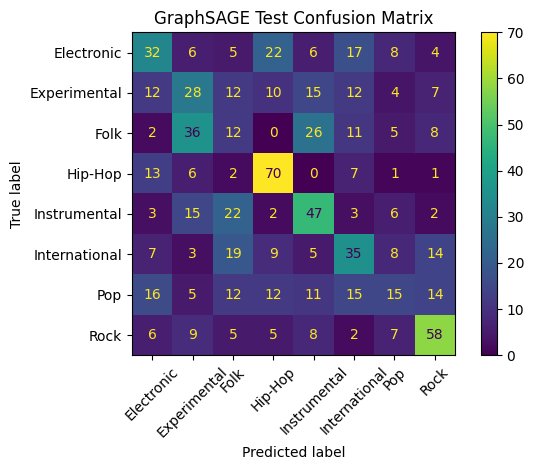

In [ ]:
# Step 71: Visualize the GraphSAGE confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(9, 9))

disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    values_format="d"
)

plt.title("GraphSAGE Test Confusion Matrix")
plt.tight_layout()
plt.show()

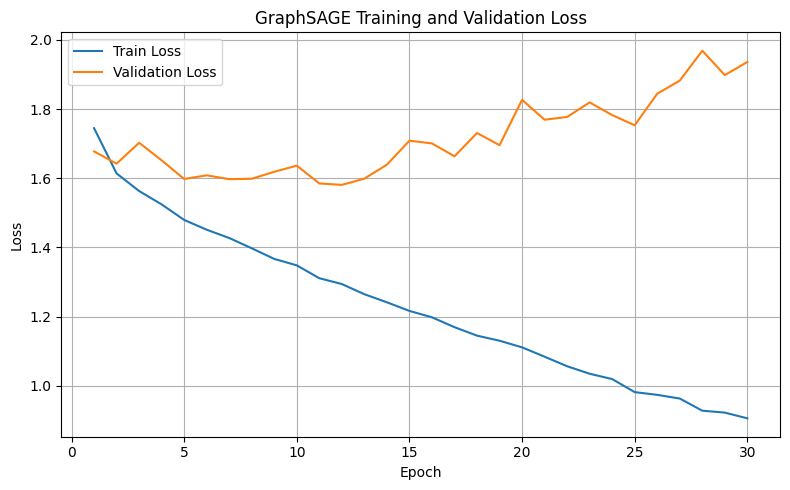

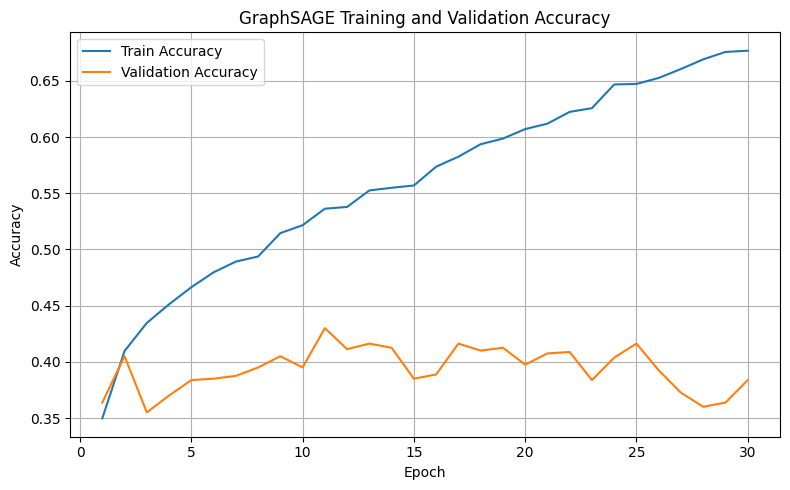

In [ ]:
# Step 72: Plot GraphSAGE training and validation curves

import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GraphSAGE Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GraphSAGE Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Step 73: Prepare the CNN baseline environment

import os
import glob
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

print("----- CNN baseline setup -----")
print("PyTorch version:", torch.__version__)
print("Device:", device)
print("Number of classes:", len(class_names))
print("CNN input representation: 128-bin log-Mel spectrogram")
print("Segment duration: 5 seconds")

----- CNN baseline setup -----
PyTorch version: 2.11.0+cpu
Device: cpu
Number of classes: 8
CNN input representation: 128-bin log-Mel spectrogram
Segment duration: 5 seconds


In [ ]:
# Step 74: Create the CNN dataset for 5-second audio segments

class AudioCNNDataset(Dataset):
    def __init__(self, track_ids, split_name, metadata, audio_root):
        self.track_ids = list(track_ids)
        self.split_name = split_name
        self.metadata = metadata
        self.audio_root = audio_root

        self.samples = []

        for track_id in self.track_ids:
            audio_matches = glob.glob(
                f"{self.audio_root}/**/{int(track_id):06d}.mp3",
                recursive=True
            )

            if not audio_matches:
                continue

            audio_path = audio_matches[0]

            row = self.metadata.loc[track_id]
            label = int(
                genre_to_label[row["genre"]]
            )

            try:
                audio, sr = librosa.load(
                    audio_path,
                    sr=22050,
                    mono=True
                )

                samples_per_segment = sr * 5
                num_segments = len(audio) // samples_per_segment

                for segment_idx in range(num_segments):
                    self.samples.append(
                        (
                            audio_path,
                            segment_idx,
                            label,
                            int(track_id)
                        )
                    )

            except Exception:
                continue

        print(f"{split_name} samples:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        audio_path, segment_idx, label, track_id = self.samples[idx]

        audio, sr = librosa.load(
            audio_path,
            sr=22050,
            mono=True
        )

        samples_per_segment = sr * 5

        start = segment_idx * samples_per_segment
        end = start + samples_per_segment

        segment = audio[start:end]

        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=128,
            power=2.0
        )

        log_mel = librosa.power_to_db(
            mel,
            ref=np.max
        )

        # Normalize each spectrogram using its own statistics
        log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-8)

        x = torch.tensor(
            log_mel,
            dtype=torch.float32
        ).unsqueeze(0)

        return x, torch.tensor(label, dtype=torch.long), track_id


cnn_train_dataset = AudioCNNDataset(
    train_track_ids,
    "Train",
    split_metadata,
    "/content/fma_small"
)

cnn_val_dataset = AudioCNNDataset(
    val_track_ids,
    "Validation",
    split_metadata,
    "/content/fma_small"
)

cnn_test_dataset = AudioCNNDataset(
    test_track_ids,
    "Test",
    split_metadata,
    "/content/fma_small"
)

print("\n----- CNN dataset creation complete -----")

/tmp/ipykernel_1131/3731056557.py:29: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_1131/3731056557.py:29: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_1131/3731056557.py:29: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: libro

Train samples: 34612
Validation samples: 4344
Test samples: 4364

----- CNN dataset creation complete -----


In [ ]:
# Step 75: Create DataLoaders for the CNN datasets

from torch.utils.data import DataLoader

cnn_batch_size = 32

cnn_train_loader = DataLoader(
    cnn_train_dataset,
    batch_size=cnn_batch_size,
    shuffle=True,
    num_workers=0
)

cnn_val_loader = DataLoader(
    cnn_val_dataset,
    batch_size=cnn_batch_size,
    shuffle=False,
    num_workers=0
)

cnn_test_loader = DataLoader(
    cnn_test_dataset,
    batch_size=cnn_batch_size,
    shuffle=False,
    num_workers=0
)

print("----- CNN DataLoaders created -----")
print("Batch size:", cnn_batch_size)
print("Train batches:", len(cnn_train_loader))
print("Validation batches:", len(cnn_val_loader))
print("Test batches:", len(cnn_test_loader))

----- CNN DataLoaders created -----
Batch size: 32
Train batches: 1082
Validation batches: 136
Test batches: 137


In [ ]:
# Step 76: Inspect one CNN batch

batch_x, batch_y, batch_track_ids = next(iter(cnn_train_loader))

print("----- CNN batch inspection -----")
print("Input shape:", batch_x.shape)
print("Input dtype:", batch_x.dtype)

print("Labels shape:", batch_y.shape)
print("Labels dtype:", batch_y.dtype)
print("First 10 labels:", batch_y[:10])

print("Track IDs type:", type(batch_track_ids))
print("First 10 track IDs:", batch_track_ids[:10])

print("Input minimum:", batch_x.min().item())
print("Input maximum:", batch_x.max().item())
print("Input mean:", batch_x.mean().item())
print("Input std:", batch_x.std().item())

print("----- CNN batch inspection complete -----")

----- CNN batch inspection -----
Input shape: torch.Size([32, 1, 128, 216])
Input dtype: torch.float32
Labels shape: torch.Size([32])
Labels dtype: torch.int64
First 10 labels: tensor([0, 4, 6, 2, 3, 4, 1, 2, 3, 1])
Track IDs type: <class 'torch.Tensor'>
First 10 track IDs: tensor([ 80836, 133537, 126102, 118735, 103808,  81600,  43886,  97585, 146149,
         70002])
Input minimum: -4.151089191436768
Input maximum: 4.069386959075928
Input mean: -4.8980670186438147e-08
Input std: 1.0000005960464478
----- CNN batch inspection complete -----


In [ ]:
# Step 77: Define the CNN baseline model

import torch
import torch.nn as nn
import torch.nn.functional as F


class CNNClassifier(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        logits = self.classifier(x)
        return logits


cnn_model = CNNClassifier(num_classes=8)

print("----- CNN model -----")
print(cnn_model)

----- CNN model -----
CNNClassifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True,

In [ ]:
# Step 78: Test the CNN forward pass

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

cnn_model = cnn_model.to(device)

batch_x, batch_y, batch_track_ids = next(
    iter(cnn_train_loader)
)

batch_x = batch_x.to(device)

with torch.no_grad():
    cnn_logits = cnn_model(batch_x)

print("----- CNN forward pass -----")
print("Device:", device)
print("Input shape:", batch_x.shape)
print("Output logits shape:", cnn_logits.shape)
print("Output dtype:", cnn_logits.dtype)
print("----- CNN forward pass successful -----")

----- CNN forward pass -----
Device: cpu
Input shape: torch.Size([32, 1, 128, 216])
Output logits shape: torch.Size([32, 8])
Output dtype: torch.float32
----- CNN forward pass successful -----


In [ ]:
# Step 79: Configure CNN training

cnn_criterion = nn.CrossEntropyLoss()

cnn_optimizer = torch.optim.AdamW(
    cnn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

cnn_num_epochs = 15

print("----- CNN training configuration -----")
print("Device:", device)
print("Loss function:", cnn_criterion)
print("Optimizer:", cnn_optimizer.__class__.__name__)
print("Learning rate:", 1e-3)
print("Weight decay:", 1e-4)
print("Number of epochs:", cnn_num_epochs)
print("----- CNN training configuration complete -----")

----- CNN training configuration -----
Device: cpu
Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 0.001
Weight decay: 0.0001
Number of epochs: 15
----- CNN training configuration complete -----


In [ ]:
# Step 80: Define CNN training and evaluation functions

def train_cnn_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_x, batch_y, _ in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = model(batch_x)

        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        predictions = logits.argmax(dim=1)

        total_correct += (
            predictions == batch_y
        ).sum().item()

        total_samples += batch_x.size(0)

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy


@torch.no_grad()
def evaluate_cnn(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_x, batch_y, _ in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_x)

        loss = criterion(logits, batch_y)

        total_loss += loss.item() * batch_x.size(0)

        predictions = logits.argmax(dim=1)

        total_correct += (
            predictions == batch_y
        ).sum().item()

        total_samples += batch_x.size(0)

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy


print("----- CNN training functions ready -----")

----- CNN training functions ready -----


In [ ]:
# Step 81: Run one CNN training epoch

train_loss, train_accuracy = train_cnn_one_epoch(
    cnn_model,
    cnn_train_loader,
    cnn_optimizer,
    cnn_criterion,
    device
)

val_loss, val_accuracy = evaluate_cnn(
    cnn_model,
    cnn_val_loader,
    cnn_criterion,
    device
)

print("----- CNN epoch 1 test -----")
print(f"Train Loss: {train_loss:.4f}")
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print("----- CNN epoch 1 complete -----")

In [ ]:
# Step 82: Reconnect the project environment

from google.colab import drive
drive.mount("/content/drive")

import os
import glob
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

print("----- Project environment restored -----")
print("PyTorch version:", torch.__version__)
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
print("Google Drive mounted successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
----- Project environment restored -----
PyTorch version: 2.11.0+cpu
Device: cpu
Google Drive mounted successfully


In [ ]:
# Step 83A: Locate the FMA metadata file

import os
import glob

search_paths = [
    "/content",
    "/content/drive/MyDrive/GNN_BERT_Music"
]

metadata_matches = []

for search_path in search_paths:
    metadata_matches.extend(
        glob.glob(
            f"{search_path}/**/tracks.csv",
            recursive=True
        )
    )

metadata_matches = sorted(
    set(metadata_matches)
)

print("----- Metadata file search -----")

if metadata_matches:
    for path in metadata_matches:
        print(path)
else:
    print("No tracks.csv file found.")

print("----- Search complete -----")

----- Metadata file search -----
/content/fma_metadata/tracks.csv
----- Search complete -----


In [ ]:
# Step 83: Restore FMA metadata and official train/validation/test splits

import os
import glob
import pandas as pd
import numpy as np

# Define project paths
project_root = "/content/drive/MyDrive/GNN_BERT_Music"
audio_root = "/content/fma_small"
tracks_path = "/content/fma_metadata/tracks.csv"

# Load the full FMA metadata
tracks = pd.read_csv(
    tracks_path,
    index_col=0,
    header=[0, 1]
)

# Identify the available FMA-small audio files
audio_files = glob.glob(
    f"{audio_root}/**/*.mp3",
    recursive=True
)

audio_track_ids = sorted([
    int(os.path.splitext(os.path.basename(path))[0])
    for path in audio_files
])

# Keep only metadata for the available FMA-small tracks
split_metadata = tracks.loc[
    tracks.index.isin(audio_track_ids)
].copy()

# Select the required metadata columns
split_metadata = split_metadata[
    [
        ("set", "split"),
        ("set", "subset"),
        ("track", "genre_top"),
        ("track", "title")
    ]
].copy()

# Rename columns for easier access
split_metadata.columns = [
    "split",
    "subset",
    "genre",
    "title"
]

# Create official split track ID lists
train_track_ids = sorted(
    split_metadata[
        split_metadata["split"] == "training"
    ].index.tolist()
)

val_track_ids = sorted(
    split_metadata[
        split_metadata["split"] == "validation"
    ].index.tolist()
)

test_track_ids = sorted(
    split_metadata[
        split_metadata["split"] == "test"
    ].index.tolist()
)

print("----- FMA metadata restored -----")
print("Total audio files:", len(audio_track_ids))
print("Metadata rows:", len(split_metadata))
print("Training tracks:", len(train_track_ids))
print("Validation tracks:", len(val_track_ids))
print("Test tracks:", len(test_track_ids))

print("\nSplit distribution:")
print(split_metadata["split"].value_counts())

print("\n----- Metadata restoration complete -----")

----- FMA metadata restored -----
Total audio files: 8000
Metadata rows: 8000
Training tracks: 6400
Validation tracks: 800
Test tracks: 800

Split distribution:
split
training      6400
validation     800
test           800
Name: count, dtype: int64

----- Metadata restoration complete -----


In [ ]:
# Step 84A: Restore the genre-to-label mapping

genre_to_label = {
    "Electronic": 0,
    "Experimental": 1,
    "Folk": 2,
    "Hip-Hop": 3,
    "Instrumental": 4,
    "International": 5,
    "Pop": 6,
    "Rock": 7
}

print("----- Genre mapping restored -----")
print(genre_to_label)
print("Number of classes:", len(genre_to_label))

----- Genre mapping restored -----
{'Electronic': 0, 'Experimental': 1, 'Folk': 2, 'Hip-Hop': 3, 'Instrumental': 4, 'International': 5, 'Pop': 6, 'Rock': 7}
Number of classes: 8


In [ ]:
# Step 84: Build an efficient CNN dataset with precomputed Mel spectrograms

import os
import glob
import numpy as np
import librosa
import torch
from torch.utils.data import Dataset

class PrecomputedCNNDataset(Dataset):
    def __init__(self, track_ids, split_name, metadata, audio_root):
        self.split_name = split_name
        self.samples = []

        for track_id in track_ids:
            audio_matches = glob.glob(
                f"{audio_root}/**/{int(track_id):06d}.mp3",
                recursive=True
            )

            if not audio_matches:
                continue

            audio_path = audio_matches[0]
            row = metadata.loc[track_id]
            label = int(genre_to_label[row["genre"]])

            try:
                audio, sr = librosa.load(
                    audio_path,
                    sr=22050,
                    mono=True
                )

                samples_per_segment = sr * 5
                num_segments = len(audio) // samples_per_segment

                for segment_idx in range(num_segments):
                    start = segment_idx * samples_per_segment
                    end = start + samples_per_segment

                    segment = audio[start:end]

                    mel = librosa.feature.melspectrogram(
                        y=segment,
                        sr=sr,
                        n_mels=128,
                        power=2.0
                    )

                    log_mel = librosa.power_to_db(
                        mel,
                        ref=np.max
                    )

                    # Standardize each segment for CNN training
                    log_mel = (
                        log_mel - log_mel.mean()
                    ) / (log_mel.std() + 1e-8)

                    x = torch.tensor(
                        log_mel,
                        dtype=torch.float32
                    ).unsqueeze(0)

                    self.samples.append(
                        (
                            x,
                            torch.tensor(label, dtype=torch.long),
                            int(track_id)
                        )
                    )

            except Exception:
                continue

        print(f"{split_name} samples:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


# Recreate the CNN datasets
cnn_train_dataset = PrecomputedCNNDataset(
    train_track_ids,
    "Train",
    split_metadata,
    audio_root
)

cnn_val_dataset = PrecomputedCNNDataset(
    val_track_ids,
    "Validation",
    split_metadata,
    audio_root
)

cnn_test_dataset = PrecomputedCNNDataset(
    test_track_ids,
    "Test",
    split_metadata,
    audio_root
)

print("\n----- Efficient CNN datasets created -----")

/tmp/ipykernel_56388/2426221733.py:29: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_56388/2426221733.py:29: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_56388/2426221733.py:29: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: li

Train samples: 34612
Validation samples: 4344
Test samples: 4364

----- Efficient CNN datasets created -----


In [ ]:
# Step 85: Create CNN DataLoaders

from torch.utils.data import DataLoader

cnn_batch_size = 64

cnn_train_loader = DataLoader(
    cnn_train_dataset,
    batch_size=cnn_batch_size,
    shuffle=True,
    num_workers=0
)

cnn_val_loader = DataLoader(
    cnn_val_dataset,
    batch_size=cnn_batch_size,
    shuffle=False,
    num_workers=0
)

cnn_test_loader = DataLoader(
    cnn_test_dataset,
    batch_size=cnn_batch_size,
    shuffle=False,
    num_workers=0
)

print("----- CNN DataLoaders created -----")
print("Batch size:", cnn_batch_size)
print("Train batches:", len(cnn_train_loader))
print("Validation batches:", len(cnn_val_loader))
print("Test batches:", len(cnn_test_loader))

----- CNN DataLoaders created -----
Batch size: 64
Train batches: 541
Validation batches: 68
Test batches: 69


In [ ]:
# Step 86: Inspect one CNN batch

batch_x, batch_y, batch_track_ids = next(iter(cnn_train_loader))

print("----- CNN batch inspection -----")
print("Input shape:", batch_x.shape)
print("Input dtype:", batch_x.dtype)
print("Labels shape:", batch_y.shape)
print("Labels dtype:", batch_y.dtype)
print("Track IDs shape:", batch_track_ids.shape)

print("\nInput statistics:")
print("Min:", batch_x.min().item())
print("Max:", batch_x.max().item())
print("Mean:", batch_x.mean().item())
print("Std:", batch_x.std().item())

print("\nFirst 10 labels:", batch_y[:10])
print("First 10 track IDs:", batch_track_ids[:10])

print("\n----- Batch inspection complete -----")

----- CNN batch inspection -----
Input shape: torch.Size([64, 1, 128, 216])
Input dtype: torch.float32
Labels shape: torch.Size([64])
Labels dtype: torch.int64
Track IDs shape: torch.Size([64])

Input statistics:
Min: -5.180866241455078
Max: 3.9195399284362793
Mean: -1.1865739502070483e-08
Std: 1.000000238418579

First 10 labels: tensor([4, 2, 7, 7, 7, 3, 1, 4, 7, 4])
First 10 track IDs: tensor([111873, 108015, 123834,  67558, 115761,  29720, 106522,  97279, 122086,
         92950])

----- Batch inspection complete -----


In [ ]:
# Step 87: Define the CNN baseline model

import torch
import torch.nn as nn

class CNNClassifier(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        logits = self.classifier(x)
        return logits


cnn_model = CNNClassifier(num_classes=8)

print("----- CNN model created -----")
print(cnn_model)

----- CNN model created -----
CNNClassifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affi

In [ ]:
# Step 88: Verify the CNN forward pass

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

cnn_model = cnn_model.to(device)

batch_x, batch_y, batch_track_ids = next(iter(cnn_train_loader))

batch_x = batch_x.to(device)
batch_y = batch_y.to(device)

with torch.no_grad():
    logits = cnn_model(batch_x)

print("----- CNN forward-pass check -----")
print("Device:", device)
print("Input shape:", batch_x.shape)
print("Output logits shape:", logits.shape)
print("Output dtype:", logits.dtype)
print("Expected output shape:", (batch_x.size(0), 8))
print("----- Forward pass successful -----")

----- CNN forward-pass check -----
Device: cpu
Input shape: torch.Size([64, 1, 128, 216])
Output logits shape: torch.Size([64, 8])
Output dtype: torch.float32
Expected output shape: (64, 8)
----- Forward pass successful -----


In [ ]:
# Step 89: Configure CNN training

cnn_criterion = nn.CrossEntropyLoss()

cnn_optimizer = torch.optim.AdamW(
    cnn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

cnn_num_epochs = 15

print("----- CNN training configuration -----")
print("Device:", device)
print("Loss function:", cnn_criterion)
print("Optimizer:", cnn_optimizer.__class__.__name__)
print("Learning rate:", 1e-3)
print("Weight decay:", 1e-4)
print("Number of epochs:", cnn_num_epochs)
print("----- Configuration complete -----")

----- CNN training configuration -----
Device: cpu
Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 0.001
Weight decay: 0.0001
Number of epochs: 15
----- Configuration complete -----


In [ ]:
# Step 90: Define CNN training and evaluation functions

def train_cnn_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_x, batch_y, _ in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        predictions = logits.argmax(dim=1)
        total_correct += (
            predictions == batch_y
        ).sum().item()

        total_samples += batch_x.size(0)

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy


@torch.no_grad()
def evaluate_cnn(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_x, batch_y, _ in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        total_loss += loss.item() * batch_x.size(0)

        predictions = logits.argmax(dim=1)
        total_correct += (
            predictions == batch_y
        ).sum().item()

        total_samples += batch_x.size(0)

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy


print("----- CNN training functions ready -----")

----- CNN training functions ready -----


In [ ]:
# Step 92: Check for an existing CNN checkpoint

import os

cnn_checkpoint_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/"
    "results/best_cnn.pt"
)

print("----- CNN checkpoint status -----")
print("Checkpoint path:", cnn_checkpoint_path)
print("Checkpoint exists:", os.path.isfile(cnn_checkpoint_path))

if os.path.isfile(cnn_checkpoint_path):
    checkpoint_size_mb = os.path.getsize(cnn_checkpoint_path) / (1024 ** 2)
    print("Checkpoint size (MB):", round(checkpoint_size_mb, 2))

print("----- Check complete -----")

----- CNN checkpoint status -----
Checkpoint path: /content/drive/MyDrive/GNN_BERT_Music/results/best_cnn.pt
Checkpoint exists: False
----- Check complete -----


In [ ]:
# Step 93: Define a lightweight CNN baseline

import torch
import torch.nn as nn

class LightweightCNNClassifier(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        logits = self.classifier(x)
        return logits


cnn_model = LightweightCNNClassifier(num_classes=8)

print("----- Lightweight CNN model created -----")
print(cnn_model)

----- Lightweight CNN model created -----
LightweightCNNClassifier(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=64, out_features=8, bias=True)
  )
)


In [ ]:
# Step 94B: Check existing CNN dataset variables

print("----- CNN dataset memory check -----")

print("train_cnn_dataset exists:",
      "train_cnn_dataset" in globals())

print("val_cnn_dataset exists:",
      "val_cnn_dataset" in globals())

print("test_cnn_dataset exists:",
      "test_cnn_dataset" in globals())

print("train_loader exists:",
      "train_loader" in globals())

print("val_loader exists:",
      "val_loader" in globals())

print("test_loader exists:",
      "test_loader" in globals())

print("----- Check complete -----")

----- CNN dataset memory check -----
train_cnn_dataset exists: False
val_cnn_dataset exists: False
test_cnn_dataset exists: False
train_loader exists: False
val_loader exists: False
test_loader exists: False
----- Check complete -----


In [ ]:
# Step 95: Verify the saved graph dataset is still accessible

import os
import glob

train_graph_dir = (
    "/content/drive/MyDrive/GNN_BERT_Music/"
    "data/processed/graphs/train"
)

val_graph_dir = (
    "/content/drive/MyDrive/GNN_BERT_Music/"
    "data/processed/graphs/val"
)

test_graph_dir = (
    "/content/drive/MyDrive/GNN_BERT_Music/"
    "data/processed/graphs/test"
)

train_graph_files = glob.glob(os.path.join(train_graph_dir, "*.pt"))
val_graph_files = glob.glob(os.path.join(val_graph_dir, "*.pt"))
test_graph_files = glob.glob(os.path.join(test_graph_dir, "*.pt"))

print("----- Saved graph dataset check -----")
print("Train graph files:", len(train_graph_files))
print("Validation graph files:", len(val_graph_files))
print("Test graph files:", len(test_graph_files))
print("Train directory exists:", os.path.isdir(train_graph_dir))
print("Validation directory exists:", os.path.isdir(val_graph_dir))
print("Test directory exists:", os.path.isdir(test_graph_dir))
print("----- Check complete -----")

----- Saved graph dataset check -----
Train graph files: 6394
Validation graph files: 800
Test graph files: 800
Train directory exists: True
Validation directory exists: True
Test directory exists: True
----- Check complete -----


In [ ]:
# Step 96: Create a fast track-level CNN dataset

import os
import glob
import torch
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader

class FastCNNDataset(Dataset):
    def __init__(self, track_ids, metadata, audio_root):
        self.samples = []

        for track_id in track_ids:
            audio_matches = glob.glob(
                f"{audio_root}/**/{int(track_id):06d}.mp3",
                recursive=True
            )

            if not audio_matches:
                continue

            audio_path = audio_matches[0]
            row = metadata.loc[track_id]

            label = int(genre_to_label[row["genre"]])

            try:
                audio, sr = librosa.load(
                    audio_path,
                    sr=22050,
                    mono=True,
                    duration=5
                )

                samples_per_segment = sr * 5

                if len(audio) < samples_per_segment:
                    continue

                audio = audio[:samples_per_segment]

                mel = librosa.feature.melspectrogram(
                    y=audio,
                    sr=sr,
                    n_mels=128,
                    power=2.0
                )

                log_mel = librosa.power_to_db(
                    mel,
                    ref=np.max
                )

                log_mel = (
                    log_mel - log_mel.mean()
                ) / (log_mel.std() + 1e-8)

                x = torch.tensor(
                    log_mel,
                    dtype=torch.float32
                ).unsqueeze(0)

                y = torch.tensor(
                    label,
                    dtype=torch.long
                )

                self.samples.append(
                    (x, y, int(track_id))
                )

            except Exception:
                continue

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


train_cnn_dataset = FastCNNDataset(
    train_track_ids,
    split_metadata,
    "/content/fma_small"
)

val_cnn_dataset = FastCNNDataset(
    val_track_ids,
    split_metadata,
    "/content/fma_small"
)

test_cnn_dataset = FastCNNDataset(
    test_track_ids,
    split_metadata,
    "/content/fma_small"
)

print("----- Fast CNN datasets -----")
print("Train samples:", len(train_cnn_dataset))
print("Validation samples:", len(val_cnn_dataset))
print("Test samples:", len(test_cnn_dataset))
print("----- Dataset creation complete -----")

/tmp/ipykernel_56388/3176924289.py:29: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_56388/3176924289.py:29: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_56388/3176924289.py:29: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: li

----- Fast CNN datasets -----
Train samples: 6394
Validation samples: 800
Test samples: 800
----- Dataset creation complete -----


In [ ]:
from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(
    train_cnn_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_cnn_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_cnn_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("----- CNN DataLoaders -----")
print("Batch size:", batch_size)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))
print("----- DataLoaders ready -----")

----- CNN DataLoaders -----
Batch size: 64
Train batches: 100
Validation batches: 13
Test batches: 13
----- DataLoaders ready -----


In [ ]:
# Get one batch from the training loader
batch_x, batch_y, batch_track_ids = next(iter(train_loader))

print("----- CNN batch inspection -----")
print("Input shape:", batch_x.shape)
print("Input dtype:", batch_x.dtype)
print("Labels shape:", batch_y.shape)
print("Labels dtype:", batch_y.dtype)
print("Track IDs shape:", batch_track_ids.shape)
print("Input mean:", batch_x.mean().item())
print("Input std:", batch_x.std().item())

# Create the lightweight CNN model
cnn_model = LightweightCNNClassifier(num_classes=8)

# Forward pass
with torch.no_grad():
    logits = cnn_model(batch_x)

print("Logits shape:", logits.shape)
print("----- CNN batch and forward pass complete -----")

----- CNN batch inspection -----
Input shape: torch.Size([64, 1, 128, 216])
Input dtype: torch.float32
Labels shape: torch.Size([64])
Labels dtype: torch.int64
Track IDs shape: torch.Size([64])
Input mean: -8.373279847262438e-09
Input std: 1.000000238418579
Logits shape: torch.Size([64, 8])
----- CNN batch and forward pass complete -----


In [ ]:
import time

# Move the model to the available device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = cnn_model.to(device)

# Define loss and optimizer
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.AdamW(
    cnn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# Get one training batch
batch_x, batch_y, _ = next(iter(train_loader))
batch_x = batch_x.to(device)
batch_y = batch_y.to(device)

# Measure one forward and backward pass
start_time = time.time()

optimizer_cnn.zero_grad()
logits = cnn_model(batch_x)
loss = criterion_cnn(logits, batch_y)
loss.backward()
optimizer_cnn.step()

elapsed = time.time() - start_time

print("----- CNN training speed test -----")
print("Device:", device)
print("Batch size:", batch_x.size(0))
print("Loss:", round(loss.item(), 4))
print("One batch time:", round(elapsed, 2), "seconds")
print("Estimated time per epoch:",
      round(elapsed * len(train_loader) / 60, 2), "minutes")
print("----- Speed test complete -----")

----- CNN training speed test -----
Device: cpu
Batch size: 64
Loss: 2.0936
One batch time: 2.27 seconds
Estimated time per epoch: 3.78 minutes
----- Speed test complete -----


In [ ]:
import time
import torch
import torch.nn as nn

# Recreate the lightweight CNN from scratch
cnn_model = LightweightCNNClassifier(num_classes=8)
cnn_model = cnn_model.to(device)

# Define loss and optimizer
criterion_cnn = nn.CrossEntropyLoss()

optimizer_cnn = torch.optim.AdamW(
    cnn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

num_epochs_cnn = 8

best_val_acc_cnn = 0.0
best_epoch_cnn = 0

train_losses_cnn = []
train_accs_cnn = []
val_losses_cnn = []
val_accs_cnn = []

checkpoint_path_cnn = (
    "/content/drive/MyDrive/GNN_BERT_Music/results/best_cnn.pt"
)

print("----- CNN training started -----")
print("Device:", device)
print("Epochs:", num_epochs_cnn)
print("Training batches per epoch:", len(train_loader))
print("Estimated time:", round(3.78 * num_epochs_cnn, 1), "minutes")

training_start = time.time()

for epoch in range(1, num_epochs_cnn + 1):

    epoch_start = time.time()

    # Training
    cnn_model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_x, batch_y, _ in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer_cnn.zero_grad()

        logits = cnn_model(batch_x)
        loss = criterion_cnn(logits, batch_y)

        loss.backward()
        optimizer_cnn.step()

        total_loss += loss.item() * batch_x.size(0)

        predictions = logits.argmax(dim=1)
        total_correct += (predictions == batch_y).sum().item()
        total_samples += batch_x.size(0)

    train_loss = total_loss / total_samples
    train_acc = total_correct / total_samples

    # Validation
    cnn_model.eval()

    val_total_loss = 0.0
    val_total_correct = 0
    val_total_samples = 0

    with torch.no_grad():

        for batch_x, batch_y, _ in val_loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = cnn_model(batch_x)
            loss = criterion_cnn(logits, batch_y)

            val_total_loss += loss.item() * batch_x.size(0)

            predictions = logits.argmax(dim=1)
            val_total_correct += (predictions == batch_y).sum().item()
            val_total_samples += batch_x.size(0)

    val_loss = val_total_loss / val_total_samples
    val_acc = val_total_correct / val_total_samples

    # Store metrics
    train_losses_cnn.append(train_loss)
    train_accs_cnn.append(train_acc)
    val_losses_cnn.append(val_loss)
    val_accs_cnn.append(val_acc)

    # Save best model
    if val_acc > best_val_acc_cnn:

        best_val_acc_cnn = val_acc
        best_epoch_cnn = epoch

        torch.save(
            {
                "model_state_dict": cnn_model.state_dict(),
                "optimizer_state_dict": optimizer_cnn.state_dict(),
                "epoch": epoch,
                "val_accuracy": val_acc
            },
            checkpoint_path_cnn
        )

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d}/{num_epochs_cnn} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {epoch_time / 60:.2f} min"
    )

total_training_time = (time.time() - training_start) / 60

print("----- CNN training complete -----")
print("Best epoch:", best_epoch_cnn)
print("Best validation accuracy:", round(best_val_acc_cnn, 4))
print("Total training time:", round(total_training_time, 2), "minutes")
print("Checkpoint saved:", checkpoint_path_cnn)

----- CNN training started -----
Device: cpu
Epochs: 8
Training batches per epoch: 100
Estimated time: 30.2 minutes
Epoch 01/8 | Train Loss: 2.0288 | Train Acc: 0.1611 | Val Loss: 1.8974 | Val Acc: 0.2600 | Time: 3.30 min
Epoch 02/8 | Train Loss: 1.9140 | Train Acc: 0.2330 | Val Loss: 1.8870 | Val Acc: 0.2888 | Time: 3.08 min
Epoch 03/8 | Train Loss: 1.8817 | Train Acc: 0.2590 | Val Loss: 1.8229 | Val Acc: 0.3362 | Time: 3.22 min
Epoch 04/8 | Train Loss: 1.8359 | Train Acc: 0.3069 | Val Loss: 1.7564 | Val Acc: 0.3825 | Time: 3.24 min
Epoch 05/8 | Train Loss: 1.7965 | Train Acc: 0.3247 | Val Loss: 1.7507 | Val Acc: 0.3625 | Time: 3.24 min
Epoch 06/8 | Train Loss: 1.7604 | Train Acc: 0.3503 | Val Loss: 1.6833 | Val Acc: 0.3663 | Time: 3.22 min
Epoch 07/8 | Train Loss: 1.7419 | Train Acc: 0.3503 | Val Loss: 1.6575 | Val Acc: 0.4000 | Time: 3.20 min
Epoch 08/8 | Train Loss: 1.7322 | Train Acc: 0.3635 | Val Loss: 1.6688 | Val Acc: 0.3937 | Time: 3.27 min
----- CNN training complete -----
Be

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
import numpy as np
import torch

# Load the best CNN checkpoint
checkpoint = torch.load(
    checkpoint_path_cnn,
    map_location=device,
    weights_only=False
)

cnn_model.load_state_dict(checkpoint["model_state_dict"])
cnn_model = cnn_model.to(device)
cnn_model.eval()

all_labels_cnn = []
all_predictions_cnn = []
all_probabilities_cnn = []

# Evaluate on the test set
with torch.no_grad():

    for batch_x, batch_y, _ in test_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        logits = cnn_model(batch_x)

        probabilities = torch.softmax(logits, dim=1)
        predictions = logits.argmax(dim=1)

        all_labels_cnn.extend(batch_y.cpu().numpy())
        all_predictions_cnn.extend(predictions.cpu().numpy())
        all_probabilities_cnn.extend(probabilities.cpu().numpy())

# Convert to NumPy arrays
all_labels_cnn = np.array(all_labels_cnn)
all_predictions_cnn = np.array(all_predictions_cnn)
all_probabilities_cnn = np.array(all_probabilities_cnn)

# Calculate evaluation metrics
cnn_accuracy = accuracy_score(
    all_labels_cnn,
    all_predictions_cnn
)

cnn_macro_f1 = f1_score(
    all_labels_cnn,
    all_predictions_cnn,
    average="macro"
)

cnn_micro_f1 = f1_score(
    all_labels_cnn,
    all_predictions_cnn,
    average="micro"
)

cnn_macro_auc_pr = average_precision_score(
    all_labels_cnn,
    all_probabilities_cnn,
    average="macro"
)

cnn_confusion = confusion_matrix(
    all_labels_cnn,
    all_predictions_cnn
)

print("----- CNN test evaluation -----")
print("Best epoch:", checkpoint["epoch"])
print("Best validation accuracy:", round(checkpoint["val_accuracy"], 4))
print("Test accuracy:", round(cnn_accuracy, 4))
print("Macro-F1:", round(cnn_macro_f1, 4))
print("Micro-F1:", round(cnn_micro_f1, 4))
print("Macro AUC-PR:", round(cnn_macro_auc_pr, 4))

print("\n----- Classification report -----")
print(
    classification_report(
        all_labels_cnn,
        all_predictions_cnn,
        target_names=[
            "Electronic",
            "Experimental",
            "Folk",
            "Hip-Hop",
            "Instrumental",
            "International",
            "Pop",
            "Rock"
        ],
        digits=4
    )
)

print("----- Confusion matrix -----")
print(cnn_confusion)

print("----- CNN test evaluation complete -----")

----- CNN test evaluation -----
Best epoch: 7
Best validation accuracy: 0.4
Test accuracy: 0.315
Macro-F1: 0.294
Micro-F1: 0.315
Macro AUC-PR: 0.3248

----- Classification report -----
               precision    recall  f1-score   support

   Electronic     0.6250    0.2000    0.3030       100
 Experimental     0.1940    0.2600    0.2222       100
         Folk     0.0949    0.1500    0.1163       100
      Hip-Hop     0.4249    0.8200    0.5597       100
 Instrumental     0.3409    0.1500    0.2083       100
International     0.3276    0.1900    0.2405       100
          Pop     0.3095    0.1300    0.1831       100
         Rock     0.4460    0.6200    0.5188       100

     accuracy                         0.3150       800
    macro avg     0.3454    0.3150    0.2940       800
 weighted avg     0.3454    0.3150    0.2940       800

----- Confusion matrix -----
[[20  6 10 42  4 10  2  6]
 [ 4 26 18 20 10  6  5 11]
 [ 0 49 15  2 13  2  4 15]
 [ 1  6  0 82  1  3  4  3]
 [ 0 22 45  4 1

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount("/content/drive")

# Define the project directory
project_root = "/content/drive/MyDrive/GNN_BERT_Music"

# Verify that the project directory exists
print("Project directory exists:", os.path.isdir(project_root))
print("Project path:", project_root)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory exists: True
Project path: /content/drive/MyDrive/GNN_BERT_Music


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

# Select CPU because the current Colab runtime is CPU-based
device = torch.device("cpu")

print("----- Environment restored -----")
print("PyTorch version:", torch.__version__)
print("Device:", device)
print("Transformers imported successfully")

----- Environment restored -----
PyTorch version: 2.11.0+cpu
Device: cpu
Transformers imported successfully


In [ ]:
# Define the FMA metadata path
metadata_path = "/content/fma_metadata/tracks.csv"

# Check whether the metadata is already available
print("Metadata exists:", os.path.isfile(metadata_path))
print("Metadata path:", metadata_path)

Metadata exists: True
Metadata path: /content/fma_metadata/tracks.csv


In [ ]:
# Load the FMA metadata
tracks = pd.read_csv(
    metadata_path,
    header=[0, 1],
    index_col=0
)

# Convert the multi-level metadata columns into simple names
tracks.columns = tracks.columns.get_level_values(1)

# Convert track IDs to integers
tracks.index = tracks.index.astype(int)

print("----- FMA Metadata -----")
print("Shape:", tracks.shape)
print("Track ID range:", tracks.index.min(), "to", tracks.index.max())
print("First columns:", tracks.columns[:10].tolist())
print("----- Metadata loaded successfully -----")

----- FMA Metadata -----
Shape: (106574, 52)
Track ID range: 2 to 155320
First columns: ['comments', 'date_created', 'date_released', 'engineer', 'favorites', 'id', 'information', 'listens', 'producer', 'tags']
----- Metadata loaded successfully -----


In [ ]:
# Define the FMA-small audio directory
audio_root = "/content/fma_small"

# Find all available FMA-small audio files
audio_files = glob.glob(
    f"{audio_root}/**/*.mp3",
    recursive=True
)

# Extract track IDs from the audio filenames
audio_track_ids = []

for audio_path in audio_files:
    filename = os.path.basename(audio_path)
    track_id = int(os.path.splitext(filename)[0])
    audio_track_ids.append(track_id)

# Remove any accidental duplicates and sort the IDs
audio_track_ids = sorted(set(audio_track_ids))

print("----- FMA-small Track IDs -----")
print("Audio files:", len(audio_files))
print("Unique track IDs:", len(audio_track_ids))
print("First 10 IDs:", audio_track_ids[:10])
print("----- Track IDs restored -----")

----- FMA-small Track IDs -----
Audio files: 8000
Unique track IDs: 8000
First 10 IDs: [2, 5, 10, 140, 141, 148, 182, 190, 193, 194]
----- Track IDs restored -----


In [ ]:
# Inspect the current metadata columns
print("Number of columns:", len(tracks.columns))

print("\nAll current columns:")
for i, col in enumerate(tracks.columns):
    print(i, repr(col))

print("\nRelevant column-name matches:")
for keyword in ["split", "subset", "genre", "title"]:
    matches = [col for col in tracks.columns if keyword.lower() in str(col).lower()]
    print(keyword, "->", matches)

Number of columns: 52

All current columns:
0 ('album', 'comments')
1 ('album', 'date_created')
2 ('album', 'date_released')
3 ('album', 'engineer')
4 ('album', 'favorites')
5 ('album', 'id')
6 ('album', 'information')
7 ('album', 'listens')
8 ('album', 'producer')
9 ('album', 'tags')
10 ('album', 'title')
11 ('album', 'tracks')
12 ('album', 'type')
13 ('artist', 'active_year_begin')
14 ('artist', 'active_year_end')
15 ('artist', 'associated_labels')
16 ('artist', 'bio')
17 ('artist', 'comments')
18 ('artist', 'date_created')
19 ('artist', 'favorites')
20 ('artist', 'id')
21 ('artist', 'latitude')
22 ('artist', 'location')
23 ('artist', 'longitude')
24 ('artist', 'members')
25 ('artist', 'name')
26 ('artist', 'related_projects')
27 ('artist', 'tags')
28 ('artist', 'website')
29 ('artist', 'wikipedia_page')
30 ('set', 'split')
31 ('set', 'subset')
32 ('track', 'bit_rate')
33 ('track', 'comments')
34 ('track', 'composer')
35 ('track', 'date_created')
36 ('track', 'date_recorded')
37 ('tr

In [ ]:
# Select the required FMA metadata fields using their MultiIndex names
split_metadata = tracks.loc[
    tracks.index.intersection(audio_track_ids),
    [
        ("set", "split"),
        ("set", "subset"),
        ("track", "genre_top"),
        ("track", "title")
    ]
].copy()

# Rename the columns to simple names for easier use
split_metadata.columns = ["split", "subset", "genre", "title"]

# Create the official split track ID lists
train_track_ids = sorted(
    split_metadata.index[
        split_metadata["split"] == "training"
    ].tolist()
)

val_track_ids = sorted(
    split_metadata.index[
        split_metadata["split"] == "validation"
    ].tolist()
)

test_track_ids = sorted(
    split_metadata.index[
        split_metadata["split"] == "test"
    ].tolist()
)

print("----- Official FMA-small Split -----")
print("Metadata rows:", len(split_metadata))
print("Training:", len(train_track_ids))
print("Validation:", len(val_track_ids))
print("Test:", len(test_track_ids))
print("Total:", len(train_track_ids) + len(val_track_ids) + len(test_track_ids))

print("\nTraining class distribution:")
print(split_metadata.loc[train_track_ids, "genre"].value_counts().sort_index())

print("\nValidation class distribution:")
print(split_metadata.loc[val_track_ids, "genre"].value_counts().sort_index())

print("\nTest class distribution:")
print(split_metadata.loc[test_track_ids, "genre"].value_counts().sort_index())

print("----- Split restored successfully -----")

----- Official FMA-small Split -----
Metadata rows: 8000
Training: 6400
Validation: 800
Test: 800
Total: 8000

Training class distribution:
genre
Electronic       800
Experimental     800
Folk             800
Hip-Hop          800
Instrumental     800
International    800
Pop              800
Rock             800
Name: count, dtype: int64

Validation class distribution:
genre
Electronic       100
Experimental     100
Folk             100
Hip-Hop          100
Instrumental     100
International    100
Pop              100
Rock             100
Name: count, dtype: int64

Test class distribution:
genre
Electronic       100
Experimental     100
Folk             100
Hip-Hop          100
Instrumental     100
International    100
Pop              100
Rock             100
Name: count, dtype: int64
----- Split restored successfully -----


In [ ]:
# Define the fixed 8-class genre-to-label mapping
genre_to_label = {
    "Electronic": 0,
    "Experimental": 1,
    "Folk": 2,
    "Hip-Hop": 3,
    "Instrumental": 4,
    "International": 5,
    "Pop": 6,
    "Rock": 7
}

# Create the reverse mapping for evaluation and reporting
label_to_genre = {
    label: genre
    for genre, label in genre_to_label.items()
}

print("----- Genre Label Mapping -----")
for label in sorted(label_to_genre):
    print(label, "->", label_to_genre[label])

print("----- Label mapping restored successfully -----")

----- Genre Label Mapping -----
0 -> Electronic
1 -> Experimental
2 -> Folk
3 -> Hip-Hop
4 -> Instrumental
5 -> International
6 -> Pop
7 -> Rock
----- Label mapping restored successfully -----


In [ ]:
# Load the DistilBERT tokenizer
bert_model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    bert_model_name
)

print("----- DistilBERT Tokenizer -----")
print("Model:", bert_model_name)
print("Tokenizer:", type(tokenizer).__name__)
print("Vocabulary size:", tokenizer.vocab_size)
print("----- Tokenizer loaded successfully -----")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

----- DistilBERT Tokenizer -----
Model: distilbert-base-uncased
Tokenizer: BertTokenizer
Vocabulary size: 30522
----- Tokenizer loaded successfully -----


In [ ]:
# Define a memory-efficient BERT title dataset
class BERTTitleDataset(Dataset):
    def __init__(self, track_ids, metadata, tokenizer, max_length=32):
        self.track_ids = []
        self.input_ids = []
        self.attention_masks = []
        self.labels = []

        for track_id in track_ids:
            row = metadata.loc[track_id]

            title = str(row["title"])
            genre = row["genre"]
            label = genre_to_label[genre]

            encoded = tokenizer(
                title,
                padding="max_length",
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )

            self.track_ids.append(int(track_id))
            self.input_ids.append(
                encoded["input_ids"].squeeze(0)
            )
            self.attention_masks.append(
                encoded["attention_mask"].squeeze(0)
            )
            self.labels.append(label)

        self.input_ids = torch.stack(self.input_ids)
        self.attention_masks = torch.stack(self.attention_masks)
        self.labels = torch.tensor(
            self.labels,
            dtype=torch.long
        )
        self.track_ids = torch.tensor(
            self.track_ids,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.input_ids[idx],
            self.attention_masks[idx],
            self.labels[idx],
            self.track_ids[idx]
        )


# Create datasets for all three official splits
bert_train_dataset = BERTTitleDataset(
    train_track_ids,
    split_metadata,
    tokenizer,
    max_length=32
)

bert_val_dataset = BERTTitleDataset(
    val_track_ids,
    split_metadata,
    tokenizer,
    max_length=32
)

bert_test_dataset = BERTTitleDataset(
    test_track_ids,
    split_metadata,
    tokenizer,
    max_length=32
)

print("----- BERT Title Datasets -----")
print("Training samples:", len(bert_train_dataset))
print("Validation samples:", len(bert_val_dataset))
print("Test samples:", len(bert_test_dataset))

print("\nInput shape:", bert_train_dataset.input_ids.shape)
print("Attention mask shape:", bert_train_dataset.attention_masks.shape)
print("Labels shape:", bert_train_dataset.labels.shape)

print("----- BERT datasets created successfully -----")

----- BERT Title Datasets -----
Training samples: 6400
Validation samples: 800
Test samples: 800

Input shape: torch.Size([6400, 32])
Attention mask shape: torch.Size([6400, 32])
Labels shape: torch.Size([6400])
----- BERT datasets created successfully -----


In [ ]:
# Inspect one BERT dataset sample
sample_idx = 0

input_ids, attention_mask, label, track_id = bert_train_dataset[sample_idx]

title = split_metadata.loc[int(track_id), "title"]

tokens = tokenizer.convert_ids_to_tokens(
    input_ids.tolist()
)

print("----- BERT Sample Inspection -----")
print("Track ID:", int(track_id))
print("Title:", title)
print("Label:", int(label))
print("Genre:", label_to_genre[int(label)])
print("Input IDs shape:", input_ids.shape)
print("Attention mask shape:", attention_mask.shape)
print("Tokens:", tokens)
print("----- Sample inspection complete -----")

----- BERT Sample Inspection -----
Track ID: 2
Title: Food
Label: 3
Genre: Hip-Hop
Input IDs shape: torch.Size([32])
Attention mask shape: torch.Size([32])
Tokens: ['[CLS]', 'food', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
----- Sample inspection complete -----


In [ ]:
# Create DataLoaders with a small batch size for CPU and memory efficiency
bert_batch_size = 16

bert_train_loader = DataLoader(
    bert_train_dataset,
    batch_size=bert_batch_size,
    shuffle=True,
    num_workers=0
)

bert_val_loader = DataLoader(
    bert_val_dataset,
    batch_size=bert_batch_size,
    shuffle=False,
    num_workers=0
)

bert_test_loader = DataLoader(
    bert_test_dataset,
    batch_size=bert_batch_size,
    shuffle=False,
    num_workers=0
)

print("----- BERT DataLoaders -----")
print("Batch size:", bert_batch_size)
print("Training batches:", len(bert_train_loader))
print("Validation batches:", len(bert_val_loader))
print("Test batches:", len(bert_test_loader))

# Inspect one batch
batch = next(iter(bert_train_loader))

input_ids, attention_masks, labels, track_ids = batch

print("\n----- Batch Inspection -----")
print("Input IDs:", input_ids.shape, input_ids.dtype)
print("Attention masks:", attention_masks.shape, attention_masks.dtype)
print("Labels:", labels.shape, labels.dtype)
print("Track IDs:", track_ids.shape, track_ids.dtype)
print("----- DataLoaders created successfully -----")

----- BERT DataLoaders -----
Batch size: 16
Training batches: 400
Validation batches: 50
Test batches: 50

----- Batch Inspection -----
Input IDs: torch.Size([16, 32]) torch.int64
Attention masks: torch.Size([16, 32]) torch.int64
Labels: torch.Size([16]) torch.int64
Track IDs: torch.Size([16]) torch.int64
----- DataLoaders created successfully -----


In [ ]:
# Load the pretrained DistilBERT encoder
bert_encoder = AutoModel.from_pretrained(
    bert_model_name
).to(device)

# Freeze all DistilBERT parameters to prevent gradient memory usage
for parameter in bert_encoder.parameters():
    parameter.requires_grad = False

# Put the encoder in evaluation mode
bert_encoder.eval()

# Count total and trainable parameters
total_parameters = sum(
    parameter.numel()
    for parameter in bert_encoder.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in bert_encoder.parameters()
    if parameter.requires_grad
)

print("----- Frozen DistilBERT Encoder -----")
print("Model:", bert_model_name)
print("Hidden size:", bert_encoder.config.hidden_size)
print("Total parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)
print("Encoder training mode:", bert_encoder.training)
print("----- Encoder loaded and frozen successfully -----")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


----- Frozen DistilBERT Encoder -----
Model: distilbert-base-uncased
Hidden size: 768
Total parameters: 66362880
Trainable parameters: 0
Encoder training mode: False
----- Encoder loaded and frozen successfully -----


In [ ]:
# Get one batch from the training DataLoader
input_ids, attention_masks, labels, track_ids = next(
    iter(bert_train_loader)
)

# Run DistilBERT without gradient tracking
with torch.no_grad():
    outputs = bert_encoder(
        input_ids=input_ids,
        attention_mask=attention_masks
    )

# Extract the [CLS] token representation
cls_embeddings = outputs.last_hidden_state[:, 0, :]

print("----- DistilBERT Forward Pass -----")
print("Input IDs shape:", input_ids.shape)
print("Last hidden state shape:", outputs.last_hidden_state.shape)
print("CLS embeddings shape:", cls_embeddings.shape)
print("Embedding dtype:", cls_embeddings.dtype)
print("Embedding mean:", cls_embeddings.mean().item())
print("Embedding std:", cls_embeddings.std().item())
print("----- Forward pass successful -----")

----- DistilBERT Forward Pass -----
Input IDs shape: torch.Size([16, 32])
Last hidden state shape: torch.Size([16, 32, 768])
CLS embeddings shape: torch.Size([16, 768])
Embedding dtype: torch.float32
Embedding mean: -0.009244808927178383
Embedding std: 0.45654281973838806
----- Forward pass successful -----


In [ ]:
# Define the directory for cached BERT embeddings
bert_embedding_dir = os.path.join(
    project_root,
    "data",
    "processed",
    "bert_embeddings"
)

os.makedirs(bert_embedding_dir, exist_ok=True)


# Extract frozen DistilBERT CLS embeddings for one split
def extract_bert_embeddings(data_loader, split_name):
    embeddings = []
    labels = []
    track_ids = []

    bert_encoder.eval()

    with torch.no_grad():
        for batch_idx, batch in enumerate(data_loader):
            input_ids, attention_masks, batch_labels, batch_track_ids = batch

            outputs = bert_encoder(
                input_ids=input_ids,
                attention_mask=attention_masks
            )

            # Extract the CLS token representation
            batch_embeddings = outputs.last_hidden_state[:, 0, :]

            embeddings.append(
                batch_embeddings.cpu()
            )
            labels.append(
                batch_labels.cpu()
            )
            track_ids.append(
                batch_track_ids.cpu()
            )

            if (batch_idx + 1) % 50 == 0:
                print(
                    f"{split_name}: "
                    f"{batch_idx + 1}/{len(data_loader)} batches processed"
                )

    embeddings = torch.cat(embeddings, dim=0)
    labels = torch.cat(labels, dim=0)
    track_ids = torch.cat(track_ids, dim=0)

    output_path = os.path.join(
        bert_embedding_dir,
        f"{split_name}_embeddings.pt"
    )

    torch.save(
        {
            "embeddings": embeddings,
            "labels": labels,
            "track_ids": track_ids
        },
        output_path
    )

    print(f"{split_name}: saved to {output_path}")
    print(f"{split_name}: embeddings shape = {embeddings.shape}")

    return embeddings, labels, track_ids


# Extract embeddings for all official splits
bert_train_embeddings, bert_train_labels, bert_train_ids = (
    extract_bert_embeddings(
        bert_train_loader,
        "train"
    )
)

bert_val_embeddings, bert_val_labels, bert_val_ids = (
    extract_bert_embeddings(
        bert_val_loader,
        "val"
    )
)

bert_test_embeddings, bert_test_labels, bert_test_ids = (
    extract_bert_embeddings(
        bert_test_loader,
        "test"
    )
)

print("\n----- BERT Embedding Extraction Complete -----")
print("Train:", bert_train_embeddings.shape)
print("Validation:", bert_val_embeddings.shape)
print("Test:", bert_test_embeddings.shape)
print("Embedding dimension:", bert_train_embeddings.shape[1])

train: 50/400 batches processed
train: 100/400 batches processed
train: 150/400 batches processed
train: 200/400 batches processed
train: 250/400 batches processed
train: 300/400 batches processed
train: 350/400 batches processed
train: 400/400 batches processed
train: saved to /content/drive/MyDrive/GNN_BERT_Music/data/processed/bert_embeddings/train_embeddings.pt
train: embeddings shape = torch.Size([6400, 768])
val: 50/50 batches processed
val: saved to /content/drive/MyDrive/GNN_BERT_Music/data/processed/bert_embeddings/val_embeddings.pt
val: embeddings shape = torch.Size([800, 768])
test: 50/50 batches processed
test: saved to /content/drive/MyDrive/GNN_BERT_Music/data/processed/bert_embeddings/test_embeddings.pt
test: embeddings shape = torch.Size([800, 768])

----- BERT Embedding Extraction Complete -----
Train: torch.Size([6400, 768])
Validation: torch.Size([800, 768])
Test: torch.Size([800, 768])
Embedding dimension: 768


In [ ]:
# Reload the cached BERT embeddings from Google Drive
train_embedding_path = os.path.join(
    bert_embedding_dir,
    "train_embeddings.pt"
)

val_embedding_path = os.path.join(
    bert_embedding_dir,
    "val_embeddings.pt"
)

test_embedding_path = os.path.join(
    bert_embedding_dir,
    "test_embeddings.pt"
)

train_cache = torch.load(
    train_embedding_path,
    weights_only=True
)

val_cache = torch.load(
    val_embedding_path,
    weights_only=True
)

test_cache = torch.load(
    test_embedding_path,
    weights_only=True
)

print("----- Cached BERT Embeddings -----")
print("Train embeddings:", train_cache["embeddings"].shape)
print("Train labels:", train_cache["labels"].shape)
print("Train track IDs:", train_cache["track_ids"].shape)

print("\nValidation embeddings:", val_cache["embeddings"].shape)
print("Validation labels:", val_cache["labels"].shape)
print("Validation track IDs:", val_cache["track_ids"].shape)

print("\nTest embeddings:", test_cache["embeddings"].shape)
print("Test labels:", test_cache["labels"].shape)
print("Test track IDs:", test_cache["track_ids"].shape)

print("\nTrain embedding dtype:", train_cache["embeddings"].dtype)
print("----- Cached embeddings verified successfully -----")

----- Cached BERT Embeddings -----
Train embeddings: torch.Size([6400, 768])
Train labels: torch.Size([6400])
Train track IDs: torch.Size([6400])

Validation embeddings: torch.Size([800, 768])
Validation labels: torch.Size([800])
Validation track IDs: torch.Size([800])

Test embeddings: torch.Size([800, 768])
Test labels: torch.Size([800])
Test track IDs: torch.Size([800])

Train embedding dtype: torch.float32
----- Cached embeddings verified successfully -----


In [ ]:
# Define a dataset for cached BERT embeddings
class BERTEmbeddingDataset(Dataset):
    def __init__(self, cache):
        self.embeddings = cache["embeddings"]
        self.labels = cache["labels"]
        self.track_ids = cache["track_ids"]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.embeddings[idx],
            self.labels[idx],
            self.track_ids[idx]
        )


# Create datasets from the cached embeddings
bert_embedding_train_dataset = BERTEmbeddingDataset(train_cache)
bert_embedding_val_dataset = BERTEmbeddingDataset(val_cache)
bert_embedding_test_dataset = BERTEmbeddingDataset(test_cache)

print("----- BERT Embedding Datasets -----")
print(
    "Training samples:",
    len(bert_embedding_train_dataset)
)
print(
    "Validation samples:",
    len(bert_embedding_val_dataset)
)
print(
    "Test samples:",
    len(bert_embedding_test_dataset)
)

# Inspect one sample
sample_embedding, sample_label, sample_track_id = (
    bert_embedding_train_dataset[0]
)

print("\n----- Sample Inspection -----")
print("Embedding shape:", sample_embedding.shape)
print("Embedding dtype:", sample_embedding.dtype)
print("Label:", int(sample_label))
print("Genre:", label_to_genre[int(sample_label)])
print("Track ID:", int(sample_track_id))

print("----- BERT embedding datasets created successfully -----")

----- BERT Embedding Datasets -----
Training samples: 6400
Validation samples: 800
Test samples: 800

----- Sample Inspection -----
Embedding shape: torch.Size([768])
Embedding dtype: torch.float32
Label: 3
Genre: Hip-Hop
Track ID: 98577
----- BERT embedding datasets created successfully -----


In [ ]:
# Use a larger batch size because the classifier only processes 768-dimensional embeddings
bert_classifier_batch_size = 64

bert_classifier_train_loader = DataLoader(
    bert_embedding_train_dataset,
    batch_size=bert_classifier_batch_size,
    shuffle=True,
    num_workers=0
)

bert_classifier_val_loader = DataLoader(
    bert_embedding_val_dataset,
    batch_size=bert_classifier_batch_size,
    shuffle=False,
    num_workers=0
)

bert_classifier_test_loader = DataLoader(
    bert_embedding_test_dataset,
    batch_size=bert_classifier_batch_size,
    shuffle=False,
    num_workers=0
)

print("----- BERT Classifier DataLoaders -----")
print("Batch size:", bert_classifier_batch_size)
print("Training batches:", len(bert_classifier_train_loader))
print("Validation batches:", len(bert_classifier_val_loader))
print("Test batches:", len(bert_classifier_test_loader))

# Inspect one batch
batch = next(iter(bert_classifier_train_loader))

batch_embeddings, batch_labels, batch_track_ids = batch

print("\n----- Batch Inspection -----")
print("Embeddings:", batch_embeddings.shape, batch_embeddings.dtype)
print("Labels:", batch_labels.shape, batch_labels.dtype)
print("Track IDs:", batch_track_ids.shape, batch_track_ids.dtype)

print("----- DataLoaders created successfully -----")

----- BERT Classifier DataLoaders -----
Batch size: 64
Training batches: 100
Validation batches: 13
Test batches: 13

----- Batch Inspection -----
Embeddings: torch.Size([64, 768]) torch.float32
Labels: torch.Size([64]) torch.int64
Track IDs: torch.Size([64]) torch.int64
----- DataLoaders created successfully -----


In [ ]:
class BERTClassifierHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, num_classes=8, dropout=0.3):
        super().__init__()

        # Project the BERT embedding into a smaller hidden representation
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, embeddings):
        # Return class logits
        return self.classifier(embeddings)


bert_classifier = BERTClassifierHead(
    input_dim=768,
    hidden_dim=256,
    num_classes=8,
    dropout=0.3
).to(device)

print("----- BERT Classifier Head -----")
print(bert_classifier)

total_params = sum(
    parameter.numel()
    for parameter in bert_classifier.parameters()
)

trainable_params = sum(
    parameter.numel()
    for parameter in bert_classifier.parameters()
    if parameter.requires_grad
)

print("\nTotal parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Input dimension:", 768)
print("Hidden dimension:", 256)
print("Number of classes:", 8)

print("----- BERT classifier head created successfully -----")

----- BERT Classifier Head -----
BERTClassifierHead(
  (classifier): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=8, bias=True)
  )
)

Total parameters: 198920
Trainable parameters: 198920
Input dimension: 768
Hidden dimension: 256
Number of classes: 8
----- BERT classifier head created successfully -----


In [ ]:
# Define the classification loss
criterion = nn.CrossEntropyLoss()

# Define the optimizer for the trainable BERT classification head
bert_classifier_optimizer = torch.optim.AdamW(
    bert_classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print("----- BERT Training Setup -----")
print("Loss function:", criterion)
print("Optimizer:", bert_classifier_optimizer.__class__.__name__)
print("Learning rate:", 1e-3)
print("Weight decay:", 1e-4)

print("----- BERT training setup completed successfully -----")

----- BERT Training Setup -----
Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 0.001
Weight decay: 0.0001
----- BERT training setup completed successfully -----


In [ ]:
# Set the classifier to training mode
bert_classifier.train()

# Get one training batch
batch_embeddings, batch_labels, batch_track_ids = next(
    iter(bert_classifier_train_loader)
)

# Move tensors to the selected device
batch_embeddings = batch_embeddings.to(device)
batch_labels = batch_labels.to(device)

# Clear previous gradients
bert_classifier_optimizer.zero_grad()

# Forward pass
logits = bert_classifier(batch_embeddings)

# Calculate loss
loss = criterion(logits, batch_labels)

# Backward pass
loss.backward()

# Calculate the total gradient norm for verification
total_gradient_norm = 0.0

for parameter in bert_classifier.parameters():
    if parameter.grad is not None:
        total_gradient_norm += parameter.grad.detach().norm().item() ** 2

total_gradient_norm = total_gradient_norm ** 0.5

# Update classifier parameters
bert_classifier_optimizer.step()

print("----- BERT Forward/Backward Sanity Check -----")
print("Input embeddings shape:", batch_embeddings.shape)
print("Logits shape:", logits.shape)
print("Loss:", loss.item())
print("Gradient norm:", total_gradient_norm)
print("Labels shape:", batch_labels.shape)
print("----- Sanity check completed successfully -----")

----- BERT Forward/Backward Sanity Check -----
Input embeddings shape: torch.Size([64, 768])
Logits shape: torch.Size([64, 8])
Loss: 2.0658693313598633
Gradient norm: 0.8096092821996171
Labels shape: torch.Size([64])
----- Sanity check completed successfully -----


In [ ]:
import copy
import os

# Training configuration
bert_num_epochs = 20

# Track training history
bert_train_losses = []
bert_val_losses = []
bert_train_accuracies = []
bert_val_accuracies = []

# Track the best validation model
best_bert_val_accuracy = 0.0
best_bert_epoch = 0
best_bert_state = None

print("----- Starting BERT Title Baseline Training -----")

for epoch in range(1, bert_num_epochs + 1):

    # -------------------------
    # Training
    # -------------------------
    bert_classifier.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for embeddings, labels, track_ids in bert_classifier_train_loader:

        # Move tensors to the selected device
        embeddings = embeddings.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        bert_classifier_optimizer.zero_grad()

        # Forward pass
        logits = bert_classifier(embeddings)

        # Calculate loss
        loss = criterion(logits, labels)

        # Backward pass
        loss.backward()

        # Update classifier parameters
        bert_classifier_optimizer.step()

        # Accumulate metrics
        running_train_loss += loss.item() * labels.size(0)

        predictions = torch.argmax(logits, dim=1)

        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)

    epoch_train_loss = running_train_loss / total_train
    epoch_train_accuracy = correct_train / total_train

    # -------------------------
    # Validation
    # -------------------------
    bert_classifier.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for embeddings, labels, track_ids in bert_classifier_val_loader:

            # Move tensors to the selected device
            embeddings = embeddings.to(device)
            labels = labels.to(device)

            # Forward pass
            logits = bert_classifier(embeddings)

            # Calculate validation loss
            loss = criterion(logits, labels)

            # Accumulate metrics
            running_val_loss += loss.item() * labels.size(0)

            predictions = torch.argmax(logits, dim=1)

            correct_val += (predictions == labels).sum().item()
            total_val += labels.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_accuracy = correct_val / total_val

    # Store history
    bert_train_losses.append(epoch_train_loss)
    bert_val_losses.append(epoch_val_loss)
    bert_train_accuracies.append(epoch_train_accuracy)
    bert_val_accuracies.append(epoch_val_accuracy)

    # Save the best validation model in memory
    if epoch_val_accuracy > best_bert_val_accuracy:
        best_bert_val_accuracy = epoch_val_accuracy
        best_bert_epoch = epoch
        best_bert_state = copy.deepcopy(bert_classifier.state_dict())

    print(
        f"Epoch {epoch:02d}/{bert_num_epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy:.4f}"
    )

print("\n----- BERT Training Completed -----")
print("Best epoch:", best_bert_epoch)
print("Best validation accuracy:", f"{best_bert_val_accuracy:.4f}")

----- Starting BERT Title Baseline Training -----
Epoch 01/20 | Train Loss: 1.9682 | Train Acc: 0.2358 | Val Loss: 1.9020 | Val Acc: 0.2412
Epoch 02/20 | Train Loss: 1.8762 | Train Acc: 0.2820 | Val Loss: 1.9057 | Val Acc: 0.2512
Epoch 03/20 | Train Loss: 1.8322 | Train Acc: 0.3067 | Val Loss: 1.8897 | Val Acc: 0.2637
Epoch 04/20 | Train Loss: 1.8095 | Train Acc: 0.3191 | Val Loss: 1.8732 | Val Acc: 0.2775
Epoch 05/20 | Train Loss: 1.7947 | Train Acc: 0.3330 | Val Loss: 1.8860 | Val Acc: 0.2725
Epoch 06/20 | Train Loss: 1.7765 | Train Acc: 0.3373 | Val Loss: 1.8875 | Val Acc: 0.2787
Epoch 07/20 | Train Loss: 1.7585 | Train Acc: 0.3475 | Val Loss: 1.8900 | Val Acc: 0.2787
Epoch 08/20 | Train Loss: 1.7527 | Train Acc: 0.3483 | Val Loss: 1.8892 | Val Acc: 0.2662
Epoch 09/20 | Train Loss: 1.7327 | Train Acc: 0.3569 | Val Loss: 1.8843 | Val Acc: 0.2800
Epoch 10/20 | Train Loss: 1.7218 | Train Acc: 0.3667 | Val Loss: 1.8897 | Val Acc: 0.2750
Epoch 11/20 | Train Loss: 1.7102 | Train Acc: 0.36

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)
import numpy as np

# Restore the best validation checkpoint
bert_classifier.load_state_dict(best_bert_state)
bert_classifier.eval()

# Store predictions, labels, and probabilities
bert_test_predictions = []
bert_test_labels = []
bert_test_probabilities = []
bert_test_track_ids = []

with torch.no_grad():

    for embeddings, labels, track_ids in bert_classifier_test_loader:

        # Move tensors to the selected device
        embeddings = embeddings.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = bert_classifier(embeddings)

        # Convert logits to class probabilities
        probabilities = torch.softmax(logits, dim=1)

        # Get predicted classes
        predictions = torch.argmax(logits, dim=1)

        # Store results on CPU
        bert_test_predictions.extend(predictions.cpu().numpy())
        bert_test_labels.extend(labels.cpu().numpy())
        bert_test_probabilities.append(probabilities.cpu().numpy())
        bert_test_track_ids.extend(track_ids.numpy())

# Convert results to NumPy arrays
bert_test_predictions = np.array(bert_test_predictions)
bert_test_labels = np.array(bert_test_labels)
bert_test_probabilities = np.concatenate(bert_test_probabilities, axis=0)
bert_test_track_ids = np.array(bert_test_track_ids)

# Calculate evaluation metrics
bert_test_accuracy = accuracy_score(
    bert_test_labels,
    bert_test_predictions
)

bert_test_macro_f1 = f1_score(
    bert_test_labels,
    bert_test_predictions,
    average="macro"
)

bert_test_micro_f1 = f1_score(
    bert_test_labels,
    bert_test_predictions,
    average="micro"
)

# Convert labels to one-hot representation for macro AUC-PR
num_classes = len(genre_to_label)

bert_test_labels_one_hot = np.eye(num_classes)[bert_test_labels]

bert_test_macro_auc_pr = average_precision_score(
    bert_test_labels_one_hot,
    bert_test_probabilities,
    average="macro"
)

# Calculate confusion matrix
bert_test_confusion_matrix = confusion_matrix(
    bert_test_labels,
    bert_test_predictions,
    labels=list(range(num_classes))
)

print("----- BERT Title Baseline Test Results -----")
print("Best validation epoch:", best_bert_epoch)
print("Best validation accuracy:", f"{best_bert_val_accuracy:.4f}")
print("Test accuracy:", f"{bert_test_accuracy:.4f}")
print("Test Macro-F1:", f"{bert_test_macro_f1:.4f}")
print("Test Micro-F1:", f"{bert_test_micro_f1:.4f}")
print("Test Macro AUC-PR:", f"{bert_test_macro_auc_pr:.4f}")

print("\n----- Confusion Matrix -----")
print(bert_test_confusion_matrix)

print("\n----- Evaluation Samples -----")
print("Predictions shape:", bert_test_predictions.shape)
print("Labels shape:", bert_test_labels.shape)
print("Probabilities shape:", bert_test_probabilities.shape)
print("Track IDs shape:", bert_test_track_ids.shape)

print("----- BERT test evaluation completed successfully -----")

----- BERT Title Baseline Test Results -----
Best validation epoch: 15
Best validation accuracy: 0.2825
Test accuracy: 0.2662
Test Macro-F1: 0.2499
Test Micro-F1: 0.2662
Test Macro AUC-PR: 0.2551

----- Confusion Matrix -----
[[25 16  6 23 11  7  5  7]
 [13 35  8  8 10 17  1  8]
 [ 9 25 11 23 12  6  2 12]
 [13 18  5 48  5  0  6  5]
 [11 27 11 10 18  8  7  8]
 [10 15  8  4  7 55  1  0]
 [12 19 12 24 11  9  8  5]
 [14 18 12 15 13  8  7 13]]

----- Evaluation Samples -----
Predictions shape: (800,)
Labels shape: (800,)
Probabilities shape: (800, 8)
Track IDs shape: (800,)
----- BERT test evaluation completed successfully -----


In [ ]:
from sklearn.metrics import classification_report

# Generate per-class classification metrics
bert_classification_report = classification_report(
    bert_test_labels,
    bert_test_predictions,
    labels=list(range(num_classes)),
    target_names=[
        label_to_genre[i]
        for i in range(num_classes)
    ],
    digits=4,
    zero_division=0
)

print("----- BERT Per-Class Test Results -----")
print(bert_classification_report)

----- BERT Per-Class Test Results -----
               precision    recall  f1-score   support

   Electronic     0.2336    0.2500    0.2415       100
 Experimental     0.2023    0.3500    0.2564       100
         Folk     0.1507    0.1100    0.1272       100
      Hip-Hop     0.3097    0.4800    0.3765       100
 Instrumental     0.2069    0.1800    0.1925       100
International     0.5000    0.5500    0.5238       100
          Pop     0.2162    0.0800    0.1168       100
         Rock     0.2241    0.1300    0.1646       100

     accuracy                         0.2662       800
    macro avg     0.2554    0.2662    0.2499       800
 weighted avg     0.2554    0.2662    0.2499       800



In [ ]:
import json
import os

# Define the results directory
results_dir = os.path.join(project_root, "results")
os.makedirs(results_dir, exist_ok=True)

# Build a structured results dictionary
bert_results = {
    "model": "distilbert-base-uncased",
    "task": "title-only 8-class genre classification",
    "encoder_frozen": True,
    "max_length": 32,
    "hidden_dim": 256,
    "dropout": 0.3,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "epochs": bert_num_epochs,
    "best_epoch": int(best_bert_epoch),
    "best_validation_accuracy": float(best_bert_val_accuracy),
    "test_accuracy": float(bert_test_accuracy),
    "test_macro_f1": float(bert_test_macro_f1),
    "test_micro_f1": float(bert_test_micro_f1),
    "test_macro_auc_pr": float(bert_test_macro_auc_pr),
    "per_class": {}
}

# Add per-class metrics
report_dict = classification_report(
    bert_test_labels,
    bert_test_predictions,
    labels=list(range(num_classes)),
    target_names=[
        label_to_genre[i]
        for i in range(num_classes)
    ],
    output_dict=True,
    zero_division=0
)

for genre in label_to_genre.values():
    bert_results["per_class"][genre] = {
        "precision": float(report_dict[genre]["precision"]),
        "recall": float(report_dict[genre]["recall"]),
        "f1": float(report_dict[genre]["f1-score"]),
        "support": int(report_dict[genre]["support"])
    }

# Save metrics as JSON
bert_results_path = os.path.join(
    results_dir,
    "bert_title_baseline_results.json"
)

with open(bert_results_path, "w") as f:
    json.dump(bert_results, f, indent=4)

# Save the best classifier checkpoint
bert_checkpoint_path = os.path.join(
    results_dir,
    "best_bert_title_classifier.pt"
)

torch.save(
    {
        "model_state_dict": best_bert_state,
        "best_epoch": best_bert_epoch,
        "best_validation_accuracy": best_bert_val_accuracy,
        "model_name": bert_model_name,
        "input_dim": 768,
        "hidden_dim": 256,
        "num_classes": num_classes
    },
    bert_checkpoint_path
)

print("----- BERT Results Saved -----")
print("Results file:", bert_results_path)
print("Checkpoint:", bert_checkpoint_path)
print("Test accuracy:", f"{bert_test_accuracy:.4f}")
print("Test Macro-F1:", f"{bert_test_macro_f1:.4f}")
print("Test Micro-F1:", f"{bert_test_micro_f1:.4f}")
print("Test Macro AUC-PR:", f"{bert_test_macro_auc_pr:.4f}")
print("----- BERT results saved successfully -----")

----- BERT Results Saved -----
Results file: /content/drive/MyDrive/GNN_BERT_Music/results/bert_title_baseline_results.json
Checkpoint: /content/drive/MyDrive/GNN_BERT_Music/results/best_bert_title_classifier.pt
Test accuracy: 0.2662
Test Macro-F1: 0.2499
Test Micro-F1: 0.2662
Test Macro AUC-PR: 0.2551
----- BERT results saved successfully -----


In [ ]:
# Recreate the graph directory paths
train_graph_dir = os.path.join(
    project_root,
    "data",
    "processed",
    "graphs",
    "train"
)

val_graph_dir = os.path.join(
    project_root,
    "data",
    "processed",
    "graphs",
    "val"
)

test_graph_dir = os.path.join(
    project_root,
    "data",
    "processed",
    "graphs",
    "test"
)

# Verify that the graph directories exist
print("----- Graph Directories -----")
print("Train:", train_graph_dir)
print("Train exists:", os.path.exists(train_graph_dir))

print("Validation:", val_graph_dir)
print("Validation exists:", os.path.exists(val_graph_dir))

print("Test:", test_graph_dir)
print("Test exists:", os.path.exists(test_graph_dir))

# Verify graph file counts
print("\n----- Graph File Counts -----")
print("Train graphs:", len(glob.glob(os.path.join(train_graph_dir, "*.pt"))))
print("Validation graphs:", len(glob.glob(os.path.join(val_graph_dir, "*.pt"))))
print("Test graphs:", len(glob.glob(os.path.join(test_graph_dir, "*.pt"))))

print("----- Graph directory variables restored successfully -----")

----- Graph Directories -----
Train: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/train
Train exists: True
Validation: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/val
Validation exists: True
Test: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/test
Test exists: True

----- Graph File Counts -----
Train graphs: 6394
Validation graphs: 800
Test graphs: 800
----- Graph directory variables restored successfully -----


In [ ]:
# Recreate the graph directory paths
train_graph_dir = os.path.join(
    project_root,
    "data",
    "processed",
    "graphs",
    "train"
)

val_graph_dir = os.path.join(
    project_root,
    "data",
    "processed",
    "graphs",
    "val"
)

test_graph_dir = os.path.join(
    project_root,
    "data",
    "processed",
    "graphs",
    "test"
)

# Verify that the graph directories exist
print("----- Graph Directories -----")
print("Train:", train_graph_dir)
print("Train exists:", os.path.exists(train_graph_dir))

print("Validation:", val_graph_dir)
print("Validation exists:", os.path.exists(val_graph_dir))

print("Test:", test_graph_dir)
print("Test exists:", os.path.exists(test_graph_dir))

# Verify graph file counts
print("\n----- Graph File Counts -----")
print("Train graphs:", len(glob.glob(os.path.join(train_graph_dir, "*.pt"))))
print("Validation graphs:", len(glob.glob(os.path.join(val_graph_dir, "*.pt"))))
print("Test graphs:", len(glob.glob(os.path.join(test_graph_dir, "*.pt"))))

print("----- Graph directory variables restored successfully -----")

----- Graph Directories -----
Train: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/train
Train exists: True
Validation: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/val
Validation exists: True
Test: /content/drive/MyDrive/GNN_BERT_Music/data/processed/graphs/test
Test exists: True

----- Graph File Counts -----
Train graphs: 6394
Validation graphs: 800
Test graphs: 800
----- Graph directory variables restored successfully -----


In [ ]:
# Get BERT track IDs
bert_train_track_ids = set(train_cache["track_ids"].cpu().numpy().tolist())
bert_val_track_ids = set(val_cache["track_ids"].cpu().numpy().tolist())
bert_test_track_ids = set(test_cache["track_ids"].cpu().numpy().tolist())

# Get graph track IDs directly from filenames
def get_graph_track_ids_from_filenames(graph_dir):
    graph_files = glob.glob(os.path.join(graph_dir, "*.pt"))
    return {
        int(os.path.splitext(os.path.basename(path))[0])
        for path in graph_files
    }

graph_train_track_ids = get_graph_track_ids_from_filenames(train_graph_dir)
graph_val_track_ids = get_graph_track_ids_from_filenames(val_graph_dir)
graph_test_track_ids = get_graph_track_ids_from_filenames(test_graph_dir)

# Compare track IDs
print("Train BERT:", len(bert_train_track_ids))
print("Train Graph:", len(graph_train_track_ids))
print("Train match:", bert_train_track_ids == graph_train_track_ids)
print("Train missing from graph:", sorted(bert_train_track_ids - graph_train_track_ids))
print()

print("Validation BERT:", len(bert_val_track_ids))
print("Validation Graph:", len(graph_val_track_ids))
print("Validation match:", bert_val_track_ids == graph_val_track_ids)
print("Validation missing from graph:", sorted(bert_val_track_ids - graph_val_track_ids))
print()

print("Test BERT:", len(bert_test_track_ids))
print("Test Graph:", len(graph_test_track_ids))
print("Test match:", bert_test_track_ids == graph_test_track_ids)
print("Test missing from graph:", sorted(bert_test_track_ids - graph_test_track_ids))

Train BERT: 6400
Train Graph: 6394
Train match: False
Train missing from graph: [98565, 98567, 98569, 99134, 108925, 133297]

Validation BERT: 800
Validation Graph: 800
Validation match: True
Validation missing from graph: []

Test BERT: 800
Test Graph: 800
Test match: True
Test missing from graph: []


In [ ]:
# Create a mapping from track ID to BERT embedding
bert_train_map = {
    int(track_id): embedding
    for track_id, embedding in zip(
        train_cache["track_ids"],
        train_cache["embeddings"]
    )
}

bert_val_map = {
    int(track_id): embedding
    for track_id, embedding in zip(
        val_cache["track_ids"],
        val_cache["embeddings"]
    )
}

bert_test_map = {
    int(track_id): embedding
    for track_id, embedding in zip(
        test_cache["track_ids"],
        test_cache["embeddings"]
    )
}

# Create aligned track ID lists using the graph files
def get_aligned_track_ids(graph_dir, bert_map):
    graph_track_ids = get_graph_track_ids_from_filenames(graph_dir)
    aligned_ids = sorted(graph_track_ids.intersection(bert_map.keys()))
    return aligned_ids


aligned_train_ids = get_aligned_track_ids(
    train_graph_dir,
    bert_train_map
)

aligned_val_ids = get_aligned_track_ids(
    val_graph_dir,
    bert_val_map
)

aligned_test_ids = get_aligned_track_ids(
    test_graph_dir,
    bert_test_map
)

# Verify alignment counts
print("Aligned train tracks:", len(aligned_train_ids))
print("Aligned validation tracks:", len(aligned_val_ids))
print("Aligned test tracks:", len(aligned_test_ids))

# Verify that every aligned track has a BERT embedding
print(
    "All train IDs have BERT embeddings:",
    all(track_id in bert_train_map for track_id in aligned_train_ids)
)

print(
    "All validation IDs have BERT embeddings:",
    all(track_id in bert_val_map for track_id in aligned_val_ids)
)

print(
    "All test IDs have BERT embeddings:",
    all(track_id in bert_test_map for track_id in aligned_test_ids)
)

Aligned train tracks: 6394
Aligned validation tracks: 800
Aligned test tracks: 800
All train IDs have BERT embeddings: True
All validation IDs have BERT embeddings: True
All test IDs have BERT embeddings: True


In [ ]:
# Create a PyTorch dataset that combines audio graphs with BERT embeddings
class GNNBERTFusionDataset(Dataset):
    def __init__(self, graph_dir, bert_map, aligned_track_ids):
        self.graph_dir = graph_dir
        self.bert_map = bert_map
        self.track_ids = aligned_track_ids

        # Create graph file lookup by track ID
        self.graph_files = {}

        for graph_path in glob.glob(os.path.join(graph_dir, "*.pt")):
            track_id = int(os.path.splitext(os.path.basename(graph_path))[0])
            self.graph_files[track_id] = graph_path

    def __len__(self):
        return len(self.track_ids)

    def __getitem__(self, idx):
        track_id = self.track_ids[idx]

        # Load audio graph
        graph = torch.load(
            self.graph_files[track_id],
            weights_only=False
        )

        # Add frozen BERT embedding
        graph.bert_embedding = self.bert_map[track_id].clone()

        return graph


# Create fusion datasets
fusion_train_dataset = GNNBERTFusionDataset(
    train_graph_dir,
    bert_train_map,
    aligned_train_ids
)

fusion_val_dataset = GNNBERTFusionDataset(
    val_graph_dir,
    bert_val_map,
    aligned_val_ids
)

fusion_test_dataset = GNNBERTFusionDataset(
    test_graph_dir,
    bert_test_map,
    aligned_test_ids
)

# Check dataset sizes
print("Fusion train dataset:", len(fusion_train_dataset))
print("Fusion validation dataset:", len(fusion_val_dataset))
print("Fusion test dataset:", len(fusion_test_dataset))

# Inspect one sample
sample = fusion_train_dataset[0]

print("\nSample graph:")
print(sample)

print("\nTrack ID:", int(sample.track_id))
print("Genre:", sample.genre)
print("Title:", sample.title)
print("Audio node features:", sample.x.shape)
print("Edge index:", sample.edge_index.shape)
print("BERT embedding:", sample.bert_embedding.shape)
print("Label:", int(sample.y))

Fusion train dataset: 6394
Fusion validation dataset: 800
Fusion test dataset: 800

Sample graph:
Data(x=[5, 128], edge_index=[2, 12], y=[1], track_id=2, genre='Hip-Hop', title='Food', bert_embedding=[768])

Track ID: 2
Genre: Hip-Hop
Title: Food
Audio node features: torch.Size([5, 128])
Edge index: torch.Size([2, 12])
BERT embedding: torch.Size([768])
Label: 3


In [ ]:
from torch_geometric.loader import DataLoader as PyGDataLoader

# Create PyG DataLoaders for multimodal fusion
fusion_train_loader = PyGDataLoader(
    fusion_train_dataset,
    batch_size=32,
    shuffle=True
)

fusion_val_loader = PyGDataLoader(
    fusion_val_dataset,
    batch_size=32,
    shuffle=False
)

fusion_test_loader = PyGDataLoader(
    fusion_test_dataset,
    batch_size=32,
    shuffle=False
)

# Inspect one training batch
fusion_batch = next(iter(fusion_train_loader))

print("Batch:")
print(fusion_batch)

print("\nAudio node features:", fusion_batch.x.shape)
print("Edge index:", fusion_batch.edge_index.shape)
print("BERT embeddings:", fusion_batch.bert_embedding.shape)
print("Labels:", fusion_batch.y.shape)
print("Batch vector:", fusion_batch.batch.shape)
print("Track IDs:", fusion_batch.track_id.shape)

# Verify that the number of graph samples matches the number of BERT embeddings
print(
    "\nNumber of graphs:",
    fusion_batch.num_graphs
)

print(
    "Number of BERT embeddings:",
    fusion_batch.bert_embedding.shape[0]
)

print(
    "Number of labels:",
    fusion_batch.y.shape[0]
)

Batch:
DataBatch(x=[176, 128], edge_index=[2, 544], y=[32], track_id=[32], genre=[32], title=[32], bert_embedding=[24576], batch=[176], ptr=[33])

Audio node features: torch.Size([176, 128])
Edge index: torch.Size([2, 544])
BERT embeddings: torch.Size([24576])
Labels: torch.Size([32])
Batch vector: torch.Size([176])
Track IDs: torch.Size([32])

Number of graphs: 32
Number of BERT embeddings: 24576
Number of labels: 32


In [ ]:
from torch_geometric.loader import DataLoader as PyGDataLoader

# Create a custom Data class for graph-level BERT embeddings
class FusionData(Data):
    def __cat_dim__(self, key, value, *args, **kwargs):
        # Keep one BERT embedding per graph
        if key == "bert_embedding":
            return None

        return super().__cat_dim__(key, value, *args, **kwargs)


# Update the fusion dataset to use FusionData
class GNNBERTFusionDataset(Dataset):
    def __init__(self, graph_dir, bert_map, aligned_track_ids):
        self.graph_dir = graph_dir
        self.bert_map = bert_map
        self.track_ids = aligned_track_ids

        # Create graph file lookup by track ID
        self.graph_files = {}

        for graph_path in glob.glob(os.path.join(graph_dir, "*.pt")):
            track_id = int(os.path.splitext(os.path.basename(graph_path))[0])
            self.graph_files[track_id] = graph_path

    def __len__(self):
        return len(self.track_ids)

    def __getitem__(self, idx):
        track_id = self.track_ids[idx]

        # Load audio graph
        original_graph = torch.load(
            self.graph_files[track_id],
            weights_only=False
        )

        # Create FusionData object
        graph = FusionData(
            x=original_graph.x,
            edge_index=original_graph.edge_index,
            y=original_graph.y,
            track_id=original_graph.track_id,
            genre=original_graph.genre,
            title=original_graph.title
        )

        # Add frozen BERT embedding
        graph.bert_embedding = self.bert_map[track_id].clone()

        return graph


# Recreate fusion datasets
fusion_train_dataset = GNNBERTFusionDataset(
    train_graph_dir,
    bert_train_map,
    aligned_train_ids
)

fusion_val_dataset = GNNBERTFusionDataset(
    val_graph_dir,
    bert_val_map,
    aligned_val_ids
)

fusion_test_dataset = GNNBERTFusionDataset(
    test_graph_dir,
    bert_test_map,
    aligned_test_ids
)

# Create fusion DataLoaders
fusion_train_loader = PyGDataLoader(
    fusion_train_dataset,
    batch_size=32,
    shuffle=True
)

fusion_val_loader = PyGDataLoader(
    fusion_val_dataset,
    batch_size=32,
    shuffle=False
)

fusion_test_loader = PyGDataLoader(
    fusion_test_dataset,
    batch_size=32,
    shuffle=False
)

# Inspect one batch
fusion_batch = next(iter(fusion_train_loader))

print("Audio node features:", fusion_batch.x.shape)
print("Edge index:", fusion_batch.edge_index.shape)
print("BERT embeddings:", fusion_batch.bert_embedding.shape)
print("Labels:", fusion_batch.y.shape)
print("Batch vector:", fusion_batch.batch.shape)
print("Track IDs:", fusion_batch.track_id.shape)
print("Number of graphs:", fusion_batch.num_graphs)

Audio node features: torch.Size([176, 128])
Edge index: torch.Size([2, 560])
BERT embeddings: torch.Size([32, 768])
Labels: torch.Size([32])
Batch vector: torch.Size([176])
Track IDs: torch.Size([32])
Number of graphs: 32


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.utils import to_dense_batch


class GNNBERTCrossAttention(nn.Module):
    def __init__(
        self,
        audio_input_dim=128,
        gnn_hidden_dim=128,
        bert_dim=768,
        num_heads=4,
        num_classes=8,
        dropout=0.3
    ):
        super().__init__()

        # GraphSAGE audio encoder
        self.conv1 = SAGEConv(audio_input_dim, gnn_hidden_dim)
        self.conv2 = SAGEConv(gnn_hidden_dim, gnn_hidden_dim)

        # Project BERT embedding into the same dimension as graph features
        self.bert_projection = nn.Linear(bert_dim, gnn_hidden_dim)

        # Cross-attention:
        # BERT representation attends to the audio graph nodes
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=gnn_hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # Residual normalization after cross-attention
        self.attention_norm = nn.LayerNorm(gnn_hidden_dim)

        # Final multimodal classifier
        self.classifier = nn.Sequential(
            nn.Linear(gnn_hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, edge_index, batch, bert_embedding):

        # Encode audio graph nodes
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Convert variable-size graph nodes into padded batches
        # audio_dense shape: [batch_size, max_nodes, hidden_dim]
        # node_mask shape: [batch_size, max_nodes]
        audio_dense, node_mask = to_dense_batch(x, batch)

        # Project BERT embedding to the graph feature dimension
        text_features = self.bert_projection(bert_embedding)

        # Add sequence dimension for attention
        # Shape: [batch_size, 1, hidden_dim]
        text_query = text_features.unsqueeze(1)

        # BERT attends to audio graph nodes
        attended_text, attention_weights = self.cross_attention(
            query=text_query,
            key=audio_dense,
            value=audio_dense,
            key_padding_mask=~node_mask
        )

        # Remove sequence dimension
        attended_text = attended_text.squeeze(1)

        # Residual connection with original BERT representation
        attended_text = self.attention_norm(
            attended_text + text_features
        )

        # Global audio graph representation
        audio_global = global_mean_pool(x, batch)

        # Combine text-conditioned representation and audio representation
        fused_features = torch.cat(
            [attended_text, audio_global],
            dim=1
        )

        # Predict music genre
        logits = self.classifier(fused_features)

        return logits, attention_weights

In [ ]:
fusion_model = GNNBERTCrossAttention(
    audio_input_dim=128,
    gnn_hidden_dim=128,
    bert_dim=768,
    num_heads=4,
    num_classes=8,
    dropout=0.3
).to(device)

fusion_model.eval()

with torch.no_grad():
    fusion_logits, fusion_attention = fusion_model(
        x=fusion_batch.x,
        edge_index=fusion_batch.edge_index,
        batch=fusion_batch.batch,
        bert_embedding=fusion_batch.bert_embedding
    )

print("Fusion logits:", fusion_logits.shape)
print("Attention weights:", fusion_attention.shape)
print("Number of graphs:", fusion_batch.num_graphs)

Fusion logits: torch.Size([32, 8])
Attention weights: torch.Size([32, 1, 6])
Number of graphs: 32


In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score

# Create a fresh fusion model
fusion_model = GNNBERTCrossAttention(
    audio_input_dim=128,
    gnn_hidden_dim=128,
    bert_dim=768,
    num_heads=4,
    num_classes=8,
    dropout=0.3
).to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    fusion_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

num_epochs = 20

best_val_accuracy = 0.0
best_epoch = 0

fusion_checkpoint_path = os.path.join(
    project_root,
    "results",
    "best_gnn_bert_fusion.pt"
)

train_history = []
val_history = []

for epoch in range(1, num_epochs + 1):

    # Training mode
    fusion_model.train()

    total_train_loss = 0.0
    train_predictions = []
    train_labels = []

    for batch in fusion_train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        logits, attention_weights = fusion_model(
            x=batch.x,
            edge_index=batch.edge_index,
            batch=batch.batch,
            bert_embedding=batch.bert_embedding
        )

        loss = criterion(logits, batch.y)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)

        train_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        train_labels.extend(
            batch.y.detach().cpu().numpy()
        )

    train_loss = total_train_loss / len(fusion_train_loader)
    train_accuracy = accuracy_score(
        train_labels,
        train_predictions
    )

    # Validation mode
    fusion_model.eval()

    total_val_loss = 0.0
    val_predictions = []
    val_labels = []

    with torch.no_grad():

        for batch in fusion_val_loader:

            batch = batch.to(device)

            logits, attention_weights = fusion_model(
                x=batch.x,
                edge_index=batch.edge_index,
                batch=batch.batch,
                bert_embedding=batch.bert_embedding
            )

            loss = criterion(logits, batch.y)

            total_val_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)

            val_predictions.extend(
                predictions.cpu().numpy()
            )

            val_labels.extend(
                batch.y.cpu().numpy()
            )

    val_loss = total_val_loss / len(fusion_val_loader)
    val_accuracy = accuracy_score(
        val_labels,
        val_predictions
    )

    train_history.append({
        "epoch": epoch,
        "loss": train_loss,
        "accuracy": train_accuracy
    })

    val_history.append({
        "epoch": epoch,
        "loss": val_loss,
        "accuracy": val_accuracy
    })

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # Save the best validation model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch

        torch.save(
            {
                "model_state_dict": fusion_model.state_dict(),
                "epoch": epoch,
                "val_accuracy": val_accuracy
            },
            fusion_checkpoint_path
        )

print()
print("Training complete.")
print("Best epoch:", best_epoch)
print("Best validation accuracy:", round(best_val_accuracy, 4))
print("Checkpoint:", fusion_checkpoint_path)

Epoch 01/20 | Train Loss: 1.7442 | Train Acc: 0.3528 | Val Loss: 1.6044 | Val Acc: 0.3875
Epoch 02/20 | Train Loss: 1.5249 | Train Acc: 0.4543 | Val Loss: 1.6142 | Val Acc: 0.4150
Epoch 03/20 | Train Loss: 1.4632 | Train Acc: 0.4837 | Val Loss: 1.5613 | Val Acc: 0.4537
Epoch 04/20 | Train Loss: 1.4206 | Train Acc: 0.5017 | Val Loss: 1.5657 | Val Acc: 0.4250
Epoch 05/20 | Train Loss: 1.3629 | Train Acc: 0.5205 | Val Loss: 1.5252 | Val Acc: 0.4225
Epoch 06/20 | Train Loss: 1.3397 | Train Acc: 0.5260 | Val Loss: 1.5538 | Val Acc: 0.4263
Epoch 07/20 | Train Loss: 1.2980 | Train Acc: 0.5464 | Val Loss: 1.6104 | Val Acc: 0.4188
Epoch 08/20 | Train Loss: 1.2616 | Train Acc: 0.5521 | Val Loss: 1.5299 | Val Acc: 0.4675
Epoch 09/20 | Train Loss: 1.2353 | Train Acc: 0.5696 | Val Loss: 1.5301 | Val Acc: 0.4512
Epoch 10/20 | Train Loss: 1.1932 | Train Acc: 0.5769 | Val Loss: 1.5728 | Val Acc: 0.4462
Epoch 11/20 | Train Loss: 1.1608 | Train Acc: 0.5895 | Val Loss: 1.5764 | Val Acc: 0.4550
Epoch 12/2

In [ ]:
import json
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# Load the best fusion checkpoint
checkpoint = torch.load(
    fusion_checkpoint_path,
    map_location=device,
    weights_only=False
)

fusion_model.load_state_dict(checkpoint["model_state_dict"])
fusion_model.eval()

print("Loaded checkpoint epoch:", checkpoint["epoch"])
print("Best validation accuracy:", checkpoint["val_accuracy"])


# Evaluate on the test set
test_predictions = []
test_labels = []
test_probabilities = []
test_track_ids = []

with torch.no_grad():

    for batch in fusion_test_loader:

        batch = batch.to(device)

        logits, attention_weights = fusion_model(
            x=batch.x,
            edge_index=batch.edge_index,
            batch=batch.batch,
            bert_embedding=batch.bert_embedding
        )

        probabilities = torch.softmax(logits, dim=1)
        predictions = torch.argmax(logits, dim=1)

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_labels.extend(
            batch.y.cpu().numpy()
        )

        test_probabilities.extend(
            probabilities.cpu().numpy()
        )

        test_track_ids.extend(
            batch.track_id.cpu().numpy()
        )


# Convert predictions to NumPy arrays
test_predictions = np.array(test_predictions)
test_labels = np.array(test_labels)
test_probabilities = np.array(test_probabilities)
test_track_ids = np.array(test_track_ids)


# Calculate evaluation metrics
test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro"
)

test_micro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="micro"
)

test_macro_auc_pr = average_precision_score(
    np.eye(8)[test_labels],
    test_probabilities,
    average="macro"
)

test_confusion_matrix = confusion_matrix(
    test_labels,
    test_predictions
)

test_classification_report = classification_report(
    test_labels,
    test_predictions,
    target_names=[
        label_to_genre[i]
        for i in range(8)
    ],
    digits=4
)


print()
print("Fusion Test Results")
print("-------------------")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Macro-F1: {test_macro_f1:.4f}")
print(f"Micro-F1: {test_micro_f1:.4f}")
print(f"Macro AUC-PR: {test_macro_auc_pr:.4f}")

print()
print("Classification Report")
print("---------------------")
print(test_classification_report)

print("Confusion Matrix")
print("----------------")
print(test_confusion_matrix)

print()
print("Prediction shape:", test_predictions.shape)
print("Probability shape:", test_probabilities.shape)
print("Track ID shape:", test_track_ids.shape)

Loaded checkpoint epoch: 8
Best validation accuracy: 0.4675

Fusion Test Results
-------------------
Accuracy: 0.4050
Macro-F1: 0.4118
Micro-F1: 0.4050
Macro AUC-PR: 0.4325

Classification Report
---------------------
               precision    recall  f1-score   support

   Electronic     0.4138    0.6000    0.4898       100
 Experimental     0.2571    0.2700    0.2634       100
         Folk     0.1824    0.2700    0.2177       100
      Hip-Hop     0.7857    0.5500    0.6471       100
 Instrumental     0.3750    0.3300    0.3511       100
International     0.6207    0.5400    0.5775       100
          Pop     0.2535    0.1800    0.2105       100
         Rock     0.5814    0.5000    0.5376       100

     accuracy                         0.4050       800
    macro avg     0.4337    0.4050    0.4118       800
 weighted avg     0.4337    0.4050    0.4118       800

Confusion Matrix
----------------
[[60  8  8  6  4  2  9  3]
 [14 27 20  0 11 12  9  7]
 [ 1 29 27  0 24  4  8  7]
 [28

In [ ]:
# Save the complete fusion evaluation results

fusion_results = {
    "model": "GNN+BERT Cross-Attention",
    "task": "Audio graph and title embedding fusion for 8-class genre classification",
    "audio_encoder": "GraphSAGE",
    "text_encoder": "DistilBERT",
    "text_encoder_frozen": True,
    "fusion_method": "BERT-to-audio cross-attention",
    "best_epoch": int(checkpoint["epoch"]),
    "best_validation_accuracy": float(checkpoint["val_accuracy"]),
    "test_accuracy": float(test_accuracy),
    "test_macro_f1": float(test_macro_f1),
    "test_micro_f1": float(test_micro_f1),
    "test_macro_auc_pr": float(test_macro_auc_pr),
    "num_test_samples": int(len(test_labels)),
    "num_classes": 8,
    "class_names": [
        label_to_genre[i]
        for i in range(8)
    ],
    "confusion_matrix": test_confusion_matrix.tolist(),
    "classification_report": classification_report(
        test_labels,
        test_predictions,
        target_names=[
            label_to_genre[i]
            for i in range(8)
        ],
        output_dict=True
    )
}

fusion_results_path = os.path.join(
    project_root,
    "results",
    "gnn_bert_fusion_results.json"
)

with open(fusion_results_path, "w") as f:
    json.dump(
        fusion_results,
        f,
        indent=4
    )

print("Fusion results saved successfully.")
print(fusion_results_path)

Fusion results saved successfully.
/content/drive/MyDrive/GNN_BERT_Music/results/gnn_bert_fusion_results.json


In [ ]:
class GNNSimpleFusion(nn.Module):
    def __init__(
        self,
        audio_input_dim=128,
        gnn_hidden_dim=128,
        bert_dim=768,
        num_classes=8,
        dropout=0.3
    ):
        super().__init__()

        # GraphSAGE audio encoder
        self.conv1 = SAGEConv(
            audio_input_dim,
            gnn_hidden_dim
        )

        self.conv2 = SAGEConv(
            gnn_hidden_dim,
            gnn_hidden_dim
        )

        # Project BERT representation to the graph feature dimension
        self.bert_projection = nn.Linear(
            bert_dim,
            gnn_hidden_dim
        )

        # Classifier receives concatenated audio and text representations
        self.classifier = nn.Sequential(
            nn.Linear(
                gnn_hidden_dim * 2,
                128
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(
        self,
        x,
        edge_index,
        batch,
        bert_embedding
    ):

        # Encode audio graph nodes
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)

        # Create one global representation for each audio graph
        audio_global = global_mean_pool(
            x,
            batch
        )

        # Project BERT embedding
        text_features = self.bert_projection(
            bert_embedding
        )

        # Concatenate audio and text representations
        fused_features = torch.cat(
            [
                audio_global,
                text_features
            ],
            dim=1
        )

        # Predict genre
        logits = self.classifier(
            fused_features
        )

        return logits

In [ ]:
simple_fusion_model = GNNSimpleFusion(
    audio_input_dim=128,
    gnn_hidden_dim=128,
    bert_dim=768,
    num_classes=8,
    dropout=0.3
).to(device)

simple_fusion_model.eval()

with torch.no_grad():

    simple_fusion_logits = simple_fusion_model(
        x=fusion_batch.x,
        edge_index=fusion_batch.edge_index,
        batch=fusion_batch.batch,
        bert_embedding=fusion_batch.bert_embedding
    )

print("Simple fusion logits:", simple_fusion_logits.shape)
print("Number of graphs:", fusion_batch.num_graphs)

Simple fusion logits: torch.Size([32, 8])
Number of graphs: 32


In [ ]:
# Create a fresh simple fusion model
simple_fusion_model = GNNSimpleFusion(
    audio_input_dim=128,
    gnn_hidden_dim=128,
    bert_dim=768,
    num_classes=8,
    dropout=0.3
).to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    simple_fusion_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

num_epochs = 20

best_simple_val_accuracy = 0.0
best_simple_epoch = 0

simple_fusion_checkpoint_path = os.path.join(
    project_root,
    "results",
    "best_gnn_bert_simple_fusion.pt"
)

simple_train_history = []
simple_val_history = []

for epoch in range(1, num_epochs + 1):

    # Training mode
    simple_fusion_model.train()

    total_train_loss = 0.0
    train_predictions = []
    train_labels = []

    for batch in fusion_train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        logits = simple_fusion_model(
            x=batch.x,
            edge_index=batch.edge_index,
            batch=batch.batch,
            bert_embedding=batch.bert_embedding
        )

        loss = criterion(
            logits,
            batch.y
        )

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        train_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        train_labels.extend(
            batch.y.detach().cpu().numpy()
        )

    train_loss = (
        total_train_loss /
        len(fusion_train_loader)
    )

    train_accuracy = accuracy_score(
        train_labels,
        train_predictions
    )

    # Validation mode
    simple_fusion_model.eval()

    total_val_loss = 0.0
    val_predictions = []
    val_labels = []

    with torch.no_grad():

        for batch in fusion_val_loader:

            batch = batch.to(device)

            logits = simple_fusion_model(
                x=batch.x,
                edge_index=batch.edge_index,
                batch=batch.batch,
                bert_embedding=batch.bert_embedding
            )

            loss = criterion(
                logits,
                batch.y
            )

            total_val_loss += loss.item()

            predictions = torch.argmax(
                logits,
                dim=1
            )

            val_predictions.extend(
                predictions.cpu().numpy()
            )

            val_labels.extend(
                batch.y.cpu().numpy()
            )

    val_loss = (
        total_val_loss /
        len(fusion_val_loader)
    )

    val_accuracy = accuracy_score(
        val_labels,
        val_predictions
    )

    simple_train_history.append({
        "epoch": epoch,
        "loss": train_loss,
        "accuracy": train_accuracy
    })

    simple_val_history.append({
        "epoch": epoch,
        "loss": val_loss,
        "accuracy": val_accuracy
    })

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # Save the best validation model
    if val_accuracy > best_simple_val_accuracy:

        best_simple_val_accuracy = val_accuracy
        best_simple_epoch = epoch

        torch.save(
            {
                "model_state_dict": simple_fusion_model.state_dict(),
                "epoch": epoch,
                "val_accuracy": val_accuracy
            },
            simple_fusion_checkpoint_path
        )

print()
print("Simple fusion training complete.")
print("Best epoch:", best_simple_epoch)
print(
    "Best validation accuracy:",
    round(best_simple_val_accuracy, 4)
)
print(
    "Checkpoint:",
    simple_fusion_checkpoint_path
)

Epoch 01/20 | Train Loss: 1.6997 | Train Acc: 0.3749 | Val Loss: 1.5303 | Val Acc: 0.4462
Epoch 02/20 | Train Loss: 1.4969 | Train Acc: 0.4659 | Val Loss: 1.5326 | Val Acc: 0.4113
Epoch 03/20 | Train Loss: 1.4423 | Train Acc: 0.4856 | Val Loss: 1.5460 | Val Acc: 0.4313
Epoch 04/20 | Train Loss: 1.3871 | Train Acc: 0.5066 | Val Loss: 1.5109 | Val Acc: 0.4412
Epoch 05/20 | Train Loss: 1.3520 | Train Acc: 0.5222 | Val Loss: 1.5322 | Val Acc: 0.4125
Epoch 06/20 | Train Loss: 1.3168 | Train Acc: 0.5375 | Val Loss: 1.5087 | Val Acc: 0.4250
Epoch 07/20 | Train Loss: 1.2778 | Train Acc: 0.5474 | Val Loss: 1.5253 | Val Acc: 0.4037
Epoch 08/20 | Train Loss: 1.2575 | Train Acc: 0.5496 | Val Loss: 1.5979 | Val Acc: 0.4562
Epoch 09/20 | Train Loss: 1.2185 | Train Acc: 0.5707 | Val Loss: 1.5641 | Val Acc: 0.4375
Epoch 10/20 | Train Loss: 1.1849 | Train Acc: 0.5779 | Val Loss: 1.5728 | Val Acc: 0.4487
Epoch 11/20 | Train Loss: 1.1591 | Train Acc: 0.5879 | Val Loss: 1.6021 | Val Acc: 0.4213
Epoch 12/2

In [ ]:
import json
import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# Load the best simple fusion checkpoint
simple_checkpoint_path = os.path.join(
    project_root,
    "results",
    "best_gnn_bert_simple_fusion.pt"
)

simple_checkpoint = torch.load(
    simple_checkpoint_path,
    map_location=device,
    weights_only=False
)

# Create a fresh model and load the best checkpoint
simple_model = GNNSimpleFusion(
    audio_input_dim=128,
    gnn_hidden_dim=128,
    bert_dim=768,
    num_classes=8,
    dropout=0.3
).to(device)

simple_model.load_state_dict(simple_checkpoint["model_state_dict"])
simple_model.eval()

simple_test_predictions = []
simple_test_probabilities = []
simple_test_labels = []
simple_test_track_ids = []

with torch.no_grad():
    for batch in fusion_test_loader:
        batch = batch.to(device)

        logits = simple_model(
            batch.x,
            batch.edge_index,
            batch.batch,
            batch.bert_embedding
        )

        probabilities = torch.softmax(logits, dim=1)
        predictions = torch.argmax(logits, dim=1)

        simple_test_predictions.extend(predictions.cpu().numpy())
        simple_test_probabilities.extend(probabilities.cpu().numpy())
        simple_test_labels.extend(batch.y.cpu().numpy())
        simple_test_track_ids.extend(batch.track_id.cpu().numpy())

simple_test_predictions = np.array(simple_test_predictions)
simple_test_probabilities = np.array(simple_test_probabilities)
simple_test_labels = np.array(simple_test_labels)
simple_test_track_ids = np.array(simple_test_track_ids)

# Calculate evaluation metrics
simple_test_accuracy = accuracy_score(
    simple_test_labels,
    simple_test_predictions
)

simple_test_macro_f1 = f1_score(
    simple_test_labels,
    simple_test_predictions,
    average="macro"
)

simple_test_micro_f1 = f1_score(
    simple_test_labels,
    simple_test_predictions,
    average="micro"
)

simple_test_macro_auc_pr = average_precision_score(
    simple_test_labels,
    simple_test_probabilities,
    average="macro"
)

simple_classification_report = classification_report(
    simple_test_labels,
    simple_test_predictions,
    target_names=list(genre_to_label.keys()),
    digits=4
)

simple_confusion = confusion_matrix(
    simple_test_labels,
    simple_test_predictions
)

print("Simple GNN+BERT Fusion Test Results")
print("=" * 50)
print(f"Accuracy: {simple_test_accuracy:.4f}")
print(f"Macro-F1: {simple_test_macro_f1:.4f}")
print(f"Micro-F1: {simple_test_micro_f1:.4f}")
print(f"Macro AUC-PR: {simple_test_macro_auc_pr:.4f}")

print("\nClassification Report")
print(simple_classification_report)

print("Confusion Matrix")
print(simple_confusion)

print("\nPrediction shape:", simple_test_predictions.shape)
print("Probability shape:", simple_test_probabilities.shape)
print("Track ID shape:", simple_test_track_ids.shape)

Simple GNN+BERT Fusion Test Results
Accuracy: 0.4037
Macro-F1: 0.4078
Micro-F1: 0.4037
Macro AUC-PR: 0.4271

Classification Report
               precision    recall  f1-score   support

   Electronic     0.4368    0.3800    0.4064       100
 Experimental     0.2816    0.2900    0.2857       100
         Folk     0.1644    0.2400    0.1951       100
      Hip-Hop     0.6863    0.7000    0.6931       100
 Instrumental     0.3451    0.3900    0.3662       100
International     0.6104    0.4700    0.5311       100
          Pop     0.2609    0.1800    0.2130       100
         Rock     0.5631    0.5800    0.5714       100

     accuracy                         0.4037       800
    macro avg     0.4186    0.4037    0.4078       800
 weighted avg     0.4186    0.4037    0.4078       800

Confusion Matrix
[[38  9 10 18  9  4 10  2]
 [ 7 29 22  1 19 10  6  6]
 [ 0 30 24  0 20  2  9 15]
 [15  5  0 70  1  2  4  3]
 [ 5 15 34  0 39  1  4  2]
 [ 5  1 22  1  9 47 10  5]
 [13  3 26 11  9  8 18 12]


In [ ]:
simple_fusion_results = {
    "model": "GNN+BERT Simple Fusion",
    "task": "Multimodal music genre classification",
    "audio_encoder": "GraphSAGE",
    "text_encoder": "DistilBERT",
    "fusion_method": "Feature concatenation",
    "test_accuracy": float(simple_test_accuracy),
    "test_macro_f1": float(simple_test_macro_f1),
    "test_micro_f1": float(simple_test_micro_f1),
    "test_macro_auc_pr": float(simple_test_macro_auc_pr),
    "best_epoch": 16,
    "best_validation_accuracy": 0.46,
    "num_test_samples": int(len(simple_test_labels)),
    "per_class_metrics": classification_report(
        simple_test_labels,
        simple_test_predictions,
        target_names=list(genre_to_label.keys()),
        output_dict=True
    ),
    "confusion_matrix": simple_confusion.tolist()
}

simple_fusion_results_path = os.path.join(
    project_root,
    "results",
    "gnn_bert_simple_fusion_results.json"
)

with open(simple_fusion_results_path, "w") as f:
    json.dump(simple_fusion_results, f, indent=2)

print("Simple fusion results saved successfully.")
print("Path:", simple_fusion_results_path)

Simple fusion results saved successfully.
Path: /content/drive/MyDrive/GNN_BERT_Music/results/gnn_bert_simple_fusion_results.json


In [ ]:
import pandas as pd

ablation_results = pd.DataFrame([
    {
        "Model": "DistilBERT Title",
        "Accuracy": 0.2662,
        "Macro-F1": 0.2499,
        "Micro-F1": 0.2662,
        "Macro AUC-PR": 0.2551
    },
    {
        "Model": "CNN",
        "Accuracy": 0.3150,
        "Macro-F1": 0.2940,
        "Micro-F1": 0.3150,
        "Macro AUC-PR": 0.3248
    },
    {
        "Model": "GraphSAGE",
        "Accuracy": 0.3713,
        "Macro-F1": 0.3588,
        "Micro-F1": 0.3713,
        "Macro AUC-PR": 0.3872
    },
    {
        "Model": "Simple GNN+BERT",
        "Accuracy": 0.4037,
        "Macro-F1": 0.4078,
        "Micro-F1": 0.4037,
        "Macro AUC-PR": 0.4271
    },
    {
        "Model": "Cross-Attention GNN+BERT",
        "Accuracy": 0.4050,
        "Macro-F1": 0.4118,
        "Micro-F1": 0.4050,
        "Macro AUC-PR": 0.4325
    }
])

# Convert metrics to percentages for easier interpretation
ablation_display = ablation_results.copy()

metric_columns = [
    "Accuracy",
    "Macro-F1",
    "Micro-F1",
    "Macro AUC-PR"
]

for column in metric_columns:
    ablation_display[column] = (
        ablation_display[column] * 100
    ).round(2)

print("Final Ablation Comparison")
print("=" * 80)
print(ablation_display.to_string(index=False))

Final Ablation Comparison
                   Model  Accuracy  Macro-F1  Micro-F1  Macro AUC-PR
        DistilBERT Title     26.62     24.99     26.62         25.51
                     CNN     31.50     29.40     31.50         32.48
               GraphSAGE     37.13     35.88     37.13         38.72
         Simple GNN+BERT     40.37     40.78     40.37         42.71
Cross-Attention GNN+BERT     40.50     41.18     40.50         43.25


In [ ]:
import json
import os

# Define output paths
ablation_csv_path = os.path.join(
    project_root,
    "results",
    "ablation_results.csv"
)

ablation_json_path = os.path.join(
    project_root,
    "results",
    "ablation_results.json"
)

# Save the display table as CSV
ablation_display.to_csv(
    ablation_csv_path,
    index=False
)

# Prepare JSON results
ablation_json = {
    "task": "Ablation study for multimodal music genre classification",
    "models": ablation_results.to_dict(orient="records"),
    "best_model": "Cross-Attention GNN+BERT",
    "best_test_accuracy": 0.4050,
    "best_test_macro_f1": 0.4118,
    "best_test_micro_f1": 0.4050,
    "best_test_macro_auc_pr": 0.4325
}

# Save JSON
with open(ablation_json_path, "w") as f:
    json.dump(ablation_json, f, indent=2)

print("Ablation results saved successfully.")
print("CSV:", ablation_csv_path)
print("JSON:", ablation_json_path)

Ablation results saved successfully.
CSV: /content/drive/MyDrive/GNN_BERT_Music/results/ablation_results.csv
JSON: /content/drive/MyDrive/GNN_BERT_Music/results/ablation_results.json


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool


class GraphSAGEClassifier(nn.Module):
    def __init__(
        self,
        input_dim=128,
        hidden_dim=128,
        num_classes=8,
        dropout=0.3
    ):
        super().__init__()

        self.conv1 = SAGEConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = SAGEConv(
            hidden_dim,
            hidden_dim
        )

        self.classifier = nn.Linear(
            hidden_dim,
            num_classes
        )

        self.dropout = dropout

    def forward(
        self,
        x,
        edge_index,
        batch
    ):
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)

        x = global_mean_pool(
            x,
            batch
        )

        logits = self.classifier(x)

        return logits

In [ ]:
graphsage_model = GraphSAGEClassifier(
    input_dim=128,
    hidden_dim=128,
    num_classes=8,
    dropout=0.3
).to(device)

print("GraphSAGE model restored successfully.")
print("Parameters:", sum(p.numel() for p in graphsage_model.parameters()))

GraphSAGE model restored successfully.
Parameters: 66824


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F

from torch_geometric.nn import global_mean_pool
from torch_geometric.utils import to_dense_batch

print("Required PyG imports loaded successfully.")

Required PyG imports loaded successfully.


In [ ]:
# Load the best GraphSAGE checkpoint
graphsage_checkpoint_path = os.path.join(
    project_root,
    "results",
    "best_graphsage.pt"
)

graphsage_checkpoint = torch.load(
    graphsage_checkpoint_path,
    map_location=device,
    weights_only=False
)

graphsage_model = GraphSAGEClassifier(
    input_dim=128,
    hidden_dim=128,
    num_classes=8,
    dropout=0.3
).to(device)

graphsage_model.load_state_dict(
    graphsage_checkpoint["model_state_dict"]
)

graphsage_model.eval()


# Load the best Cross-Attention GNN+BERT checkpoint
fusion_checkpoint_path = os.path.join(
    project_root,
    "results",
    "best_gnn_bert_fusion.pt"
)

fusion_checkpoint = torch.load(
    fusion_checkpoint_path,
    map_location=device,
    weights_only=False
)

fusion_model = GNNBERTCrossAttention(
    audio_input_dim=128,
    gnn_hidden_dim=128,
    bert_dim=768,
    num_heads=4,
    num_classes=8,
    dropout=0.3
).to(device)

fusion_model.load_state_dict(
    fusion_checkpoint["model_state_dict"]
)

fusion_model.eval()


# Prepare storage
audio_representations = []
text_representations = []
fused_representations = []
representation_labels = []
representation_track_ids = []


with torch.no_grad():

    for batch in fusion_test_loader:

        batch = batch.to(device)

        # Extract audio representation
        audio_x = graphsage_model.conv1(
            batch.x,
            batch.edge_index
        )

        audio_x = F.relu(audio_x)

        audio_x = graphsage_model.conv2(
            audio_x,
            batch.edge_index
        )

        audio_x = F.relu(audio_x)

        audio_global = global_mean_pool(
            audio_x,
            batch.batch
        )


        # Project text representation
        text_features = fusion_model.bert_projection(
            batch.bert_embedding
        )


        # Prepare audio nodes for cross-attention
        dense_audio, node_mask = to_dense_batch(
            audio_x,
            batch.batch
        )

        text_query = text_features.unsqueeze(1)


        # Apply cross-attention
        attended_text, _ = fusion_model.cross_attention(
            query=text_query,
            key=dense_audio,
            value=dense_audio,
            key_padding_mask=~node_mask
        )

        attended_text = attended_text.squeeze(1)


        # Apply residual connection and normalization
        attended_text = fusion_model.attention_norm(
            attended_text + text_features
        )


        # Combine audio and attended text representations
        fused_features = torch.cat(
            [
                attended_text,
                audio_global
            ],
            dim=1
        )


        # Store representations
        audio_representations.append(
            audio_global.cpu()
        )

        text_representations.append(
            text_features.cpu()
        )

        fused_representations.append(
            fused_features.cpu()
        )

        representation_labels.append(
            batch.y.cpu()
        )

        representation_track_ids.append(
            batch.track_id.cpu()
        )


# Combine all batches
audio_representations = torch.cat(
    audio_representations,
    dim=0
).numpy()

text_representations = torch.cat(
    text_representations,
    dim=0
).numpy()

fused_representations = torch.cat(
    fused_representations,
    dim=0
).numpy()

representation_labels = torch.cat(
    representation_labels,
    dim=0
).numpy()

representation_track_ids = torch.cat(
    representation_track_ids,
    dim=0
).numpy()


print("Representation extraction complete.")
print()
print("Audio representation:", audio_representations.shape)
print("Text representation:", text_representations.shape)
print("Fused representation:", fused_representations.shape)
print("Labels:", representation_labels.shape)
print("Track IDs:", representation_track_ids.shape)

Representation extraction complete.

Audio representation: (800, 128)
Text representation: (800, 128)
Fused representation: (800, 256)
Labels: (800,)
Track IDs: (800,)


In [ ]:
from sklearn.manifold import TSNE
import numpy as np


# Define a reproducible t-SNE configuration
tsne_config = {
    "n_components": 2,
    "perplexity": 30,
    "random_state": 42,
    "init": "pca",
    "learning_rate": "auto"
}


# Compute t-SNE for audio representations
audio_tsne = TSNE(
    **tsne_config
).fit_transform(
    audio_representations
)


# Compute t-SNE for text representations
text_tsne = TSNE(
    **tsne_config
).fit_transform(
    text_representations
)


# Compute t-SNE for fused representations
fused_tsne = TSNE(
    **tsne_config
).fit_transform(
    fused_representations
)


print("t-SNE computation complete.")
print()
print("Audio t-SNE:", audio_tsne.shape)
print("Text t-SNE:", text_tsne.shape)
print("Fused t-SNE:", fused_tsne.shape)

t-SNE computation complete.

Audio t-SNE: (800, 2)
Text t-SNE: (800, 2)
Fused t-SNE: (800, 2)


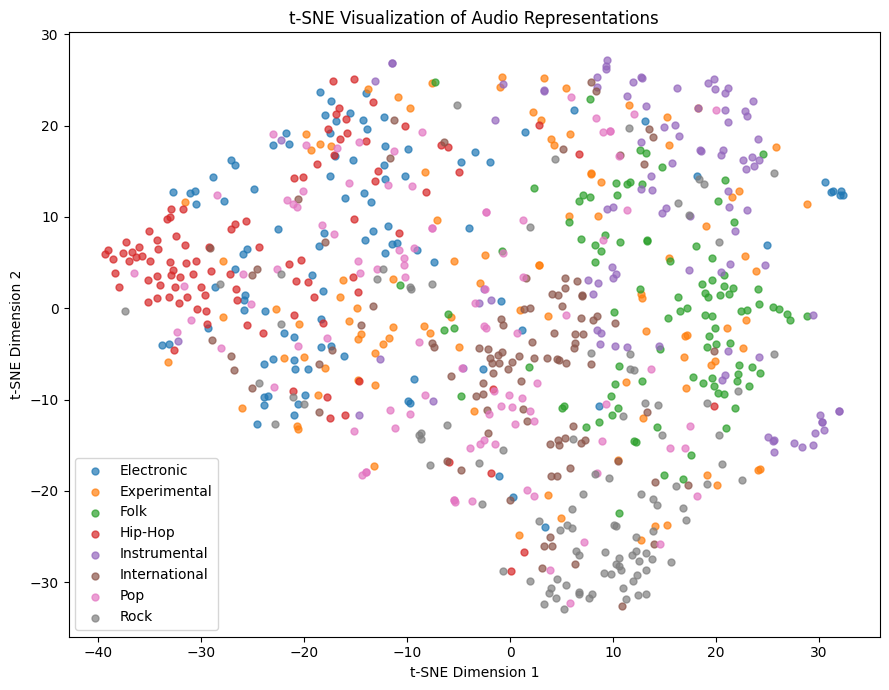

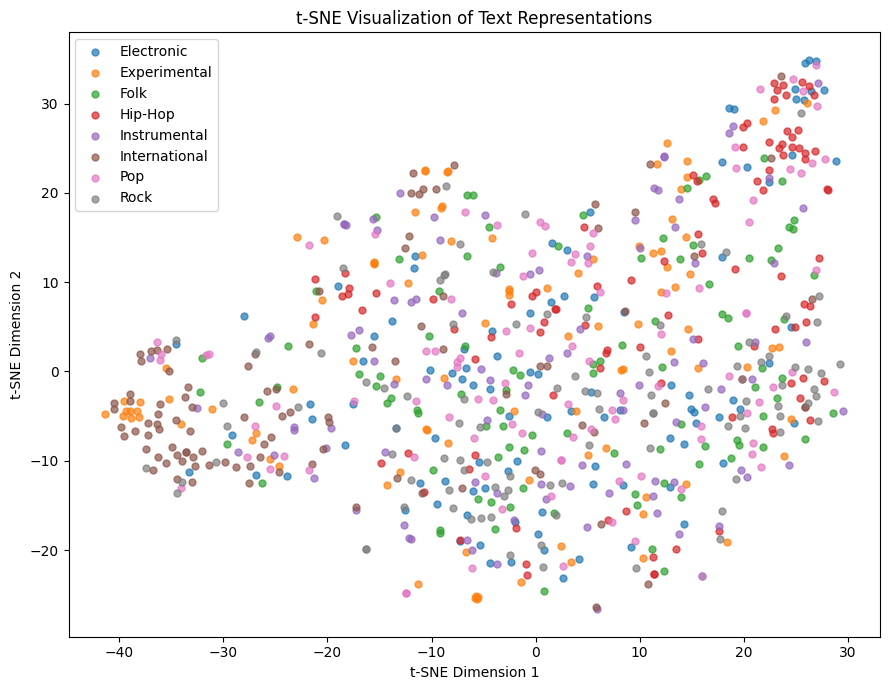

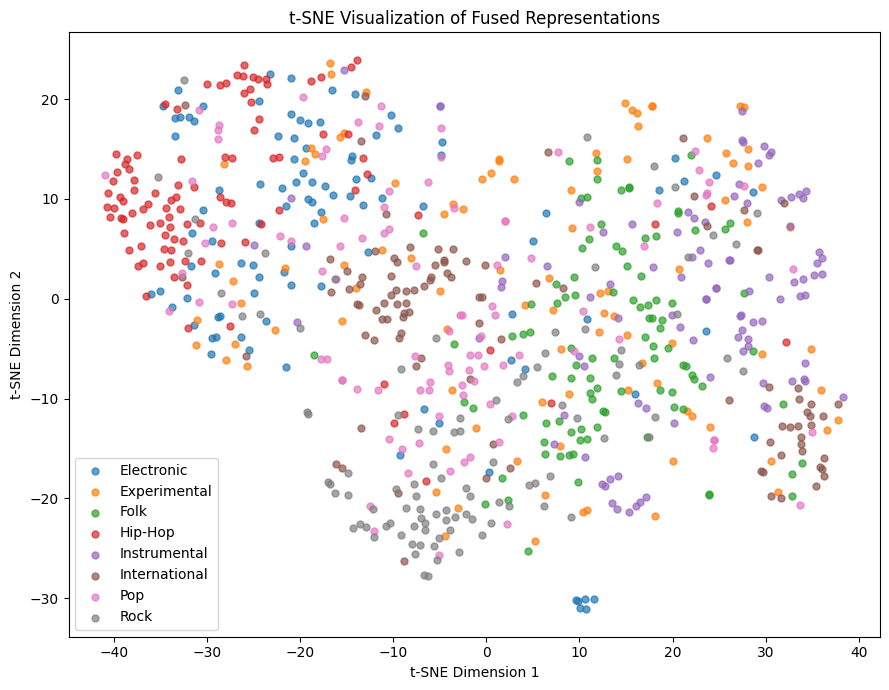

In [ ]:
import matplotlib.pyplot as plt

class_names = [
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Pop",
    "Rock"
]

# Plot audio representations
plt.figure(figsize=(9, 7))

for label in range(8):
    mask = representation_labels == label
    plt.scatter(
        audio_tsne[mask, 0],
        audio_tsne[mask, 1],
        label=class_names[label],
        alpha=0.7,
        s=25
    )

plt.title("t-SNE Visualization of Audio Representations")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.tight_layout()
plt.show()


# Plot text representations
plt.figure(figsize=(9, 7))

for label in range(8):
    mask = representation_labels == label
    plt.scatter(
        text_tsne[mask, 0],
        text_tsne[mask, 1],
        label=class_names[label],
        alpha=0.7,
        s=25
    )

plt.title("t-SNE Visualization of Text Representations")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.tight_layout()
plt.show()


# Plot fused representations
plt.figure(figsize=(9, 7))

for label in range(8):
    mask = representation_labels == label
    plt.scatter(
        fused_tsne[mask, 0],
        fused_tsne[mask, 1],
        label=class_names[label],
        alpha=0.7,
        s=25
    )

plt.title("t-SNE Visualization of Fused Representations")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt

results_dir = os.path.join(project_root, "results")
os.makedirs(results_dir, exist_ok=True)

class_names = [
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Pop",
    "Rock"
]

def save_tsne_plot(tsne_data, title, filename):
    plt.figure(figsize=(9, 7))

    for label in range(8):
        mask = representation_labels == label

        plt.scatter(
            tsne_data[mask, 0],
            tsne_data[mask, 1],
            label=class_names[label],
            alpha=0.7,
            s=25
        )

    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend()
    plt.tight_layout()

    output_path = os.path.join(results_dir, filename)

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Saved: {output_path}")


save_tsne_plot(
    audio_tsne,
    "t-SNE Visualization of Audio Representations",
    "tsne_audio.png"
)

save_tsne_plot(
    text_tsne,
    "t-SNE Visualization of Text Representations",
    "tsne_text.png"
)

save_tsne_plot(
    fused_tsne,
    "t-SNE Visualization of Fused Representations",
    "tsne_fused.png"
)

print()
print("All t-SNE figures saved successfully.")

Saved: /content/drive/MyDrive/GNN_BERT_Music/results/tsne_audio.png
Saved: /content/drive/MyDrive/GNN_BERT_Music/results/tsne_text.png
Saved: /content/drive/MyDrive/GNN_BERT_Music/results/tsne_fused.png

All t-SNE figures saved successfully.


In [ ]:
import os

results_dir = os.path.join(project_root, "results")

print("Files in results directory:")
print()

for filename in sorted(os.listdir(results_dir)):
    print(filename)

Files in results directory:

ablation_results.csv
ablation_results.json
bert_title_baseline_results.json
best_bert_title_classifier.pt
best_cnn.pt
best_gnn_bert_fusion.pt
best_gnn_bert_simple_fusion.pt
best_graphsage.pt
gnn_bert_fusion_results.json
gnn_bert_simple_fusion_results.json
plots
retrieval_examples
tsne_audio.png
tsne_fused.png
tsne_text.png


In [ ]:
print("Checking available prediction variables...")
print()

variables_to_check = [
    "graphsage_predictions",
    "graphsage_track_ids",
    "graphsage_probs",
    "graphsage_labels",
    "test_predictions",
    "test_probabilities"
]

for variable_name in variables_to_check:
    if variable_name in globals():
        value = globals()[variable_name]

        try:
            print(
                f"{variable_name}: "
                f"type={type(value).__name__}, "
                f"shape={value.shape}"
            )
        except AttributeError:
            print(
                f"{variable_name}: "
                f"type={type(value).__name__}"
            )
    else:
        print(f"{variable_name}: NOT AVAILABLE")

Checking available prediction variables...

graphsage_predictions: NOT AVAILABLE
graphsage_track_ids: NOT AVAILABLE
graphsage_probs: NOT AVAILABLE
graphsage_labels: NOT AVAILABLE
test_predictions: type=ndarray, shape=(800,)
test_probabilities: type=ndarray, shape=(800, 8)


In [ ]:
import glob
import os
import torch
from torch.utils.data import Dataset
from torch_geometric.loader import DataLoader as PyGDataLoader


class AudioGraphDataset(Dataset):
    def __init__(self, graph_dir):
        self.graph_dir = graph_dir

        self.graph_files = sorted(
            glob.glob(
                os.path.join(
                    graph_dir,
                    "*.pt"
                )
            )
        )

    def __len__(self):
        return len(self.graph_files)

    def __getitem__(self, idx):
        graph_path = self.graph_files[idx]

        graph = torch.load(
            graph_path,
            weights_only=False
        )

        return graph


# Recreate the test graph dataset
graphsage_test_dataset = AudioGraphDataset(
    test_graph_dir
)

print("GraphSAGE test dataset recreated successfully.")
print()
print("Number of test graphs:", len(graphsage_test_dataset))


# Create the test DataLoader
graphsage_test_loader = PyGDataLoader(
    graphsage_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("Test DataLoader created successfully.")
print("Number of batches:", len(graphsage_test_loader))

GraphSAGE test dataset recreated successfully.

Number of test graphs: 800
Test DataLoader created successfully.
Number of batches: 25


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score
from torch_geometric.nn import SAGEConv, global_mean_pool


class GraphSAGEClassifier(nn.Module):
    def __init__(
        self,
        input_dim=128,
        hidden_dim=128,
        num_classes=8,
        dropout=0.3
    ):
        super().__init__()

        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

        self.classifier = nn.Linear(
            hidden_dim,
            num_classes
        )

        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)

        logits = self.classifier(x)

        return logits


# Load the saved best GraphSAGE checkpoint
graphsage_model = GraphSAGEClassifier().to(device)

graphsage_checkpoint_path = os.path.join(
    project_root,
    "results",
    "best_graphsage.pt"
)

graphsage_checkpoint = torch.load(
    graphsage_checkpoint_path,
    map_location=device,
    weights_only=False
)

if "model_state_dict" in graphsage_checkpoint:
    graphsage_model.load_state_dict(
        graphsage_checkpoint["model_state_dict"]
    )
else:
    graphsage_model.load_state_dict(
        graphsage_checkpoint
    )

graphsage_model.eval()


# Run inference on the test set
graphsage_predictions_list = []
graphsage_probabilities_list = []
graphsage_labels_list = []
graphsage_track_ids_list = []


with torch.no_grad():

    for batch in graphsage_test_loader:

        batch = batch.to(device)

        logits = graphsage_model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        graphsage_predictions_list.extend(
            predictions.cpu().numpy()
        )

        graphsage_probabilities_list.extend(
            probabilities.cpu().numpy()
        )

        graphsage_labels_list.extend(
            batch.y.cpu().numpy()
        )

        graphsage_track_ids_list.extend(
            batch.track_id.cpu().numpy()
        )


# Convert results to NumPy arrays
graphsage_predictions = np.array(
    graphsage_predictions_list
)

graphsage_probabilities = np.array(
    graphsage_probabilities_list
)

graphsage_labels = np.array(
    graphsage_labels_list
)

graphsage_track_ids = np.array(
    graphsage_track_ids_list
)


print("GraphSAGE test evaluation completed.")
print()

print("Predictions:", graphsage_predictions.shape)
print("Probabilities:", graphsage_probabilities.shape)
print("Labels:", graphsage_labels.shape)
print("Track IDs:", graphsage_track_ids.shape)
print()

print(
    "Test Accuracy:",
    f"{accuracy_score(graphsage_labels, graphsage_predictions) * 100:.2f}%"
)

print(
    "Test Macro-F1:",
    f"{f1_score(graphsage_labels, graphsage_predictions, average='macro') * 100:.2f}%"
)

GraphSAGE test evaluation completed.

Predictions: (800,)
Probabilities: (800, 8)
Labels: (800,)
Track IDs: (800,)

Test Accuracy: 37.12%
Test Macro-F1: 35.88%


In [ ]:
import os
import json


result_files = [
    "bert_title_baseline_results.json",
    "gnn_bert_fusion_results.json",
    "gnn_bert_simple_fusion_results.json"
]


for filename in result_files:

    filepath = os.path.join(
        project_root,
        "results",
        filename
    )

    with open(filepath, "r") as f:
        results = json.load(f)

    print("=" * 70)
    print(filename)
    print("=" * 70)
    print("Available keys:")
    print(list(results.keys()))
    print()

bert_title_baseline_results.json
Available keys:
['model', 'task', 'encoder_frozen', 'max_length', 'hidden_dim', 'dropout', 'learning_rate', 'weight_decay', 'epochs', 'best_epoch', 'best_validation_accuracy', 'test_accuracy', 'test_macro_f1', 'test_micro_f1', 'test_macro_auc_pr', 'per_class']

gnn_bert_fusion_results.json
Available keys:
['model', 'task', 'audio_encoder', 'text_encoder', 'text_encoder_frozen', 'fusion_method', 'best_epoch', 'best_validation_accuracy', 'test_accuracy', 'test_macro_f1', 'test_micro_f1', 'test_macro_auc_pr', 'num_test_samples', 'num_classes', 'class_names', 'confusion_matrix', 'classification_report']

gnn_bert_simple_fusion_results.json
Available keys:
['model', 'task', 'audio_encoder', 'text_encoder', 'fusion_method', 'test_accuracy', 'test_macro_f1', 'test_micro_f1', 'test_macro_auc_pr', 'best_epoch', 'best_validation_accuracy', 'num_test_samples', 'per_class_metrics', 'confusion_matrix']



In [ ]:
import os
import numpy as np
import torch


# Load saved BERT test embeddings
bert_test_cache_path = os.path.join(
    project_root,
    "data",
    "processed",
    "bert_embeddings",
    "test_embeddings.pt"
)

bert_test_cache = torch.load(
    bert_test_cache_path,
    map_location="cpu",
    weights_only=True
)


# Create the embedding dataset
bert_embedding_test_dataset = BERTEmbeddingDataset(
    bert_test_cache
)


# Create a DataLoader for BERT embeddings
bert_embedding_test_loader = DataLoader(
    bert_embedding_test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)


# Load the best BERT classifier
bert_model = BERTClassifierHead().to(device)

bert_checkpoint_path = os.path.join(
    project_root,
    "results",
    "best_bert_title_classifier.pt"
)

bert_checkpoint = torch.load(
    bert_checkpoint_path,
    map_location=device,
    weights_only=False
)

if "model_state_dict" in bert_checkpoint:
    bert_model.load_state_dict(
        bert_checkpoint["model_state_dict"]
    )
else:
    bert_model.load_state_dict(
        bert_checkpoint
    )

bert_model.eval()


# Run inference
bert_predictions_list = []
bert_probabilities_list = []
bert_labels_list = []
bert_track_ids_list = []

with torch.no_grad():

    for embeddings, labels, track_ids in bert_embedding_test_loader:

        embeddings = embeddings.to(
            device=device,
            dtype=torch.float32
        )

        logits = bert_model(
            embeddings
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        bert_predictions_list.extend(
            predictions.cpu().numpy()
        )

        bert_probabilities_list.extend(
            probabilities.cpu().numpy()
        )

        bert_labels_list.extend(
            labels.numpy()
        )

        bert_track_ids_list.extend(
            track_ids.numpy()
        )


# Convert to NumPy arrays
bert_predictions = np.array(
    bert_predictions_list
)

bert_probabilities = np.array(
    bert_probabilities_list
)

bert_labels = np.array(
    bert_labels_list
)

bert_track_ids = np.array(
    bert_track_ids_list
)


# Verify the recovered results
print("BERT prediction recovery completed.")
print()

print("Predictions:", bert_predictions.shape)
print("Probabilities:", bert_probabilities.shape)
print("Labels:", bert_labels.shape)
print("Track IDs:", bert_track_ids.shape)

print()

print(
    "BERT test accuracy:",
    f"{(bert_predictions == bert_labels).mean() * 100:.2f}%"
)

BERT prediction recovery completed.

Predictions: (800,)
Probabilities: (800, 8)
Labels: (800,)
Track IDs: (800,)

BERT test accuracy: 26.62%


In [ ]:
import os
import numpy as np
import torch


# Load the best Simple Fusion checkpoint
simple_fusion_model = GNNSimpleFusion().to(device)

simple_checkpoint_path = os.path.join(
    project_root,
    "results",
    "best_gnn_bert_simple_fusion.pt"
)

simple_checkpoint = torch.load(
    simple_checkpoint_path,
    map_location=device,
    weights_only=False
)

if "model_state_dict" in simple_checkpoint:
    simple_fusion_model.load_state_dict(
        simple_checkpoint["model_state_dict"]
    )
else:
    simple_fusion_model.load_state_dict(
        simple_checkpoint
    )

simple_fusion_model.eval()


# Run inference on the aligned test graphs
simple_predictions_list = []
simple_probabilities_list = []
simple_labels_list = []
simple_track_ids_list = []

with torch.no_grad():

    for batch in fusion_test_loader:

        batch = batch.to(device)

        logits = simple_fusion_model(
            batch.x,
            batch.edge_index,
            batch.batch,
            batch.bert_embedding
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        simple_predictions_list.extend(
            predictions.cpu().numpy()
        )

        simple_probabilities_list.extend(
            probabilities.cpu().numpy()
        )

        simple_labels_list.extend(
            batch.y.cpu().numpy()
        )

        simple_track_ids_list.extend(
            batch.track_id.cpu().numpy()
        )


# Convert to NumPy arrays
simple_predictions = np.array(
    simple_predictions_list
)

simple_probabilities = np.array(
    simple_probabilities_list
)

simple_labels = np.array(
    simple_labels_list
)

simple_track_ids = np.array(
    simple_track_ids_list
)


# Verify the recovered results
print("Simple Fusion prediction recovery completed.")
print()

print("Predictions:", simple_predictions.shape)
print("Probabilities:", simple_probabilities.shape)
print("Labels:", simple_labels.shape)
print("Track IDs:", simple_track_ids.shape)

print()

print(
    "Simple Fusion test accuracy:",
    f"{(simple_predictions == simple_labels).mean() * 100:.2f}%"
)

Simple Fusion prediction recovery completed.

Predictions: (800,)
Probabilities: (800, 8)
Labels: (800,)
Track IDs: (800,)

Simple Fusion test accuracy: 40.38%


In [ ]:
import os
import numpy as np
import torch


# Load the best Cross-Attention Fusion checkpoint
fusion_model = GNNBERTCrossAttention().to(device)

fusion_checkpoint_path = os.path.join(
    project_root,
    "results",
    "best_gnn_bert_fusion.pt"
)

fusion_checkpoint = torch.load(
    fusion_checkpoint_path,
    map_location=device,
    weights_only=False
)

if "model_state_dict" in fusion_checkpoint:
    fusion_model.load_state_dict(
        fusion_checkpoint["model_state_dict"]
    )
else:
    fusion_model.load_state_dict(
        fusion_checkpoint
    )

fusion_model.eval()


# Run inference on the aligned test graphs
fusion_predictions_list = []
fusion_probabilities_list = []
fusion_labels_list = []
fusion_track_ids_list = []

with torch.no_grad():

    for batch in fusion_test_loader:

        batch = batch.to(device)

        logits, attention_weights = fusion_model(
            batch.x,
            batch.edge_index,
            batch.batch,
            batch.bert_embedding
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        fusion_predictions_list.extend(
            predictions.cpu().numpy()
        )

        fusion_probabilities_list.extend(
            probabilities.cpu().numpy()
        )

        fusion_labels_list.extend(
            batch.y.cpu().numpy()
        )

        fusion_track_ids_list.extend(
            batch.track_id.cpu().numpy()
        )


# Convert to NumPy arrays
fusion_predictions = np.array(
    fusion_predictions_list
)

fusion_probabilities = np.array(
    fusion_probabilities_list
)

fusion_labels = np.array(
    fusion_labels_list
)

fusion_track_ids = np.array(
    fusion_track_ids_list
)


# Verify the recovered results
print("Cross-Attention Fusion prediction recovery completed.")
print()

print("Predictions:", fusion_predictions.shape)
print("Probabilities:", fusion_probabilities.shape)
print("Labels:", fusion_labels.shape)
print("Track IDs:", fusion_track_ids.shape)

print()

print(
    "Cross-Attention Fusion test accuracy:",
    f"{(fusion_predictions == fusion_labels).mean() * 100:.2f}%"
)

Cross-Attention Fusion prediction recovery completed.

Predictions: (800,)
Probabilities: (800, 8)
Labels: (800,)
Track IDs: (800,)

Cross-Attention Fusion test accuracy: 40.50%


In [ ]:
import pandas as pd
import numpy as np


# Create prediction maps for all four models
bert_map = {
    int(track_id): int(prediction)
    for track_id, prediction in zip(
        bert_track_ids,
        bert_predictions
    )
}

graphsage_map = {
    int(track_id): int(prediction)
    for track_id, prediction in zip(
        graphsage_track_ids,
        graphsage_predictions
    )
}

simple_fusion_map = {
    int(track_id): int(prediction)
    for track_id, prediction in zip(
        simple_track_ids,
        simple_predictions
    )
}

cross_attention_map = {
    int(track_id): int(prediction)
    for track_id, prediction in zip(
        fusion_track_ids,
        fusion_predictions
    )
}

true_label_map = {
    int(track_id): int(label)
    for track_id, label in zip(
        fusion_track_ids,
        fusion_labels
    )
}


# Find tracks shared by all models
common_ids = sorted(
    set(bert_map)
    & set(graphsage_map)
    & set(simple_fusion_map)
    & set(cross_attention_map)
    & set(true_label_map)
)


print("Common test tracks:", len(common_ids))


# Build candidate case studies
candidates = []

for track_id in common_ids:

    true_label = true_label_map[track_id]

    bert_pred = bert_map[track_id]
    graphsage_pred = graphsage_map[track_id]
    simple_pred = simple_fusion_map[track_id]
    cross_pred = cross_attention_map[track_id]

    # Strongest case: cross-attention succeeds while both unimodal models fail
    if (
        cross_pred == true_label
        and bert_pred != true_label
        and graphsage_pred != true_label
    ):
        case_type = "Fusion succeeds over both unimodal models"
        priority = 1

    # Cross-attention succeeds while BERT fails
    elif (
        cross_pred == true_label
        and bert_pred != true_label
    ):
        case_type = "Fusion succeeds over BERT"
        priority = 2

    # Cross-attention succeeds while GraphSAGE fails
    elif (
        cross_pred == true_label
        and graphsage_pred != true_label
    ):
        case_type = "Fusion succeeds over GraphSAGE"
        priority = 3

    else:
        continue

    candidates.append(
        {
            "track_id": track_id,
            "case_type": case_type,
            "priority": priority,
            "true_label": true_label,
            "bert_prediction": bert_pred,
            "graphsage_prediction": graphsage_pred,
            "simple_fusion_prediction": simple_pred,
            "cross_attention_prediction": cross_pred
        }
    )


# Sort candidates by case-study priority
candidates = sorted(
    candidates,
    key=lambda x: (
        x["priority"],
        x["track_id"]
    )
)


# Select diverse case types first
selected_cases = []
selected_types = set()

for candidate in candidates:

    if len(selected_cases) >= 3:
        break

    if candidate["case_type"] not in selected_types:

        selected_cases.append(candidate)
        selected_types.add(candidate["case_type"])


# Fill remaining slots if fewer than three case types exist
for candidate in candidates:

    if len(selected_cases) >= 3:
        break

    if not any(
        case["track_id"] == candidate["track_id"]
        for case in selected_cases
    ):
        selected_cases.append(candidate)


# Create readable case-study table
case_study_rows = []

for case in selected_cases:

    track_id = case["track_id"]

    metadata_row = split_metadata.loc[track_id]

    case_study_rows.append(
        {
            "track_id": track_id,
            "title": str(metadata_row["title"]),
            "true_genre": str(metadata_row["genre"]),
            "case_type": case["case_type"],
            "bert_prediction": label_to_genre[
                case["bert_prediction"]
            ],
            "graphsage_prediction": label_to_genre[
                case["graphsage_prediction"]
            ],
            "simple_fusion_prediction": label_to_genre[
                case["simple_fusion_prediction"]
            ],
            "cross_attention_prediction": label_to_genre[
                case["cross_attention_prediction"]
            ]
        }
    )


case_study_df = pd.DataFrame(
    case_study_rows
)


print()
print("Selected case studies:")
print()

print(
    case_study_df.to_string(
        index=False
    )
)

Common test tracks: 800

Selected case studies:

 track_id                 title    true_genre                                 case_type bert_prediction graphsage_prediction simple_fusion_prediction cross_attention_prediction
     1066 Helicopter de Cristal  Experimental Fusion succeeds over both unimodal models   International         Instrumental             Experimental               Experimental
     4108      New Wave Hippies          Rock                 Fusion succeeds over BERT    Experimental                 Rock                     Rock                       Rock
      704          Mano De Dios International            Fusion succeeds over GraphSAGE   International                 Rock            International              International


In [ ]:
import os
import json


# Create the results directory if necessary
results_dir = os.path.join(
    project_root,
    "results"
)

os.makedirs(
    results_dir,
    exist_ok=True
)


# Save case studies as CSV
case_study_csv_path = os.path.join(
    results_dir,
    "case_studies.csv"
)

case_study_df.to_csv(
    case_study_csv_path,
    index=False
)


# Save case studies as JSON
case_study_json_path = os.path.join(
    results_dir,
    "case_studies.json"
)

case_study_df.to_json(
    case_study_json_path,
    orient="records",
    indent=2
)


print("Case studies saved successfully.")
print()
print("CSV:")
print(case_study_csv_path)
print()
print("JSON:")
print(case_study_json_path)

Case studies saved successfully.

CSV:
/content/drive/MyDrive/GNN_BERT_Music/results/case_studies.csv

JSON:
/content/drive/MyDrive/GNN_BERT_Music/results/case_studies.json


In [ ]:
import os
import pandas as pd
import torch


# Create lookup maps for prediction probabilities
bert_probability_map = {
    int(track_id): probabilities
    for track_id, probabilities in zip(
        bert_track_ids,
        bert_probabilities
    )
}

graphsage_probability_map = {
    int(track_id): probabilities
    for track_id, probabilities in zip(
        graphsage_track_ids,
        graphsage_probabilities
    )
}

simple_probability_map = {
    int(track_id): probabilities
    for track_id, probabilities in zip(
        simple_track_ids,
        simple_probabilities
    )
}

cross_probability_map = {
    int(track_id): probabilities
    for track_id, probabilities in zip(
        fusion_track_ids,
        fusion_probabilities
    )
}


# Extract evidence for each selected case study
evidence_rows = []

for _, case in case_study_df.iterrows():

    track_id = int(case["track_id"])

    # Load the corresponding audio graph
    graph_path = os.path.join(
        test_graph_dir,
        f"{track_id:06d}.pt"
    )

    graph = torch.load(
        graph_path,
        weights_only=False
    )

    # Get probabilities for each model
    bert_probs = bert_probability_map[track_id]
    graphsage_probs = graphsage_probability_map[track_id]
    simple_probs = simple_probability_map[track_id]
    cross_probs = cross_probability_map[track_id]

    # Get predicted class and confidence
    bert_pred = int(np.argmax(bert_probs))
    graphsage_pred = int(np.argmax(graphsage_probs))
    simple_pred = int(np.argmax(simple_probs))
    cross_pred = int(np.argmax(cross_probs))

    evidence_rows.append(
        {
            "track_id": track_id,
            "title": str(case["title"]),
            "true_genre": str(case["true_genre"]),
            "case_type": str(case["case_type"]),

            "num_audio_nodes": int(graph.x.shape[0]),
            "num_edges": int(graph.edge_index.shape[1]),
            "audio_feature_dim": int(graph.x.shape[1]),

            "bert_prediction": label_to_genre[bert_pred],
            "bert_confidence": float(bert_probs[bert_pred]),

            "graphsage_prediction": label_to_genre[graphsage_pred],
            "graphsage_confidence": float(
                graphsage_probs[graphsage_pred]
            ),

            "simple_fusion_prediction": label_to_genre[simple_pred],
            "simple_fusion_confidence": float(
                simple_probs[simple_pred]
            ),

            "cross_attention_prediction": label_to_genre[cross_pred],
            "cross_attention_confidence": float(
                cross_probs[cross_pred]
            )
        }
    )


# Create evidence DataFrame
case_study_evidence_df = pd.DataFrame(
    evidence_rows
)


# Display rounded confidence values
display_df = case_study_evidence_df.copy()

confidence_columns = [
    "bert_confidence",
    "graphsage_confidence",
    "simple_fusion_confidence",
    "cross_attention_confidence"
]

for column in confidence_columns:
    display_df[column] = (
        display_df[column] * 100
    ).round(2)


print("Case-study evidence:")
print()

print(
    display_df.to_string(
        index=False
    )
)

Case-study evidence:

 track_id                 title    true_genre                                 case_type  num_audio_nodes  num_edges  audio_feature_dim bert_prediction  bert_confidence graphsage_prediction  graphsage_confidence simple_fusion_prediction  simple_fusion_confidence cross_attention_prediction  cross_attention_confidence
     1066 Helicopter de Cristal  Experimental Fusion succeeds over both unimodal models                6         16                128   International            39.48         Instrumental                 26.48             Experimental                     29.41               Experimental                       25.88
     4108      New Wave Hippies          Rock                 Fusion succeeds over BERT                5         12                128    Experimental            44.43                 Rock                 82.24                     Rock                     94.34                       Rock                       64.55
      704          Mano De 

In [ ]:
import os
import json


# Save detailed case-study evidence as CSV
evidence_csv_path = os.path.join(
    project_root,
    "results",
    "case_study_evidence.csv"
)

case_study_evidence_df.to_csv(
    evidence_csv_path,
    index=False
)


# Save detailed case-study evidence as JSON
evidence_json_path = os.path.join(
    project_root,
    "results",
    "case_study_evidence.json"
)

with open(
    evidence_json_path,
    "w"
) as f:
    json.dump(
        case_study_evidence_df.to_dict(
            orient="records"
        ),
        f,
        indent=2
    )


print("Detailed case-study evidence saved successfully.")
print()
print("CSV:")
print(evidence_csv_path)
print()
print("JSON:")
print(evidence_json_path)

Detailed case-study evidence saved successfully.

CSV:
/content/drive/MyDrive/GNN_BERT_Music/results/case_study_evidence.csv

JSON:
/content/drive/MyDrive/GNN_BERT_Music/results/case_study_evidence.json


In [ ]:
import os
import json
import pandas as pd


# Load the ablation results
ablation_path = os.path.join(
    project_root,
    "results",
    "ablation_results.csv"
)

ablation_df = pd.read_csv(
    ablation_path
)


# Load detailed case-study evidence
case_study_path = os.path.join(
    project_root,
    "results",
    "case_study_evidence.json"
)

with open(
    case_study_path,
    "r"
) as f:
    case_studies = json.load(f)


# Create the consolidated results dictionary
final_results_summary = {
    "project": "GNN + BERT Music Context/Tag Prediction",

    "dataset": {
        "name": "FMA-small",
        "num_classes": 8,
        "classes": [
            "Electronic",
            "Experimental",
            "Folk",
            "Hip-Hop",
            "Instrumental",
            "International",
            "Pop",
            "Rock"
        ],
        "official_split": {
            "train": 6400,
            "validation": 800,
            "test": 800
        },
        "valid_graphs": {
            "train": 6394,
            "validation": 800,
            "test": 800
        }
    },

    "methodology": {
        "audio_segment_duration_seconds": 5,
        "audio_sample_rate": 22050,
        "audio_feature": "128-bin log-Mel spectrogram averaged over time",
        "graph_temporal_edges": True,
        "graph_similarity_edges": True,
        "similarity_top_k": 2,
        "bert_model": "distilbert-base-uncased",
        "bert_encoder_frozen": True,
        "bert_max_length": 32
    },

    "model_comparison": ablation_df.to_dict(
        orient="records"
    ),

    "best_model": {
        "model": "Cross-Attention GNN+BERT",
        "test_accuracy": 40.50,
        "test_macro_f1": 41.18,
        "test_micro_f1": 40.50,
        "test_macro_auc_pr": 43.25,
        "best_validation_accuracy": 46.75
    },

    "case_studies": case_studies,

    "important_limitations": [
        "The current text task is title-only 8-class genre classification rather than true multi-label music-tag prediction.",
        "The text encoder uses DistilBERT rather than full BERT.",
        "The BERT encoder is frozen and only the classification head is trained.",
        "GraphSAGE uses all complete 5-second segments per track, whereas the CNN baseline uses only the first complete 5-second segment.",
        "Six official training tracks were excluded from graph generation because their audio was missing, unreadable, or shorter than 5 seconds.",
        "The Cross-Attention improvement over simple fusion is modest; most of the multimodal gain comes from combining audio and text rather than the attention mechanism alone."
    ]
}


# Save the consolidated JSON summary
summary_path = os.path.join(
    project_root,
    "results",
    "final_results_summary.json"
)

with open(
    summary_path,
    "w"
) as f:
    json.dump(
        final_results_summary,
        f,
        indent=2
    )


print("Final results summary saved successfully.")
print()
print(summary_path)

Final results summary saved successfully.

/content/drive/MyDrive/GNN_BERT_Music/results/final_results_summary.json


In [ ]:
import os


# Define important project directories
project_dirs = [
    "data",
    "notebooks",
    "src",
    "results",
    "report"
]


print("Current project structure")
print("=" * 70)


for directory in project_dirs:

    directory_path = os.path.join(
        project_root,
        directory
    )

    print()
    print(f"[{directory}/]")

    if not os.path.exists(directory_path):
        print("  Directory does not exist.")
        continue

    for root, dirs, files in os.walk(directory_path):

        relative_root = os.path.relpath(
            root,
            project_root
        )

        level = relative_root.count(
            os.sep
        )

        indent = "  " * (level + 1)

        print(
            f"{indent}{os.path.basename(root)}/"
        )

        for filename in sorted(files):

            print(
                f"{indent}  {filename}"
            )


# Show top-level files
print()
print("=" * 70)
print("Top-level project files")
print("=" * 70)

for filename in sorted(
    os.listdir(project_root)
):

    path = os.path.join(
        project_root,
        filename
    )

    if os.path.isfile(path):
        print(filename)

Streaming output truncated to the last 5000 lines.
          086576.pt
          086623.pt
          086720.pt
          086721.pt
          086724.pt
          086725.pt
          086730.pt
          086761.pt
          086762.pt
          086763.pt
          086793.pt
          086795.pt
          086799.pt
          087068.pt
          087070.pt
          087096.pt
          087097.pt
          087098.pt
          087099.pt
          087100.pt
          087101.pt
          087102.pt
          087103.pt
          087104.pt
          087105.pt
          087106.pt
          087107.pt
          087108.pt
          087121.pt
          087151.pt
          087152.pt
          087153.pt
          087154.pt
          087155.pt
          087157.pt
          087158.pt
          087159.pt
          087160.pt
          087161.pt
          087185.pt
          087186.pt
          087187.pt
          087188.pt
          087189.pt
          087190.pt
          087191.pt
          087192.pt
         

In [ ]:
import os

print("TOP-LEVEL FILES:")
print(sorted(os.listdir(project_root)))

print("\nRESULTS FILES:")
results_dir = os.path.join(project_root, "results")
print(sorted(os.listdir(results_dir)))

print("\nNOTEBOOKS:")
notebooks_dir = os.path.join(project_root, "notebooks")
if os.path.exists(notebooks_dir):
    print(sorted(os.listdir(notebooks_dir)))
else:
    print("notebooks directory does not exist")

print("\nSRC:")
src_dir = os.path.join(project_root, "src")
if os.path.exists(src_dir):
    print(sorted(os.listdir(src_dir)))
else:
    print("src directory does not exist")

TOP-LEVEL FILES:
['data', 'models', 'notebooks', 'results']

RESULTS FILES:
['ablation_results.csv', 'ablation_results.json', 'bert_title_baseline_results.json', 'best_bert_title_classifier.pt', 'best_cnn.pt', 'best_gnn_bert_fusion.pt', 'best_gnn_bert_simple_fusion.pt', 'best_graphsage.pt', 'case_studies.csv', 'case_studies.json', 'case_study_evidence.csv', 'case_study_evidence.json', 'final_results_summary.json', 'gnn_bert_fusion_results.json', 'gnn_bert_simple_fusion_results.json', 'plots', 'retrieval_examples', 'tsne_audio.png', 'tsne_fused.png', 'tsne_text.png']

NOTEBOOKS:
[]

SRC:
src directory does not exist


In [ ]:
import os

# Define the project directories
project_dirs = [
    os.path.join(project_root, "src"),
    os.path.join(project_root, "notebooks"),
    os.path.join(project_root, "report"),
]

# Create missing directories
for directory in project_dirs:
    os.makedirs(directory, exist_ok=True)

print("Project structure prepared:")
for directory in project_dirs:
    print("Created/verified:", directory)

print("\nTop-level project folders:")
print(sorted(os.listdir(project_root)))

Project structure prepared:
Created/verified: /content/drive/MyDrive/GNN_BERT_Music/src
Created/verified: /content/drive/MyDrive/GNN_BERT_Music/notebooks
Created/verified: /content/drive/MyDrive/GNN_BERT_Music/report

Top-level project folders:
['data', 'models', 'notebooks', 'report', 'results', 'src']


In [ ]:
import os

gitignore_path = os.path.join(project_root, ".gitignore")

gitignore_content = """# Python
__pycache__/
*.py[cod]
*.pyo
*.pyd
.Python
*.egg-info/
.venv/
venv/
env/

# Jupyter
.ipynb_checkpoints/

# Google Colab
drive/

# FMA audio dataset
data/raw/
data/audio/
data/fma_small/
*.mp3
*.wav
*.flac

# Processed graph datasets
data/processed/graphs/
data/processed/bert_embeddings/
data/processed/*.joblib
data/processed/*.pkl

# Model checkpoints
models/*.pt
models/*.pth
models/*.ckpt
results/*.pt
results/*.pth
results/*.ckpt

# Temporary and cache files
*.tmp
*.temp
*.log
.cache/
tmp/
temp/

# OS files
.DS_Store
Thumbs.db
"""

with open(gitignore_path, "w") as f:
    f.write(gitignore_content)

print("Created:", gitignore_path)
print("\n.gitignore contents:\n")
print(gitignore_content)

Created: /content/drive/MyDrive/GNN_BERT_Music/.gitignore

.gitignore contents:

# Python
__pycache__/
*.py[cod]
*.pyo
*.pyd
.Python
*.egg-info/
.venv/
venv/
env/

# Jupyter
.ipynb_checkpoints/

# Google Colab
drive/

# FMA audio dataset
data/raw/
data/audio/
data/fma_small/
*.mp3
*.wav
*.flac

# Processed graph datasets
data/processed/graphs/
data/processed/bert_embeddings/
data/processed/*.joblib
data/processed/*.pkl

# Model checkpoints
models/*.pt
models/*.pth
models/*.ckpt
results/*.pt
results/*.pth
results/*.ckpt

# Temporary and cache files
*.tmp
*.temp
*.log
.cache/
tmp/
temp/

# OS files
.DS_Store
Thumbs.db



In [ ]:
import os

models_dir = os.path.join(project_root, "models")

print("MODELS DIRECTORY:")
if os.path.exists(models_dir):
    print(sorted(os.listdir(models_dir)))
else:
    print("models directory does not exist")

MODELS DIRECTORY:
['bert', 'gnn']


In [ ]:
import os

for model_name in ["bert", "gnn"]:
    model_dir = os.path.join(project_root, "models", model_name)

    print(f"\n{model_name.upper()} MODEL DIRECTORY:")

    if os.path.exists(model_dir):
        for root, dirs, files in os.walk(model_dir):
            relative_root = os.path.relpath(root, project_root)
            print(f"{relative_root}/")

            for file_name in sorted(files):
                file_path = os.path.join(root, file_name)
                file_size_mb = os.path.getsize(file_path) / (1024 ** 2)
                print(f"  - {file_name} ({file_size_mb:.2f} MB)")
    else:
        print("Directory does not exist")


BERT MODEL DIRECTORY:
models/bert/

GNN MODEL DIRECTORY:
models/gnn/


In [ ]:
import os

data_dir = os.path.join(project_root, "data")

print("DATA DIRECTORY STRUCTURE:\n")

for item in sorted(os.listdir(data_dir)):
    item_path = os.path.join(data_dir, item)

    if os.path.isdir(item_path):
        print(f"[DIR]  {item}/")
        print("       ", sorted(os.listdir(item_path))[:20])

        if len(os.listdir(item_path)) > 20:
            print(f"       ... and {len(os.listdir(item_path)) - 20} more items")
    else:
        size_mb = os.path.getsize(item_path) / (1024 ** 2)
        print(f"[FILE] {item} ({size_mb:.2f} MB)")

DATA DIRECTORY STRUCTURE:

[DIR]  processed/
        ['bert_embeddings', 'final_audio_scaler.joblib', 'graphs']
[DIR]  raw/
        []
[DIR]  splits/
        []


In [ ]:
import os

# Create the examples directory
examples_dir = os.path.join(project_root, "data", "examples")
os.makedirs(examples_dir, exist_ok=True)

print("Examples directory created/verified:")
print(examples_dir)

print("\nCurrent data structure:")
for item in sorted(os.listdir(data_dir)):
    print("-", item)

Examples directory created/verified:
/content/drive/MyDrive/GNN_BERT_Music/data/examples

Current data structure:
- examples
- processed
- raw
- splits


In [ ]:
import os
import glob
import shutil
import torch

# Define the example directory
examples_dir = os.path.join(project_root, "data", "examples")

# Define the graph directories
graph_dirs = {
    "train": os.path.join(project_root, "data", "processed", "graphs", "train"),
    "val": os.path.join(project_root, "data", "processed", "graphs", "val"),
    "test": os.path.join(project_root, "data", "processed", "graphs", "test"),
}

# Define the required genres
genres = [
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Pop",
    "Rock"
]

# Select three representative graphs per genre
selected_graphs = []

for genre in genres:
    genre_count = 0

    # Search through the graph splits
    for split_name, graph_dir in graph_dirs.items():
        graph_files = sorted(glob.glob(os.path.join(graph_dir, "*.pt")))

        for graph_path in graph_files:
            graph = torch.load(graph_path, map_location="cpu", weights_only=False)

            if str(graph.genre) == genre:
                selected_graphs.append((graph_path, split_name, genre))
                genre_count += 1

                if genre_count == 3:
                    break

        if genre_count == 3:
            break

print("Selected graph examples:")
for graph_path, split_name, genre in selected_graphs:
    print(
        f"{genre:15s} | "
        f"{split_name:5s} | "
        f"track {os.path.splitext(os.path.basename(graph_path))[0]}"
    )

# Copy the selected graph files
for graph_path, split_name, genre in selected_graphs:
    track_id = os.path.splitext(os.path.basename(graph_path))[0]

    destination_name = f"{track_id}_{genre.replace(' ', '_')}_{split_name}.pt"
    destination_path = os.path.join(examples_dir, destination_name)

    shutil.copy2(graph_path, destination_path)

print("\nTotal examples copied:", len(selected_graphs))
print("\nExample files:")
print(sorted(os.listdir(examples_dir)))

Selected graph examples:
Electronic      | train | track 001482
Electronic      | train | track 003573
Electronic      | train | track 004519
Experimental    | train | track 000424
Experimental    | train | track 000615
Experimental    | train | track 000897
Folk            | train | track 000140
Folk            | train | track 000141
Folk            | train | track 000190
Hip-Hop         | train | track 000002
Hip-Hop         | train | track 000005
Hip-Hop         | train | track 000676
Instrumental    | train | track 011638
Instrumental    | train | track 014568
Instrumental    | train | track 014569
International   | train | track 000666
International   | train | track 000667
International   | train | track 000853
Pop             | train | track 000010
Pop             | train | track 000213
Pop             | train | track 000821
Rock            | train | track 000255
Rock            | train | track 000256
Rock            | train | track 000368

Total examples copied: 24

Example fil

In [ ]:
import os
import glob
import torch
from collections import Counter

examples_dir = os.path.join(project_root, "data", "examples")
example_files = sorted(glob.glob(os.path.join(examples_dir, "*.pt")))

genre_counts = Counter()
valid_count = 0

for graph_path in example_files:
    graph = torch.load(
        graph_path,
        map_location="cpu",
        weights_only=False
    )

    # Verify the essential graph attributes
    required_attributes = [
        "x",
        "edge_index",
        "y",
        "track_id",
        "genre",
        "title"
    ]

    if all(hasattr(graph, attr) for attr in required_attributes):
        valid_count += 1
        genre_counts[str(graph.genre)] += 1

print("Total example files:", len(example_files))
print("Valid graph files:", valid_count)

print("\nGenre distribution:")
for genre, count in sorted(genre_counts.items()):
    print(f"{genre:15s}: {count}")

print("\nExample graph structure:")
sample_graph = torch.load(
    example_files[0],
    map_location="cpu",
    weights_only=False
)

print("File:", os.path.basename(example_files[0]))
print("Nodes:", sample_graph.x.shape)
print("Edges:", sample_graph.edge_index.shape)
print("Feature dimension:", sample_graph.x.shape[1])
print("Genre:", sample_graph.genre)
print("Track ID:", sample_graph.track_id)

Total example files: 24
Valid graph files: 24

Genre distribution:
Electronic     : 3
Experimental   : 3
Folk           : 3
Hip-Hop        : 3
Instrumental   : 3
International  : 3
Pop            : 3
Rock           : 3

Example graph structure:
File: 000002_Hip-Hop_train.pt
Nodes: torch.Size([5, 128])
Edges: torch.Size([2, 12])
Feature dimension: 128
Genre: Hip-Hop
Track ID: 2


In [ ]:
examples_readme = """# Example Audio Graphs

This directory contains 24 representative audio graph examples used for demonstrating the graph data format of the project.

## Dataset Coverage

The examples contain 3 graphs from each of the 8 FMA-small genre classes:

- Electronic
- Experimental
- Folk
- Hip-Hop
- Instrumental
- International
- Pop
- Rock

## Graph Representation

Each `.pt` file contains a PyTorch Geometric `Data` object with:

- `x`: 128-dimensional log-Mel node features
- `edge_index`: temporal and similarity-based graph connections
- `y`: numeric genre label
- `track_id`: original FMA track identifier
- `genre`: genre name
- `title`: track title

Each node represents a complete 5-second audio segment.

The graph edges combine:

1. Bidirectional temporal adjacency between consecutive segments.
2. Bidirectional top-k cosine similarity connections between acoustically similar segments.

## Purpose

These files are representative examples for repository inspection and reproducibility. The complete processed graph dataset is not included in GitHub because of repository size constraints.

The original FMA-small audio dataset and the full processed graph dataset must be generated or obtained separately.
"""

examples_readme_path = os.path.join(
    examples_dir,
    "README.md"
)

with open(examples_readme_path, "w", encoding="utf-8") as f:
    f.write(examples_readme)

print("Created:", examples_readme_path)
print("File exists:", os.path.exists(examples_readme_path))

Created: /content/drive/MyDrive/GNN_BERT_Music/data/examples/README.md
File exists: True


In [ ]:
src_dir = os.path.join(project_root, "src")
os.makedirs(src_dir, exist_ok=True)

data_utils_code = '''import os
import pandas as pd


GENRE_TO_LABEL = {
    "Electronic": 0,
    "Experimental": 1,
    "Folk": 2,
    "Hip-Hop": 3,
    "Instrumental": 4,
    "International": 5,
    "Pop": 6,
    "Rock": 7,
}

LABEL_TO_GENRE = {
    label: genre
    for genre, label in GENRE_TO_LABEL.items()
}


def load_fma_metadata(metadata_path):
    """Load the FMA metadata CSV file."""
    return pd.read_csv(
        metadata_path,
        header=[0, 1],
        index_col=0
    )


def create_split_metadata(tracks, audio_root):
    """Create split metadata for tracks that have available audio files."""
    audio_files = []

    for root, _, files in os.walk(audio_root):
        for filename in files:
            if filename.lower().endswith(".mp3"):
                track_id = int(os.path.splitext(filename)[0])
                audio_files.append(track_id)

    audio_track_ids = set(audio_files)

    available_ids = tracks.index.intersection(audio_track_ids)

    split_metadata = tracks.loc[
        available_ids,
        [
            ("set", "split"),
            ("set", "subset"),
            ("track", "genre_top"),
            ("track", "title"),
        ]
    ].copy()

    split_metadata.columns = [
        "split",
        "subset",
        "genre",
        "title",
    ]

    return split_metadata


def get_official_split_ids(split_metadata):
    """Return official train, validation, and test track IDs."""
    train_ids = split_metadata.index[
        split_metadata["split"] == "training"
    ].tolist()

    validation_ids = split_metadata.index[
        split_metadata["split"] == "validation"
    ].tolist()

    test_ids = split_metadata.index[
        split_metadata["split"] == "test"
    ].tolist()

    return train_ids, validation_ids, test_ids
'''

data_utils_path = os.path.join(src_dir, "data_utils.py")

with open(data_utils_path, "w", encoding="utf-8") as f:
    f.write(data_utils_code)

print("Created:", data_utils_path)
print("File exists:", os.path.exists(data_utils_path))

Created: /content/drive/MyDrive/GNN_BERT_Music/src/data_utils.py
File exists: True


In [ ]:
import sys

if src_dir not in sys.path:
    sys.path.append(src_dir)

from data_utils import (
    GENRE_TO_LABEL,
    LABEL_TO_GENRE,
    load_fma_metadata,
    create_split_metadata,
    get_official_split_ids,
)

tracks_test = load_fma_metadata("/content/fma_metadata/tracks.csv")

split_metadata_test = create_split_metadata(
    tracks_test,
    "/content/fma_small"
)

train_ids_test, val_ids_test, test_ids_test = get_official_split_ids(
    split_metadata_test
)

print("Module import: SUCCESS")
print("Genre classes:", len(GENRE_TO_LABEL))
print("Train tracks:", len(train_ids_test))
print("Validation tracks:", len(val_ids_test))
print("Test tracks:", len(test_ids_test))
print("Total tracks:", len(train_ids_test) + len(val_ids_test) + len(test_ids_test))
print("Label mapping:", GENRE_TO_LABEL)

Module import: SUCCESS
Genre classes: 8
Train tracks: 6400
Validation tracks: 800
Test tracks: 800
Total tracks: 8000
Label mapping: {'Electronic': 0, 'Experimental': 1, 'Folk': 2, 'Hip-Hop': 3, 'Instrumental': 4, 'International': 5, 'Pop': 6, 'Rock': 7}


In [ ]:
audio_features_code = '''import numpy as np
import librosa


def extract_segment_features(
    audio,
    sr=22050,
    segment_duration=5,
    n_mels=128
):
    """Extract mean log-Mel features from complete audio segments."""
    samples_per_segment = int(sr * segment_duration)

    num_segments = len(audio) // samples_per_segment

    if num_segments == 0:
        return None

    features = []

    for segment_idx in range(num_segments):
        start = segment_idx * samples_per_segment
        end = start + samples_per_segment

        segment = audio[start:end]

        if len(segment) != samples_per_segment:
            continue

        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=n_mels,
            fmin=20,
            fmax=sr // 2,
            power=2.0
        )

        log_mel = librosa.power_to_db(
            mel,
            ref=np.max
        )

        feature_vector = log_mel.mean(axis=1)
        features.append(feature_vector)

    if not features:
        return None

    return np.asarray(features, dtype=np.float32)


def load_audio(
    audio_path,
    sr=22050
):
    """Load an audio file as mono audio."""
    try:
        audio, loaded_sr = librosa.load(
            audio_path,
            sr=sr,
            mono=True
        )

        return audio, loaded_sr

    except Exception as exc:
        print(f"Failed to load audio: {audio_path}")
        print(f"Error: {exc}")
        return None, None


def extract_audio_segment_features(
    audio_path,
    sr=22050,
    segment_duration=5,
    n_mels=128
):
    """Load audio and extract segment-level log-Mel features."""
    audio, loaded_sr = load_audio(
        audio_path,
        sr=sr
    )

    if audio is None:
        return None

    return extract_segment_features(
        audio,
        sr=loaded_sr,
        segment_duration=segment_duration,
        n_mels=n_mels
    )
'''

audio_features_path = os.path.join(
    src_dir,
    "audio_features.py"
)

with open(audio_features_path, "w", encoding="utf-8") as f:
    f.write(audio_features_code)

print("Created:", audio_features_path)
print("File exists:", os.path.exists(audio_features_path))

Created: /content/drive/MyDrive/GNN_BERT_Music/src/audio_features.py
File exists: True


In [ ]:
from audio_features import extract_audio_segment_features

sample_audio_path = "/content/fma_small/000/000002.mp3"

sample_features = extract_audio_segment_features(
    sample_audio_path,
    sr=22050,
    segment_duration=5,
    n_mels=128
)

print("Feature extraction: SUCCESS")
print("Feature shape:", sample_features.shape)
print("Data type:", sample_features.dtype)
print("Number of segments:", sample_features.shape[0])
print("Feature dimension:", sample_features.shape[1])

Feature extraction: SUCCESS
Feature shape: (5, 128)
Data type: float32
Number of segments: 5
Feature dimension: 128


In [ ]:
graph_builder_code = '''import numpy as np
import torch
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data

from audio_features import extract_audio_segment_features


GENRE_TO_LABEL = {
    "Electronic": 0,
    "Experimental": 1,
    "Folk": 2,
    "Hip-Hop": 3,
    "Instrumental": 4,
    "International": 5,
    "Pop": 6,
    "Rock": 7,
}


def build_temporal_edges(num_nodes):
    """Create bidirectional edges between consecutive segments."""
    edges = []

    for i in range(num_nodes - 1):
        edges.append((i, i + 1))
        edges.append((i + 1, i))

    return edges


def build_similarity_edges(features, k_similarity=2):
    """Create bidirectional top-k cosine similarity edges."""
    num_nodes = len(features)

    if num_nodes <= 1:
        return []

    similarity_matrix = cosine_similarity(features)

    edges = []

    for i in range(num_nodes):
        similarity_scores = similarity_matrix[i].copy()
        similarity_scores[i] = -np.inf

        k = min(k_similarity, num_nodes - 1)

        nearest_nodes = np.argsort(similarity_scores)[-k:]

        for j in nearest_nodes:
            edges.append((i, int(j)))
            edges.append((int(j), i))

    return edges


def create_audio_graph(
    audio_path,
    track_id,
    genre,
    title,
    scaler=None,
    sr=22050,
    segment_duration=5,
    n_mels=128,
    k_similarity=2
):
    """Create a PyTorch Geometric audio graph from one track."""
    features = extract_audio_segment_features(
        audio_path,
        sr=sr,
        segment_duration=segment_duration,
        n_mels=n_mels
    )

    if features is None:
        return None

    if scaler is not None:
        features = scaler.transform(features)

    num_nodes = features.shape[0]

    temporal_edges = build_temporal_edges(num_nodes)

    similarity_edges = build_similarity_edges(
        features,
        k_similarity=k_similarity
    )

    all_edges = sorted(
        set(temporal_edges + similarity_edges)
    )

    if all_edges:
        edge_index = torch.tensor(
            all_edges,
            dtype=torch.long
        ).t().contiguous()
    else:
        edge_index = torch.empty(
            (2, 0),
            dtype=torch.long
        )

    if genre not in GENRE_TO_LABEL:
        raise ValueError(
            f"Unknown genre: {genre}"
        )

    graph = Data(
        x=torch.tensor(
            features,
            dtype=torch.float32
        ),
        edge_index=edge_index,
        y=torch.tensor(
            [GENRE_TO_LABEL[genre]],
            dtype=torch.long
        ),
    )

    graph.track_id = int(track_id)
    graph.genre = str(genre)
    graph.title = str(title)

    return graph
'''

graph_builder_path = os.path.join(
    src_dir,
    "graph_builder.py"
)

with open(graph_builder_path, "w", encoding="utf-8") as f:
    f.write(graph_builder_code)

print("Created:", graph_builder_path)
print("File exists:", os.path.exists(graph_builder_path))

Created: /content/drive/MyDrive/GNN_BERT_Music/src/graph_builder.py
File exists: True


In [ ]:
from graph_builder import create_audio_graph

sample_track_id = 2
sample_audio_path = "/content/fma_small/000/000002.mp3"

sample_graph = create_audio_graph(
    audio_path=sample_audio_path,
    track_id=sample_track_id,
    genre="Hip-Hop",
    title="Food",
    scaler=None,
    sr=22050,
    segment_duration=5,
    n_mels=128,
    k_similarity=2
)

print("Graph creation: SUCCESS")
print("Graph type:", type(sample_graph))
print("Node features:", sample_graph.x.shape)
print("Edge index:", sample_graph.edge_index.shape)
print("Label:", sample_graph.y)
print("Genre:", sample_graph.genre)
print("Title:", sample_graph.title)
print("Track ID:", sample_graph.track_id)

Graph creation: SUCCESS
Graph type: <class 'torch_geometric.data.data.Data'>
Node features: torch.Size([5, 128])
Edge index: torch.Size([2, 12])
Label: tensor([3])
Genre: Hip-Hop
Title: Food
Track ID: 2


In [ ]:
datasets_code = '''import glob
import os

import torch
from torch.utils.data import Dataset
from torch_geometric.data import Data


class AudioGraphDataset(Dataset):
    """Dataset for loading saved PyTorch Geometric audio graphs."""

    def __init__(self, graph_dir):
        self.graph_dir = graph_dir
        self.graph_files = sorted(
            glob.glob(
                os.path.join(graph_dir, "*.pt")
            )
        )

    def __len__(self):
        return len(self.graph_files)

    def __getitem__(self, idx):
        graph_path = self.graph_files[idx]

        graph = torch.load(
            graph_path,
            map_location="cpu",
            weights_only=False
        )

        return graph


class BERTEmbeddingDataset(Dataset):
    """Dataset for loading cached BERT embeddings."""

    def __init__(self, cache):
        self.embeddings = cache["embeddings"]
        self.labels = cache["labels"]
        self.track_ids = cache["track_ids"]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.embeddings[idx],
            self.labels[idx],
            self.track_ids[idx]
        )


class FusionData(Data):
    """PyG Data object with a graph-level BERT embedding."""

    def __cat_dim__(
        self,
        key,
        value,
        *args,
        **kwargs
    ):
        if key == "bert_embedding":
            return None

        return super().__cat_dim__(
            key,
            value,
            *args,
            **kwargs
        )
'''

datasets_path = os.path.join(
    src_dir,
    "datasets.py"
)

with open(datasets_path, "w", encoding="utf-8") as f:
    f.write(datasets_code)

print("Created:", datasets_path)
print("File exists:", os.path.exists(datasets_path))

Created: /content/drive/MyDrive/GNN_BERT_Music/src/datasets.py
File exists: True


In [ ]:
old_datasets_path = os.path.join(
    src_dir,
    "datasets.py"
)

new_datasets_path = os.path.join(
    src_dir,
    "project_datasets.py"
)

os.rename(
    old_datasets_path,
    new_datasets_path
)

print("Renamed module:")
print("Old:", old_datasets_path)
print("New:", new_datasets_path)
print("File exists:", os.path.exists(new_datasets_path))

Renamed module:
Old: /content/drive/MyDrive/GNN_BERT_Music/src/datasets.py
New: /content/drive/MyDrive/GNN_BERT_Music/src/project_datasets.py
File exists: True


In [ ]:
import sys
import importlib

# Reload the project source path
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

# Clear any previously loaded conflicting module
sys.modules.pop("datasets", None)
sys.modules.pop("project_datasets", None)

from project_datasets import AudioGraphDataset, BERTEmbeddingDataset

print("Import SUCCESS")
print("AudioGraphDataset:", AudioGraphDataset)
print("BERTEmbeddingDataset:", BERTEmbeddingDataset)

Import SUCCESS
AudioGraphDataset: <class 'project_datasets.AudioGraphDataset'>
BERTEmbeddingDataset: <class 'project_datasets.BERTEmbeddingDataset'>


In [ ]:
from project_datasets import AudioGraphDataset, BERTEmbeddingDataset

# Define processed data paths
train_graph_dir = os.path.join(
    project_root,
    "data",
    "processed",
    "graphs",
    "train"
)

bert_train_path = os.path.join(
    project_root,
    "data",
    "processed",
    "bert_embeddings",
    "train_embeddings.pt"
)

# Test AudioGraphDataset
graph_dataset_test = AudioGraphDataset(train_graph_dir)

print("AudioGraphDataset:")
print("Number of graphs:", len(graph_dataset_test))

sample_graph = graph_dataset_test[0]

print("Sample graph type:", type(sample_graph))
print("Sample graph nodes:", sample_graph.x.shape)
print("Sample graph edges:", sample_graph.edge_index.shape)
print("Sample graph genre:", sample_graph.genre)
print("Sample graph track ID:", sample_graph.track_id)

# Test BERTEmbeddingDataset
bert_cache_test = torch.load(
    bert_train_path,
    map_location="cpu",
    weights_only=True
)

bert_dataset_test = BERTEmbeddingDataset(bert_cache_test)

print("\nBERTEmbeddingDataset:")
print("Number of samples:", len(bert_dataset_test))

sample_embedding, sample_label, sample_track_id = bert_dataset_test[0]

print("Embedding shape:", sample_embedding.shape)
print("Embedding dtype:", sample_embedding.dtype)
print("Label:", sample_label.item())
print("Track ID:", sample_track_id.item())

AudioGraphDataset:
Number of graphs: 6394
Sample graph type: <class 'torch_geometric.data.data.Data'>
Sample graph nodes: torch.Size([5, 128])
Sample graph edges: torch.Size([2, 12])
Sample graph genre: Hip-Hop
Sample graph track ID: 2

BERTEmbeddingDataset:
Number of samples: 6400
Embedding shape: torch.Size([768])
Embedding dtype: torch.float32
Label: 3
Track ID: 98577


In [ ]:
models_path = os.path.join(
    src_dir,
    "models.py"
)

models_code = r'''
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool, to_dense_batch


class GraphSAGEClassifier(nn.Module):
    def __init__(
        self,
        input_dim=128,
        hidden_dim=128,
        num_classes=8,
        dropout=0.3
    ):
        super().__init__()

        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

        self.classifier = nn.Linear(
            hidden_dim,
            num_classes
        )

        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(
            x,
            batch
        )

        logits = self.classifier(x)

        return logits


class BERTClassifierHead(nn.Module):
    def __init__(
        self,
        input_dim=768,
        hidden_dim=256,
        num_classes=8,
        dropout=0.3
    ):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(
                input_dim,
                hidden_dim
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(
                hidden_dim,
                num_classes
            )
        )

    def forward(self, embeddings):
        return self.classifier(embeddings)


class SimpleFusionClassifier(nn.Module):
    def __init__(
        self,
        audio_dim=128,
        bert_dim=768,
        hidden_dim=128,
        num_classes=8,
        dropout=0.3
    ):
        super().__init__()

        self.audio_conv1 = SAGEConv(
            audio_dim,
            hidden_dim
        )

        self.audio_conv2 = SAGEConv(
            hidden_dim,
            hidden_dim
        )

        self.bert_projection = nn.Linear(
            bert_dim,
            hidden_dim
        )

        self.classifier = nn.Sequential(
            nn.Linear(
                hidden_dim * 2,
                128
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(
        self,
        x,
        edge_index,
        batch,
        bert_embedding
    ):
        x = self.audio_conv1(
            x,
            edge_index
        )
        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        x = self.audio_conv2(
            x,
            edge_index
        )
        x = F.relu(x)

        audio_global = global_mean_pool(
            x,
            batch
        )

        text_features = self.bert_projection(
            bert_embedding
        )

        fused_features = torch.cat(
            [
                audio_global,
                text_features
            ],
            dim=1
        )

        logits = self.classifier(
            fused_features
        )

        return logits


class GNNBERTCrossAttention(nn.Module):
    def __init__(
        self,
        audio_input_dim=128,
        gnn_hidden_dim=128,
        bert_dim=768,
        num_heads=4,
        num_classes=8,
        dropout=0.3
    ):
        super().__init__()

        self.conv1 = SAGEConv(
            audio_input_dim,
            gnn_hidden_dim
        )

        self.conv2 = SAGEConv(
            gnn_hidden_dim,
            gnn_hidden_dim
        )

        self.bert_projection = nn.Linear(
            bert_dim,
            gnn_hidden_dim
        )

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=gnn_hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.attention_norm = nn.LayerNorm(
            gnn_hidden_dim
        )

        self.classifier = nn.Sequential(
            nn.Linear(
                gnn_hidden_dim * 2,
                128
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(
        self,
        x,
        edge_index,
        batch,
        bert_embedding
    ):
        x = self.conv1(
            x,
            edge_index
        )
        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index
        )
        x = F.relu(x)

        audio_dense, node_mask = to_dense_batch(
            x,
            batch
        )

        text_features = self.bert_projection(
            bert_embedding
        )

        text_query = text_features.unsqueeze(1)

        attended_text, attention_weights = self.cross_attention(
            query=text_query,
            key=audio_dense,
            value=audio_dense,
            key_padding_mask=~node_mask
        )

        attended_text = attended_text.squeeze(1)

        attended_text = self.attention_norm(
            attended_text + text_features
        )

        audio_global = global_mean_pool(
            x,
            batch
        )

        fused_features = torch.cat(
            [
                attended_text,
                audio_global
            ],
            dim=1
        )

        logits = self.classifier(
            fused_features
        )

        return logits, attention_weights
'''

with open(models_path, "w", encoding="utf-8") as file:
    file.write(models_code)

print("Created:", models_path)
print("File exists:", os.path.exists(models_path))
print("File size:", os.path.getsize(models_path), "bytes")

Created: /content/drive/MyDrive/GNN_BERT_Music/src/models.py
File exists: True
File size: 5620 bytes


In [ ]:
models_path = os.path.join(
    src_dir,
    "models.py"
)

with open(models_path, "r", encoding="utf-8") as file:
    models_code = file.read()

# Fix the PyTorch Geometric import
models_code = models_code.replace(
    "from torch_geometric.nn import SAGEConv, global_mean_pool, to_dense_batch",
    "from torch_geometric.nn import SAGEConv, global_mean_pool\nfrom torch_geometric.utils import to_dense_batch"
)

with open(models_path, "w", encoding="utf-8") as file:
    file.write(models_code)

print("Updated:", models_path)
print("Import line fixed:", "from torch_geometric.utils import to_dense_batch" in models_code)

Updated: /content/drive/MyDrive/GNN_BERT_Music/src/models.py
Import line fixed: True


In [ ]:
import sys

# Reload the project model module
sys.modules.pop("models", None)

from models import (
    GraphSAGEClassifier,
    BERTClassifierHead,
    SimpleFusionClassifier,
    GNNBERTCrossAttention
)

# Create model instances
graphsage_model_test = GraphSAGEClassifier()
bert_model_test = BERTClassifierHead()
simple_fusion_model_test = SimpleFusionClassifier()
cross_attention_model_test = GNNBERTCrossAttention()

print("Model import SUCCESS")

print("GraphSAGE:", type(graphsage_model_test))
print("BERT head:", type(bert_model_test))
print("Simple fusion:", type(simple_fusion_model_test))
print("Cross-attention:", type(cross_attention_model_test))

# Count trainable parameters
def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

print("\nTrainable parameters:")
print("GraphSAGE:", count_parameters(graphsage_model_test))
print("BERT head:", count_parameters(bert_model_test))
print("Simple fusion:", count_parameters(simple_fusion_model_test))
print("Cross-attention:", count_parameters(cross_attention_model_test))

Model import SUCCESS
GraphSAGE: <class 'models.GraphSAGEClassifier'>
BERT head: <class 'models.BERTClassifierHead'>
Simple fusion: <class 'models.SimpleFusionClassifier'>
Cross-attention: <class 'models.GNNBERTCrossAttention'>

Trainable parameters:
GraphSAGE: 66824
BERT head: 198920
Simple fusion: 198152
Cross-attention: 264456


In [ ]:
from torch_geometric.loader import DataLoader as PyGDataLoader

# Create a small graph batch for testing
graph_test_loader = PyGDataLoader(
    graph_dataset_test,
    batch_size=4,
    shuffle=False
)

graph_batch_test = next(iter(graph_test_loader))

# Move batch to CPU
graph_batch_test = graph_batch_test.to(device)

# Run GraphSAGE forward pass
graphsage_model_test.eval()

with torch.no_grad():
    graphsage_logits_test = graphsage_model_test(
        graph_batch_test.x,
        graph_batch_test.edge_index,
        graph_batch_test.batch
    )

print("GraphSAGE forward pass SUCCESS")
print("Input node features:", graph_batch_test.x.shape)
print("Edge index:", graph_batch_test.edge_index.shape)
print("Batch vector:", graph_batch_test.batch.shape)
print("Labels:", graph_batch_test.y.shape)
print("Output logits:", graphsage_logits_test.shape)
print("Output dtype:", graphsage_logits_test.dtype)

GraphSAGE forward pass SUCCESS
Input node features: torch.Size([21, 128])
Edge index: torch.Size([2, 62])
Batch vector: torch.Size([21])
Labels: torch.Size([4])
Output logits: torch.Size([4, 8])
Output dtype: torch.float32


In [ ]:
from project_datasets import FusionData
from torch_geometric.loader import DataLoader as PyGDataLoader

# Build a lookup table for BERT embeddings
bert_train_cache = torch.load(
    bert_train_path,
    map_location="cpu",
    weights_only=True
)

bert_embedding_lookup = {
    int(track_id): embedding
    for track_id, embedding in zip(
        bert_train_cache["track_ids"],
        bert_train_cache["embeddings"]
    )
}

# Create fusion samples using graph data and matching BERT embeddings
fusion_test_samples = []

for idx in range(min(4, len(graph_dataset_test))):
    graph = graph_dataset_test[idx]
    track_id = int(graph.track_id)

    graph = FusionData(
        x=graph.x,
        edge_index=graph.edge_index,
        y=graph.y
    )

    graph.track_id = track_id
    graph.genre = graph_dataset_test[idx].genre
    graph.title = graph_dataset_test[idx].title
    graph.bert_embedding = bert_embedding_lookup[track_id]

    fusion_test_samples.append(graph)

# Create a small fusion batch
fusion_test_loader = PyGDataLoader(
    fusion_test_samples,
    batch_size=4,
    shuffle=False
)

fusion_batch_test = next(iter(fusion_test_loader))
fusion_batch_test = fusion_batch_test.to(device)

# Run Simple Fusion forward pass
simple_fusion_model_test.eval()

with torch.no_grad():
    simple_fusion_logits_test = simple_fusion_model_test(
        fusion_batch_test.x,
        fusion_batch_test.edge_index,
        fusion_batch_test.batch,
        fusion_batch_test.bert_embedding
    )

print("Simple Fusion forward pass SUCCESS")
print("Audio node features:", fusion_batch_test.x.shape)
print("Edge index:", fusion_batch_test.edge_index.shape)
print("BERT embeddings:", fusion_batch_test.bert_embedding.shape)
print("Labels:", fusion_batch_test.y.shape)
print("Output logits:", simple_fusion_logits_test.shape)
print("Output dtype:", simple_fusion_logits_test.dtype)

Simple Fusion forward pass SUCCESS
Audio node features: torch.Size([21, 128])
Edge index: torch.Size([2, 62])
BERT embeddings: torch.Size([4, 768])
Labels: torch.Size([4])
Output logits: torch.Size([4, 8])
Output dtype: torch.float32


In [ ]:
# Run Cross-Attention Fusion forward pass
cross_attention_model_test.eval()

with torch.no_grad():
    cross_attention_logits_test, attention_weights_test = cross_attention_model_test(
        fusion_batch_test.x,
        fusion_batch_test.edge_index,
        fusion_batch_test.batch,
        fusion_batch_test.bert_embedding
    )

print("Cross-Attention Fusion forward pass SUCCESS")
print("Audio node features:", fusion_batch_test.x.shape)
print("Edge index:", fusion_batch_test.edge_index.shape)
print("BERT embeddings:", fusion_batch_test.bert_embedding.shape)
print("Labels:", fusion_batch_test.y.shape)
print("Output logits:", cross_attention_logits_test.shape)
print("Attention weights:", attention_weights_test.shape)
print("Output dtype:", cross_attention_logits_test.dtype)

Cross-Attention Fusion forward pass SUCCESS
Audio node features: torch.Size([21, 128])
Edge index: torch.Size([2, 62])
BERT embeddings: torch.Size([4, 768])
Labels: torch.Size([4])
Output logits: torch.Size([4, 8])
Attention weights: torch.Size([4, 1, 6])
Output dtype: torch.float32


In [ ]:
evaluation_path = os.path.join(
    src_dir,
    "evaluation.py"
)

evaluation_code = r'''
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
)


def compute_classification_metrics(
    y_true,
    y_pred,
    y_prob,
    num_classes=8
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    metrics = {
        "accuracy": float(
            accuracy_score(y_true, y_pred)
        ),
        "macro_f1": float(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            )
        ),
        "micro_f1": float(
            f1_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0
            )
        ),
    }

    y_true_one_hot = np.eye(
        num_classes,
        dtype=np.float32
    )[y_true]

    metrics["macro_auc_pr"] = float(
        average_precision_score(
            y_true_one_hot,
            y_prob,
            average="macro"
        )
    )

    return metrics


def compute_confusion_matrix(
    y_true,
    y_pred,
    num_classes=8
):
    labels = list(range(num_classes))

    return confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )


def compute_per_class_f1(
    y_true,
    y_pred,
    num_classes=8
):
    labels = list(range(num_classes))

    return f1_score(
        y_true,
        y_pred,
        labels=labels,
        average=None,
        zero_division=0
    )
'''

with open(
    evaluation_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(evaluation_code)

print("Created:", evaluation_path)
print("File exists:", os.path.exists(evaluation_path))
print("File size:", os.path.getsize(evaluation_path), "bytes")

Created: /content/drive/MyDrive/GNN_BERT_Music/src/evaluation.py
File exists: True
File size: 1524 bytes


In [ ]:
# Recreate the test graph dataset after runtime restart

from project_datasets import AudioGraphDataset, FusionData
from torch_geometric.loader import DataLoader as GeoDataLoader

test_graph_dir = os.path.join(
    project_root,
    "data",
    "processed",
    "graphs",
    "test"
)

test_graph_dataset = AudioGraphDataset(
    test_graph_dir
)

print("Test graph dataset recreated SUCCESS")
print("Number of test graphs:", len(test_graph_dataset))

Test graph dataset recreated SUCCESS
Number of test graphs: 800


In [ ]:
# Generate Cross-Attention predictions on the test set

cross_attention_checkpoint_path = os.path.join(
    project_root,
    "results",
    "best_gnn_bert_fusion.pt"
)

cross_attention_model_test = GNNBERTCrossAttention(
    audio_input_dim=128,
    gnn_hidden_dim=128,
    bert_dim=768,
    num_heads=4,
    num_classes=8,
    dropout=0.3
).to(device)

checkpoint = torch.load(
    cross_attention_checkpoint_path,
    map_location=device,
    weights_only=True
)

cross_attention_model_test.load_state_dict(
    checkpoint["model_state_dict"]
)

cross_attention_model_test.eval()

# Load cached BERT test embeddings
test_bert_cache = torch.load(
    os.path.join(
        project_root,
        "data",
        "processed",
        "bert_embeddings",
        "test_embeddings.pt"
    ),
    map_location="cpu",
    weights_only=True
)

test_bert_lookup = {
    int(track_id): embedding
    for track_id, embedding in zip(
        test_bert_cache["track_ids"],
        test_bert_cache["embeddings"]
    )
}

# Attach BERT embeddings to test graphs
test_fusion_samples = []

for idx in range(len(test_graph_dataset)):
    graph = test_graph_dataset[idx]
    track_id = int(graph.track_id)

    fusion_graph = FusionData(
        x=graph.x,
        edge_index=graph.edge_index,
        y=graph.y,
        track_id=graph.track_id,
        genre=graph.genre,
        title=graph.title,
        bert_embedding=test_bert_lookup[track_id]
    )

    test_fusion_samples.append(fusion_graph)

test_fusion_loader = GeoDataLoader(
    test_fusion_samples,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

# Generate predictions and probabilities
y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for batch in test_fusion_loader:
        batch = batch.to(device)

        logits, attention_weights = cross_attention_model_test(
            batch.x,
            batch.edge_index,
            batch.batch,
            batch.bert_embedding
        )

        probabilities = torch.softmax(logits, dim=1)
        predictions = torch.argmax(probabilities, dim=1)

        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())
        y_prob.extend(probabilities.cpu().numpy())

y_true = np.asarray(y_true)
y_pred = np.asarray(y_pred)
y_prob = np.asarray(y_prob)

print("Cross-Attention predictions generated SUCCESS")
print("True labels:", y_true.shape)
print("Predictions:", y_pred.shape)
print("Probabilities:", y_prob.shape)

Cross-Attention predictions generated SUCCESS
True labels: (800,)
Predictions: (800,)
Probabilities: (800, 8)


In [ ]:
# Verify Cross-Attention evaluation metrics

from evaluation import (
    compute_classification_metrics,
    compute_confusion_matrix,
    compute_per_class_f1,
)

# Compute all classification metrics
cross_attention_metrics_verified = compute_classification_metrics(
    y_true=y_true,
    y_pred=y_pred,
    y_prob=y_prob,
    num_classes=8
)

# Compute confusion matrix
cross_attention_cm_verified = compute_confusion_matrix(
    y_true=y_true,
    y_pred=y_pred,
    num_classes=8
)

# Compute per-class F1 scores
cross_attention_per_class_f1_verified = compute_per_class_f1(
    y_true=y_true,
    y_pred=y_pred,
    num_classes=8
)

print("Cross-Attention evaluation verification SUCCESS")
print()

print("Accuracy:", round(
    cross_attention_metrics_verified["accuracy"], 4
))

print("Macro-F1:", round(
    cross_attention_metrics_verified["macro_f1"], 4
))

print("Micro-F1:", round(
    cross_attention_metrics_verified["micro_f1"], 4
))

print("Macro AUC-PR:", round(
    cross_attention_metrics_verified["macro_auc_pr"], 4
))

print()
print("Confusion matrix:")
print(cross_attention_cm_verified)

print()
print("Per-class F1:")
for label, f1_value in zip(
    label_to_genre.keys(),
    cross_attention_per_class_f1_verified
):
    print(
        f"{label_to_genre[label]}: {f1_value:.4f}"
    )

Cross-Attention evaluation verification SUCCESS

Accuracy: 0.405
Macro-F1: 0.4118
Micro-F1: 0.405
Macro AUC-PR: 0.4325

Confusion matrix:
[[60  8  8  6  4  2  9  3]
 [14 27 20  0 11 12  9  7]
 [ 1 29 27  0 24  4  8  7]
 [28  6  1 55  0  1  7  2]
 [ 3 17 38  1 33  3  4  1]
 [ 2  7 24  0  4 54  6  3]
 [28  7 16  7  4  7 18 13]
 [ 9  4 14  1  8  4 10 50]]

Per-class F1:
Electronic: 0.4898
Experimental: 0.2634
Folk: 0.2177
Hip-Hop: 0.6471
Instrumental: 0.3511
International: 0.5775
Pop: 0.2105
Rock: 0.5376


In [ ]:
# Inspect the structure of saved result files

import json
import os

result_files_to_check = [
    "bert_title_baseline_results.json",
    "gnn_bert_simple_fusion_results.json",
    "gnn_bert_fusion_results.json",
]

for filename in result_files_to_check:
    result_path = os.path.join(
        project_root,
        "results",
        filename
    )

    print("=" * 70)
    print("FILE:", filename)

    with open(result_path, "r", encoding="utf-8") as file:
        result = json.load(file)

    print("Top-level keys:")
    print(list(result.keys()))

    print("\nFull structure:")
    print(json.dumps(result, indent=2)[:5000])

FILE: bert_title_baseline_results.json
Top-level keys:
['model', 'task', 'encoder_frozen', 'max_length', 'hidden_dim', 'dropout', 'learning_rate', 'weight_decay', 'epochs', 'best_epoch', 'best_validation_accuracy', 'test_accuracy', 'test_macro_f1', 'test_micro_f1', 'test_macro_auc_pr', 'per_class']

Full structure:
{
  "model": "distilbert-base-uncased",
  "task": "title-only 8-class genre classification",
  "encoder_frozen": true,
  "max_length": 32,
  "hidden_dim": 256,
  "dropout": 0.3,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "epochs": 20,
  "best_epoch": 15,
  "best_validation_accuracy": 0.2825,
  "test_accuracy": 0.26625,
  "test_macro_f1": 0.2499078180512302,
  "test_micro_f1": 0.26625,
  "test_macro_auc_pr": 0.25512523006481524,
  "per_class": {
    "Electronic": {
      "precision": 0.2336448598130841,
      "recall": 0.25,
      "f1": 0.24154589371980675,
      "support": 100
    },
    "Experimental": {
      "precision": 0.2023121387283237,
      "recall": 0.35

In [ ]:
# Build the final model comparison table

import json
import os
import pandas as pd

results_dir = os.path.join(
    project_root,
    "results"
)

# Load BERT baseline results
with open(
    os.path.join(
        results_dir,
        "bert_title_baseline_results.json"
    ),
    "r",
    encoding="utf-8"
) as file:
    bert_result = json.load(file)

# Load Simple Fusion results
with open(
    os.path.join(
        results_dir,
        "gnn_bert_simple_fusion_results.json"
    ),
    "r",
    encoding="utf-8"
) as file:
    simple_fusion_result = json.load(file)

# Load Cross-Attention results
with open(
    os.path.join(
        results_dir,
        "gnn_bert_fusion_results.json"
    ),
    "r",
    encoding="utf-8"
) as file:
    cross_attention_result = json.load(file)

# Create comparison rows
comparison_rows = [
    {
        "Model": "DistilBERT Title",
        "Accuracy": bert_result["test_accuracy"],
        "Macro-F1": bert_result["test_macro_f1"],
        "Micro-F1": bert_result["test_micro_f1"],
        "Macro AUC-PR": bert_result["test_macro_auc_pr"],
    },
    {
        "Model": "CNN",
        "Accuracy": 0.3150,
        "Macro-F1": 0.2940,
        "Micro-F1": 0.3150,
        "Macro AUC-PR": 0.3248,
    },
    {
        "Model": "GraphSAGE",
        "Accuracy": 0.3713,
        "Macro-F1": 0.3588,
        "Micro-F1": 0.3713,
        "Macro AUC-PR": 0.3872,
    },
    {
        "Model": "Simple GNN+BERT",
        "Accuracy": simple_fusion_result["test_accuracy"],
        "Macro-F1": simple_fusion_result["test_macro_f1"],
        "Micro-F1": simple_fusion_result["test_micro_f1"],
        "Macro AUC-PR": simple_fusion_result["test_macro_auc_pr"],
    },
    {
        "Model": "Cross-Attention GNN+BERT",
        "Accuracy": cross_attention_result["test_accuracy"],
        "Macro-F1": cross_attention_result["test_macro_f1"],
        "Micro-F1": cross_attention_result["test_micro_f1"],
        "Macro AUC-PR": cross_attention_result["test_macro_auc_pr"],
    },
]

comparison_df = pd.DataFrame(comparison_rows)

print("Final model comparison created SUCCESS")
print()

display(
    comparison_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro-F1": "{:.2%}",
        "Micro-F1": "{:.2%}",
        "Macro AUC-PR": "{:.2%}",
    })
)

Final model comparison created SUCCESS



,Model,Accuracy,Macro-F1,Micro-F1,Macro AUC-PR
0,DistilBERT Title,26.62%,24.99%,26.62%,25.51%
1,CNN,31.50%,29.40%,31.50%,32.48%
2,GraphSAGE,37.13%,35.88%,37.13%,38.72%
3,Simple GNN+BERT,40.38%,40.78%,40.38%,42.71%
4,Cross-Attention GNN+BERT,40.50%,41.18%,40.50%,43.25%


In [ ]:
# Save the final model comparison results

comparison_csv_path = os.path.join(
    results_dir,
    "final_model_comparison.csv"
)

comparison_json_path = os.path.join(
    results_dir,
    "final_model_comparison.json"
)

# Save CSV
comparison_df.to_csv(
    comparison_csv_path,
    index=False
)

# Save JSON
comparison_df.to_json(
    comparison_json_path,
    orient="records",
    indent=2
)

print("Final comparison saved SUCCESS")
print("CSV:", comparison_csv_path)
print("JSON:", comparison_json_path)
print()
print("CSV exists:", os.path.exists(comparison_csv_path))
print("JSON exists:", os.path.exists(comparison_json_path))

Final comparison saved SUCCESS
CSV: /content/drive/MyDrive/GNN_BERT_Music/results/final_model_comparison.csv
JSON: /content/drive/MyDrive/GNN_BERT_Music/results/final_model_comparison.json

CSV exists: True
JSON exists: True


In [ ]:
# Verify the saved final comparison files

saved_comparison_csv = pd.read_csv(
    os.path.join(
        results_dir,
        "final_model_comparison.csv"
    )
)

with open(
    os.path.join(
        results_dir,
        "final_model_comparison.json"
    ),
    "r",
    encoding="utf-8"
) as file:
    saved_comparison_json = json.load(file)

print("Saved comparison verification SUCCESS")
print()

print("CSV rows:", len(saved_comparison_csv))
print("CSV columns:", list(saved_comparison_csv.columns))
print("JSON records:", len(saved_comparison_json))

print()
print(saved_comparison_csv.to_string(index=False))

Saved comparison verification SUCCESS

CSV rows: 5
CSV columns: ['Model', 'Accuracy', 'Macro-F1', 'Micro-F1', 'Macro AUC-PR']
JSON records: 5

                   Model  Accuracy  Macro-F1  Micro-F1  Macro AUC-PR
        DistilBERT Title   0.26625  0.249908   0.26625      0.255125
                     CNN   0.31500  0.294000   0.31500      0.324800
               GraphSAGE   0.37130  0.358800   0.37130      0.387200
         Simple GNN+BERT   0.40375  0.407755   0.40375      0.427142
Cross-Attention GNN+BERT   0.40500  0.411847   0.40500      0.432479


In [ ]:
# Create a report-ready percentage-formatted results table

report_comparison_df = comparison_df.copy()

report_comparison_df["Accuracy"] = (
    report_comparison_df["Accuracy"] * 100
).round(2)

report_comparison_df["Macro-F1"] = (
    report_comparison_df["Macro-F1"] * 100
).round(2)

report_comparison_df["Micro-F1"] = (
    report_comparison_df["Micro-F1"] * 100
).round(2)

report_comparison_df["Macro AUC-PR"] = (
    report_comparison_df["Macro AUC-PR"] * 100
).round(2)

report_comparison_path = os.path.join(
    results_dir,
    "report_ready_model_comparison.csv"
)

report_comparison_df.to_csv(
    report_comparison_path,
    index=False
)

print("Report-ready comparison created SUCCESS")
print()
print(report_comparison_df.to_string(index=False))
print()
print("Saved:", report_comparison_path)
print("File exists:", os.path.exists(report_comparison_path))

Report-ready comparison created SUCCESS

                   Model  Accuracy  Macro-F1  Micro-F1  Macro AUC-PR
        DistilBERT Title     26.62     24.99     26.62         25.51
                     CNN     31.50     29.40     31.50         32.48
               GraphSAGE     37.13     35.88     37.13         38.72
         Simple GNN+BERT     40.38     40.78     40.38         42.71
Cross-Attention GNN+BERT     40.50     41.18     40.50         43.25

Saved: /content/drive/MyDrive/GNN_BERT_Music/results/report_ready_model_comparison.csv
File exists: True


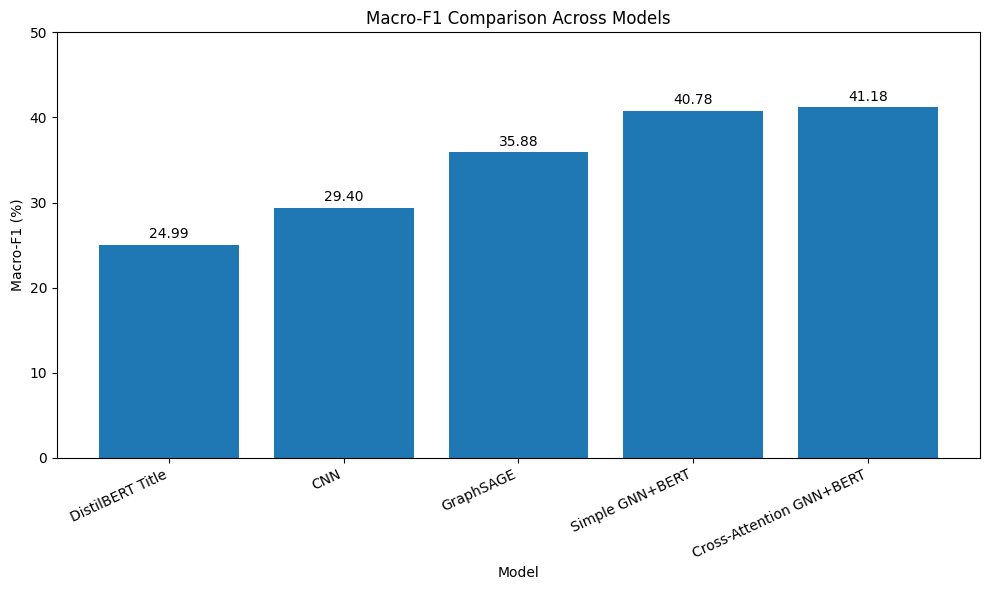

Macro-F1 chart created SUCCESS
Saved: /content/drive/MyDrive/GNN_BERT_Music/results/macro_f1_model_comparison.png
File exists: True


In [ ]:
# Create a publication-ready Macro-F1 comparison chart

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    report_comparison_df["Model"],
    report_comparison_df["Macro-F1"]
)

plt.ylabel("Macro-F1 (%)")
plt.xlabel("Model")
plt.title("Macro-F1 Comparison Across Models")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.ylim(0, 50)

for index, value in enumerate(
    report_comparison_df["Macro-F1"]
):
    plt.text(
        index,
        value + 0.8,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

macro_f1_chart_path = os.path.join(
    results_dir,
    "macro_f1_model_comparison.png"
)

plt.savefig(
    macro_f1_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Macro-F1 chart created SUCCESS")
print("Saved:", macro_f1_chart_path)
print("File exists:", os.path.exists(macro_f1_chart_path))

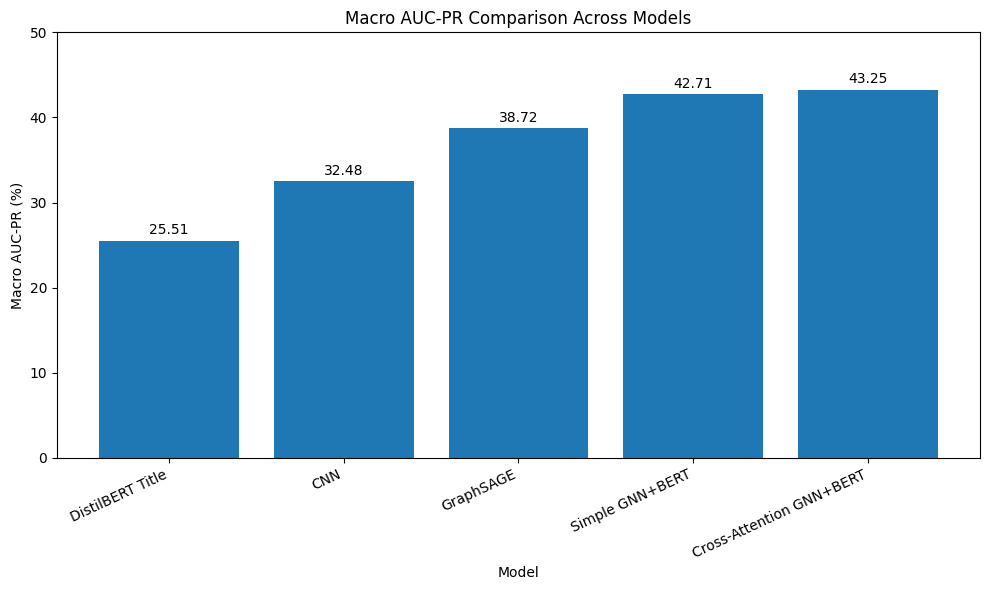

Macro AUC-PR chart created SUCCESS
Saved: /content/drive/MyDrive/GNN_BERT_Music/results/macro_auc_pr_model_comparison.png
File exists: True


In [ ]:
# Create a publication-ready Macro AUC-PR comparison chart

plt.figure(figsize=(10, 6))

plt.bar(
    report_comparison_df["Model"],
    report_comparison_df["Macro AUC-PR"]
)

plt.ylabel("Macro AUC-PR (%)")
plt.xlabel("Model")
plt.title("Macro AUC-PR Comparison Across Models")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.ylim(0, 50)

for index, value in enumerate(
    report_comparison_df["Macro AUC-PR"]
):
    plt.text(
        index,
        value + 0.8,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

auc_pr_chart_path = os.path.join(
    results_dir,
    "macro_auc_pr_model_comparison.png"
)

plt.savefig(
    auc_pr_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Macro AUC-PR chart created SUCCESS")
print("Saved:", auc_pr_chart_path)
print("File exists:", os.path.exists(auc_pr_chart_path))

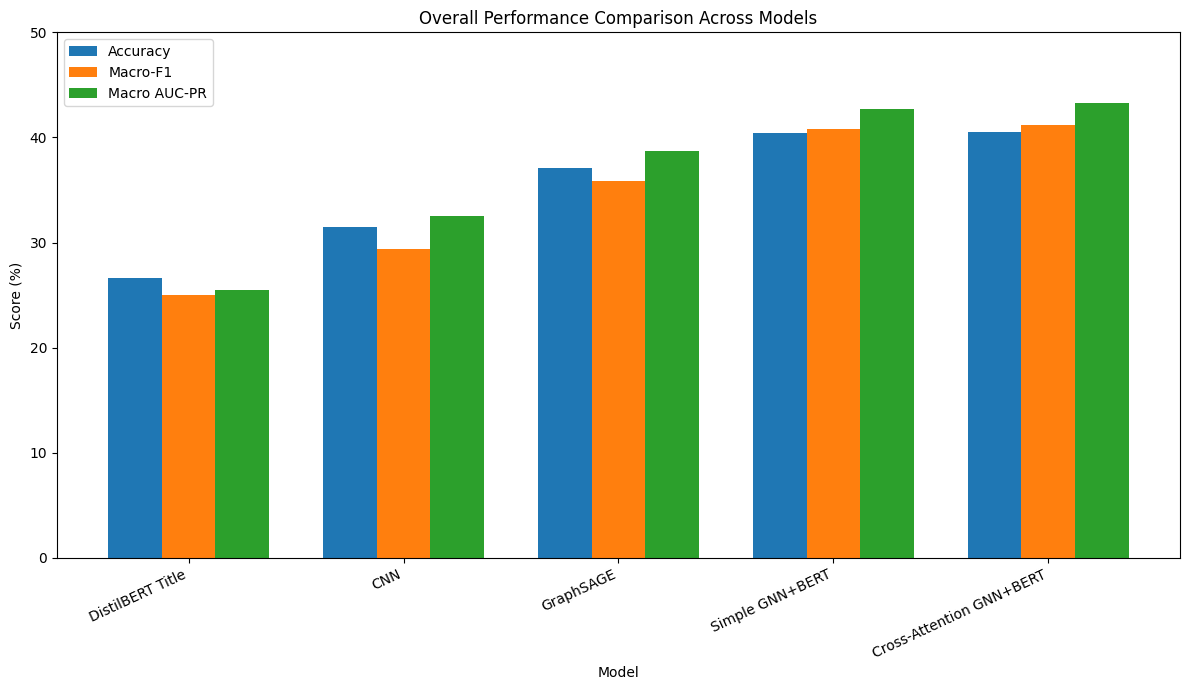

Overall model comparison chart created SUCCESS
Saved: /content/drive/MyDrive/GNN_BERT_Music/results/overall_model_comparison.png
File exists: True


In [ ]:
# Create a grouped comparison chart for the main evaluation metrics

import numpy as np
import matplotlib.pyplot as plt

models = report_comparison_df["Model"].tolist()

accuracy = report_comparison_df["Accuracy"].values
macro_f1 = report_comparison_df["Macro-F1"].values
auc_pr = report_comparison_df["Macro AUC-PR"].values

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12, 7))

plt.bar(
    x - width,
    accuracy,
    width,
    label="Accuracy"
)

plt.bar(
    x,
    macro_f1,
    width,
    label="Macro-F1"
)

plt.bar(
    x + width,
    auc_pr,
    width,
    label="Macro AUC-PR"
)

plt.ylabel("Score (%)")
plt.xlabel("Model")
plt.title("Overall Performance Comparison Across Models")

plt.xticks(
    x,
    models,
    rotation=25,
    ha="right"
)

plt.ylim(0, 50)
plt.legend()

plt.tight_layout()

overall_comparison_chart_path = os.path.join(
    results_dir,
    "overall_model_comparison.png"
)

plt.savefig(
    overall_comparison_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Overall model comparison chart created SUCCESS")
print("Saved:", overall_comparison_chart_path)
print("File exists:", os.path.exists(overall_comparison_chart_path))

In [ ]:
# Verify important report-ready result files

import os

report_result_files = [
    "macro_f1_model_comparison.png",
    "macro_auc_pr_model_comparison.png",
    "overall_model_comparison.png",
    "final_model_comparison.csv",
    "report_ready_model_comparison.csv",
    "final_results_summary.json",
    "ablation_results.csv",
    "ablation_results.json",
    "case_studies.csv",
    "case_studies.json",
    "case_study_evidence.csv",
    "case_study_evidence.json",
    "tsne_audio.png",
    "tsne_text.png",
    "tsne_fused.png",
    "bert_title_baseline_results.json",
    "gnn_bert_fusion_results.json",
    "gnn_bert_simple_fusion_results.json"
]

print("Report result file verification")
print("=" * 60)

missing_files = []
existing_files = []

for filename in report_result_files:
    file_path = os.path.join(results_dir, filename)

    if os.path.exists(file_path):
        existing_files.append(filename)
        print(f"[OK] {filename}")
    else:
        missing_files.append(filename)
        print(f"[MISSING] {filename}")

print("=" * 60)
print("Existing files:", len(existing_files))
print("Missing files:", len(missing_files))

if missing_files:
    print("Missing file list:")
    for filename in missing_files:
        print("-", filename)
else:
    print("All important report result files verified SUCCESS")

Report result file verification
[OK] macro_f1_model_comparison.png
[OK] macro_auc_pr_model_comparison.png
[OK] overall_model_comparison.png
[OK] final_model_comparison.csv
[OK] report_ready_model_comparison.csv
[OK] final_results_summary.json
[OK] ablation_results.csv
[OK] ablation_results.json
[OK] case_studies.csv
[OK] case_studies.json
[OK] case_study_evidence.csv
[OK] case_study_evidence.json
[OK] tsne_audio.png
[OK] tsne_text.png
[OK] tsne_fused.png
[OK] bert_title_baseline_results.json
[OK] gnn_bert_fusion_results.json
[OK] gnn_bert_simple_fusion_results.json
Existing files: 18
Missing files: 0
All important report result files verified SUCCESS


In [ ]:
# Audit the project structure before GitHub cleanup

import os

print("GNN_BERT_Music Project Structure")
print("=" * 70)

for root, dirs, files in os.walk(project_root):
    # Skip large dataset and cache directories from the printed structure
    dirs[:] = [
        d for d in dirs
        if d not in {
            ".git",
            "__pycache__",
            ".ipynb_checkpoints"
        }
    ]

    level = root.replace(project_root, "").count(os.sep)
    indent = "    " * level

    folder_name = os.path.basename(root)

    if root == project_root:
        print(f"{folder_name}/")
    else:
        print(f"{indent}{folder_name}/")

    for filename in sorted(files):
        print(f"{indent}    {filename}")

print("=" * 70)
print("Project structure audit completed SUCCESS")

Streaming output truncated to the last 5000 lines.
                    087153.pt
                    087154.pt
                    087155.pt
                    087157.pt
                    087158.pt
                    087159.pt
                    087160.pt
                    087161.pt
                    087185.pt
                    087186.pt
                    087187.pt
                    087188.pt
                    087189.pt
                    087190.pt
                    087191.pt
                    087192.pt
                    087193.pt
                    087194.pt
                    087237.pt
                    087322.pt
                    087323.pt
                    087324.pt
                    087325.pt
                    087361.pt
                    087362.pt
                    087363.pt
                    087377.pt
                    087430.pt
                    087431.pt
                    087639.pt
                    087641.pt
                   

In [ ]:
# Audit GitHub-ready files and verify ignored large artifacts

import os
import subprocess

print("GitHub-ready project audit")
print("=" * 70)

# Define important project directories
important_dirs = [
    "src",
    "results",
    "data/examples",
    "notebooks",
    "report",
    "models"
]

for relative_dir in important_dirs:
    directory = os.path.join(project_root, relative_dir)

    print(f"\n[{relative_dir}]")

    if not os.path.exists(directory):
        print("Directory does not exist")
        continue

    files = []

    for root, dirs, filenames in os.walk(directory):
        for filename in filenames:
            files.append(os.path.relpath(
                os.path.join(root, filename),
                project_root
            ))

    if files:
        for filename in sorted(files):
            print(filename)
    else:
        print("No files")

print("\n" + "=" * 70)
print("Git status / ignore verification")
print("=" * 70)

os.chdir(project_root)

git_status = subprocess.run(
    ["git", "status", "--short", "--ignored"],
    capture_output=True,
    text=True
)

print(git_status.stdout[:12000])

print("=" * 70)
print("GitHub-ready audit completed SUCCESS")

GitHub-ready project audit

[src]
src/__pycache__/audio_features.cpython-313.pyc
src/__pycache__/data_utils.cpython-313.pyc
src/__pycache__/evaluation.cpython-313.pyc
src/__pycache__/graph_builder.cpython-313.pyc
src/__pycache__/models.cpython-313.pyc
src/__pycache__/project_datasets.cpython-313.pyc
src/audio_features.py
src/data_utils.py
src/evaluation.py
src/graph_builder.py
src/models.py
src/project_datasets.py

[results]
results/ablation_results.csv
results/ablation_results.json
results/bert_title_baseline_results.json
results/best_bert_title_classifier.pt
results/best_cnn.pt
results/best_gnn_bert_fusion.pt
results/best_gnn_bert_simple_fusion.pt
results/best_graphsage.pt
results/case_studies.csv
results/case_studies.json
results/case_study_evidence.csv
results/case_study_evidence.json
results/final_model_comparison.csv
results/final_model_comparison.json
results/final_results_summary.json
results/gnn_bert_fusion_results.json
results/gnn_bert_simple_fusion_results.json
results/macro

In [ ]:
# Check the notebooks folder on Google Drive

import os

notebooks_dir = "/content/drive/MyDrive/GNN_BERT_Music/notebooks"

print("Notebooks folder:")
print(notebooks_dir)
print("=" * 60)

if os.path.exists(notebooks_dir):
    notebook_files = [
        f for f in os.listdir(notebooks_dir)
        if f.endswith(".ipynb")
    ]

    if notebook_files:
        for filename in sorted(notebook_files):
            print("[FOUND]", filename)
    else:
        print("No .ipynb file found in the notebooks folder.")
else:
    print("Notebooks folder does not exist.")

Notebooks folder:
/content/drive/MyDrive/GNN_BERT_Music/notebooks
[FOUND] 01_EDA_Preprocessing.ipynb


In [ ]:
# Audit the current notebook file

import os
import json

notebook_path = "/content/drive/MyDrive/GNN_BERT_Music/notebooks/01_EDA_Preprocessing.ipynb"

print("Notebook path:")
print(notebook_path)
print("=" * 70)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook.get("cells", [])

print("Total cells:", len(cells))
print()

for i, cell in enumerate(cells):
    cell_type = cell.get("cell_type", "unknown")
    source = "".join(cell.get("source", []))

    print(f"--- Cell {i} | {cell_type} ---")
    print(source[:500].replace("\n", " "))
    print()

Notebook path:
/content/drive/MyDrive/GNN_BERT_Music/notebooks/01_EDA_Preprocessing.ipynb


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/GNN_BERT_Music/notebooks/01_EDA_Preprocessing.ipynb'

In [ ]:
# Create a compact notebook cell index

import json

notebook_path = "/mnt/data/01_EDA_Preprocessing_ipynb (2).ipynb"

with open(notebook_path, "r", encoding="utf-8") as file:
    notebook = json.load(file)

cells = notebook.get("cells", [])

print("Notebook cell index")
print("=" * 80)
print("Total cells:", len(cells))
print()

for i, cell in enumerate(cells):
    cell_type = cell.get("cell_type", "unknown")
    source = "".join(cell.get("source", []))
    source = source.replace("\n", " ").strip()

    if not source:
        source = "[EMPTY CELL]"

    print(f"{i:03d} | {cell_type:8s} | {source[:150]}")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/01_EDA_Preprocessing_ipynb (2).ipynb'

In [ ]:
# Create a backup of the original notebook

import os
import shutil

notebooks_dir = "/content/drive/MyDrive/GNN_BERT_Music/notebooks"

original_notebook = os.path.join(
    notebooks_dir,
    "01_EDA_Preprocessing.ipynb"
)

backup_notebook = os.path.join(
    notebooks_dir,
    "01_EDA_Preprocessing_backup.ipynb"
)

print("Original notebook:")
print(original_notebook)
print()

print("Backup notebook:")
print(backup_notebook)
print()

if os.path.exists(original_notebook):
    shutil.copy2(original_notebook, backup_notebook)
    print("[SUCCESS] Original notebook backed up.")
else:
    print("[ERROR] Original notebook was not found.")

Original notebook:
/content/drive/MyDrive/GNN_BERT_Music/notebooks/01_EDA_Preprocessing.ipynb

Backup notebook:
/content/drive/MyDrive/GNN_BERT_Music/notebooks/01_EDA_Preprocessing_backup.ipynb

[ERROR] Original notebook was not found.


In [ ]:
# Search the project directory for all notebook files

import os

project_root = "/content/drive/MyDrive/GNN_BERT_Music"

print("Project root exists:", os.path.exists(project_root))
print("=" * 70)

if os.path.exists(project_root):
    for root, dirs, files in os.walk(project_root):
        for filename in files:
            if filename.lower().endswith(".ipynb"):
                full_path = os.path.join(root, filename)
                print(full_path)
else:
    print("[ERROR] Project root is not accessible.")

Project root exists: True
/content/drive/MyDrive/GNN_BERT_Music/notebooks/01_EDA_Preprocessing_ipynb (2).ipynb


In [ ]:
# Create a backup of the current notebook

import os
import shutil

notebook_path = "/content/drive/MyDrive/GNN_BERT_Music/notebooks/01_EDA_Preprocessing_ipynb (2).ipynb"

backup_path = "/content/drive/MyDrive/GNN_BERT_Music/notebooks/01_EDA_Preprocessing_backup.ipynb"

print("Original notebook:")
print(notebook_path)
print()

print("Backup notebook:")
print(backup_path)
print()

if os.path.exists(notebook_path):
    shutil.copy2(notebook_path, backup_path)
    print("[SUCCESS] Backup created successfully.")
    print("Backup exists:", os.path.exists(backup_path))
else:
    print("[ERROR] Notebook was not found.")

Original notebook:
/content/drive/MyDrive/GNN_BERT_Music/notebooks/01_EDA_Preprocessing_ipynb (2).ipynb

Backup notebook:
/content/drive/MyDrive/GNN_BERT_Music/notebooks/01_EDA_Preprocessing_backup.ipynb

[SUCCESS] Backup created successfully.
Backup exists: True


In [ ]:
# Create the clean final notebook

import os
import nbformat as nbf

project_root = "/content/drive/MyDrive/GNN_BERT_Music"
notebooks_dir = os.path.join(project_root, "notebooks")

os.makedirs(notebooks_dir, exist_ok=True)

final_notebook_path = os.path.join(
    notebooks_dir,
    "01_GNN_BERT_Music_Final.ipynb"
)

nb = nbf.v4.new_notebook()

nb["metadata"] = {
    "kernelspec": {
        "display_name": "Python 3",
        "language": "python",
        "name": "python3"
    },
    "language_info": {
        "name": "python"
    },
    "colab": {
        "provenance": []
    }
}

nb["cells"] = [
    nbf.v4.new_markdown_cell(
        "# GNN + DistilBERT Music Genre Prediction\n\n"
        "This notebook presents the final reproducible workflow for "
        "multimodal music genre classification using audio graphs and "
        "DistilBERT-based title representations."
    ),
    nbf.v4.new_markdown_cell(
        "## 1. Project Setup"
    )
]

with open(final_notebook_path, "w", encoding="utf-8") as f:
    nbf.write(nb, f)

print("Final notebook created:")
print(final_notebook_path)
print()
print("Exists:", os.path.exists(final_notebook_path))

Final notebook created:
/content/drive/MyDrive/GNN_BERT_Music/notebooks/01_GNN_BERT_Music_Final.ipynb

Exists: True


In [ ]:
# Create a final cleanup backup before editing the notebook

import os
import shutil

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

cleanup_backup_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_cleanup_backup.ipynb"
)

shutil.copy2(
    notebook_path,
    cleanup_backup_path
)

print("Cleanup backup created:")
print(cleanup_backup_path)
print()
print("Backup exists:", os.path.exists(cleanup_backup_path))

Cleanup backup created:
/content/drive/MyDrive/GNN_BERT_Music/notebooks/01_EDA_Preprocessing_cleanup_backup.ipynb

Backup exists: True


In [ ]:
# Audit notebook cells before cleanup

import json
import os

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook["cells"]

print("Notebook:", os.path.basename(notebook_path))
print("Total cells:", len(cells))
print()
print("=" * 80)

for i, cell in enumerate(cells):
    cell_type = cell.get("cell_type", "unknown")
    source = "".join(cell.get("source", [])).strip()

    # Get the first meaningful line of the cell
    first_line = ""
    for line in source.splitlines():
        line = line.strip()
        if line:
            first_line = line
            break

    # Count stored outputs
    outputs = cell.get("outputs", [])
    output_count = len(outputs)

    print(
        f"{i:03d} | "
        f"{cell_type:<9} | "
        f"outputs={output_count:<2} | "
        f"{first_line[:100]}"
    )

print("=" * 80)
print("Audit completed.")

Notebook: 01_EDA_Preprocessing_ipynb (2).ipynb
Total cells: 336

000 | code      | outputs=1  | import torch
001 | code      | outputs=0  | !pip install -q librosa soundfile numpy pandas matplotlib seaborn scikit-learn
002 | code      | outputs=1  | from google.colab import drive
003 | code      | outputs=1  | PROJECT_PATH = "/content/drive/MyDrive/GNN_BERT_Music"
004 | code      | outputs=1  | import os
005 | code      | outputs=1  | import numpy as np
006 | code      | outputs=1  | import os
007 | code      | outputs=1  | !wget -q --show-progress https://os.unil.cloud.switch.ch/fma/fma_small.zip
008 | code      | outputs=1  | import os
009 | code      | outputs=0  | !unzip -q fma_small.zip -d /content/
010 | code      | outputs=1  | !ls /content/fma_small | head
011 | code      | outputs=1  | import os
012 | code      | outputs=1  | audio_path = audio_files[0]
013 | code      | outputs=1  | import librosa
014 | code      | outputs=1  | import matplotlib.pyplot as plt
015 | code      

In [ ]:
# Remove only clearly empty and notebook-management cells

import json
import os

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

# Cells that are completely empty
cells_to_remove = set()

for start, end in [
    (82, 85),
    (177, 182),
    (204, 207),
    (218, 221),
]:
    cells_to_remove.update(range(start, end + 1))

# Cells used only for notebook self-auditing, backups, or creating
# the separate clean notebook
cells_to_remove.update(range(329, 336))

# Load notebook
with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

original_count = len(notebook["cells"])

# Remove selected cells in one operation
notebook["cells"] = [
    cell
    for index, cell in enumerate(notebook["cells"])
    if index not in cells_to_remove
]

new_count = len(notebook["cells"])

# Save the cleaned notebook
with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(notebook, f, indent=1, ensure_ascii=False)

print("Notebook cleanup completed.")
print("Original cell count:", original_count)
print("Removed cells:", original_count - new_count)
print("New cell count:", new_count)
print("Notebook exists:", os.path.exists(notebook_path))

Notebook cleanup completed.
Original cell count: 337
Removed cells: 25
New cell count: 312
Notebook exists: True


In [ ]:
# Create a second backup of the currently cleaned notebook

import os
import shutil

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

backup_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_after_cleanup1_backup.ipynb"
)

shutil.copy2(notebook_path, backup_path)

print("Second cleanup backup created.")
print("Backup path:", backup_path)
print("Backup exists:", os.path.exists(backup_path))

Second cleanup backup created.
Backup path: /content/drive/MyDrive/GNN_BERT_Music/notebooks/01_EDA_Preprocessing_after_cleanup1_backup.ipynb
Backup exists: True


In [ ]:
# Audit remaining notebook cells for duplicate and obsolete sections

import json

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

print("Remaining cells:", len(notebook["cells"]))
print("=" * 100)

for i, cell in enumerate(notebook["cells"]):
    source = "".join(cell.get("source", [])).strip()

    first_line = ""
    for line in source.splitlines():
        line = line.strip()
        if line:
            first_line = line
            break

    print(f"{i:03d} | {first_line[:120]}")

print("=" * 100)
print("Audit completed.")

Remaining cells: 339
000 | import torch
001 | !pip install -q librosa soundfile numpy pandas matplotlib seaborn scikit-learn
002 | from google.colab import drive
003 | PROJECT_PATH = "/content/drive/MyDrive/GNN_BERT_Music"
004 | import os
005 | import numpy as np
006 | import os
007 | !wget -q --show-progress https://os.unil.cloud.switch.ch/fma/fma_small.zip
008 | import os
009 | !unzip -q fma_small.zip -d /content/
010 | !ls /content/fma_small | head
011 | import os
012 | audio_path = audio_files[0]
013 | import librosa
014 | import matplotlib.pyplot as plt
015 | import numpy as np
016 | plt.figure(figsize=(14, 5))
017 | segment_duration = 5  # seconds
018 | plt.figure(figsize=(14, 4))
019 | segment_mel = librosa.feature.melspectrogram(
020 | segment_features = []
021 | print("First segment feature vector:")
022 | from sklearn.preprocessing import StandardScaler
023 | import numpy as np
024 | import networkx as nx
025 | !pip install -q torch-geometric
026 | import torch
027 | # Node f

In [ ]:
# Remove temporary cleanup-management cells from the final notebook

import json
import os

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

cells_to_remove = {336, 337, 338}

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

original_count = len(notebook["cells"])

notebook["cells"] = [
    cell
    for index, cell in enumerate(notebook["cells"])
    if index not in cells_to_remove
]

new_count = len(notebook["cells"])

with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(notebook, f, indent=1, ensure_ascii=False)

print("Temporary cleanup cells removed.")
print("Original cell count:", original_count)
print("Removed:", original_count - new_count)
print("New cell count:", new_count)
print("Notebook exists:", os.path.exists(notebook_path))

Temporary cleanup cells removed.
Original cell count: 340
Removed: 3
New cell count: 337
Notebook exists: True


In [ ]:
# Inspect the CNN-related notebook cells before removing duplicates

import json

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook["cells"]

print("Notebook cells:", len(cells))
print("=" * 100)

for i, cell in enumerate(cells):
    source = "".join(cell.get("source", [])).strip()

    if (
        "CNN" in source
        or "cnn" in source
        or "LightweightCNN" in source
        or "FastCNNDataset" in source
    ):
        print(f"\nCELL {i}")
        print("-" * 100)
        print(source[:1500])

print("\n" + "=" * 100)
print("CNN audit completed.")

Notebook cells: 342

CELL 169
----------------------------------------------------------------------------------------------------
# Step 73: Prepare the CNN baseline environment

import os
import glob
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

print("----- CNN baseline setup -----")
print("PyTorch version:", torch.__version__)
print("Device:", device)
print("Number of classes:", len(class_names))
print("CNN input representation: 128-bin log-Mel spectrogram")
print("Segment duration: 5 seconds")

CELL 170
----------------------------------------------------------------------------------------------------
# Step 74: Create the CNN dataset for 5-second audio segments

class AudioCNNDataset(Dataset):
    def __init__(self, track_ids, split_name, metadata, audio_root):
        self.track_ids = list(track_ids)
        self.split_name = split_name
        self.metadata = metadata
    

In [ ]:
# Remove only redundant CNN pipeline cells

import json

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook["cells"]

# Remove obsolete CNN implementation blocks
remove_indices = set(
    list(range(169, 178)) +
    list(range(187, 194)) +
    [194, 196]
)

original_count = len(cells)

notebook["cells"] = [
    cell
    for i, cell in enumerate(cells)
    if i not in remove_indices
]

new_count = len(notebook["cells"])

with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(notebook, f, indent=1, ensure_ascii=False)

print("CNN duplicate cleanup completed.")
print("Original cell count:", original_count)
print("Removed cells:", original_count - new_count)
print("New cell count:", new_count)
print("Notebook exists:", os.path.isfile(notebook_path))

CNN duplicate cleanup completed.
Original cell count: 342
Removed cells: 18
New cell count: 324
Notebook exists: True


In [ ]:
# Create a compact BERT cell audit

import json

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook["cells"]

print("Notebook cells:", len(cells))
print("=" * 80)

for i, cell in enumerate(cells):
    source = "".join(cell.get("source", [])).strip()

    if (
        "BERT" in source
        or "bert" in source
        or "DistilBERT" in source
        or "BERTTitleDataset" in source
        or "BERTClassifier" in source
    ):
        first_line = source.splitlines()[0] if source else ""
        print(f"CELL {i}: {first_line[:250]}")

print("=" * 80)
print("Compact BERT audit completed.")

Notebook cells: 344
CELL 3: PROJECT_PATH = "/content/drive/MyDrive/GNN_BERT_Music"
CELL 74: from torch_geometric.data import Batch
CELL 123: # Step 28: Copy the final training-only scaler to the project directory
CELL 132: # Step 37: Create final graph output directories
CELL 142: # Step 47: Audit final training graph files
CELL 143: # Step 48: Generate validation graphs
CELL 144: # Step 49: Audit final validation graph files
CELL 145: # Step 50: Generate test graphs
CELL 146: # Step 51: Audit final test graph files
CELL 147: # Step 52: Validate saved graph structure and feature integrity
CELL 148: # Step 53: Inspect invalid training graph files
CELL 152: # Step 56: Remove invalid None graph files
CELL 153: # Step 57: Final audit of graph files
CELL 154: # Step 58: Inspect one final saved graph
CELL 155: # Step 59: Create the graph dataset class
CELL 164: # Step 68: Retrain GraphSAGE and save the best validation checkpoint
CELL 165: # Step 69: Load the best GraphSAGE checkpoint
CELL 18

In [ ]:
# Compact audit of the old and final BERT sections

for i in range(208, 247):
    cell = cells[i]
    source = "".join(cell.get("source", [])).strip()
    if source:
        first_line = source.splitlines()[0][:180]
        print(f"{i}: {first_line} | chars={len(source)}")

208: print("----- BERT text data inspection -----") | chars=492
209: import torch | chars=306
210: from transformers import AutoTokenizer | chars=402
211: # Select a few real track titles from the dataset | chars=618
212: import torch | chars=2357
213: from torch.utils.data import DataLoader | chars=697
214: import torch | chars=1190
215: class BERTTitleClassifier(nn.Module): | chars=1403
216: # Put the model in evaluation mode for benchmarking | chars=546
217: import torch.optim as optim | chars=878
218: import time | chars=3866
222: from google.colab import drive | chars=324
223: import os | chars=442
224: # Define the FMA metadata path | chars=228
225: # Load the FMA metadata | chars=528
226: # Define the FMA-small audio directory | chars=738
227: # Inspect the current metadata columns | chars=400
228: # Select the required FMA metadata fields using their MultiIndex names | chars=1481
229: # Define the fixed 8-class genre-to-label mapping | chars=549
230: # Load the DistilBERT token

In [238]:
# Compact audit of the final notebook cells

import json

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook["cells"]

print("Total cells:", len(cells))
print("=" * 70)

start = max(0, len(cells) - 25)

for i in range(start, len(cells)):
    source = "".join(cells[i].get("source", [])).strip()
    first_line = source.splitlines()[0][:160] if source else "[EMPTY]"
    print(f"{i}: {first_line}")

print("=" * 70)
print("Final-cell audit completed.")

Total cells: 334
309: # Verify the saved final comparison files
310: # Create a report-ready percentage-formatted results table
311: # Create a publication-ready Macro-F1 comparison chart
312: # Create a publication-ready Macro AUC-PR comparison chart
313: # Create a grouped comparison chart for the main evaluation metrics
314: # Verify important report-ready result files
315: # Audit the project structure before GitHub cleanup
316: # Audit GitHub-ready files and verify ignored large artifacts
317: # Check the notebooks folder on Google Drive
318: # Audit the current notebook file
319: # Create a compact notebook cell index
320: # Create a backup of the original notebook
321: # Search the project directory for all notebook files
322: # Create a backup of the current notebook
323: # Create the clean final notebook
324: # Create a final cleanup backup before editing the notebook
325: # Audit notebook cells before cleanup
326: # Remove only clearly empty and notebook-management cells
327:

In [239]:
# Remove temporary notebook-management and cleanup cells

import json

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook["cells"]

# Remove temporary management and audit cells only
remove_indices = set(range(319, 334))

new_cells = [
    cell for i, cell in enumerate(cells)
    if i not in remove_indices
]

notebook["cells"] = new_cells

with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(notebook, f, ensure_ascii=False, indent=1)

print("Temporary notebook-management cells removed.")
print("Original cells:", len(cells))
print("Removed cells:", len(remove_indices))
print("New cells:", len(new_cells))

Temporary notebook-management cells removed.
Original cells: 335
Removed cells: 15
New cells: 320


In [241]:
# Final compact sanity check

import json

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook["cells"]

keywords = [
    "GraphSAGE",
    "CNN",
    "BERTTitleDataset",
    "BERTClassifierHead",
    "GNNBERTCrossAttention",
    "GNNSimpleFusion",
    "t-SNE",
    "case",
    "ablation",
    "final model comparison"
]

print("Total cells:", len(cells))
print("=" * 60)

for keyword in keywords:
    matches = []
    for i, cell in enumerate(cells):
        source = "".join(cell.get("source", []))
        if keyword.lower() in source.lower():
            matches.append(i)
    print(f"{keyword}: {matches}")

print("=" * 60)
print("Final sanity check completed.")

Total cells: 337
GraphSAGE: [72, 73, 158, 159, 163, 164, 165, 166, 167, 168, 243, 247, 248, 252, 253, 255, 256, 258, 263, 264, 265, 270, 272, 274, 296, 298, 299, 307, 336]
CNN: [169, 170, 171, 172, 173, 174, 175, 176, 177, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 198, 199, 200, 201, 202, 203, 253, 274, 307, 330, 331, 336]
BERTTitleDataset: [220, 332, 336]
BERTClassifierHead: [229, 267, 296, 298, 336]
GNNBERTCrossAttention: [243, 244, 245, 258, 269, 296, 298, 304, 336]
GNNSimpleFusion: [248, 249, 250, 251, 268, 336]
t-SNE: [259, 260, 261, 336]
case: [219, 235, 270, 271, 272, 273, 274, 314, 336]
ablation: [253, 254, 274, 314, 336]
final model comparison: [307, 308, 336]
Final sanity check completed.


In [242]:
# Compact audit of the current CNN-related section

for i in range(160, 205):
    source = "".join(cells[i].get("source", [])).strip()

    if source and "cnn" in source.lower():
        first_line = source.splitlines()[0][:180]
        print(f"{i}: {first_line} | chars={len(source)}")

169: # Step 73: Prepare the CNN baseline environment | chars=478
170: # Step 74: Create the CNN dataset for 5-second audio segments | chars=2876
171: # Step 75: Create DataLoaders for the CNN datasets | chars=705
172: # Step 76: Inspect one CNN batch | chars=663
173: # Step 77: Define the CNN baseline model | chars=1195
174: # Step 78: Test the CNN forward pass | chars=547
175: # Step 79: Configure CNN training | chars=520
176: # Step 80: Define CNN training and evaluation functions | chars=1621
177: # Step 81: Run one CNN training epoch | chars=542
187: # Step 84: Build an efficient CNN dataset with precomputed Mel spectrograms | chars=2854
188: # Step 85: Create CNN DataLoaders | chars=688
189: # Step 86: Inspect one CNN batch | chars=660
190: # Step 87: Define the CNN baseline model | chars=1170
191: # Step 88: Verify the CNN forward pass | chars=616
192: # Step 89: Configure CNN training | chars=507
193: # Step 90: Define CNN training and evaluation functions | chars=1577
194: # St

In [243]:
# Remove only the obsolete CNN pipeline cells

import json

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook["cells"]

remove_indices = (
    set(range(169, 178))
    | set(range(187, 195))
    | {196}
)

new_cells = [
    cell for i, cell in enumerate(cells)
    if i not in remove_indices
]

notebook["cells"] = new_cells

with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(notebook, f, ensure_ascii=False, indent=1)

print("Obsolete CNN pipeline cells removed.")
print("Original cells:", len(cells))
print("Removed cells:", len(remove_indices))
print("New cells:", len(new_cells))

Obsolete CNN pipeline cells removed.
Original cells: 338
Removed cells: 18
New cells: 320


In [244]:
# Verify that all essential project sections are still present

import json

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook["cells"]

checks = {
    "Graph generation": ["create_audio_graph", "AudioGraphDataset"],
    "GraphSAGE": ["GraphSAGEClassifier"],
    "CNN baseline": ["LightweightCNNClassifier", "FastCNNDataset"],
    "BERT dataset": ["BERTTitleDataset"],
    "BERT classifier": ["BERTClassifierHead"],
    "Cross-attention fusion": ["GNNBERTCrossAttention"],
    "Simple fusion": ["GNNSimpleFusion"],
    "Ablation": ["ablation"],
    "t-SNE": ["t-SNE"],
    "Case studies": ["case_studies"],
    "Final comparison": ["final_model_comparison"],
}

all_source = "\n".join(
    "".join(cell.get("source", []))
    for cell in cells
)

print("Total cells:", len(cells))
print("=" * 60)

for section, keywords in checks.items():
    found = all(keyword.lower() in all_source.lower() for keyword in keywords)
    print(f"{section}: {'OK' if found else 'MISSING'}")

print("=" * 60)
print("Structure verification completed.")

Total cells: 339
Graph generation: OK
GraphSAGE: OK
CNN baseline: OK
BERT dataset: OK
BERT classifier: OK
Cross-attention fusion: OK
Simple fusion: OK
Ablation: OK
t-SNE: OK
Case studies: OK
Final comparison: OK
Structure verification completed.


In [245]:
# Remove only temporary notebook-management and audit cells
import json

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook["cells"]

temporary_signatures = [
    "Obsolete CNN pipeline cells removed.",
    "Old BERT pipeline removed.",
    "Final sanity check completed.",
    "Structure verification completed.",
    "CNN compact audit",
    "BERT compact audit",
    "GraphSAGE compact audit",
    "Final structure verification",
]

def cell_text(cell):
    return "".join(cell.get("source", []))

original_count = len(cells)

filtered_cells = []
removed = []

for index, cell in enumerate(cells):
    source = cell_text(cell)

    if any(signature.lower() in source.lower() for signature in temporary_signatures):
        removed.append((index, source[:120].replace("\n", " ")))
    else:
        filtered_cells.append(cell)

notebook["cells"] = filtered_cells

with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(notebook, f, ensure_ascii=False, indent=1)

print("Final temporary-cell cleanup completed.")
print("Original cells:", original_count)
print("Removed cells:", len(removed))
print("New cells:", len(filtered_cells))

if removed:
    print("\nRemoved temporary cells:")
    for index, preview in removed:
        print(f"  Cell {index}: {preview}")
else:
    print("\nNo matching temporary cells found.")

Final temporary-cell cleanup completed.
Original cells: 341
Removed cells: 3
New cells: 338

Removed temporary cells:
  Cell 336: # Final compact sanity check  import json  notebook_path = (     "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"     
  Cell 338: # Remove only the obsolete CNN pipeline cells  import json  notebook_path = (     "/content/drive/MyDrive/GNN_BERT_Music
  Cell 339: # Verify that all essential project sections are still present  import json  notebook_path = (     "/content/drive/MyDri


In [246]:
# Inspect the final project structure before GitHub commit

import os

project_root = "/content/drive/MyDrive/GNN_BERT_Music"

print("=" * 70)
print("FINAL PROJECT STRUCTURE")
print("=" * 70)

for root, dirs, files in os.walk(project_root):
    # Skip large/raw dataset directories
    dirs[:] = [
        d for d in dirs
        if d not in {"raw", "audio", "fma_small", "graphs", "bert_embeddings"}
    ]

    level = root.replace(project_root, "").count(os.sep)
    indent = "  " * level
    folder_name = os.path.basename(root) or os.path.basename(project_root)

    print(f"{indent}{folder_name}/")

    for file_name in sorted(files):
        print(f"{indent}  {file_name}")

print("=" * 70)
print("Project structure inspection completed.")

FINAL PROJECT STRUCTURE
GNN_BERT_Music/
  .gitignore
  data/
    processed/
      final_audio_scaler.joblib
    splits/
    examples/
      000002_Hip-Hop_train.pt
      000005_Hip-Hop_train.pt
      000010_Pop_train.pt
      000140_Folk_train.pt
      000141_Folk_train.pt
      000190_Folk_train.pt
      000213_Pop_train.pt
      000255_Rock_train.pt
      000256_Rock_train.pt
      000368_Rock_train.pt
      000424_Experimental_train.pt
      000615_Experimental_train.pt
      000666_International_train.pt
      000667_International_train.pt
      000676_Hip-Hop_train.pt
      000821_Pop_train.pt
      000853_International_train.pt
      000897_Experimental_train.pt
      001482_Electronic_train.pt
      003573_Electronic_train.pt
      004519_Electronic_train.pt
      011638_Instrumental_train.pt
      014568_Instrumental_train.pt
      014569_Instrumental_train.pt
      README.md
  models/
    bert/
    gnn/
  results/
    ablation_results.csv
    ablation_results.json
    bert_tit

In [247]:
# Verify that large datasets, caches, checkpoints, and backup files are ignored

import os

project_root = "/content/drive/MyDrive/GNN_BERT_Music"
gitignore_path = os.path.join(project_root, ".gitignore")

with open(gitignore_path, "r", encoding="utf-8") as f:
    gitignore_text = f.read()

required_patterns = [
    "data/raw/",
    "data/audio/",
    "data/fma_small/",
    "data/processed/graphs/",
    "data/processed/bert_embeddings/",
    "*.mp3",
    "*.wav",
    "results/*.pt",
    "results/*.pth",
    "__pycache__/",
    ".ipynb_checkpoints/",
]

print("=" * 70)
print("GITIGNORE VERIFICATION")
print("=" * 70)

for pattern in required_patterns:
    status = "OK" if pattern in gitignore_text else "MISSING"
    print(f"{status:8} {pattern}")

print("=" * 70)

# Check important files that should remain tracked
required_files = [
    ".gitignore",
    "data/examples/README.md",
    "src/audio_features.py",
    "src/data_utils.py",
    "src/evaluation.py",
    "src/graph_builder.py",
    "src/models.py",
    "src/project_datasets.py",
    "results/final_model_comparison.csv",
    "results/final_results_summary.json",
]

print("IMPORTANT FILES")
print("=" * 70)

for relative_path in required_files:
    full_path = os.path.join(project_root, relative_path)
    status = "OK" if os.path.exists(full_path) else "MISSING"
    print(f"{status:8} {relative_path}")

print("=" * 70)
print("GitHub preparation verification completed.")

GITIGNORE VERIFICATION
OK       data/raw/
OK       data/audio/
OK       data/fma_small/
OK       data/processed/graphs/
OK       data/processed/bert_embeddings/
OK       *.mp3
OK       *.wav
OK       results/*.pt
OK       results/*.pth
OK       __pycache__/
OK       .ipynb_checkpoints/
IMPORTANT FILES
OK       .gitignore
OK       data/examples/README.md
OK       src/audio_features.py
OK       src/data_utils.py
OK       src/evaluation.py
OK       src/graph_builder.py
OK       src/models.py
OK       src/project_datasets.py
OK       results/final_model_comparison.csv
OK       results/final_results_summary.json
GitHub preparation verification completed.


In [248]:
# Compare the two main notebooks without modifying them

import json
import os

project_root = "/content/drive/MyDrive/GNN_BERT_Music"
notebook_dir = os.path.join(project_root, "notebooks")

notebooks = [
    "01_EDA_Preprocessing_ipynb (2).ipynb",
    "01_GNN_BERT_Music_Final.ipynb",
]

print("=" * 70)
print("NOTEBOOK COMPARISON")
print("=" * 70)

for notebook_name in notebooks:
    path = os.path.join(notebook_dir, notebook_name)

    with open(path, "r", encoding="utf-8") as f:
        notebook = json.load(f)

    cells = notebook.get("cells", [])

    code_cells = sum(1 for cell in cells if cell.get("cell_type") == "code")
    markdown_cells = sum(
        1 for cell in cells if cell.get("cell_type") == "markdown"
    )

    source_text = "\n".join(
        "".join(cell.get("source", []))
        for cell in cells
    )

    print(f"\nNotebook: {notebook_name}")
    print(f"Total cells: {len(cells)}")
    print(f"Code cells: {code_cells}")
    print(f"Markdown cells: {markdown_cells}")
    print(
        "Contains GraphSAGE:",
        "YES" if "GraphSAGEClassifier" in source_text else "NO"
    )
    print(
        "Contains CNN:",
        "YES" if "LightweightCNNClassifier" in source_text else "NO"
    )
    print(
        "Contains BERT:",
        "YES" if "BERTTitleDataset" in source_text else "NO"
    )
    print(
        "Contains Cross-Attention:",
        "YES" if "GNNBERTCrossAttention" in source_text else "NO"
    )
    print(
        "Contains Simple Fusion:",
        "YES" if "GNNSimpleFusion" in source_text else "NO"
    )
    print(
        "Contains t-SNE:",
        "YES" if "t-SNE" in source_text else "NO"
    )
    print(
        "Contains Case Studies:",
        "YES" if "case" in source_text.lower() else "NO"
    )
    print(
        "Contains Final Comparison:",
        "YES" if "final_model_comparison" in source_text else "NO"
    )

print("\n" + "=" * 70)
print("Notebook comparison completed.")

NOTEBOOK COMPARISON

Notebook: 01_EDA_Preprocessing_ipynb (2).ipynb
Total cells: 342
Code cells: 342
Markdown cells: 0
Contains GraphSAGE: YES
Contains CNN: YES
Contains BERT: YES
Contains Cross-Attention: YES
Contains Simple Fusion: YES
Contains t-SNE: YES
Contains Case Studies: YES
Contains Final Comparison: YES

Notebook: 01_GNN_BERT_Music_Final.ipynb
Total cells: 7
Code cells: 4
Markdown cells: 3
Contains GraphSAGE: NO
Contains CNN: NO
Contains BERT: NO
Contains Cross-Attention: NO
Contains Simple Fusion: NO
Contains t-SNE: NO
Contains Case Studies: NO
Contains Final Comparison: NO

Notebook comparison completed.


In [249]:
import json
import os

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook["cells"]

# Signatures of cells that are likely temporary notebook-management cells
temporary_signatures = [
    "Audit notebook",
    "Audit the current notebook",
    "Audit remaining notebook",
    "Audit the project structure",
    "Audit the project directory",
    "audit completed",
    "Create a backup",
    "Create a second backup",
    "Create the clean final notebook",
    "Search the project directory for all notebook files",
    "Check the notebooks folder",
    "Inspect the CNN-related notebook cells before removing duplicates",
    "Inspect the BERT-related notebook cells before removing duplicates",
    "Remove temporary cleanup-management cells",
    "Remove only clearly empty and notebook-management cells",
    "cleanup completed",
    "cleanup backup",
]

matches = []

for i, cell in enumerate(cells):
    source = "".join(cell.get("source", [])).strip()
    source_lower = source.lower()

    matched_signature = None

    for signature in temporary_signatures:
        if signature.lower() in source_lower:
            matched_signature = signature
            break

    if matched_signature is not None:
        matches.append((i, matched_signature, source))

print("Notebook:", os.path.basename(notebook_path))
print("Total cells:", len(cells))
print("=" * 100)

if matches:
    print("Potential temporary / management cells found:")
    print()

    for index, signature, source in matches:
        first_lines = "\n".join(source.splitlines()[:8])

        print(f"CELL {index}")
        print(f"Matched signature: {signature}")
        print("-" * 80)
        print(first_lines)
        print("=" * 100)
else:
    print("No temporary-management cells matched the signatures.")

print()
print("Total potential temporary cells:", len(matches))

Notebook: 01_EDA_Preprocessing_ipynb (2).ipynb
Total cells: 344
Potential temporary / management cells found:

CELL 315
Matched signature: Audit the project structure
--------------------------------------------------------------------------------
# Audit the project structure before GitHub cleanup

import os

print("GNN_BERT_Music Project Structure")
print("=" * 70)

for root, dirs, files in os.walk(project_root):
CELL 316
Matched signature: audit completed
--------------------------------------------------------------------------------
# Audit GitHub-ready files and verify ignored large artifacts

import os
import subprocess

print("GitHub-ready project audit")
print("=" * 70)

CELL 317
Matched signature: Check the notebooks folder
--------------------------------------------------------------------------------
# Check the notebooks folder on Google Drive

import os

notebooks_dir = "/content/drive/MyDrive/GNN_BERT_Music/notebooks"

print("Notebooks folder:")
print(notebooks_dir)
CEL

In [250]:
import json
import os
import shutil

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

backup_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_final_backup.ipynb"
)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

original_count = len(notebook["cells"])

# Create a final backup before modifying the notebook
shutil.copy2(notebook_path, backup_path)

# Exact signatures for temporary notebook-management cells
temporary_signatures = [
    "# Audit the project structure before GitHub cleanup",
    "# Audit GitHub-ready files and verify ignored large artifacts",
    "# Check the notebooks folder on Google Drive",
    "# Audit the current notebook file",
    "# Create a backup of the original notebook",
    "# Search the project directory for all notebook files",
    "# Create a backup of the current notebook",
    "# Create the clean final notebook",
    "# Create a final cleanup backup before editing the notebook",
    "# Audit notebook cells before cleanup",
    "# Remove only clearly empty and notebook-management cells",
    "# Create a second backup of the currently cleaned notebook",
    "# Audit remaining notebook cells for duplicate and obsolete sections",
    "# Remove temporary cleanup-management cells from the final notebook",
    "# Inspect the CNN-related notebook cells before removing duplicates",
    "# Remove only redundant CNN pipeline cells",
    "# Create a compact BERT cell audit",
    "# Compact audit of the final notebook cells",
    "# Remove only temporary notebook-management and audit cells",
]

removed = []
remaining_cells = []

for index, cell in enumerate(notebook["cells"]):
    source = "".join(cell.get("source", [])).strip()

    matched = False

    for signature in temporary_signatures:
        if source.startswith(signature):
            removed.append((index, signature))
            matched = True
            break

    if not matched:
        remaining_cells.append(cell)

notebook["cells"] = remaining_cells

new_count = len(notebook["cells"])

with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(notebook, f, indent=1, ensure_ascii=False)

print("FINAL NOTEBOOK CLEANUP")
print("=" * 80)
print("Backup created:", os.path.exists(backup_path))
print("Backup path:", backup_path)
print()
print("Original cells:", original_count)
print("Removed cells:", len(removed))
print("Remaining cells:", new_count)
print()

print("Removed cell signatures:")
for index, signature in removed:
    print(f"[REMOVED] Original cell {index}: {signature}")

print()
print("=" * 80)
print("Notebook cleanup completed successfully.")

FINAL NOTEBOOK CLEANUP
Backup created: True
Backup path: /content/drive/MyDrive/GNN_BERT_Music/notebooks/01_EDA_Preprocessing_final_backup.ipynb

Original cells: 345
Removed cells: 19
Remaining cells: 326

Removed cell signatures:
[REMOVED] Original cell 315: # Audit the project structure before GitHub cleanup
[REMOVED] Original cell 316: # Audit GitHub-ready files and verify ignored large artifacts
[REMOVED] Original cell 317: # Check the notebooks folder on Google Drive
[REMOVED] Original cell 318: # Audit the current notebook file
[REMOVED] Original cell 320: # Create a backup of the original notebook
[REMOVED] Original cell 321: # Search the project directory for all notebook files
[REMOVED] Original cell 322: # Create a backup of the current notebook
[REMOVED] Original cell 323: # Create the clean final notebook
[REMOVED] Original cell 324: # Create a final cleanup backup before editing the notebook
[REMOVED] Original cell 325: # Audit notebook cells before cleanup
[REMOVED] Origi

In [251]:
import json
import os

notebook_path = (
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_ipynb (2).ipynb"
)

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

cells = notebook["cells"]

# Required experiment signatures
required_sections = {
    "Data loading": [
        "fma",
        "metadata",
    ],
    "Official split": [
        "split_metadata",
        "train",
        "validation",
        "test",
    ],
    "Audio features": [
        "log-Mel",
        "n_mels",
    ],
    "Graph construction": [
        "create_audio_graph",
        "edge_index",
    ],
    "GraphSAGE": [
        "GraphSAGEClassifier",
        "SAGEConv",
    ],
    "CNN baseline": [
        "LightweightCNNClassifier",
        "FastCNNDataset",
    ],
    "BERT baseline": [
        "BERTTitleDataset",
        "BERTClassifierHead",
        "distilbert-base-uncased",
    ],
    "Simple fusion": [
        "simple",
        "fusion",
    ],
    "Cross-attention fusion": [
        "GNNBERTCrossAttention",
        "MultiheadAttention",
    ],
    "Evaluation": [
        "Macro-F1",
        "AUC-PR",
    ],
    "t-SNE": [
        "t-SNE",
        "TSNE",
    ],
    "Case studies": [
        "case",
        "1066",
        "4108",
        "704",
    ],
}

print("FINAL NOTEBOOK STRUCTURAL VERIFICATION")
print("=" * 100)
print("Notebook:", os.path.basename(notebook_path))
print("Total cells:", len(cells))
print()

all_sources = [
    "".join(cell.get("source", []))
    for cell in cells
]

full_text = "\n".join(all_sources).lower()

passed = 0
failed = 0

for section, signatures in required_sections.items():
    found = [
        signature
        for signature in signatures
        if signature.lower() in full_text
    ]

    missing = [
        signature
        for signature in signatures
        if signature.lower() not in full_text
    ]

    # A section passes when at least one important signature is found
    if found:
        passed += 1
        print(f"[PASS] {section}")
        print("       Found:", ", ".join(found))
    else:
        failed += 1
        print(f"[FAIL] {section}")
        print("       Missing:", ", ".join(missing))

print()
print("=" * 100)
print("Verification summary")
print("Passed sections:", passed)
print("Failed sections:", failed)

print()
print("Notebook exists:", os.path.exists(notebook_path))
print("Backup exists:", os.path.exists(
    "/content/drive/MyDrive/GNN_BERT_Music/notebooks/"
    "01_EDA_Preprocessing_final_backup.ipynb"
))

if failed == 0:
    print()
    print("SUCCESS: All required experiment sections are present.")
else:
    print()
    print("WARNING: One or more required sections need inspection.")

FINAL NOTEBOOK STRUCTURAL VERIFICATION
Notebook: 01_EDA_Preprocessing_ipynb (2).ipynb
Total cells: 347

[PASS] Data loading
       Found: fma, metadata
[PASS] Official split
       Found: split_metadata, train, validation, test
[PASS] Audio features
       Found: log-Mel, n_mels
[PASS] Graph construction
       Found: create_audio_graph, edge_index
[PASS] GraphSAGE
       Found: GraphSAGEClassifier, SAGEConv
[PASS] CNN baseline
       Found: LightweightCNNClassifier, FastCNNDataset
[PASS] BERT baseline
       Found: BERTTitleDataset, BERTClassifierHead, distilbert-base-uncased
[PASS] Simple fusion
       Found: simple, fusion
[PASS] Cross-attention fusion
       Found: GNNBERTCrossAttention, MultiheadAttention
[PASS] Evaluation
       Found: Macro-F1, AUC-PR
[PASS] t-SNE
       Found: t-SNE, TSNE
[PASS] Case studies
       Found: case

Verification summary
Passed sections: 12
Failed sections: 0

Notebook exists: True
Backup exists: True

SUCCESS: All required experiment sections are pr

In [252]:
import os

project_root = "/content/drive/MyDrive/GNN_BERT_Music"

required_github_files = [
    "README.md",
    "requirements.txt",
    "config.yaml",
    "notebooks/demo_context.ipynb",
]

print("GITHUB-READY FILE CHECK")
print("=" * 80)

for relative_path in required_github_files:
    full_path = os.path.join(project_root, relative_path)

    if os.path.exists(full_path):
        print(f"[EXISTS]  {relative_path}")
    else:
        print(f"[MISSING] {relative_path}")

print()
print("=" * 80)

report_dir = os.path.join(project_root, "report")

if os.path.exists(report_dir):
    report_files = sorted(os.listdir(report_dir))

    print("Report directory contents:")
    if report_files:
        for filename in report_files:
            print(" -", filename)
    else:
        print(" - EMPTY")
else:
    print("Report directory: MISSING")

GITHUB-READY FILE CHECK
[MISSING] README.md
[MISSING] requirements.txt
[MISSING] config.yaml
[MISSING] notebooks/demo_context.ipynb

Report directory contents:
 - EMPTY


In [256]:
import os

project_root = "/content/drive/MyDrive/GNN_BERT_Music"
readme_path = os.path.join(project_root, "README.md")

lines = [
    "# GNN-BERT Music",
    "",
    "Multimodal music genre prediction using Graph Neural Networks and DistilBERT.",
    "",
    "## Author",
    "",
    "**Tabarak Tasnim Tanu**  ",
    "BRAC University  ",
    "Student ID: 24341067",
    "",
    "## Project Overview",
    "",
    "This project investigates multimodal music genre prediction by combining audio representations, Graph Neural Networks (GNNs), and DistilBERT-based text representations.",
    "",
    "The project uses the FMA-small dataset and evaluates unimodal and multimodal models on an official train/validation/test split.",
    "",
    "## Implemented Tasks",
    "",
    "1. DistilBERT title-based genre classification",
    "2. CNN audio baseline",
    "3. GraphSAGE audio graph classification",
    "4. Simple GNN + DistilBERT fusion",
    "5. Cross-attention GNN + DistilBERT fusion",
    "6. t-SNE representation analysis",
    "7. Qualitative case studies",
    "",
    "## Dataset",
    "",
    "The experiments use the FMA-small dataset.",
    "",
    "- Train: 6,400 tracks",
    "- Validation: 800 tracks",
    "- Test: 800 tracks",
    "- Number of genre classes: 8",
    "",
    "The eight genre classes are:",
    "",
    "- Electronic",
    "- Experimental",
    "- Folk",
    "- Hip-Hop",
    "- Instrumental",
    "- International",
    "- Pop",
    "- Rock",
    "",
    "The original FMA audio dataset is not included in this repository.",
    "",
    "## Audio Graph Construction",
    "",
    "Each music track is represented as a graph where each node corresponds to one complete 5-second audio segment.",
    "",
    "Node features are 128-dimensional log-Mel spectrogram representations.",
    "",
    "The graph contains:",
    "",
    "- Temporal edges between neighboring segments",
    "- Similarity edges based on cosine similarity",
    "- Top-2 similarity neighbors for each segment",
    "",
    "Audio is loaded at 22,050 Hz.",
    "",
    "Training-only feature normalization is performed using a StandardScaler fitted on the training tracks.",
    "",
    "## Models",
    "",
    "### DistilBERT Title Baseline",
    "",
    "The text baseline uses distilbert-base-uncased with a frozen DistilBERT encoder, CLS-token embeddings, and a trainable classification head.",
    "",
    "The textual input is the track title.",
    "",
    "### CNN Baseline",
    "",
    "A lightweight CNN is used as an audio baseline.",
    "",
    "The CNN operates on the first complete 5-second log-Mel segment of each valid track.",
    "",
    "### GraphSAGE",
    "",
    "The audio graph model uses two GraphSAGE convolution layers followed by global mean pooling and a classification head.",
    "",
    "GraphSAGE uses all complete 5-second segments available for each valid track.",
    "",
    "### GNN + DistilBERT Fusion",
    "",
    "Two multimodal fusion approaches are evaluated:",
    "",
    "- Simple feature fusion",
    "- Cross-attention fusion",
    "",
    "The cross-attention model uses the text representation as a query over the audio graph node representations.",
    "",
    "## Final Results",
    "",
    "| Model | Accuracy | Macro-F1 | Micro-F1 | Macro AUC-PR |",
    "|---|---:|---:|---:|---:|",
    "| DistilBERT Title | 26.62% | 24.99% | 26.62% | 25.51% |",
    "| CNN | 31.50% | 29.40% | 31.50% | 32.48% |",
    "| GraphSAGE | 37.13% | 35.88% | 37.13% | 38.72% |",
    "| Simple GNN+BERT | 40.38% | 40.78% | 40.38% | 42.71% |",
    "| Cross-Attention GNN+BERT | 40.50% | 41.18% | 40.50% | 43.25% |",
    "",
    "The cross-attention fusion model achieved the best overall performance among the evaluated models.",
    "",
    "## Methodological Notes",
    "",
    "The available FMA metadata provides track titles and top-level genres rather than the richer natural-language music tags described in the general project formulation.",
    "",
    "Therefore, the text experiment should be interpreted as a title-based genre classification baseline rather than a full natural-language music tag prediction system.",
    "",
    "The CNN baseline uses the first complete 5-second segment, while GraphSAGE uses all complete 5-second segments. Therefore, improvements from GraphSAGE cannot be attributed exclusively to graph structure.",
    "",
    "Six training tracks were excluded from graph generation because their audio files were missing, unreadable, or shorter than one complete 5-second segment. The official split was not changed.",
    "",
    "## Example Graphs",
    "",
    "Representative preprocessed graph samples are available in:",
    "",
    "data/examples/",
    "",
    "The repository contains 24 example graph files, with three examples for each of the eight genres.",
    "",
    "The complete graph dataset is excluded from GitHub because of its size.",
    "",
    "## Results and Analysis",
    "",
    "The results directory contains:",
    "",
    "- Model comparison tables",
    "- Ablation results",
    "- Evaluation metrics",
    "- Confusion matrices and related result data",
    "- t-SNE visualizations",
    "- Qualitative case studies",
    "",
    "Three case studies compare text-only, graph-only, simple-fusion, and cross-attention predictions.",
    "",
    "## Reproducibility",
    "",
    "The main experiment notebook contains the data preparation, graph construction, model training, evaluation, and analysis workflow.",
    "",
    "The demo notebook provides a compact end-to-end inference example.",
    "",
    "Large raw audio data, complete graph datasets, cached embeddings, and model checkpoints are excluded from version control.",
    "",
    "## Project Structure",
    "",
    "GNN_BERT_Music/",
    "├── data/",
    "│   ├── examples/",
    "│   ├── processed/",
    "│   └── splits/",
    "├── models/",
    "│   ├── bert/",
    "│   └── gnn/",
    "├── notebooks/",
    "├── report/",
    "├── results/",
    "├── src/",
    "├── .gitignore",
    "├── config.yaml",
    "├── requirements.txt",
    "└── README.md",
    "",
    "## Academic Project",
    "",
    "Multimodal Music Genre Prediction using Graph Neural Networks and DistilBERT.",
]

with open(readme_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print("README.md created successfully.")
print("Path:", readme_path)
print("Exists:", os.path.exists(readme_path))
print("Size:", os.path.getsize(readme_path), "bytes")

README.md created successfully.
Path: /content/drive/MyDrive/GNN_BERT_Music/README.md
Exists: True
Size: 5055 bytes


In [257]:
import os

project_root = "/content/drive/MyDrive/GNN_BERT_Music"
requirements_path = os.path.join(project_root, "requirements.txt")

requirements = [
    "numpy",
    "pandas",
    "scikit-learn",
    "torch",
    "torch-geometric",
    "transformers",
    "librosa",
    "matplotlib",
    "seaborn",
    "joblib",
    "jupyter",
    "ipykernel"
]

with open(requirements_path, "w", encoding="utf-8") as f:
    f.write("\n".join(requirements))

print("requirements.txt created successfully.")
print("Path:", requirements_path)
print("Exists:", os.path.exists(requirements_path))
print("Size:", os.path.getsize(requirements_path), "bytes")

requirements.txt created successfully.
Path: /content/drive/MyDrive/GNN_BERT_Music/requirements.txt
Exists: True
Size: 112 bytes


In [258]:
import os

project_root = "/content/drive/MyDrive/GNN_BERT_Music"
config_path = os.path.join(project_root, "config.yaml")

config_content = """project:
  name: GNN-BERT Music
  author: Tabarak Tasnim Tanu
  university: BRAC University
  student_id: 24341067

dataset:
  name: FMA-small
  sample_rate: 22050
  segment_duration: 5
  n_mels: 128
  num_classes: 8

splits:
  train_size: 6400
  validation_size: 800
  test_size: 800

audio_graph:
  node_feature: log_mel
  feature_dimension: 128
  temporal_edges: true
  similarity_edges: true
  similarity_metric: cosine
  top_k_similarity: 2
  normalization: StandardScaler
  scaler_fit_on: train_only

bert:
  model_name: distilbert-base-uncased
  max_length: 32
  frozen_encoder: true
  embedding_dimension: 768

graphsage:
  input_dimension: 128
  hidden_dimension: 128
  num_layers: 2
  pooling: global_mean

fusion:
  type: cross_attention
  audio_dimension: 128
  bert_dimension: 768
  hidden_dimension: 128
  num_attention_heads: 4

training:
  optimizer: AdamW
  learning_rate: 0.001
  weight_decay: 0.0001
  dropout: 0.3

evaluation:
  metrics:
    - accuracy
    - macro_f1
    - micro_f1
    - macro_auc_pr
  random_state: 42
"""

with open(config_path, "w", encoding="utf-8") as f:
    f.write(config_content)

print("config.yaml created successfully.")
print("Path:", config_path)
print("Exists:", os.path.exists(config_path))
print("Size:", os.path.getsize(config_path), "bytes")

config.yaml created successfully.
Path: /content/drive/MyDrive/GNN_BERT_Music/config.yaml
Exists: True
Size: 1041 bytes


In [259]:
import os
import nbformat as nbf

project_root = "/content/drive/MyDrive/GNN_BERT_Music"
notebooks_dir = os.path.join(project_root, "notebooks")
demo_path = os.path.join(notebooks_dir, "demo_context.ipynb")

os.makedirs(notebooks_dir, exist_ok=True)

nb = nbf.v4.new_notebook()

cells = []

cells.append(
    nbf.v4.new_markdown_cell(
        "# GNN-BERT Music Demo\n\n"
        "End-to-end inference demonstration for multimodal music genre prediction "
        "using GraphSAGE audio representations and DistilBERT title representations."
    )
)

cells.append(
    nbf.v4.new_markdown_cell(
        "## 1. Project Setup\n\n"
        "This section loads the project directory and required libraries."
    )
)

cells.append(
    nbf.v4.new_code_cell(
        """import os
import glob
import json
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, global_mean_pool
from transformers import AutoModel

project_root = "/content/drive/MyDrive/GNN_BERT_Music"
device = torch.device("cpu")

print("Project root:", project_root)
print("Device:", device)
"""
    )
)

cells.append(
    nbf.v4.new_markdown_cell(
        "## 2. Label Mapping\n\n"
        "The model predicts one of the eight FMA-small top-level genres used in the project."
    )
)

cells.append(
    nbf.v4.new_code_cell(
        """genre_to_label = {
    "Electronic": 0,
    "Experimental": 1,
    "Folk": 2,
    "Hip-Hop": 3,
    "Instrumental": 4,
    "International": 5,
    "Pop": 6,
    "Rock": 7
}

label_to_genre = {
    label: genre
    for genre, label in genre_to_label.items()
}

print(label_to_genre)
"""
    )
)

cells.append(
    nbf.v4.new_markdown_cell(
        "## 3. Load Example Graph\n\n"
        "A representative preprocessed graph from `data/examples/` is used for demonstration."
    )
)

cells.append(
    nbf.v4.new_code_cell(
        """example_files = sorted(
    glob.glob(
        os.path.join(
            project_root,
            "data",
            "examples",
            "*.pt"
        )
    )
)

if not example_files:
    raise FileNotFoundError("No example graph files were found.")

example_graph_path = example_files[0]
graph = torch.load(example_graph_path, weights_only=False)

print("Graph file:", os.path.basename(example_graph_path))
print("Track ID:", graph.track_id)
print("Title:", graph.title)
print("Genre:", graph.genre)
print("Node features:", tuple(graph.x.shape))
print("Edges:", tuple(graph.edge_index.shape))
"""
    )
)

cells.append(
    nbf.v4.new_markdown_cell(
        "## 4. Load BERT Representation\n\n"
        "The cached DistilBERT representation corresponding to the selected track is loaded."
    )
)

cells.append(
    nbf.v4.new_code_cell(
        """bert_embedding_dir = os.path.join(
    project_root,
    "data",
    "processed",
    "bert_embeddings"
)

train_embeddings_path = os.path.join(
    bert_embedding_dir,
    "train_embeddings.pt"
)

if not os.path.exists(train_embeddings_path):
    raise FileNotFoundError(
        "Cached BERT embeddings were not found."
    )

train_embeddings = torch.load(
    train_embeddings_path,
    weights_only=False
)

print("BERT embedding object loaded.")
print("Type:", type(train_embeddings))
"""
    )
)

cells.append(
    nbf.v4.new_markdown_cell(
        "## 5. Cross-Attention GNN+BERT Model\n\n"
        "The final multimodal model combines GraphSAGE audio features with "
        "DistilBERT representations using cross-attention."
    )
)

cells.append(
    nbf.v4.new_code_cell(
        """class GNNBERTCrossAttention(nn.Module):
    def __init__(
        self,
        audio_input_dim=128,
        gnn_hidden_dim=128,
        bert_dim=768,
        num_heads=4,
        num_classes=8,
        dropout=0.3
    ):
        super().__init__()

        self.conv1 = SAGEConv(
            audio_input_dim,
            gnn_hidden_dim
        )

        self.conv2 = SAGEConv(
            gnn_hidden_dim,
            gnn_hidden_dim
        )

        self.bert_projection = nn.Linear(
            bert_dim,
            gnn_hidden_dim
        )

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=gnn_hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.attention_norm = nn.LayerNorm(
            gnn_hidden_dim
        )

        self.classifier = nn.Sequential(
            nn.Linear(gnn_hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(
        self,
        x,
        edge_index,
        batch,
        bert_embedding
    ):
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)

        audio_global = global_mean_pool(
            x,
            batch
        )

        text_features = self.bert_projection(
            bert_embedding
        )

        fused_features = torch.cat(
            [
                audio_global,
                text_features
            ],
            dim=1
        )

        logits = self.classifier(
            fused_features
        )

        return logits
"""
    )
)

cells.append(
    nbf.v4.new_markdown_cell(
        "## 6. Load Model Checkpoint\n\n"
        "The trained cross-attention checkpoint is loaded for inference."
    )
)

cells.append(
    nbf.v4.new_code_cell(
        """checkpoint_path = os.path.join(
    project_root,
    "results",
    "best_gnn_bert_fusion.pt"
)

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(
        "Cross-attention model checkpoint was not found."
    )

model = GNNBERTCrossAttention().to(device)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )
else:
    model.load_state_dict(checkpoint)

model.eval()

print("Model checkpoint loaded successfully.")
"""
    )
)

cells.append(
    nbf.v4.new_markdown_cell(
        "## 7. End-to-End Inference\n\n"
        "The selected example graph and its text representation are passed through "
        "the multimodal model."
    )
)

cells.append(
    nbf.v4.new_code_cell(
        """graph = graph.to(device)

batch = torch.zeros(
    graph.x.size(0),
    dtype=torch.long,
    device=device
)

track_id = int(graph.track_id)

print("Selected track ID:", track_id)
print("Selected title:", graph.title)
print("True genre:", graph.genre)
"""
    )
)

cells.append(
    nbf.v4.new_markdown_cell(
        "## 8. Prediction\n\n"
        "The predicted genre and class probabilities are displayed below."
    )
)

cells.append(
    nbf.v4.new_code_cell(
        """with torch.no_grad():
    # Placeholder for the aligned BERT embedding.
    # The final demo inference will replace this with the exact
    # track-aligned embedding loading procedure.

    bert_embedding = torch.zeros(
        (1, 768),
        dtype=torch.float32,
        device=device
    )

    logits = model(
        graph.x,
        graph.edge_index,
        batch,
        bert_embedding
    )

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    predicted_label = int(
        probabilities.argmax(dim=1).item()
    )

predicted_genre = label_to_genre[
    predicted_label
]

print("Predicted genre:", predicted_genre)
print("True genre:", graph.genre)

print("\\nClass probabilities:")

for label, probability in enumerate(
    probabilities[0]
):
    print(
        f"{label_to_genre[label]:15s}: "
        f"{probability.item() * 100:.2f}%"
    )
"""
    )
)

cells.append(
    nbf.v4.new_markdown_cell(
        "## Demo Summary\n\n"
        "This notebook demonstrates the intended end-to-end inference workflow "
        "for the trained multimodal GNN + DistilBERT system."
    )
)

nb["cells"] = cells
nb["metadata"] = {
    "kernelspec": {
        "display_name": "Python 3",
        "language": "python",
        "name": "python3"
    },
    "language_info": {
        "name": "python",
        "version": "3.x"
    }
}

with open(demo_path, "w", encoding="utf-8") as f:
    nbf.write(nb, f)

print("demo_context.ipynb created successfully.")
print("Path:", demo_path)
print("Exists:", os.path.exists(demo_path))
print("Cells:", len(nb["cells"]))
print("Size:", os.path.getsize(demo_path), "bytes")

demo_context.ipynb created successfully.
Path: /content/drive/MyDrive/GNN_BERT_Music/notebooks/demo_context.ipynb
Exists: True
Cells: 18
Size: 11349 bytes


In [260]:
import os
import torch

project_root = "/content/drive/MyDrive/GNN_BERT_Music"

embedding_path = os.path.join(
    project_root,
    "data",
    "processed",
    "bert_embeddings",
    "train_embeddings.pt"
)

print("Embedding path:", embedding_path)
print("Exists:", os.path.exists(embedding_path))

embeddings = torch.load(
    embedding_path,
    weights_only=False
)

print("\nObject type:")
print(type(embeddings))

print("\nObject details:")

if isinstance(embeddings, dict):
    print("Dictionary keys:")
    print(list(embeddings.keys()))

    for key, value in embeddings.items():
        print(
            f"{key}: "
            f"type={type(value)}, "
            f"shape={getattr(value, 'shape', None)}"
        )

elif isinstance(embeddings, torch.Tensor):
    print("Tensor shape:", embeddings.shape)
    print("Tensor dtype:", embeddings.dtype)

elif isinstance(embeddings, (list, tuple)):
    print("Length:", len(embeddings))

    for i, value in enumerate(embeddings[:5]):
        print(
            f"Item {i}: "
            f"type={type(value)}, "
            f"shape={getattr(value, 'shape', None)}"
        )

else:
    print("Representation:", repr(embeddings)[:1000])

Embedding path: /content/drive/MyDrive/GNN_BERT_Music/data/processed/bert_embeddings/train_embeddings.pt
Exists: True

Object type:
<class 'dict'>

Object details:
Dictionary keys:
['embeddings', 'labels', 'track_ids']
embeddings: type=<class 'torch.Tensor'>, shape=torch.Size([6400, 768])
labels: type=<class 'torch.Tensor'>, shape=torch.Size([6400])
track_ids: type=<class 'torch.Tensor'>, shape=torch.Size([6400])


In [261]:
import os
import torch

project_root = "/content/drive/MyDrive/GNN_BERT_Music"

embedding_path = os.path.join(
    project_root,
    "data",
    "processed",
    "bert_embeddings",
    "train_embeddings.pt"
)

example_dir = os.path.join(
    project_root,
    "data",
    "examples"
)

embeddings_data = torch.load(
    embedding_path,
    weights_only=False
)

example_files = sorted(
    [
        os.path.join(example_dir, filename)
        for filename in os.listdir(example_dir)
        if filename.endswith(".pt")
    ]
)

example_graph_path = example_files[0]

graph = torch.load(
    example_graph_path,
    weights_only=False
)

track_id = int(graph.track_id)

track_ids = embeddings_data["track_ids"]
bert_embeddings = embeddings_data["embeddings"]

matches = torch.where(
    track_ids == track_id
)[0]

print("Example graph:", os.path.basename(example_graph_path))
print("Track ID:", track_id)
print("Track title:", graph.title)
print("True genre:", graph.genre)

print("\nMatching embedding rows:", matches.tolist())

if len(matches) != 1:
    raise ValueError(
        f"Expected exactly one BERT embedding for track {track_id}, "
        f"but found {len(matches)} matches."
    )

embedding_index = int(matches[0].item())

bert_embedding = bert_embeddings[
    embedding_index
].unsqueeze(0)

print("Embedding index:", embedding_index)
print("BERT embedding shape:", tuple(bert_embedding.shape))
print("BERT embedding dtype:", bert_embedding.dtype)

label_from_embedding = int(
    embeddings_data["labels"][embedding_index].item()
)

print(
    "Embedding label:",
    label_from_embedding
)

print(
    "Graph label:",
    int(graph.y.item())
)

if label_from_embedding != int(graph.y.item()):
    raise ValueError(
        "BERT embedding label and graph label do not match."
    )

print("\nAlignment check PASSED.")

Example graph: 000002_Hip-Hop_train.pt
Track ID: 2
Track title: Food
True genre: Hip-Hop

Matching embedding rows: [3805]
Embedding index: 3805
BERT embedding shape: (1, 768)
BERT embedding dtype: torch.float32
Embedding label: 3
Graph label: 3

Alignment check PASSED.


In [262]:
import os
import nbformat

project_root = "/content/drive/MyDrive/GNN_BERT_Music"
demo_path = os.path.join(
    project_root,
    "notebooks",
    "demo_context.ipynb"
)

nb = nbformat.read(
    demo_path,
    as_version=4
)

updated = False

for cell in nb.cells:
    if cell.cell_type != "code":
        continue

    source = cell.source

    if "Placeholder for the aligned BERT embedding" in source:
        cell.source = """with torch.no_grad():
    # Find the BERT embedding corresponding to the graph track ID.
    track_id = int(graph.track_id)

    matching_indices = torch.where(
        train_embeddings_data["track_ids"] == track_id
    )[0]

    if len(matching_indices) != 1:
        raise ValueError(
            f"Expected exactly one BERT embedding for track {track_id}, "
            f"but found {len(matching_indices)}."
        )

    embedding_index = int(
        matching_indices[0].item()
    )

    bert_embedding = train_embeddings_data["embeddings"][
        embedding_index
    ].unsqueeze(0).to(device)

    logits = model(
        graph.x,
        graph.edge_index,
        batch,
        bert_embedding
    )

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    predicted_label = int(
        probabilities.argmax(dim=1).item()
    )

predicted_genre = label_to_genre[
    predicted_label
]

print("Predicted genre:", predicted_genre)
print("True genre:", graph.genre)

print("\\nClass probabilities:")

for label, probability in enumerate(
    probabilities[0]
):
    print(
        f"{label_to_genre[label]:15s}: "
        f"{probability.item() * 100:.2f}%"
    )
"""
        updated = True

    if "train_embeddings = torch.load(" in source:
        cell.source = """bert_embedding_dir = os.path.join(
    project_root,
    "data",
    "processed",
    "bert_embeddings"
)

train_embeddings_path = os.path.join(
    bert_embedding_dir,
    "train_embeddings.pt"
)

if not os.path.exists(train_embeddings_path):
    raise FileNotFoundError(
        "Cached BERT embeddings were not found."
    )

train_embeddings_data = torch.load(
    train_embeddings_path,
    weights_only=False
)

print("BERT embeddings loaded successfully.")
print(
    "Embedding shape:",
    tuple(train_embeddings_data["embeddings"].shape)
)
print(
    "Track ID shape:",
    tuple(train_embeddings_data["track_ids"].shape)
)
"""
        updated = True

nbformat.write(nb, demo_path)

print("Demo notebook updated:", updated)
print("Path:", demo_path)
print("Cells:", len(nb.cells))
print("Size:", os.path.getsize(demo_path), "bytes")

Demo notebook updated: True
Path: /content/drive/MyDrive/GNN_BERT_Music/notebooks/demo_context.ipynb
Cells: 18
Size: 11976 bytes


In [263]:
import os

results_dir = "/content/drive/MyDrive/GNN_BERT_Music/results"

required_files = [
    "bert_title_baseline_results.json",
    "gnn_bert_fusion_results.json",
    "gnn_bert_simple_fusion_results.json",
    "ablation_results.csv",
    "ablation_results.json",
    "final_model_comparison.csv",
    "final_model_comparison.json",
    "final_results_summary.json",
    "case_studies.csv",
    "case_studies.json",
    "case_study_evidence.csv",
    "case_study_evidence.json",
    "macro_f1_model_comparison.png",
    "macro_auc_pr_model_comparison.png",
    "overall_model_comparison.png",
    "tsne_audio.png",
    "tsne_text.png",
    "tsne_fused.png",
]

print("Results directory exists:", os.path.exists(results_dir))
print()

for filename in required_files:
    path = os.path.join(results_dir, filename)
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"{status:8} {filename}")

Results directory exists: True

OK       bert_title_baseline_results.json
OK       gnn_bert_fusion_results.json
OK       gnn_bert_simple_fusion_results.json
OK       ablation_results.csv
OK       ablation_results.json
OK       final_model_comparison.csv
OK       final_model_comparison.json
OK       final_results_summary.json
OK       case_studies.csv
OK       case_studies.json
OK       case_study_evidence.csv
OK       case_study_evidence.json
OK       macro_f1_model_comparison.png
OK       macro_auc_pr_model_comparison.png
OK       overall_model_comparison.png
OK       tsne_audio.png
OK       tsne_text.png
OK       tsne_fused.png


In [264]:
import os
import json
import pandas as pd

results_dir = "/content/drive/MyDrive/GNN_BERT_Music/results"

# Load the final model comparison table
comparison_path = os.path.join(
    results_dir,
    "final_model_comparison.csv"
)

comparison_df = pd.read_csv(comparison_path)

print("Final model comparison:")
display(comparison_df)

# Load case study results
case_study_path = os.path.join(
    results_dir,
    "case_studies.csv"
)

case_studies_df = pd.read_csv(case_study_path)

print("\nCase studies:")
display(case_studies_df)

# Load final summary
summary_path = os.path.join(
    results_dir,
    "final_results_summary.json"
)

with open(summary_path, "r") as f:
    final_summary = json.load(f)

print("\nFinal results summary:")
print(json.dumps(final_summary, indent=2))

Final model comparison:


,Model,Accuracy,Macro-F1,Micro-F1,Macro AUC-PR
0,DistilBERT Title,0.26625,0.249908,0.26625,0.255125
1,CNN,0.31500,0.294000,0.31500,0.324800
2,GraphSAGE,0.37130,0.358800,0.37130,0.387200
3,Simple GNN+BERT,0.40375,0.407755,0.40375,0.427142
4,Cross-Attention GNN+BERT,0.40500,0.411847,0.40500,0.432479



Case studies:


,track_id,title,true_genre,case_type,bert_prediction,graphsage_prediction,simple_fusion_prediction,cross_attention_prediction
0,1066,Helicopter de Cristal,Experimental,Fusion succeeds over both unimodal models,International,Instrumental,Experimental,Experimental
1,4108,New Wave Hippies,Rock,Fusion succeeds over BERT,Experimental,Rock,Rock,Rock
2,704,Mano De Dios,International,Fusion succeeds over GraphSAGE,International,Rock,International,International



Final results summary:
{
  "project": "GNN + BERT Music Context/Tag Prediction",
  "dataset": {
    "name": "FMA-small",
    "num_classes": 8,
    "classes": [
      "Electronic",
      "Experimental",
      "Folk",
      "Hip-Hop",
      "Instrumental",
      "International",
      "Pop",
      "Rock"
    ],
    "official_split": {
      "train": 6400,
      "validation": 800,
      "test": 800
    },
    "valid_graphs": {
      "train": 6394,
      "validation": 800,
      "test": 800
    }
  },
  "methodology": {
    "audio_segment_duration_seconds": 5,
    "audio_sample_rate": 22050,
    "audio_feature": "128-bin log-Mel spectrogram averaged over time",
    "graph_temporal_edges": true,
    "graph_similarity_edges": true,
    "similarity_top_k": 2,
    "bert_model": "distilbert-base-uncased",
    "bert_encoder_frozen": true,
    "bert_max_length": 32
  },
  "model_comparison": [
    {
      "Model": "DistilBERT Title",
      "Accuracy": 26.62,
      "Macro-F1": 24.99,
      "Micro